In [1]:
import pandas as pd
import scipy.stats as sst
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# Functions

In [2]:
def summary_table(data):

    p1 = pd.DataFrame(data.value_counts())
    p1.reset_index(drop = False, inplace=True)

    p2 = pd.DataFrame(data.value_counts(normalize= True))
    p2.reset_index(drop = False, inplace=True)

    df = p1.merge(p2, how = 'inner', on = p1.columns[0])

    df.rename({'count' : 'counts', 'proportion' : 'freq'}, inplace= True, axis = 1)

    df.freq = df.freq.apply(lambda x : x * 100)

    return df 

def plot_qual(data):

    s_table = summary_table(data)

    val = s_table.columns[0]

    x = s_table[val].astype('str')
    y = s_table.counts
    y1 = s_table.freq

    fig, ax = plt.subplots(1, 2, figsize = (12, 3))

    ax[0].bar(x, y)

    ax[0].set(ylabel = 'count', xlabel = val)

    ax[0].set_xticks(x)

    ax[0].set_xticklabels(x, rotation = 45, ha = 'right')

    ax[1].pie(y1, labels = x, autopct='%1.1f%%')

    ax[1].set(xlabel = val)

    plt.show()


def freq_table(data, bins = 5):

    df = pd.DataFrame(data)
    df.insert(column='bins', loc = 0, value = None)
    df['bins'] = pd.cut(data, bins = bins)
    
    dfgp = df.groupby(by = 'bins', observed = False).count()
    dfgp.reset_index(inplace = True)
    dfgp.insert(column='mid_bin', loc = 1, value = None)
    dfgp.rename({df.columns[1] : 'counts'}, axis = 1, inplace = True)
    dfgp['mid_bin'] = dfgp.bins.apply(lambda x : round((x.left + x.right) / 2, 1))
    n = dfgp.counts.sum()
    dfgp['freq'] = dfgp.counts.apply(lambda x : (x / n) * 100)
    dfgp['cum_freq'] = dfgp.freq.cumsum()

    return dfgp

def plot_quant(data, bins = 5, title = None):

    f_table = freq_table(data, bins = bins)
    all_bins = list(f_table.bins)
    lb_bins = [x.left for x in all_bins]
    lb_bins.append(all_bins[-1].right)
    
    x = f_table.mid_bin
    y = list(f_table.counts)
    y.append(0)

    fig, ax = plt.subplots(1, 2, figsize = (12, 3))

    ax[0].hist(lb_bins, bins = len(f_table) , align = 'mid', weights= y)

    ax[0].set(xticks = x, xlabel = title, ylabel = 'count')

    ax[1].boxplot(data, vert = False)

    ax[1].set(xlabel = title)

    plt.show()

def cont_table(data1, data2):

    c_table = pd.crosstab(data1, data2, margins= True)

    x2, p, dof, expected = sst.chi2_contingency(c_table, correction=False)

    min_dim = min(c_table.shape) - 1

    n = c_table.loc['All', 'All']

    cramerv = np.sqrt((x2/n)/ min_dim)
    
    return c_table, cramerv, p

def biplot_qual(data1, data2):

    c_tab, cramv, p = cont_table(data1, data2)

    c_tab.drop('All', axis = 1, inplace = True)
    c_tab.drop('All', axis = 0, inplace = True)

    fig, ax = plt.subplots(1, 2, figsize = (12, 3))

    c_tab.plot(kind='bar', ax = ax[0])

    c_tab.plot(kind = 'bar', stacked=True, ax = ax[1])

    plt.show()

def corr_table(data1, data2):

    cov = data1.cov(data2)
    r_val, p_val = sst.pearsonr(data1, data2)

    return pd.DataFrame({"covariance" : cov, "r" : r_val, "p_val" : p_val}, index=[0])

def corr_table_all(df):

    df_q = df.select_dtypes(include='number')

    return df_q.corr()

def biplot_quant(data1, data2, title1 = None, title2 = None):

    fig, ax = plt.subplots(1, 1, figsize = (8,3))

    ax.scatter(data1, data2)

    ax.set(xlabel = title1, ylabel = title2)

    plt.show()

def anova_tab(df, cat_col, quant_col):
    from statsmodels.formula.api import ols
    from statsmodels.stats.anova import anova_lm

    model = ols(f'{quant_col} ~ {cat_col}', data = df).fit()
    anova = anova_lm(model)
    
    return anova


def plot_anova(df, cat_col, quant_col, title1 = None, title2 = None):
    import pandas as pd 
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    color_list = [
        'red', 'blue', 'green', 'yellow', 'orange', 'purple', 'pink', 
        'cyan', 'magenta', 'brown', 'lime', 'olive', 'navy', 'teal', 
        'coral', 'gold', 'indigo', 'violet', 'maroon', 'turquoise'
        ]

    list_cat = list(df[cat_col].unique())

    plot_data = []

    for cat in list_cat:
        plot_data.append(df[quant_col][df[cat_col] == cat])

    fig, ax = plt.subplots(1, 1)

    colors = color_list[:len(list_cat)]

    box = ax.boxplot(plot_data, patch_artist = True, labels = list_cat)

    ax.set(xlabel = title1, ylabel = title2)

    ax.set_xticklabels(list_cat, rotation = 45, ha = 'right')

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)

    plt.show()

# Basic Info

In [3]:
df = pd.read_parquet("../data/ieee_cis/splits/train.parquet")

In [4]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [5]:
df.shape

(413378, 434)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 413378 entries, 0 to 413377
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.4 GB


In [7]:
qual_cols = [
    "ProductCD", "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "addr2", "P_emaildomain", "R_emaildomain", "M1", "M2", "M3",
    "M4", "M5", "M6", "M7", "M8", "M9", "DeviceType", "DeviceInfo", "id_12",
    "id_13", "id_14", "id_15", "id_16", "id_17", "id_18", "id_19", "id_20", 
    "id_21", "id_22", "id_23", "id_24", "id_25", "id_26", "id_27", "id_28",
    "id_29", "id_30", "id_31", "id_32", "id_33", "id_34", "id_35", "id_36",
    "id_37", "id_38"
    ]

In [8]:
quant_cols = [col for col in df.columns if col not in qual_cols]

In [9]:
print(quant_cols)
len(quant_cols)

['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', '

385

In [10]:
print(qual_cols)
len(qual_cols)

['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']


49

# Target Class Imbalance

In [11]:
labels = df.isFraud.unique().tolist()
labels

[0, 1]

In [12]:
sizes = [df[df.isFraud == 0].shape[0], df[df.isFraud == 1].shape[0]]
sizes

[398840, 14538]

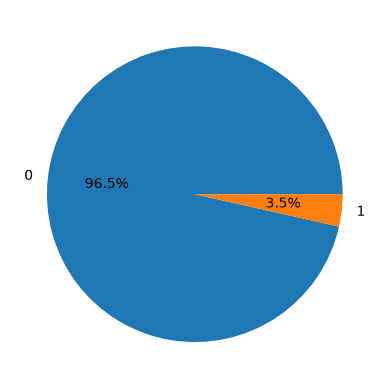

In [13]:
fig, ax = plt.subplots()

ax.pie(sizes, labels=labels, autopct='%1.1f%%')

plt.show()

# Univariate Analysis

## Quantitative Columns

TransactionID


,bins,mid_bin,counts,freq,cum_freq
0,"(2986586.623, 3069675.4]",3028131.0,82676,20.000097,20.000097
1,"(3069675.4, 3152350.8]",3111013.1,82675,19.999855,39.999952
2,"(3152350.8, 3235026.2]",3193688.5,82676,20.000097,60.000048
3,"(3235026.2, 3317701.6]",3276363.9,82675,19.999855,79.999903
4,"(3317701.6, 3400377.0]",3359039.3,82676,20.000097,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


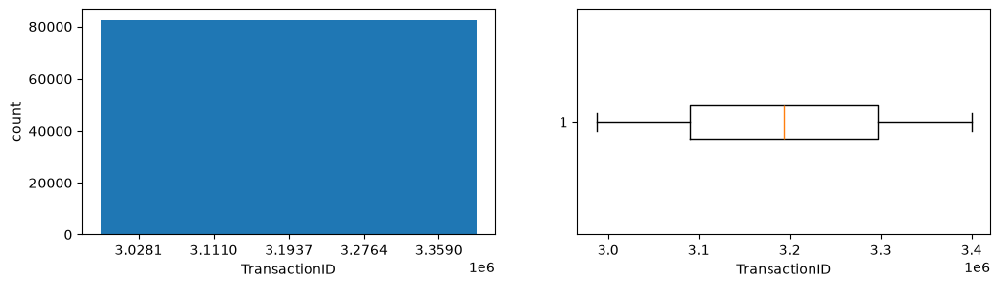

isFraud


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.001, 0.2]",0.1,398840,96.483122,96.483122
1,"(0.2, 0.4]",0.3,0,0.000000,96.483122
2,"(0.4, 0.6]",0.5,0,0.000000,96.483122
3,"(0.6, 0.8]",0.7,0,0.000000,96.483122
4,"(0.8, 1.0]",0.9,14538,3.516878,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


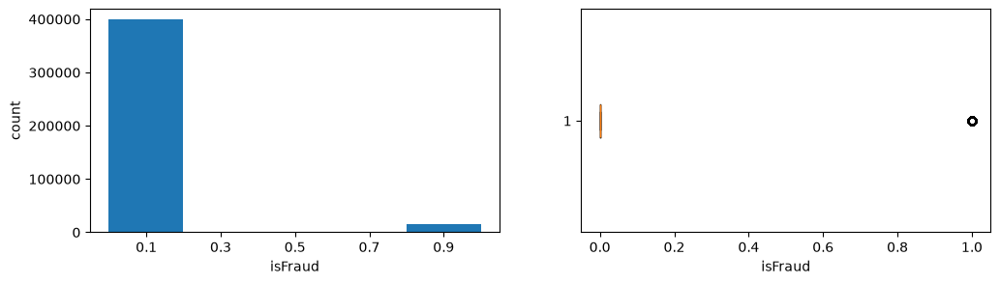

TransactionDT


,bins,mid_bin,counts,freq,cum_freq
0,"(76048.404, 2156719.2]",1116383.8,110155,26.647524,26.647524
1,"(2156719.2, 4227038.4]",3191878.8,79121,19.140109,45.787633
2,"(4227038.4, 6297357.6]",5262198.0,72618,17.566973,63.354605
3,"(6297357.6, 8367676.8]",7332517.2,77913,18.847883,82.202488
4,"(8367676.8, 10437996.0]",9402836.4,73571,17.797512,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


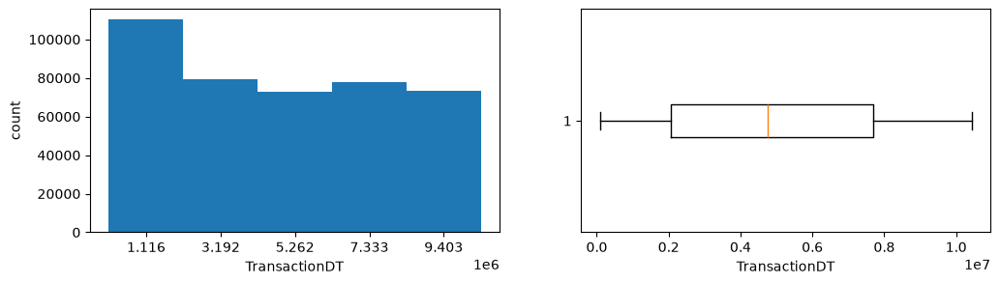

TransactionAmt


,bins,mid_bin,counts,freq,cum_freq
0,"(-31.686, 6387.679]",3178.0,413375,99.999274,99.999274
1,"(6387.679, 12775.107]",9581.4,1,0.000242,99.999516
2,"(12775.107, 19162.535]",15968.8,0,0.000000,99.999516
3,"(19162.535, 25549.963]",22356.2,0,0.000000,99.999516
4,"(25549.963, 31937.391]",28743.7,2,0.000484,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


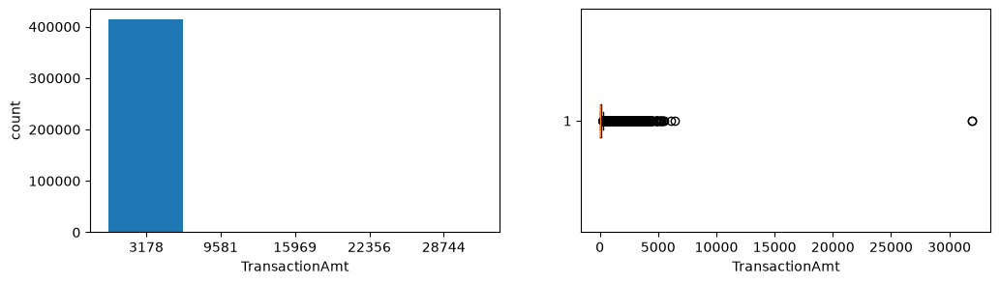

dist1


,bins,mid_bin,counts,freq,cum_freq
0,"(-10.286, 2057.2]",1023.5,155998,98.981618,98.981618
1,"(2057.2, 4114.4]",3085.8,1501,0.952393,99.934011
2,"(4114.4, 6171.6]",5143.0,100,0.063451,99.997462
3,"(6171.6, 8228.8]",7200.2,3,0.001904,99.999365
4,"(8228.8, 10286.0]",9257.4,1,0.000635,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


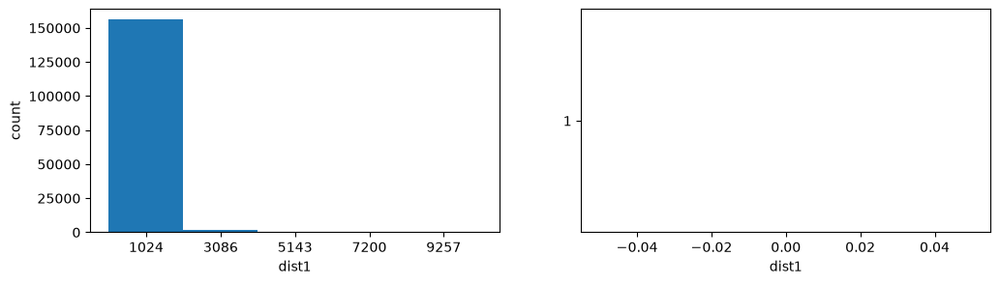

dist2


,bins,mid_bin,counts,freq,cum_freq
0,"(-11.623, 2324.6]",1156.5,28815,98.837209,98.837209
1,"(2324.6, 4649.2]",3486.9,265,0.908966,99.746175
2,"(4649.2, 6973.8]",5811.5,60,0.205804,99.951979
3,"(6973.8, 9298.4]",8136.1,13,0.044591,99.996570
4,"(9298.4, 11623.0]",10460.7,1,0.003430,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


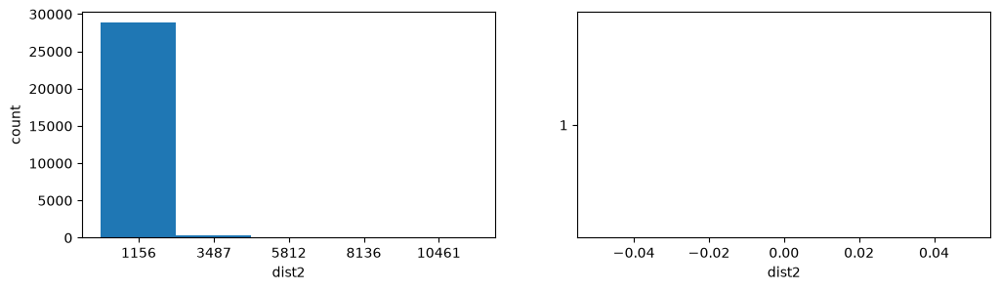

C1


,bins,mid_bin,counts,freq,cum_freq
0,"(-4.685, 937.0]",466.2,411911,99.645119,99.645119
1,"(937.0, 1874.0]",1405.5,901,0.217960,99.863079
2,"(1874.0, 2811.0]",2342.5,60,0.014515,99.877594
3,"(2811.0, 3748.0]",3279.5,274,0.066283,99.943877
4,"(3748.0, 4685.0]",4216.5,232,0.056123,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


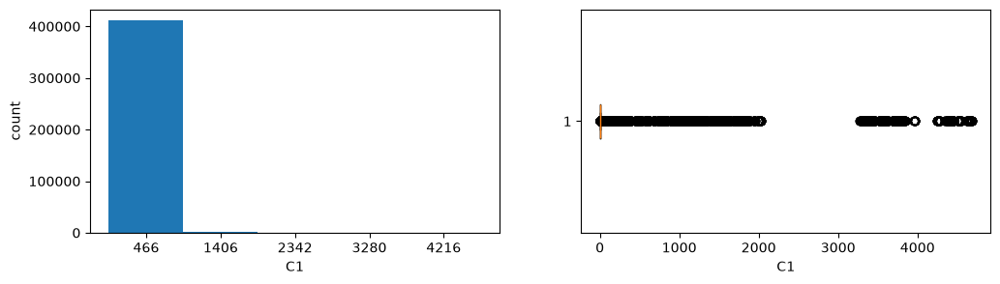

C2


,bins,mid_bin,counts,freq,cum_freq
0,"(-5.691, 1138.2]",566.3,411865,99.633991,99.633991
1,"(1138.2, 2276.4]",1707.3,830,0.200785,99.834776
2,"(2276.4, 3414.6]",2845.5,177,0.042818,99.877594
3,"(3414.6, 4552.8]",3983.7,347,0.083943,99.961536
4,"(4552.8, 5691.0]",5121.9,159,0.038464,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


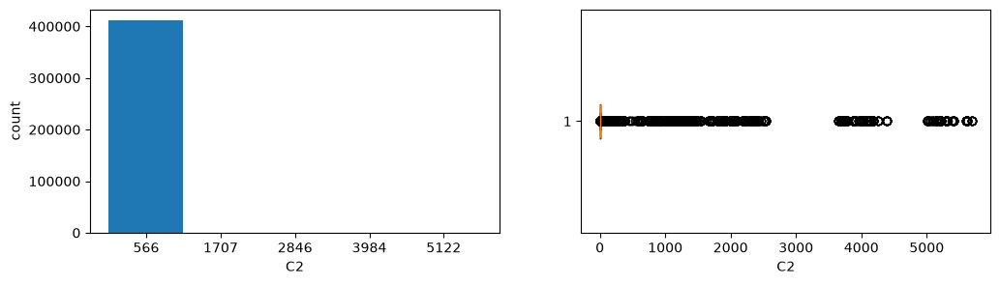

C3


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.024, 4.8]",2.4,413347,99.992501,99.992501
1,"(4.8, 9.6]",7.2,3,0.000726,99.993227
2,"(9.6, 14.4]",12.0,13,0.003145,99.996371
3,"(14.4, 19.2]",16.8,10,0.002419,99.998790
4,"(19.2, 24.0]",21.6,5,0.001210,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


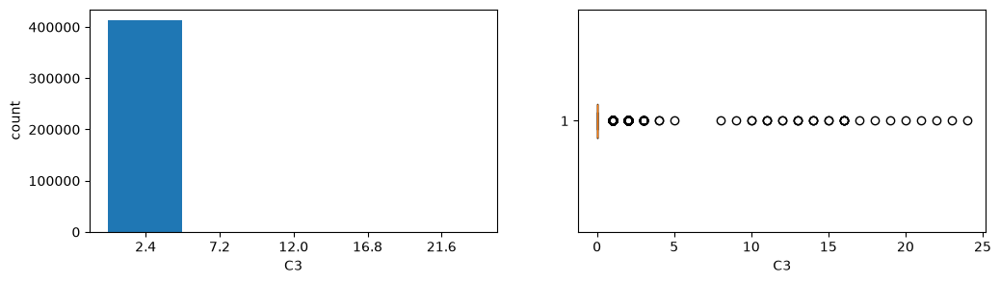

C4


,bins,mid_bin,counts,freq,cum_freq
0,"(-2.253, 450.6]",224.2,411730,99.601333,99.601333
1,"(450.6, 901.2]",675.9,812,0.196430,99.797764
2,"(901.2, 1351.8]",1126.5,330,0.079830,99.877594
3,"(1351.8, 1802.4]",1577.1,254,0.061445,99.939039
4,"(1802.4, 2253.0]",2027.7,252,0.060961,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


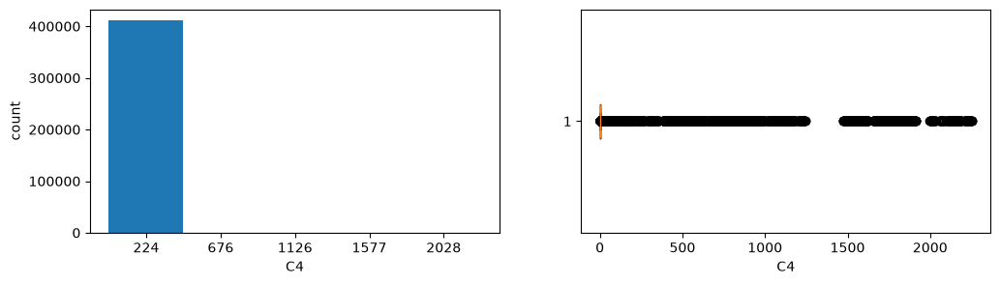

C5


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.349, 69.8]",34.7,399521,96.647862,96.647862
1,"(69.8, 139.6]",104.7,9104,2.202343,98.850205
2,"(139.6, 209.4]",174.5,3962,0.958445,99.808650
3,"(209.4, 279.2]",244.3,732,0.177078,99.985727
4,"(279.2, 349.0]",314.1,59,0.014273,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


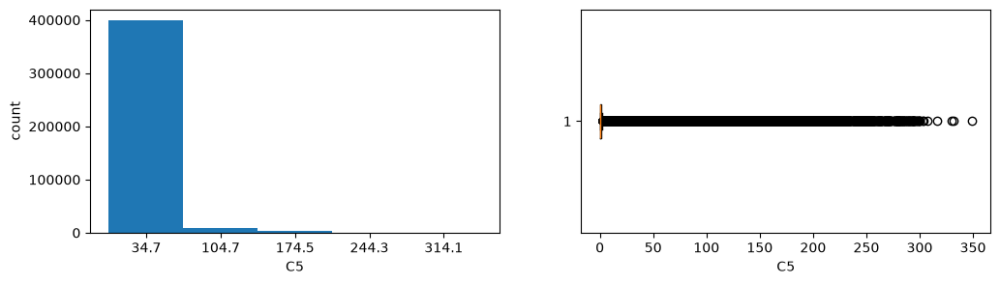

C6


,bins,mid_bin,counts,freq,cum_freq
0,"(-2.253, 450.6]",224.2,411730,99.601333,99.601333
1,"(450.6, 901.2]",675.9,806,0.194979,99.796312
2,"(901.2, 1351.8]",1126.5,336,0.081282,99.877594
3,"(1351.8, 1802.4]",1577.1,254,0.061445,99.939039
4,"(1802.4, 2253.0]",2027.7,252,0.060961,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


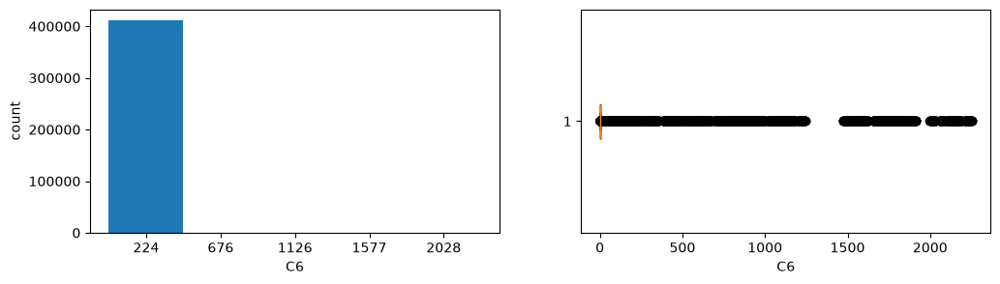

C7


,bins,mid_bin,counts,freq,cum_freq
0,"(-2.255, 451.0]",224.4,412253,99.727852,99.727852
1,"(451.0, 902.0]",676.5,328,0.079346,99.807198
2,"(902.0, 1353.0]",1127.5,291,0.070396,99.877594
3,"(1353.0, 1804.0]",1578.5,258,0.062413,99.940006
4,"(1804.0, 2255.0]",2029.5,248,0.059994,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


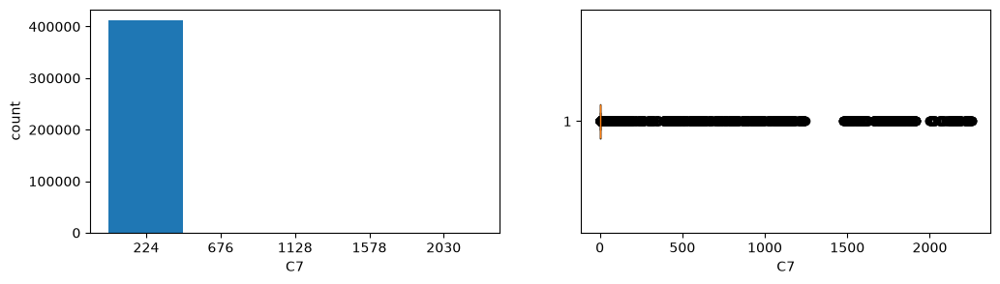

C8


,bins,mid_bin,counts,freq,cum_freq
0,"(-3.331, 666.2]",331.4,412274,99.732932,99.732932
1,"(666.2, 1332.4]",999.3,298,0.072089,99.805021
2,"(1332.4, 1998.6]",1665.5,300,0.072573,99.877594
3,"(1998.6, 2664.8]",2331.7,147,0.035561,99.913155
4,"(2664.8, 3331.0]",2997.9,359,0.086845,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


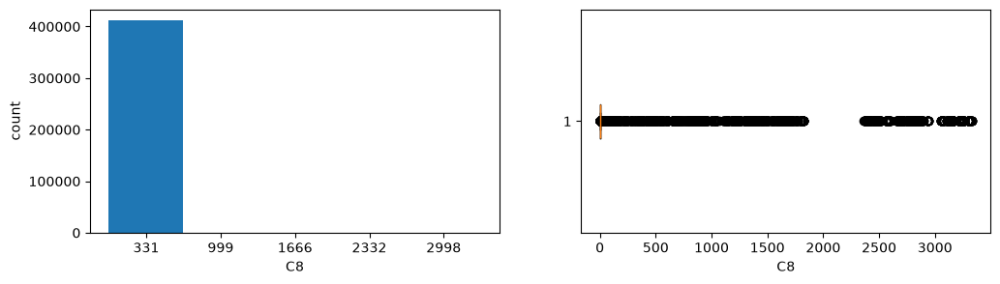

C9


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.21, 42.0]",20.9,398878,96.492315,96.492315
1,"(42.0, 84.0]",63.0,8908,2.154928,98.647243
2,"(84.0, 126.0]",105.0,4664,1.128265,99.775508
3,"(126.0, 168.0]",147.0,507,0.122648,99.898156
4,"(168.0, 210.0]",189.0,421,0.101844,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


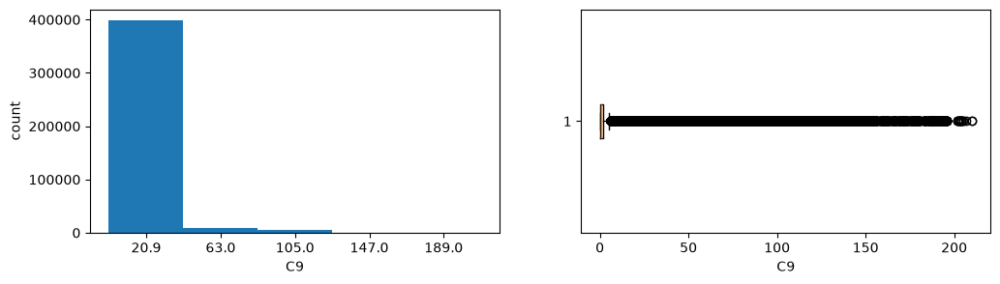

C10


,bins,mid_bin,counts,freq,cum_freq
0,"(-3.257, 651.4]",324.1,412203,99.715757,99.715757
1,"(651.4, 1302.8]",977.1,285,0.068944,99.784701
2,"(1302.8, 1954.2]",1628.5,345,0.083459,99.868159
3,"(1954.2, 2605.6]",2279.9,214,0.051769,99.919928
4,"(2605.6, 3257.0]",2931.3,331,0.080072,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


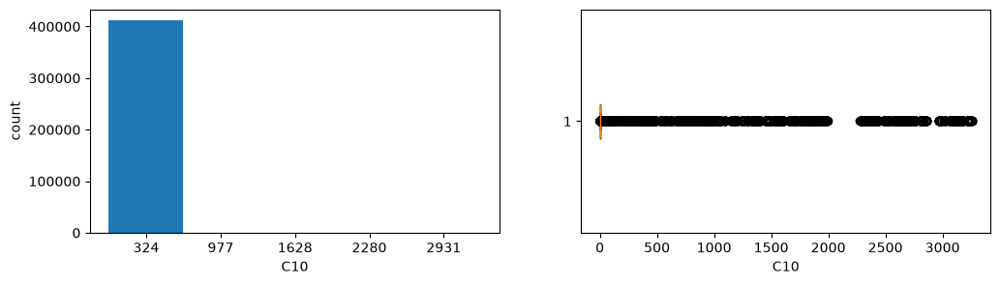

C11


,bins,mid_bin,counts,freq,cum_freq
0,"(-3.188, 637.6]",317.2,411832,99.626008,99.626008
1,"(637.6, 1275.2]",956.4,782,0.189173,99.815181
2,"(1275.2, 1912.8]",1594.0,258,0.062413,99.877594
3,"(1912.8, 2550.4]",2231.6,272,0.065799,99.943393
4,"(2550.4, 3188.0]",2869.2,234,0.056607,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


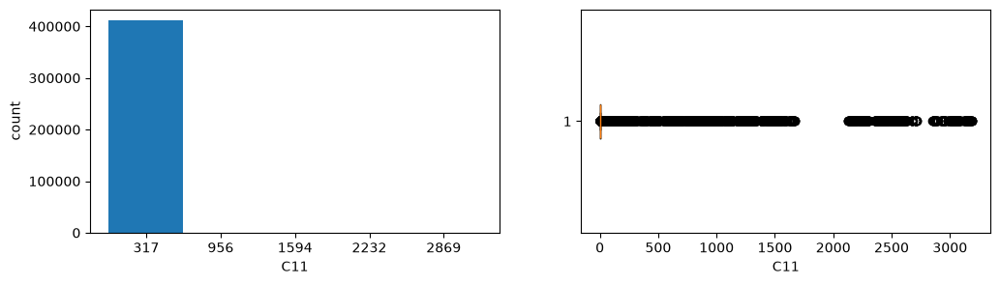

C12


,bins,mid_bin,counts,freq,cum_freq
0,"(-3.188, 637.6]",317.2,412253,99.727852,99.727852
1,"(637.6, 1275.2]",956.4,361,0.087329,99.815181
2,"(1275.2, 1912.8]",1594.0,258,0.062413,99.877594
3,"(1912.8, 2550.4]",2231.6,272,0.065799,99.943393
4,"(2550.4, 3188.0]",2869.2,234,0.056607,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


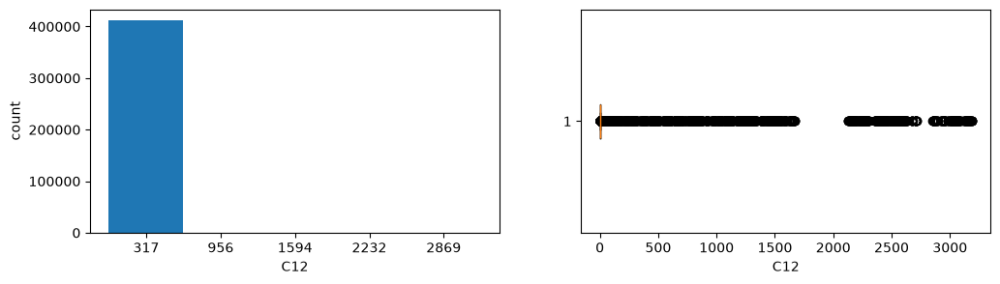

C13


,bins,mid_bin,counts,freq,cum_freq
0,"(-2.918, 583.6]",290.3,409473,99.055344,99.055344
1,"(583.6, 1167.2]",875.4,3037,0.734679,99.790023
2,"(1167.2, 1750.8]",1459.0,331,0.080072,99.870095
3,"(1750.8, 2334.4]",2042.6,215,0.052011,99.922105
4,"(2334.4, 2918.0]",2626.2,322,0.077895,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


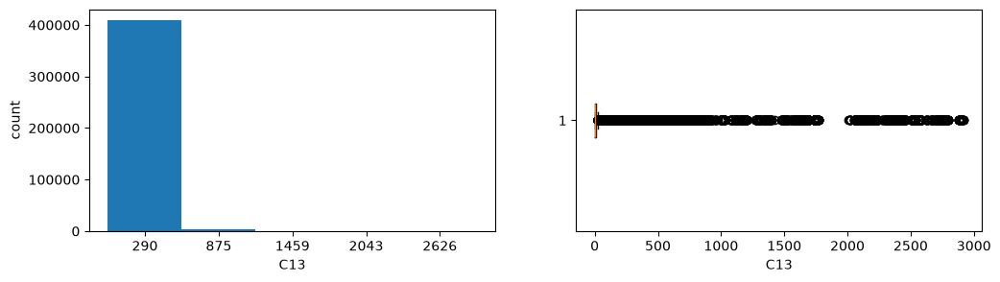

C14


,bins,mid_bin,counts,freq,cum_freq
0,"(-1.429, 285.8]",142.2,411748,99.605688,99.605688
1,"(285.8, 571.6]",428.7,558,0.134985,99.740673
2,"(571.6, 857.4]",714.5,566,0.136921,99.877594
3,"(857.4, 1143.2]",1000.3,216,0.052252,99.929846
4,"(1143.2, 1429.0]",1286.1,290,0.070154,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


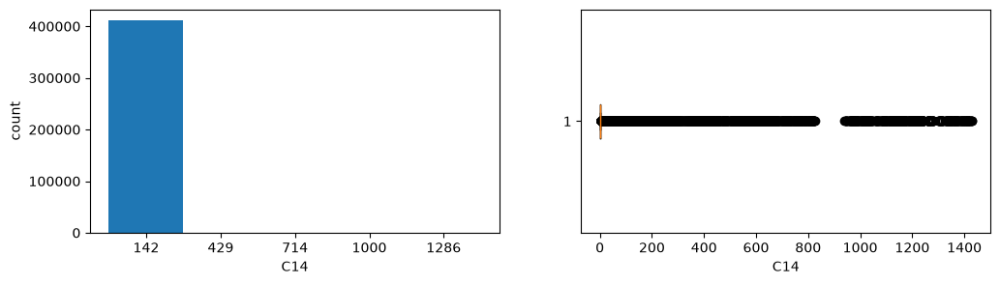

D1


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.64, 128.0]",63.7,317875,76.947749,76.947749
1,"(128.0, 256.0]",192.0,36511,8.838189,85.785938
2,"(256.0, 384.0]",320.0,24526,5.936989,91.722928
3,"(384.0, 512.0]",448.0,22136,5.358444,97.081372
4,"(512.0, 640.0]",576.0,12057,2.918628,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


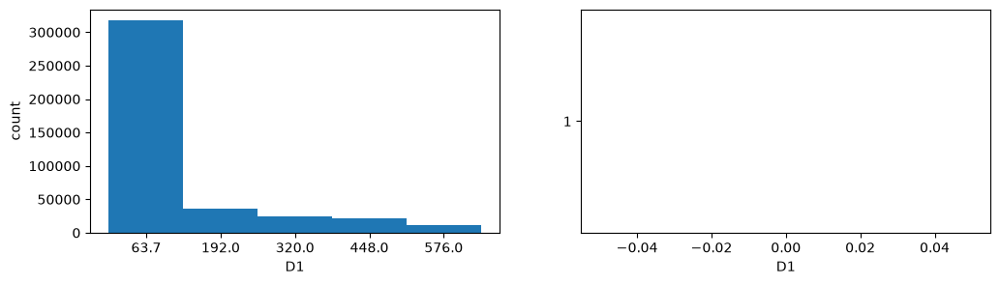

D2


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.64, 128.0]",63.7,116811,56.418442,56.418442
1,"(128.0, 256.0]",192.0,34994,16.901721,73.320164
2,"(256.0, 384.0]",320.0,23297,11.252198,84.572361
3,"(384.0, 512.0]",448.0,20870,10.079983,94.652344
4,"(512.0, 640.0]",576.0,11072,5.347656,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


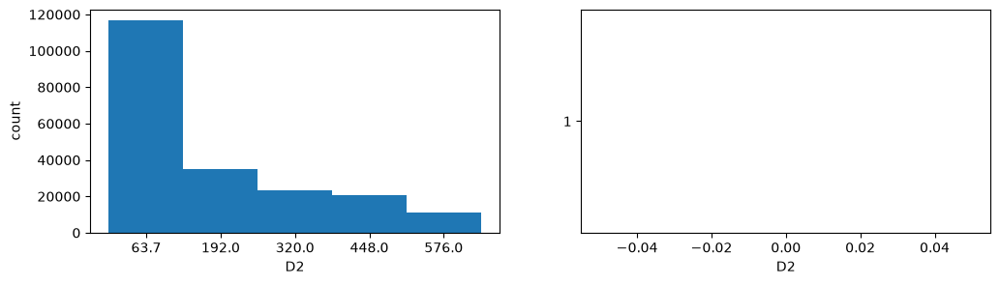

D3


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.689, 137.8]",68.6,208023,95.140156,95.140156
1,"(137.8, 275.6]",206.7,6568,3.003901,98.144057
2,"(275.6, 413.4]",344.5,3026,1.383953,99.528011
3,"(413.4, 551.2]",482.3,951,0.434944,99.962954
4,"(551.2, 689.0]",620.1,81,0.037046,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


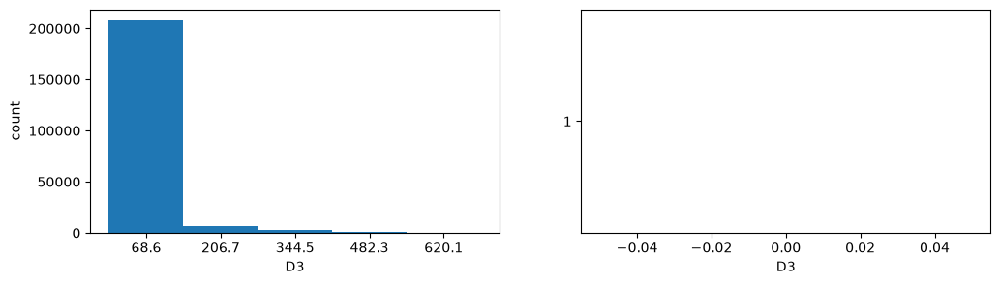

D4


,bins,mid_bin,counts,freq,cum_freq
0,"(-122.934, 64.8]",-29.1,172649,59.296339,59.296339
1,"(64.8, 251.6]",158.2,47835,16.428942,75.725281
2,"(251.6, 438.4]",345.0,37096,12.740630,88.465911
3,"(438.4, 625.2]",531.8,33347,11.453035,99.918946
4,"(625.2, 812.0]",718.6,236,0.081054,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


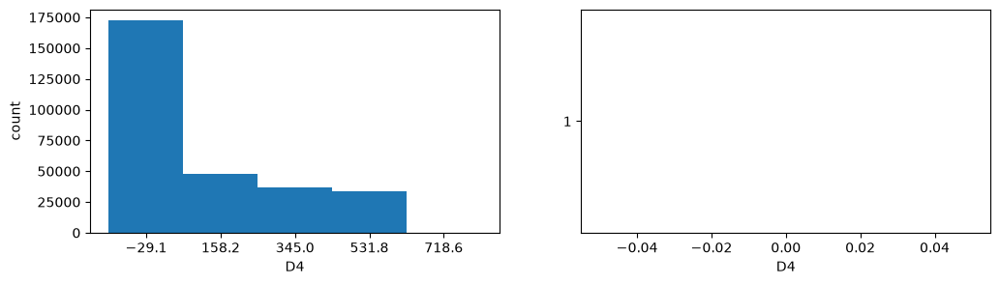

D5


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.775, 155.0]",77.1,173880,91.763067,91.763067
1,"(155.0, 310.0]",232.5,8942,4.719032,96.482099
2,"(310.0, 465.0]",387.5,5311,2.802816,99.284915
3,"(465.0, 620.0]",542.5,1325,0.699253,99.984168
4,"(620.0, 775.0]",697.5,30,0.015832,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


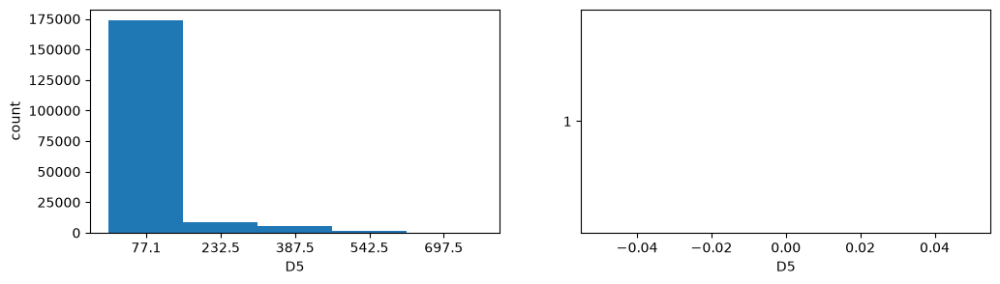

D6


,bins,mid_bin,counts,freq,cum_freq
0,"(-83.898, 96.6]",6.4,43032,81.856572,81.856572
1,"(96.6, 276.2]",186.4,3687,7.013506,88.870078
2,"(276.2, 455.8]",366.0,4655,8.854860,97.724938
3,"(455.8, 635.4]",545.6,829,1.576945,99.301883
4,"(635.4, 815.0]",725.2,367,0.698117,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


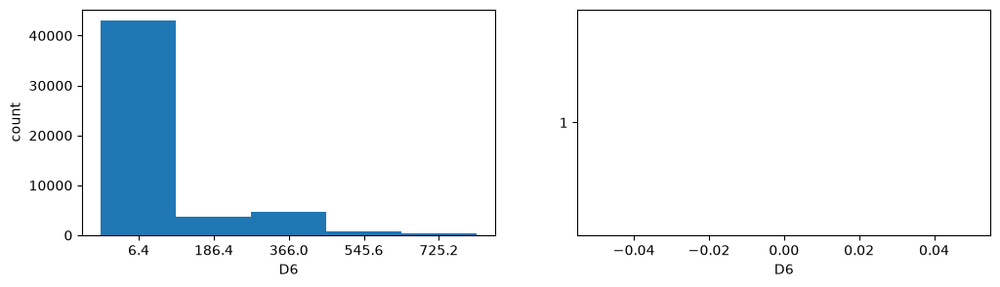

D7


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.77, 154.0]",76.6,23776,88.895536,88.895536
1,"(154.0, 308.0]",231.0,1409,5.268077,94.163613
2,"(308.0, 462.0]",385.0,1443,5.395199,99.558813
3,"(462.0, 616.0]",539.0,87,0.325282,99.884095
4,"(616.0, 770.0]",693.0,31,0.115905,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


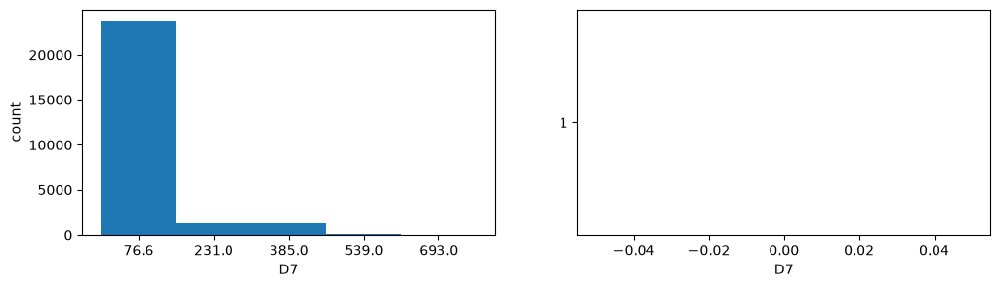

D8


,bins,mid_bin,counts,freq,cum_freq
0,"(-1.708, 341.558]",169.9,48094,85.596312,85.596312
1,"(341.558, 683.117]",512.3,4598,8.183388,93.779700
2,"(683.117, 1024.675]",853.9,3003,5.344653,99.124353
3,"(1024.675, 1366.233]",1195.5,487,0.866749,99.991101
4,"(1366.233, 1707.792]",1537.0,5,0.008899,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


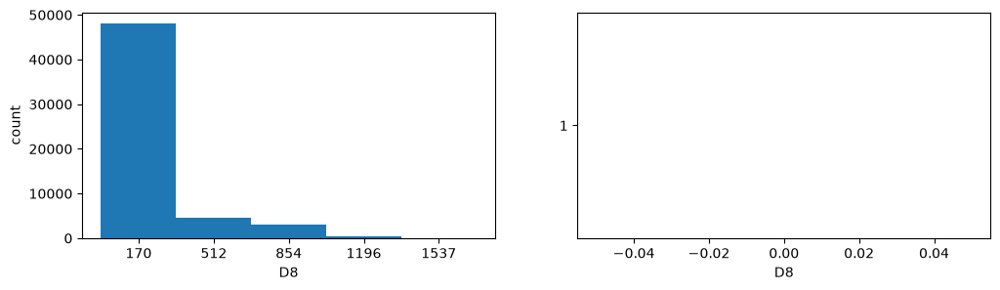

D9


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.000958, 0.192]",0.1,13496,24.019791,24.019791
1,"(0.192, 0.383]",0.3,3549,6.316408,30.336199
2,"(0.383, 0.575]",0.5,2898,5.157777,35.493975
3,"(0.575, 0.767]",0.7,17483,31.115739,66.609714
4,"(0.767, 0.958]",0.9,18761,33.390286,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


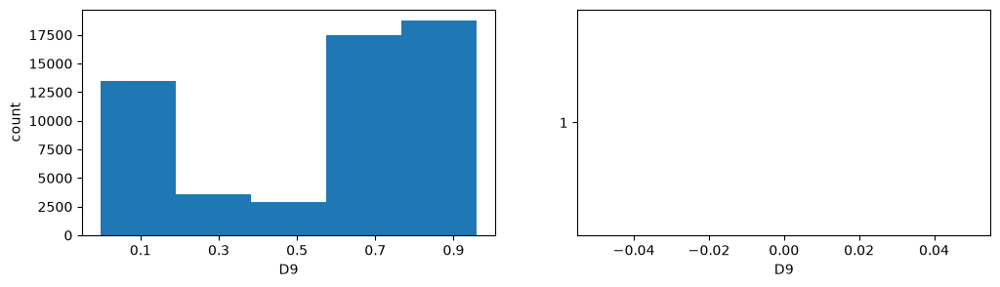

D10


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.812, 162.4]",80.8,258945,73.523817,73.523817
1,"(162.4, 324.8]",243.6,35731,10.145318,83.669135
2,"(324.8, 487.2]",406.0,33678,9.562398,93.231533
3,"(487.2, 649.6]",568.4,23580,6.695212,99.926745
4,"(649.6, 812.0]",730.8,258,0.073255,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


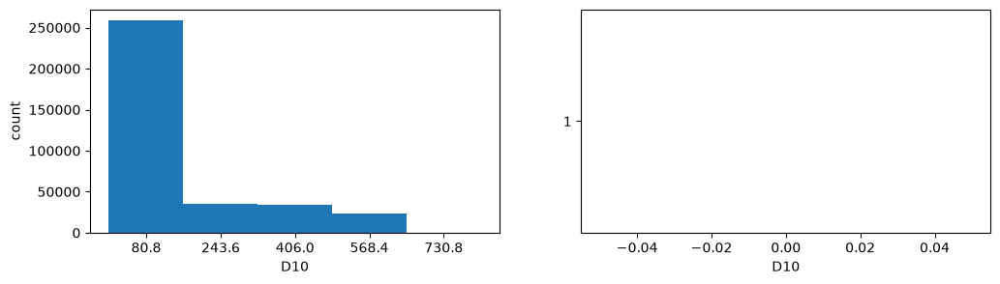

D11


,bins,mid_bin,counts,freq,cum_freq
0,"(-53.662, 79.4]",12.9,110204,58.742571,58.742571
1,"(79.4, 211.8]",145.6,25157,13.409557,72.152128
2,"(211.8, 344.2]",278.0,20652,11.008235,83.160364
3,"(344.2, 476.6]",410.4,19276,10.274779,93.435143
4,"(476.6, 609.0]",542.8,12316,6.564857,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


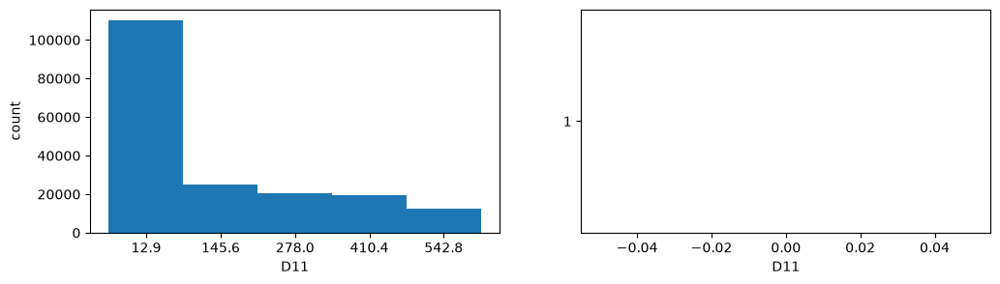

D12


,bins,mid_bin,counts,freq,cum_freq
0,"(-83.683, 53.6]",-15.0,38488,81.388907,81.388907
1,"(53.6, 190.2]",121.9,3204,6.775360,88.164267
2,"(190.2, 326.8]",258.5,2319,4.903889,93.068155
3,"(326.8, 463.4]",395.1,2560,5.413521,98.481676
4,"(463.4, 600.0]",531.7,718,1.518324,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


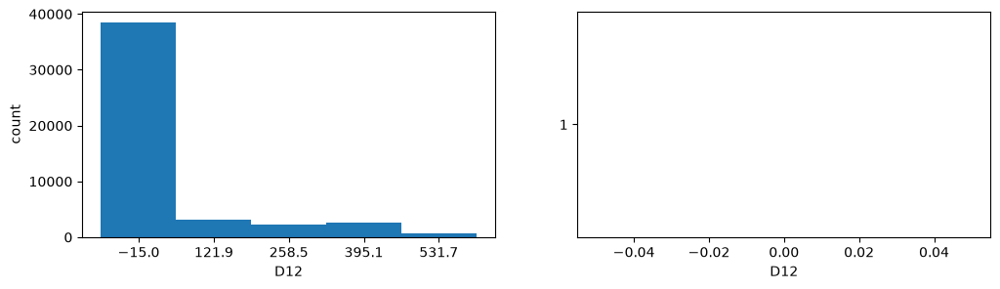

D13


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.797, 159.4]",79.3,42436,96.285708,96.285708
1,"(159.4, 318.8]",239.1,850,1.928618,98.214326
2,"(318.8, 478.2]",398.5,670,1.520205,99.734531
3,"(478.2, 637.6]",557.9,61,0.138407,99.872938
4,"(637.6, 797.0]",717.3,56,0.127062,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


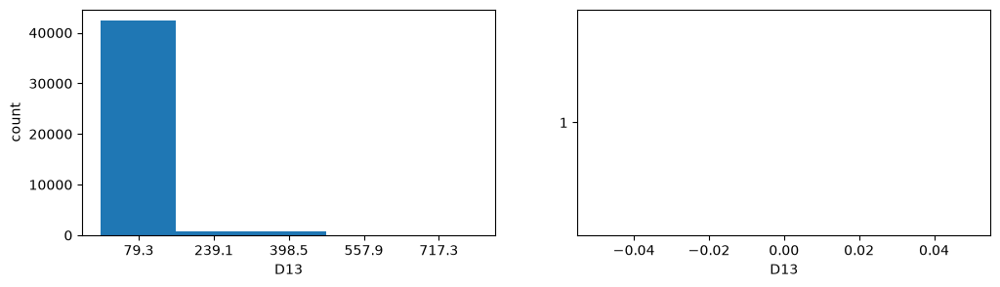

D14


,bins,mid_bin,counts,freq,cum_freq
0,"(-193.992, 5.4]",-94.3,35473,78.884985,78.884985
1,"(5.4, 203.8]",104.6,4301,9.564579,88.449564
2,"(203.8, 402.2]",303.0,3483,7.745508,96.195072
3,"(402.2, 600.6]",501.4,1435,3.191158,99.386230
4,"(600.6, 799.0]",699.8,276,0.613770,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


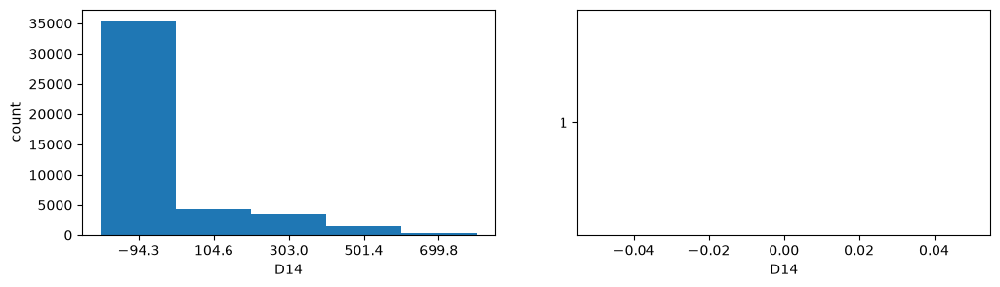

D15


,bins,mid_bin,counts,freq,cum_freq
0,"(-83.895, 96.0]",6.1,200532,58.118647,58.118647
1,"(96.0, 275.0]",185.5,53508,15.507812,73.626460
2,"(275.0, 454.0]",364.5,44514,12.901150,86.527610
3,"(454.0, 633.0]",543.5,45987,13.328059,99.855668
4,"(633.0, 812.0]",722.5,498,0.144332,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


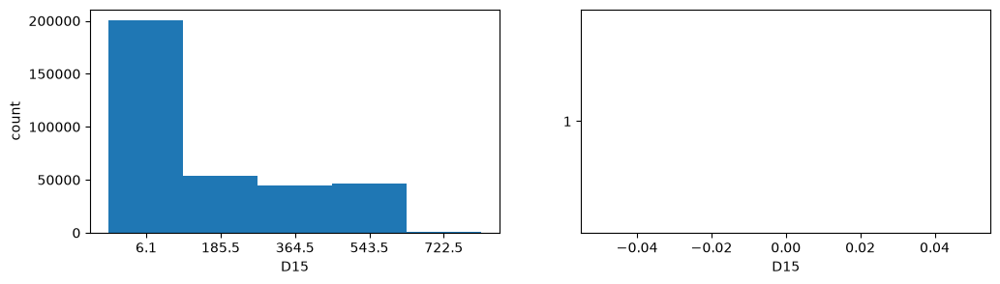

V1


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.001, 0.2]",0.1,7,0.003731,0.003731
1,"(0.2, 0.4]",0.3,0,0.000000,0.003731
2,"(0.4, 0.6]",0.5,0,0.000000,0.003731
3,"(0.6, 0.8]",0.7,0,0.000000,0.003731
4,"(0.8, 1.0]",0.9,187598,99.996269,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


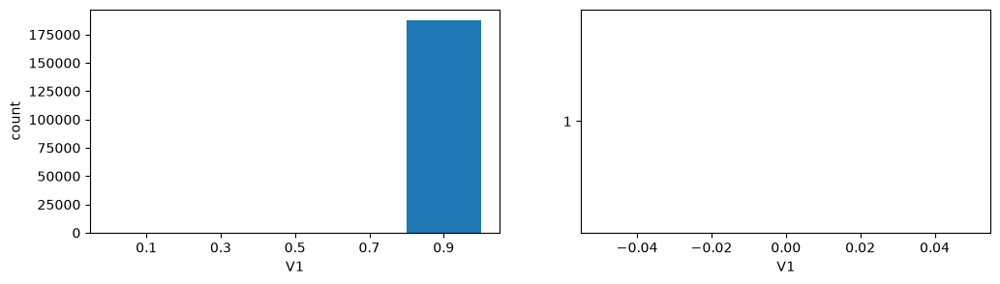

V2


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,181060,96.511287,96.511287
1,"(1.2, 2.4]",1.8,5843,3.114523,99.625810
2,"(2.4, 3.6]",3.0,615,0.327816,99.953626
3,"(3.6, 4.8]",4.2,74,0.039445,99.993071
4,"(4.8, 6.0]",5.4,13,0.006929,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


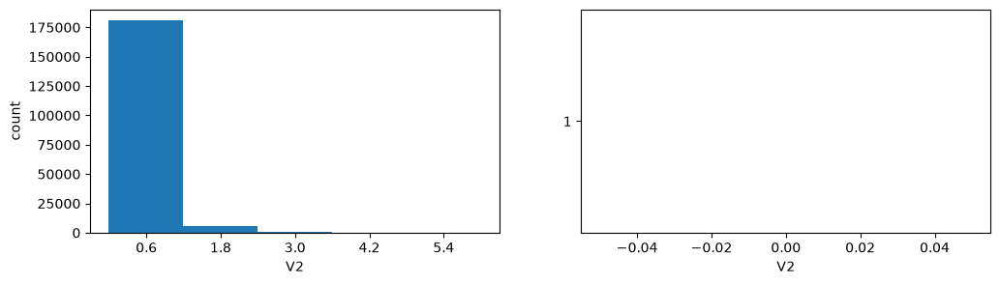

V3


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,176298,93.972975,93.972975
1,"(1.2, 2.4]",1.8,9758,5.201354,99.174329
2,"(2.4, 3.6]",3.0,1277,0.680685,99.855015
3,"(3.6, 4.8]",4.2,234,0.124730,99.979745
4,"(4.8, 6.0]",5.4,38,0.020255,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


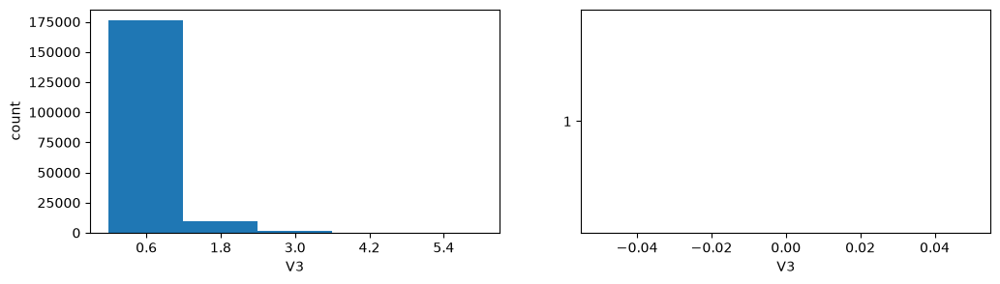

V4


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,183208,97.656246,97.656246
1,"(1.0, 2.0]",1.5,4072,2.170518,99.826764
2,"(2.0, 3.0]",2.5,290,0.154580,99.981344
3,"(3.0, 4.0]",3.5,30,0.015991,99.997335
4,"(4.0, 5.0]",4.5,5,0.002665,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


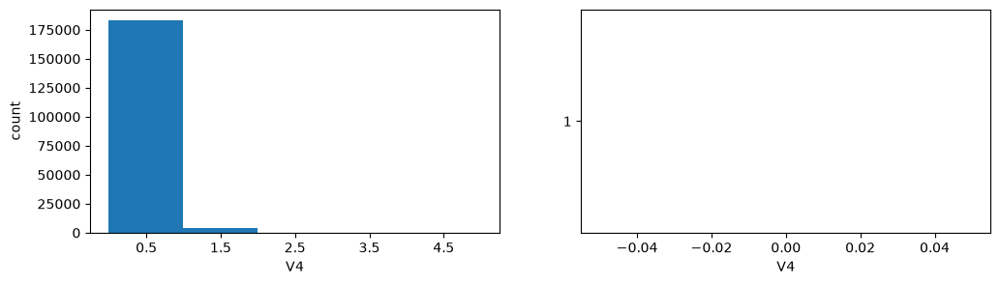

V5


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,179589,95.727193,95.727193
1,"(1.2, 2.4]",1.8,7221,3.849045,99.576237
2,"(2.4, 3.6]",3.0,636,0.339010,99.915247
3,"(3.6, 4.8]",4.2,107,0.057035,99.972282
4,"(4.8, 6.0]",5.4,52,0.027718,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


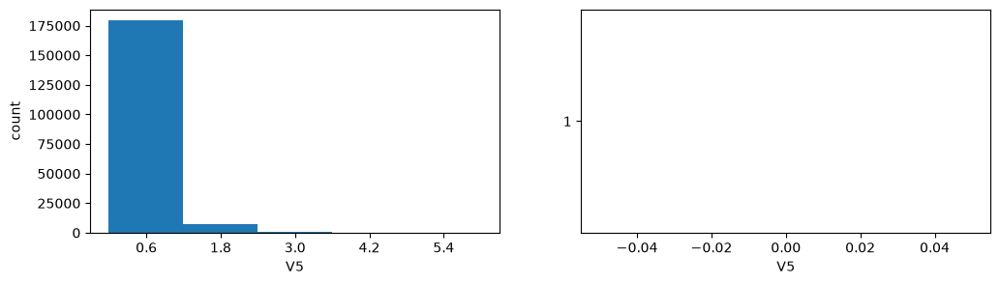

V6


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,180780,96.362037,96.362037
1,"(1.2, 2.4]",1.8,6151,3.278697,99.640735
2,"(2.4, 3.6]",3.0,574,0.305962,99.946697
3,"(3.6, 4.8]",4.2,82,0.043709,99.990405
4,"(4.8, 6.0]",5.4,18,0.009595,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


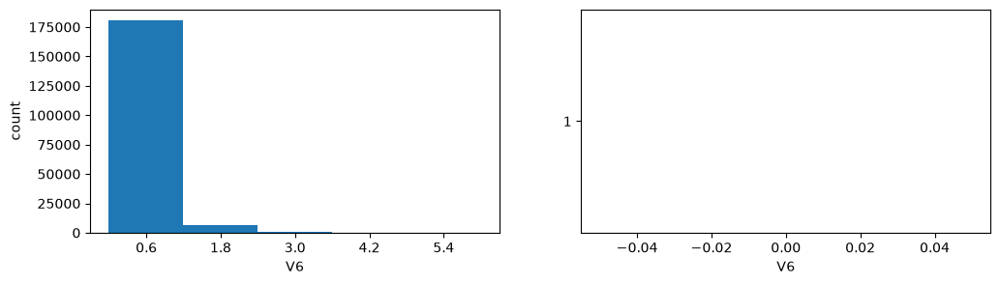

V7


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,176628,94.148877,94.148877
1,"(1.4, 2.8]",2.1,9775,5.210416,99.359292
2,"(2.8, 4.2]",3.5,1172,0.624717,99.984009
3,"(4.2, 5.6]",4.9,24,0.012793,99.996802
4,"(5.6, 7.0]",6.3,6,0.003198,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


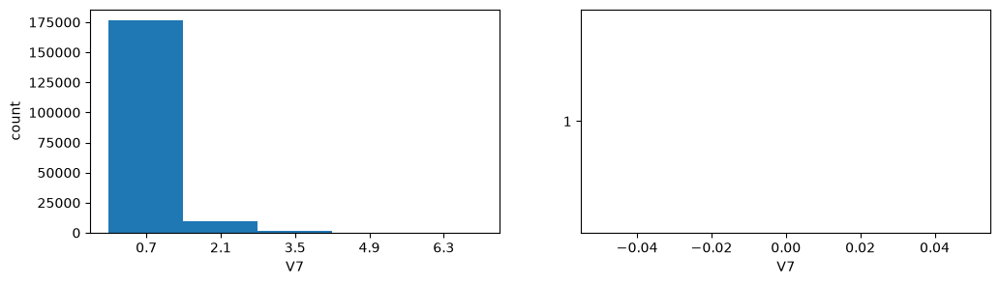

V8


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,183487,97.804963,97.804963
1,"(1.2, 2.4]",1.8,3800,2.025532,99.830495
2,"(2.4, 3.6]",3.0,273,0.145519,99.976013
3,"(3.6, 4.8]",4.2,43,0.022920,99.998934
4,"(4.8, 6.0]",5.4,2,0.001066,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


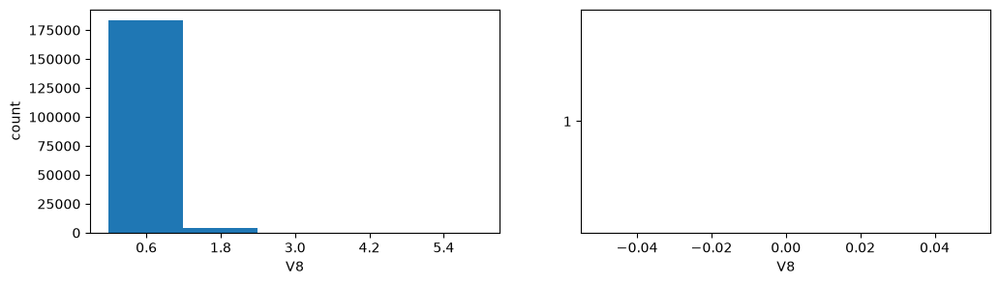

V9


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,181287,96.632286,96.632286
1,"(1.2, 2.4]",1.8,5774,3.077743,99.710029
2,"(2.4, 3.6]",3.0,466,0.248394,99.958423
3,"(3.6, 4.8]",4.2,75,0.039978,99.998401
4,"(4.8, 6.0]",5.4,3,0.001599,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


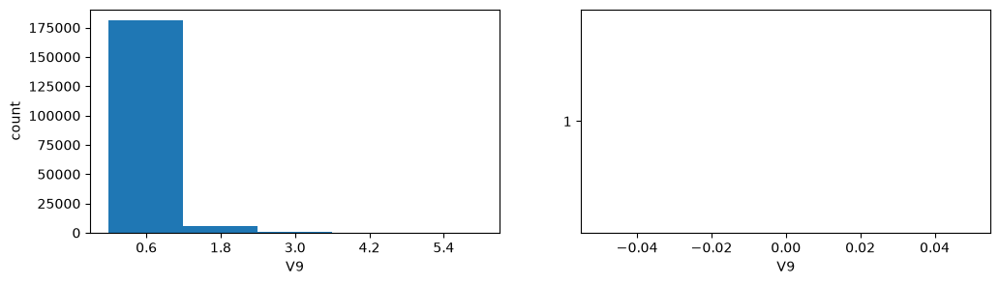

V10


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.004, 0.8]",0.4,104079,55.477732,55.477732
1,"(0.8, 1.6]",1.2,81848,43.627835,99.105568
2,"(1.6, 2.4]",2.0,1591,0.848058,99.953626
3,"(2.4, 3.2]",2.8,82,0.043709,99.997335
4,"(3.2, 4.0]",3.6,5,0.002665,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


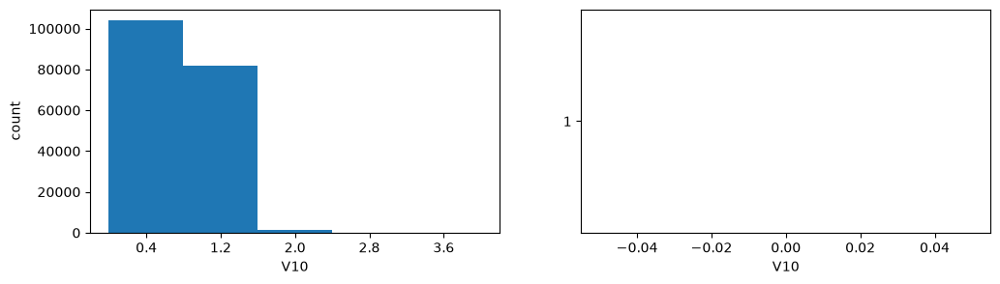

V11


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.004, 0.8]",0.4,103746,55.300232,55.300232
1,"(0.8, 1.6]",1.2,80382,42.846406,98.146638
2,"(1.6, 2.4]",2.0,3038,1.619360,99.765998
3,"(2.4, 3.2]",2.8,334,0.178034,99.944031
4,"(3.2, 4.0]",3.6,105,0.055969,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


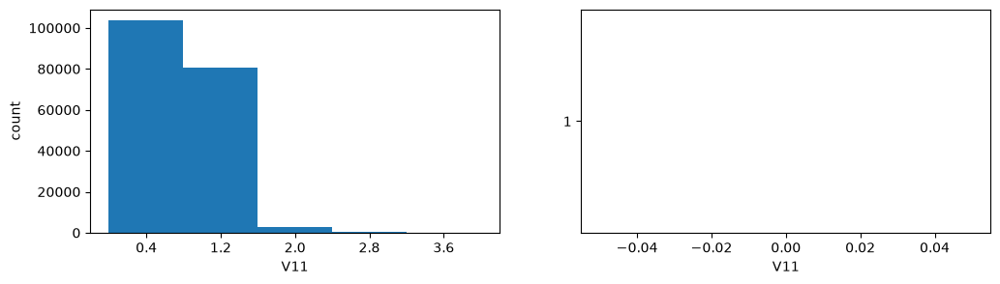

V12


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.003, 0.6]",0.3,166662,47.325110,47.325110
1,"(0.6, 1.2]",0.9,183397,52.077157,99.402267
2,"(1.2, 1.8]",1.5,0,0.000000,99.402267
3,"(1.8, 2.4]",2.1,2058,0.584387,99.986654
4,"(2.4, 3.0]",2.7,47,0.013346,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


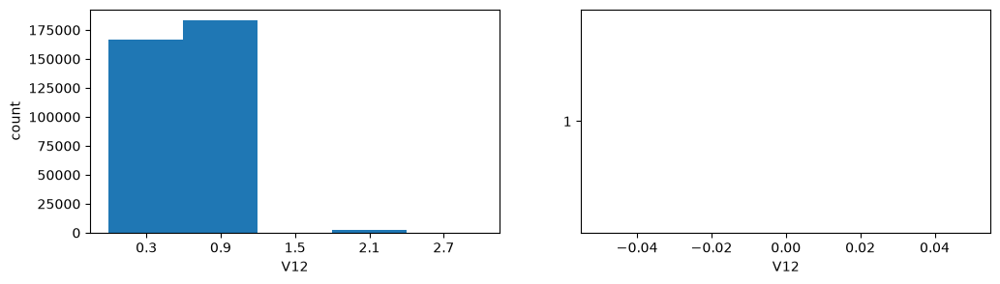

V13


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,345757,98.180677,98.180677
1,"(1.2, 2.4]",1.8,6204,1.761679,99.942356
2,"(2.4, 3.6]",3.0,175,0.049693,99.992049
3,"(3.6, 4.8]",4.2,17,0.004827,99.996876
4,"(4.8, 6.0]",5.4,11,0.003124,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


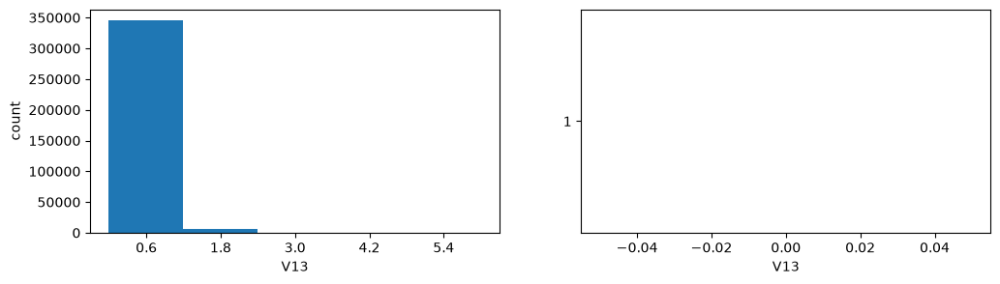

V14


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.001, 0.2]",0.1,140,0.039754,0.039754
1,"(0.2, 0.4]",0.3,0,0.000000,0.039754
2,"(0.4, 0.6]",0.5,0,0.000000,0.039754
3,"(0.6, 0.8]",0.7,0,0.000000,0.039754
4,"(0.8, 1.0]",0.9,352024,99.960246,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


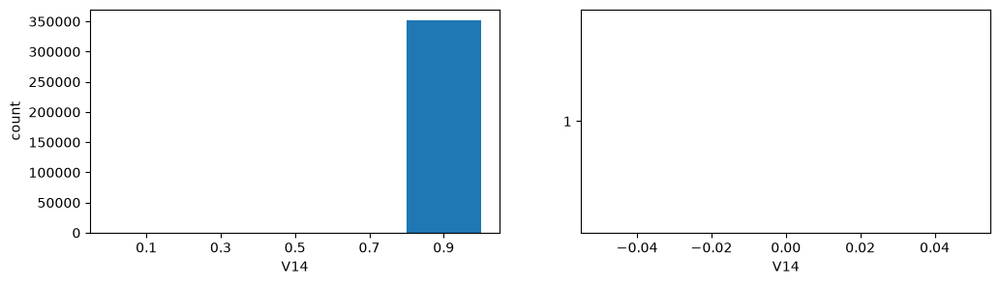

V15


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,351808,99.898911,99.898911
1,"(1.4, 2.8]",2.1,285,0.080928,99.979839
2,"(2.8, 4.2]",3.5,57,0.016186,99.996025
3,"(4.2, 5.6]",4.9,3,0.000852,99.996876
4,"(5.6, 7.0]",6.3,11,0.003124,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


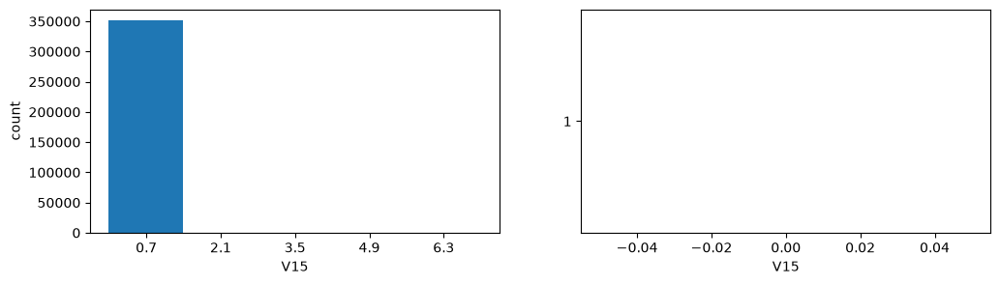

V16


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,352084,99.977283,99.977283
1,"(3.0, 6.0]",4.5,57,0.016186,99.993469
2,"(6.0, 9.0]",7.5,12,0.003408,99.996876
3,"(9.0, 12.0]",10.5,4,0.001136,99.998012
4,"(12.0, 15.0]",13.5,7,0.001988,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


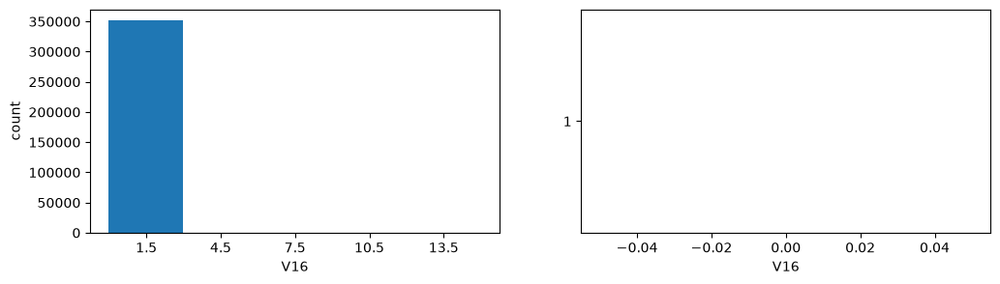

V17


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,352010,99.956270,99.956270
1,"(3.0, 6.0]",4.5,123,0.034927,99.991197
2,"(6.0, 9.0]",7.5,23,0.006531,99.997728
3,"(9.0, 12.0]",10.5,5,0.001420,99.999148
4,"(12.0, 15.0]",13.5,3,0.000852,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


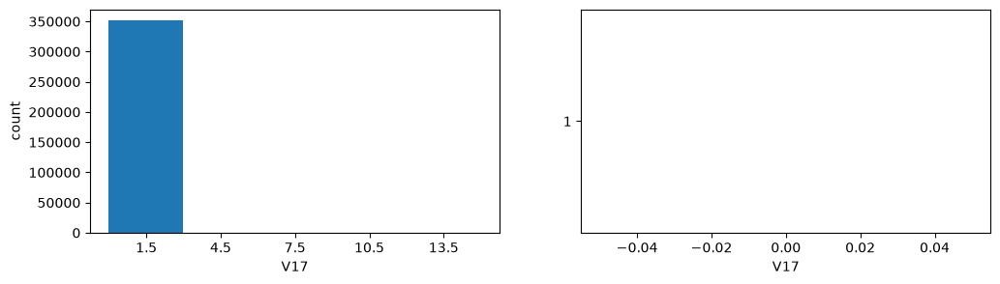

V18


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,351981,99.948036,99.948036
1,"(3.0, 6.0]",4.5,143,0.040606,99.988642
2,"(6.0, 9.0]",7.5,32,0.009087,99.997728
3,"(9.0, 12.0]",10.5,5,0.001420,99.999148
4,"(12.0, 15.0]",13.5,3,0.000852,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


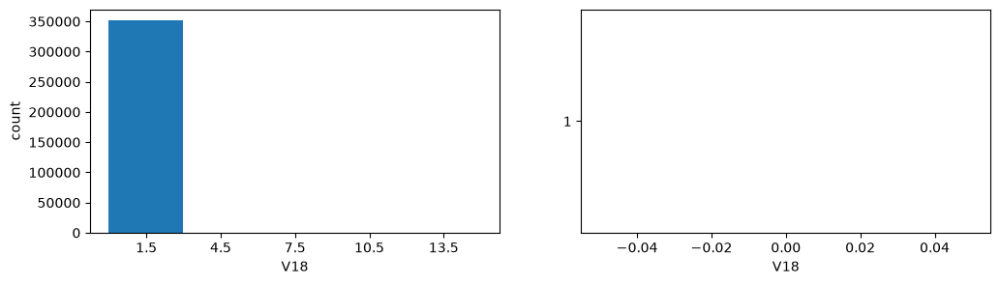

V19


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,347130,98.570552,98.570552
1,"(1.4, 2.8]",2.1,4713,1.338297,99.908849
2,"(2.8, 4.2]",3.5,307,0.087175,99.996025
3,"(4.2, 5.6]",4.9,3,0.000852,99.996876
4,"(5.6, 7.0]",6.3,11,0.003124,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


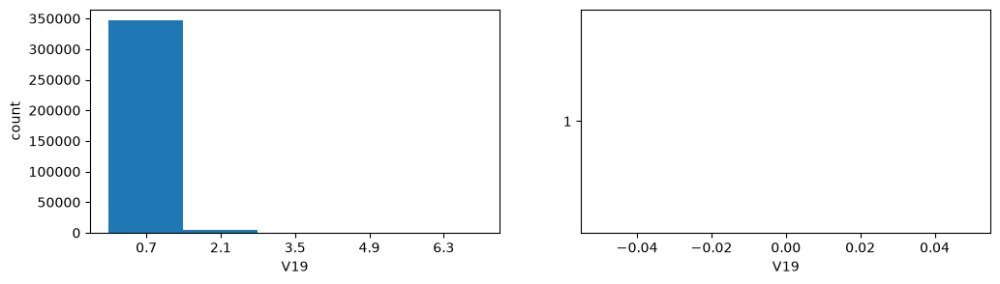

V20


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,351948,99.938665,99.938665
1,"(3.0, 6.0]",4.5,186,0.052816,99.991481
2,"(6.0, 9.0]",7.5,19,0.005395,99.996876
3,"(9.0, 12.0]",10.5,4,0.001136,99.998012
4,"(12.0, 15.0]",13.5,7,0.001988,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


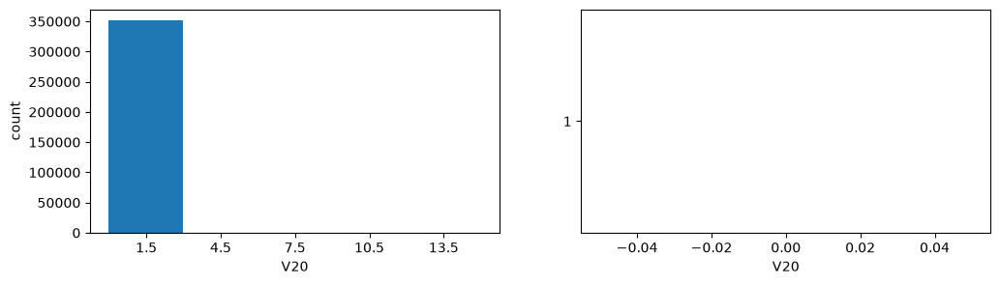

V21


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,351855,99.912257,99.912257
1,"(1.0, 2.0]",1.5,257,0.072977,99.985234
2,"(2.0, 3.0]",2.5,49,0.013914,99.999148
3,"(3.0, 4.0]",3.5,1,0.000284,99.999432
4,"(4.0, 5.0]",4.5,2,0.000568,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


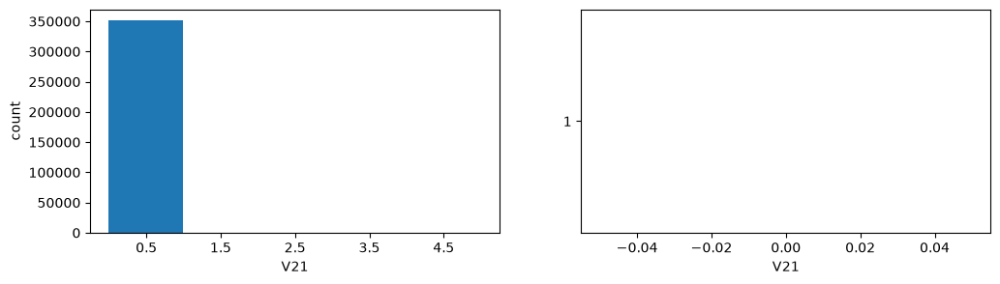

V22


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.008, 1.6]",0.8,351481,99.806056,99.806056
1,"(1.6, 3.2]",2.4,584,0.165832,99.971888
2,"(3.2, 4.8]",4.0,29,0.008235,99.980123
3,"(4.8, 6.4]",5.6,17,0.004827,99.984950
4,"(6.4, 8.0]",7.2,53,0.015050,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


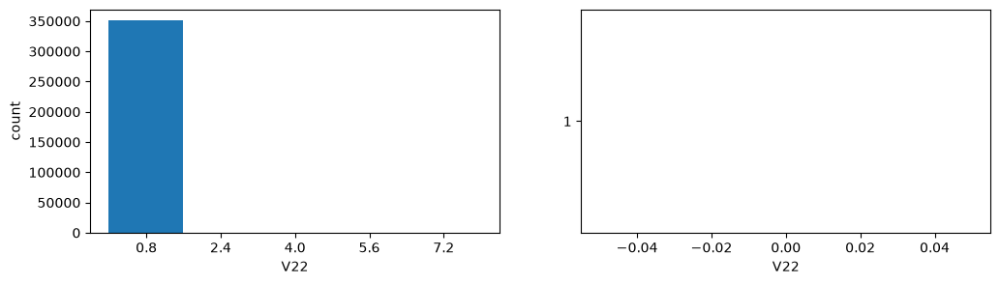

V23


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.013, 2.6]",1.3,350824,99.619495,99.619495
1,"(2.6, 5.2]",3.9,1183,0.335923,99.955418
2,"(5.2, 7.8]",6.5,98,0.027828,99.983246
3,"(7.8, 10.4]",9.1,52,0.014766,99.998012
4,"(10.4, 13.0]",11.7,7,0.001988,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


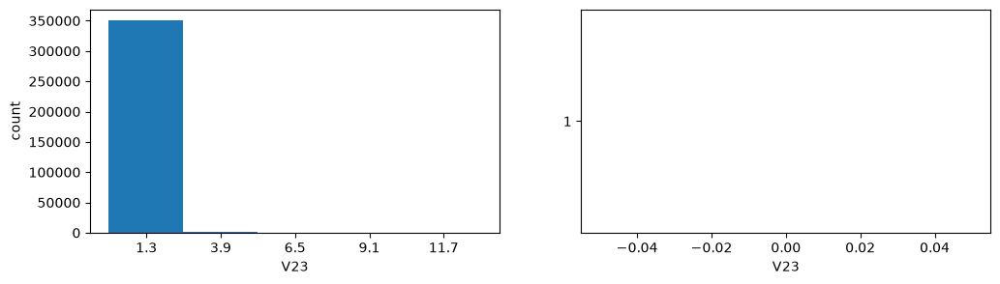

V24


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.013, 2.6]",1.3,350055,99.401131,99.401131
1,"(2.6, 5.2]",3.9,1904,0.540657,99.941788
2,"(5.2, 7.8]",6.5,124,0.035211,99.976999
3,"(7.8, 10.4]",9.1,69,0.019593,99.996592
4,"(10.4, 13.0]",11.7,12,0.003408,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


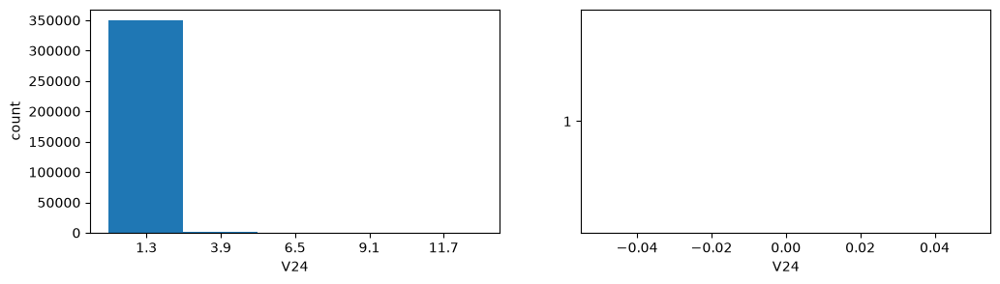

V25


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,350222,99.448552,99.448552
1,"(1.4, 2.8]",2.1,1784,0.506582,99.955135
2,"(2.8, 4.2]",3.5,156,0.044298,99.999432
3,"(4.2, 5.6]",4.9,1,0.000284,99.999716
4,"(5.6, 7.0]",6.3,1,0.000284,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


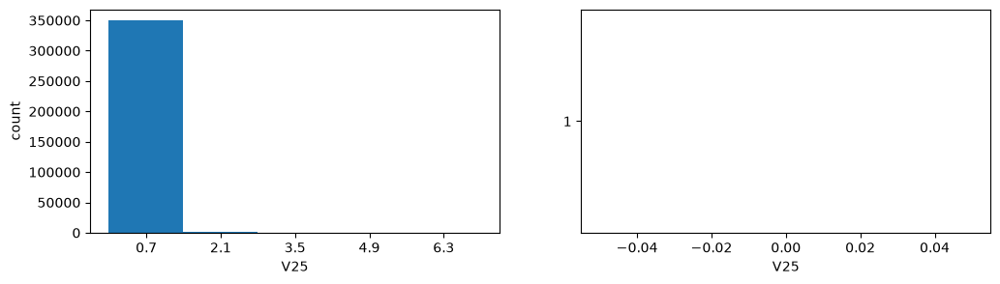

V26


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.013, 2.6]",1.3,351862,99.914244,99.914244
1,"(2.6, 5.2]",3.9,266,0.075533,99.989777
2,"(5.2, 7.8]",6.5,15,0.004259,99.994037
3,"(7.8, 10.4]",9.1,18,0.005111,99.999148
4,"(10.4, 13.0]",11.7,3,0.000852,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


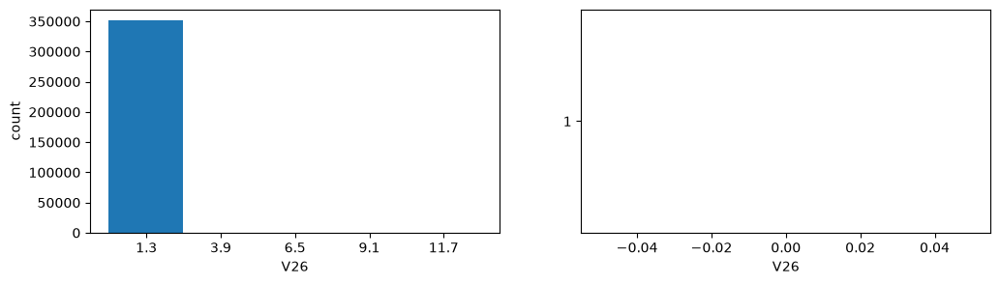

V27


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.004, 0.8]",0.4,351897,99.924183,99.924183
1,"(0.8, 1.6]",1.2,261,0.074113,99.998296
2,"(1.6, 2.4]",2.0,5,0.001420,99.999716
3,"(2.4, 3.2]",2.8,0,0.000000,99.999716
4,"(3.2, 4.0]",3.6,1,0.000284,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


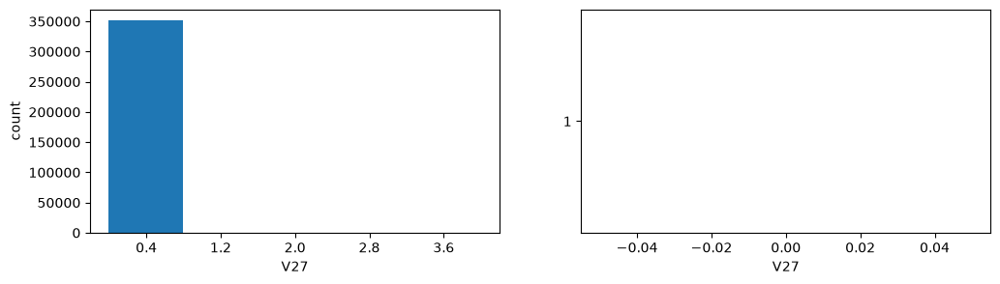

V28


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.004, 0.8]",0.4,351895,99.923615,99.923615
1,"(0.8, 1.6]",1.2,261,0.074113,99.997728
2,"(1.6, 2.4]",2.0,7,0.001988,99.999716
3,"(2.4, 3.2]",2.8,0,0.000000,99.999716
4,"(3.2, 4.0]",3.6,1,0.000284,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


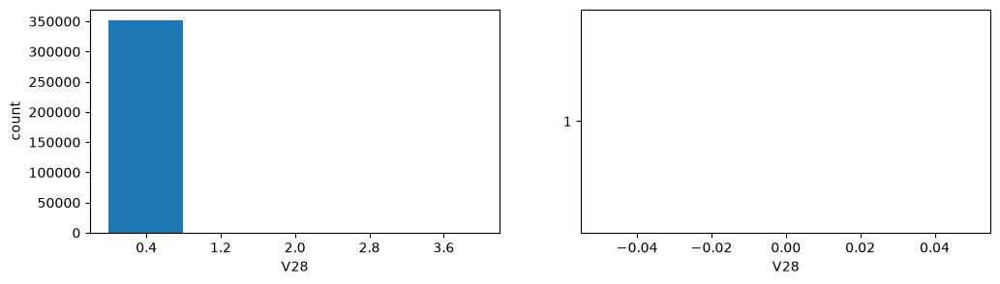

V29


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,348768,99.035677,99.035677
1,"(1.0, 2.0]",1.5,3111,0.883395,99.919072
2,"(2.0, 3.0]",2.5,233,0.066162,99.985234
3,"(3.0, 4.0]",3.5,50,0.014198,99.999432
4,"(4.0, 5.0]",4.5,2,0.000568,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


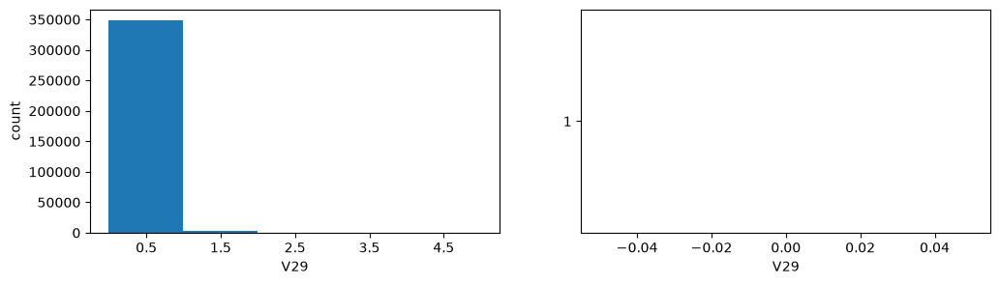

V30


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.009, 1.8]",0.9,344604,97.853273,97.853273
1,"(1.8, 3.6]",2.7,7234,2.054157,99.907429
2,"(3.6, 5.4]",4.5,314,0.089163,99.996592
3,"(5.4, 7.2]",6.3,5,0.001420,99.998012
4,"(7.2, 9.0]",8.1,7,0.001988,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


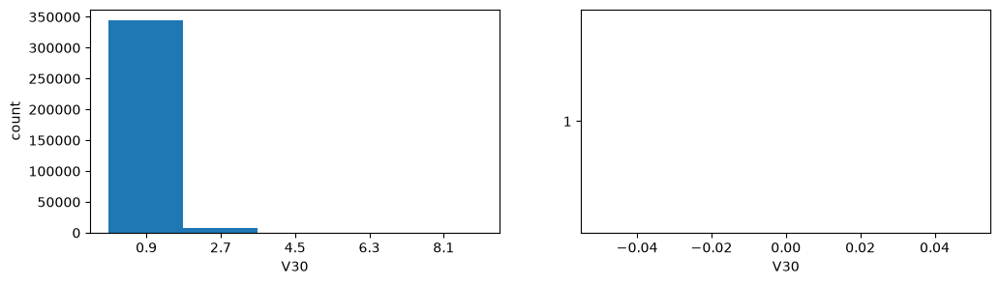

V31


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,351607,99.841835,99.841835
1,"(1.4, 2.8]",2.1,391,0.111028,99.952863
2,"(2.8, 4.2]",3.5,150,0.042594,99.995457
3,"(4.2, 5.6]",4.9,5,0.001420,99.996876
4,"(5.6, 7.0]",6.3,11,0.003124,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


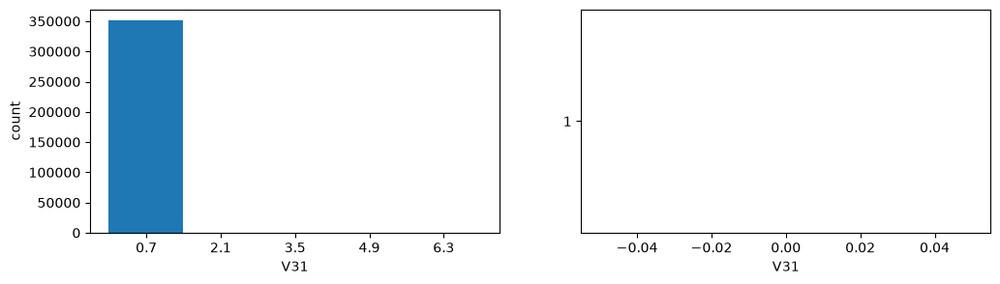

V32


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,352043,99.965641,99.965641
1,"(3.0, 6.0]",4.5,98,0.027828,99.993469
2,"(6.0, 9.0]",7.5,12,0.003408,99.996876
3,"(9.0, 12.0]",10.5,4,0.001136,99.998012
4,"(12.0, 15.0]",13.5,7,0.001988,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


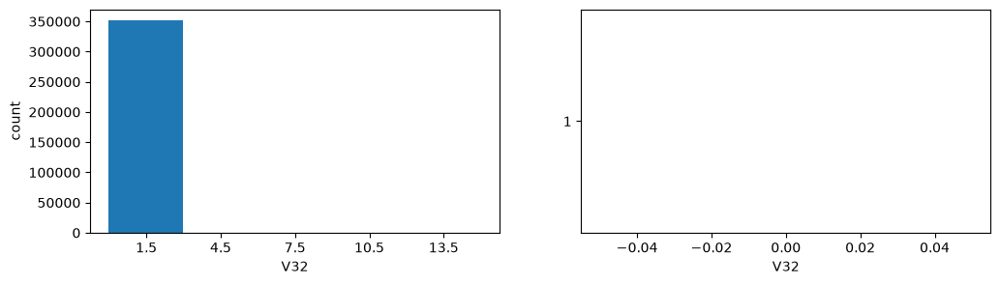

V33


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,351793,99.894651,99.894651
1,"(1.4, 2.8]",2.1,279,0.079224,99.973876
2,"(2.8, 4.2]",3.5,90,0.025556,99.999432
3,"(4.2, 5.6]",4.9,1,0.000284,99.999716
4,"(5.6, 7.0]",6.3,1,0.000284,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


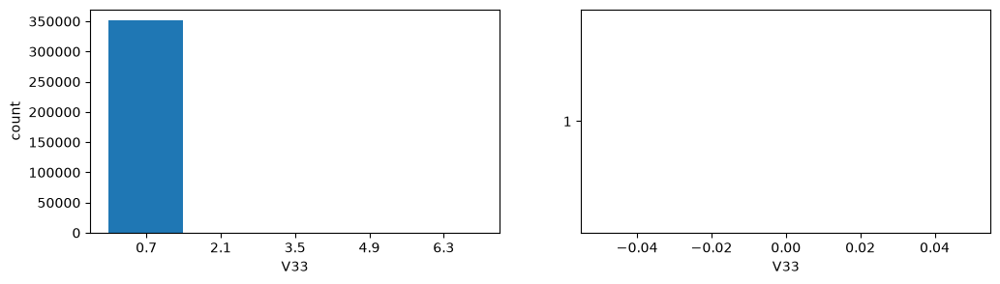

V34


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.013, 2.6]",1.3,351967,99.944060,99.944060
1,"(2.6, 5.2]",3.9,168,0.047705,99.991765
2,"(5.2, 7.8]",6.5,15,0.004259,99.996025
3,"(7.8, 10.4]",9.1,11,0.003124,99.999148
4,"(10.4, 13.0]",11.7,3,0.000852,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


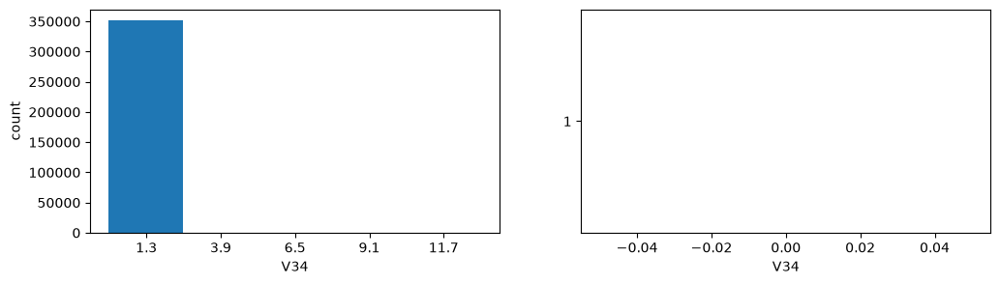

V35


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.003, 0.6]",0.3,145440,49.956377,49.956377
1,"(0.6, 1.2]",0.9,143290,49.217886,99.174263
2,"(1.2, 1.8]",1.5,0,0.000000,99.174263
3,"(1.8, 2.4]",2.1,2365,0.812341,99.986604
4,"(2.4, 3.0]",2.7,39,0.013396,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


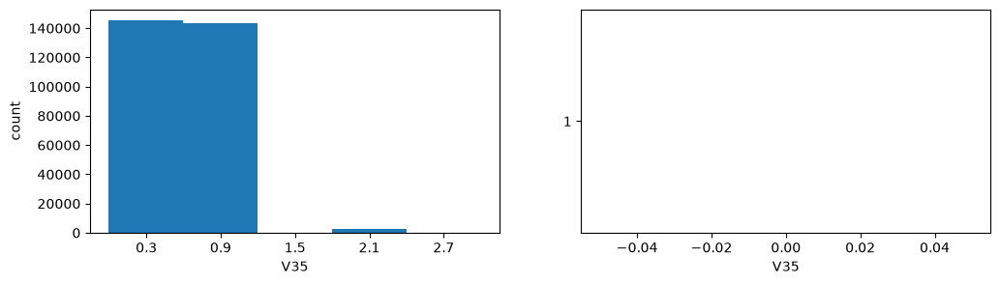

V36


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.004, 0.8]",0.4,138357,47.523477,47.523477
1,"(0.8, 1.6]",1.2,147082,50.520379,98.043856
2,"(1.6, 2.4]",2.0,5374,1.845885,99.889741
3,"(2.4, 3.2]",2.8,315,0.108198,99.997939
4,"(3.2, 4.0]",3.6,6,0.002061,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


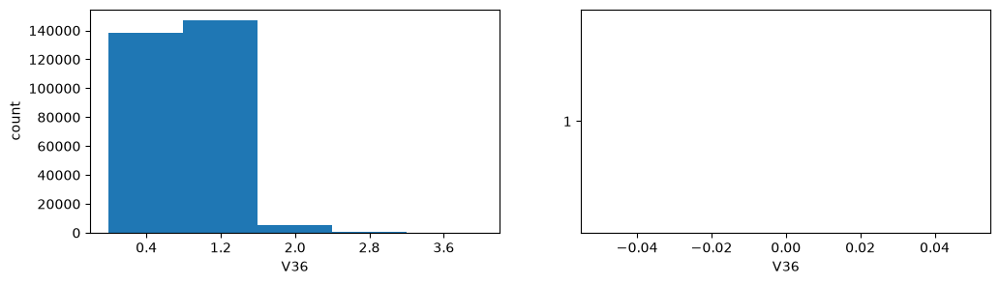

V37


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.054, 10.8]",5.4,290924,99.927868,99.927868
1,"(10.8, 21.6]",16.2,174,0.059766,99.987635
2,"(21.6, 32.4]",27.0,14,0.004809,99.992443
3,"(32.4, 43.2]",37.8,11,0.003778,99.996222
4,"(43.2, 54.0]",48.6,11,0.003778,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


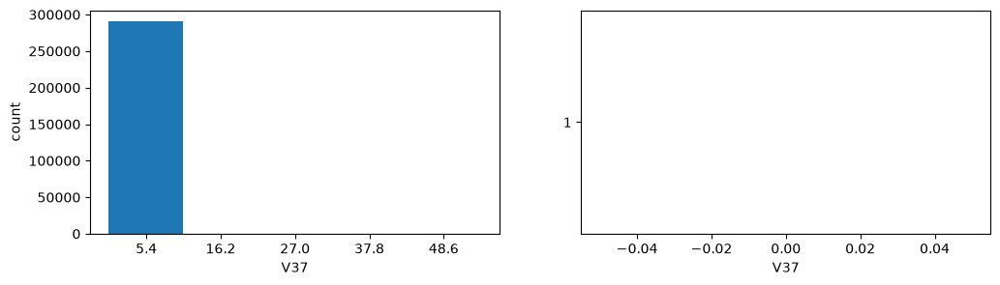

V38


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.054, 10.8]",5.4,290774,99.876346,99.876346
1,"(10.8, 21.6]",16.2,302,0.103732,99.980078
2,"(21.6, 32.4]",27.0,36,0.012365,99.992443
3,"(32.4, 43.2]",37.8,11,0.003778,99.996222
4,"(43.2, 54.0]",48.6,11,0.003778,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


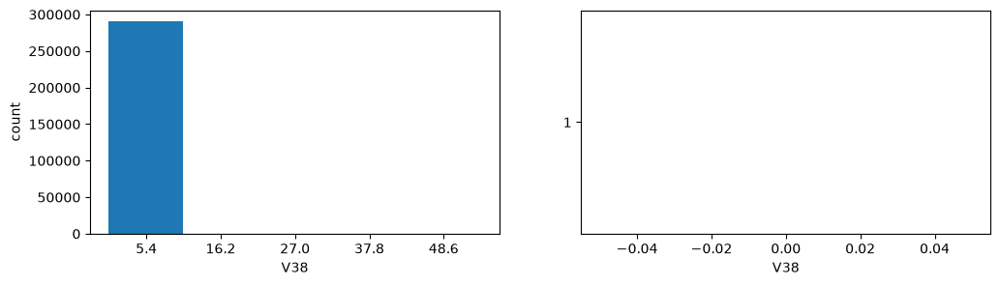

V39


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.014, 2.8]",1.4,290286,99.708725,99.708725
1,"(2.8, 5.6]",4.2,668,0.229448,99.938173
2,"(5.6, 8.4]",7.0,124,0.042592,99.980765
3,"(8.4, 11.2]",9.8,39,0.013396,99.994161
4,"(11.2, 14.0]",12.6,17,0.005839,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


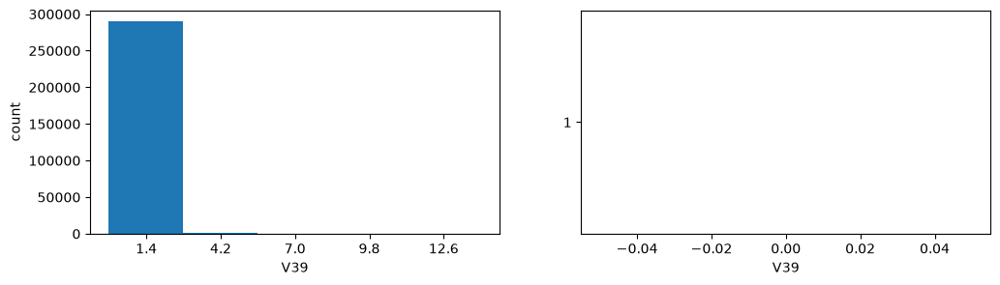

V40


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.023, 4.6]",2.3,290728,99.860545,99.860545
1,"(4.6, 9.2]",6.9,343,0.117815,99.978360
2,"(9.2, 13.8]",11.5,49,0.016831,99.995191
3,"(13.8, 18.4]",16.1,13,0.004465,99.999657
4,"(18.4, 23.0]",20.7,1,0.000343,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


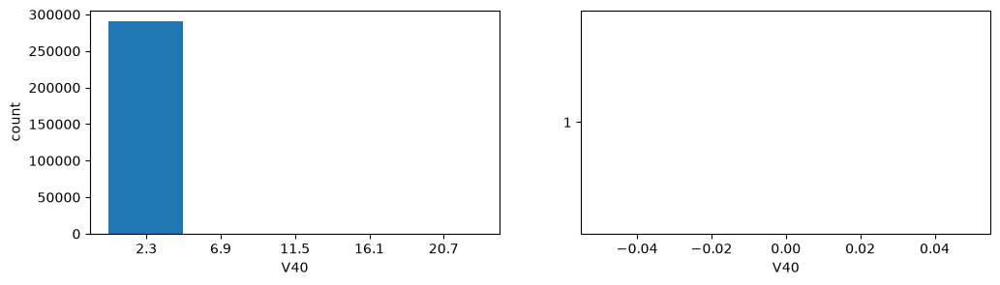

V41


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.001, 0.2]",0.1,169,0.058049,0.058049
1,"(0.2, 0.4]",0.3,0,0.000000,0.058049
2,"(0.4, 0.6]",0.5,0,0.000000,0.058049
3,"(0.6, 0.8]",0.7,0,0.000000,0.058049
4,"(0.8, 1.0]",0.9,290965,99.941951,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


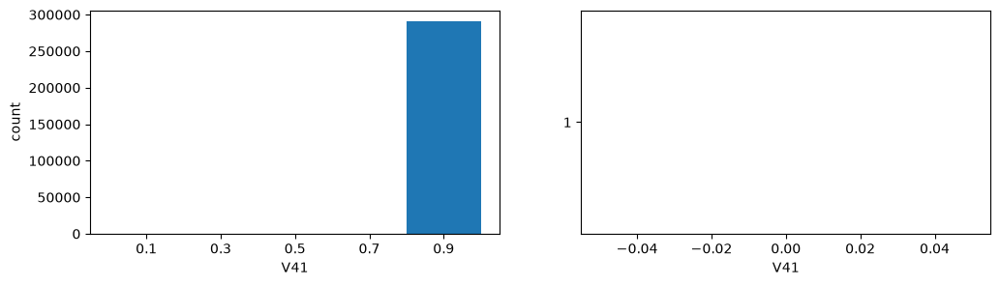

V42


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.008, 1.6]",0.8,289474,99.429816,99.429816
1,"(1.6, 3.2]",2.4,1635,0.561597,99.991413
2,"(3.2, 4.8]",4.0,18,0.006183,99.997596
3,"(4.8, 6.4]",5.6,3,0.001030,99.998626
4,"(6.4, 8.0]",7.2,4,0.001374,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


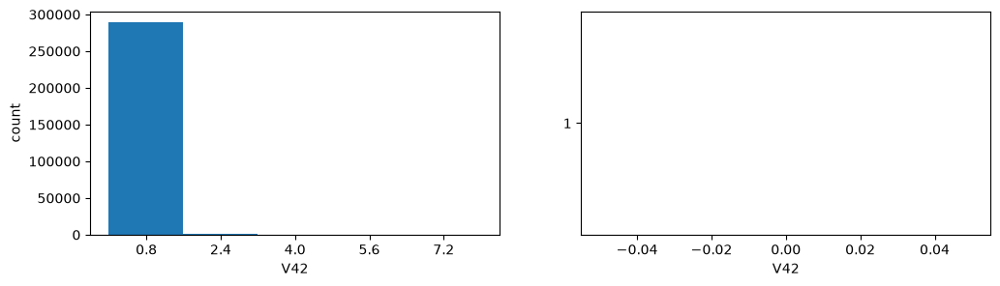

V43


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.008, 1.6]",0.8,286905,98.547404,98.547404
1,"(1.6, 3.2]",2.4,4081,1.401760,99.949164
2,"(3.2, 4.8]",4.0,104,0.035722,99.984887
3,"(4.8, 6.4]",5.6,40,0.013739,99.998626
4,"(6.4, 8.0]",7.2,4,0.001374,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


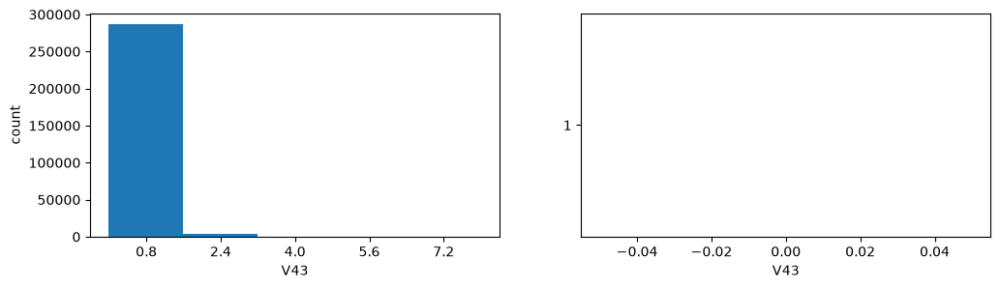

V44


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.048, 9.6]",4.8,290903,99.920655,99.920655
1,"(9.6, 19.2]",14.4,170,0.058392,99.979047
2,"(19.2, 28.8]",24.0,24,0.008244,99.987291
3,"(28.8, 38.4]",33.6,24,0.008244,99.995535
4,"(38.4, 48.0]",43.2,13,0.004465,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


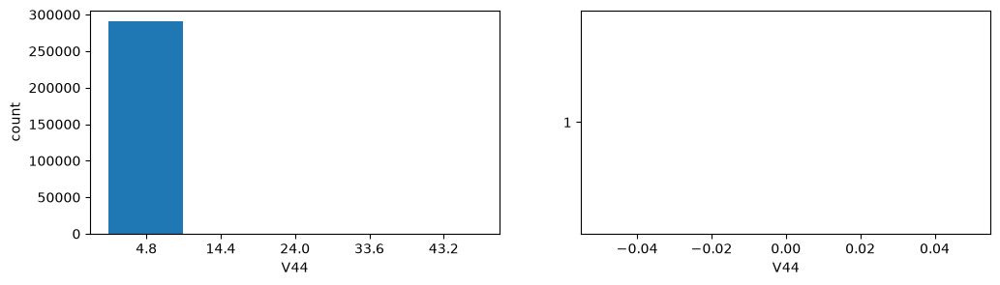

V45


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.048, 9.6]",4.8,290853,99.903481,99.903481
1,"(9.6, 19.2]",14.4,199,0.068353,99.971834
2,"(19.2, 28.8]",24.0,45,0.015457,99.987291
3,"(28.8, 38.4]",33.6,24,0.008244,99.995535
4,"(38.4, 48.0]",43.2,13,0.004465,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


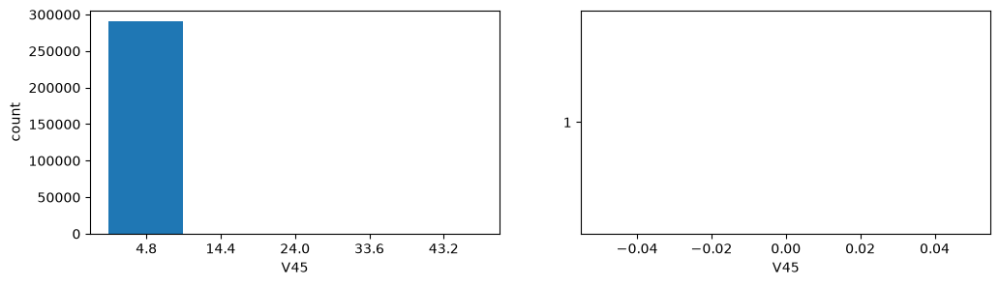

V46


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,284508,97.724072,97.724072
1,"(1.2, 2.4]",1.8,6146,2.111055,99.835127
2,"(2.4, 3.6]",3.0,380,0.130524,99.965652
3,"(3.6, 4.8]",4.2,92,0.031601,99.997252
4,"(4.8, 6.0]",5.4,8,0.002748,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


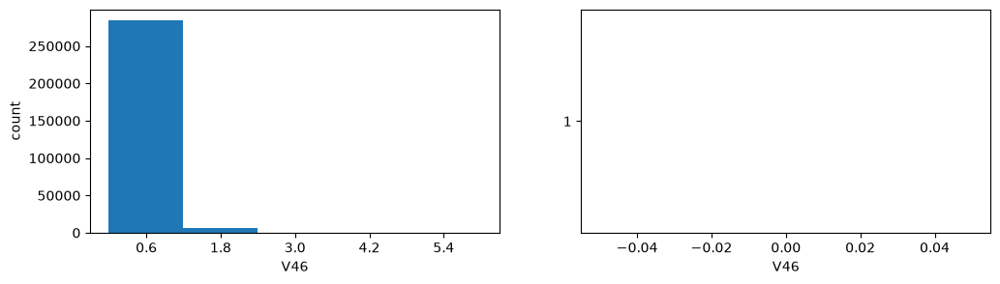

V47


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.012, 2.4]",1.2,290162,99.666133,99.666133
1,"(2.4, 4.8]",3.6,874,0.300205,99.966339
2,"(4.8, 7.2]",6.0,83,0.028509,99.994848
3,"(7.2, 9.6]",8.4,0,0.000000,99.994848
4,"(9.6, 12.0]",10.8,15,0.005152,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


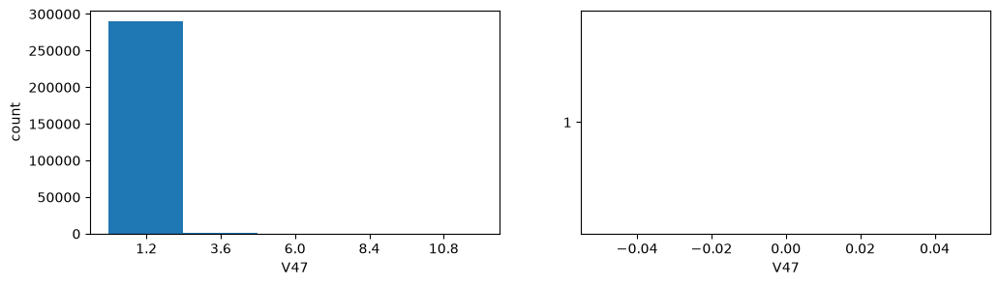

V48


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,288413,99.065379,99.065379
1,"(1.0, 2.0]",1.5,2519,0.865237,99.930616
2,"(2.0, 3.0]",2.5,189,0.064919,99.995535
3,"(3.0, 4.0]",3.5,11,0.003778,99.999313
4,"(4.0, 5.0]",4.5,2,0.000687,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


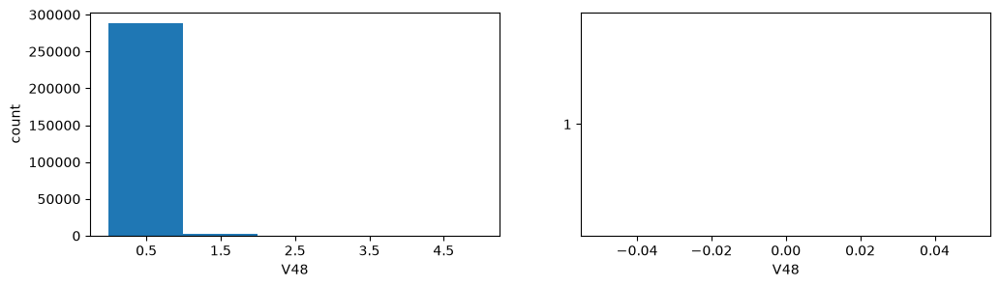

V49


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,285382,98.024277,98.024277
1,"(1.0, 2.0]",1.5,5095,1.750053,99.774331
2,"(2.0, 3.0]",2.5,486,0.166933,99.941264
3,"(3.0, 4.0]",3.5,101,0.034692,99.975956
4,"(4.0, 5.0]",4.5,70,0.024044,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


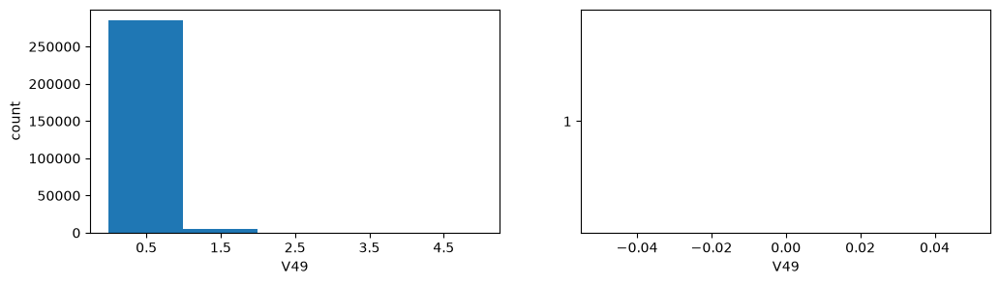

V50


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,290894,99.917564,99.917564
1,"(1.0, 2.0]",1.5,181,0.062171,99.979734
2,"(2.0, 3.0]",2.5,43,0.014770,99.994504
3,"(3.0, 4.0]",3.5,13,0.004465,99.998970
4,"(4.0, 5.0]",4.5,3,0.001030,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


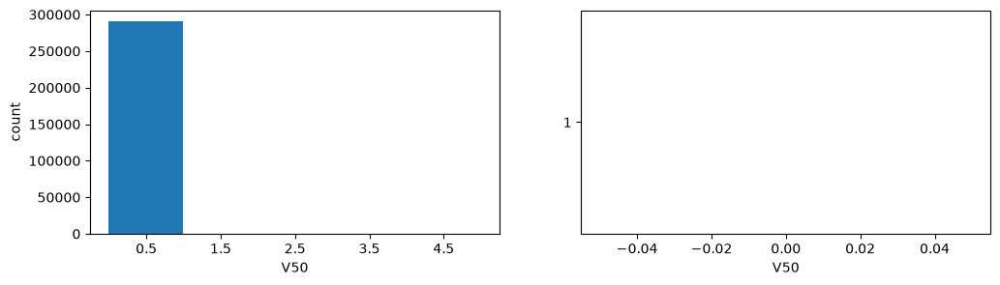

V51


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,288666,99.152280,99.152280
1,"(1.2, 2.4]",1.8,2090,0.717882,99.870163
2,"(2.4, 3.6]",3.0,311,0.106824,99.976987
3,"(3.6, 4.8]",4.2,59,0.020266,99.997252
4,"(4.8, 6.0]",5.4,8,0.002748,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


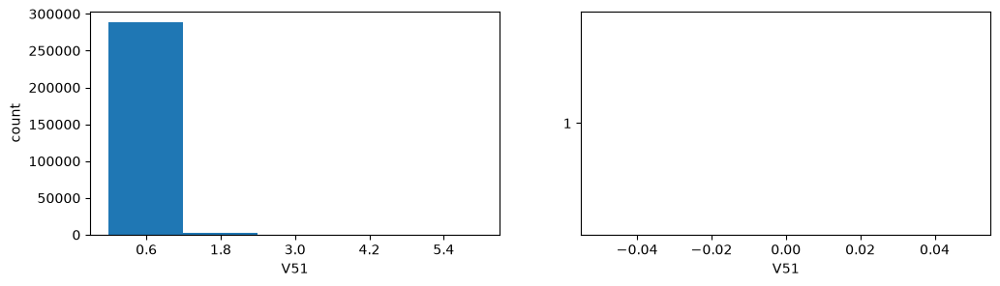

V52


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.012, 2.4]",1.2,290441,99.761965,99.761965
1,"(2.4, 4.8]",3.6,627,0.215365,99.977330
2,"(4.8, 7.2]",6.0,51,0.017518,99.994848
3,"(7.2, 9.6]",8.4,0,0.000000,99.994848
4,"(9.6, 12.0]",10.8,15,0.005152,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


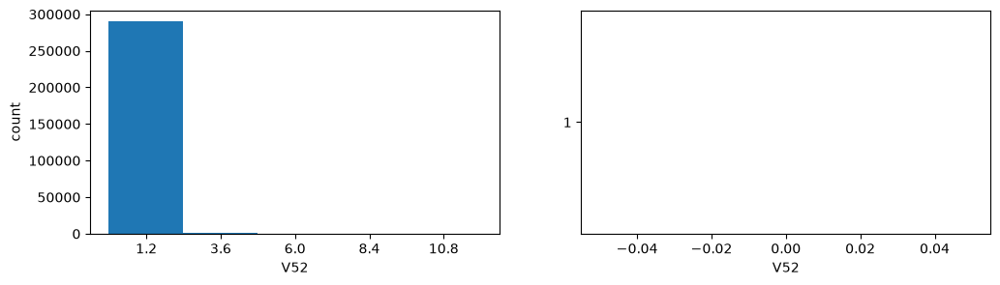

V53


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,348515,99.340986,99.340986
1,"(1.0, 2.0]",1.5,2239,0.638206,99.979192
2,"(2.0, 3.0]",2.5,65,0.018528,99.997720
3,"(3.0, 4.0]",3.5,1,0.000285,99.998005
4,"(4.0, 5.0]",4.5,7,0.001995,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


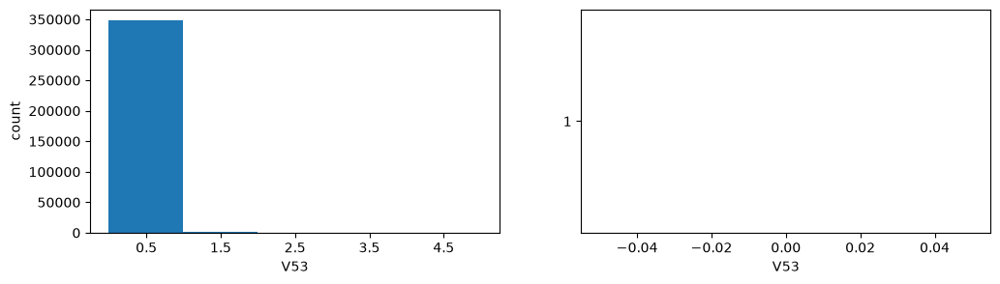

V54


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,344196,98.109895,98.109895
1,"(1.2, 2.4]",1.8,6244,1.779795,99.889689
2,"(2.4, 3.6]",3.0,305,0.086937,99.976627
3,"(3.6, 4.8]",4.2,65,0.018528,99.995154
4,"(4.8, 6.0]",5.4,17,0.004846,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


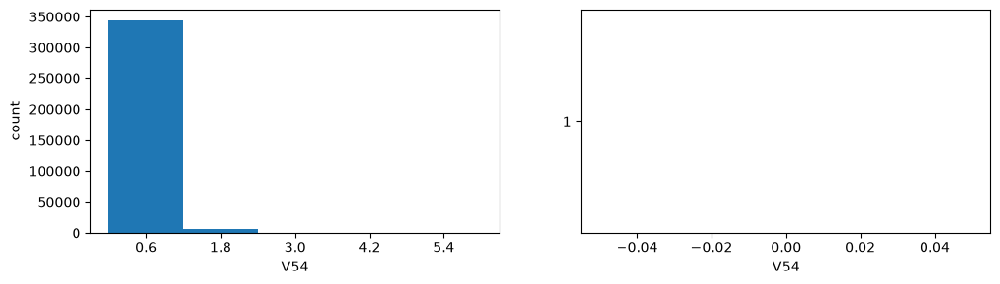

V55


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.017, 3.4]",1.7,349074,99.500324,99.500324
1,"(3.4, 6.8]",5.1,1481,0.422145,99.922469
2,"(6.8, 10.2]",8.5,231,0.065844,99.988313
3,"(10.2, 13.6]",11.9,34,0.009691,99.998005
4,"(13.6, 17.0]",15.3,7,0.001995,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


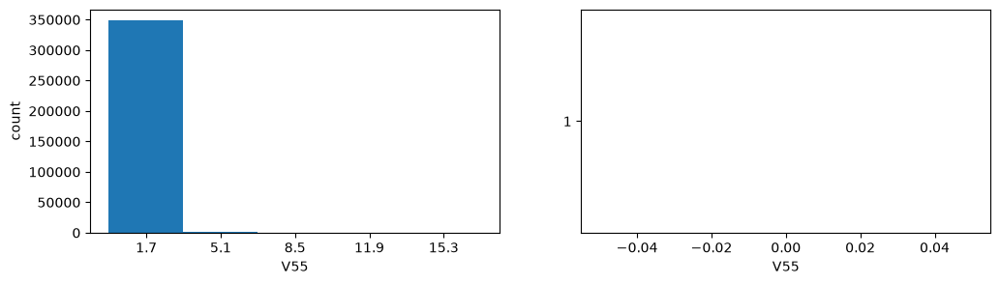

V56


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.029, 5.8]",2.9,350054,99.779663,99.779663
1,"(5.8, 11.6]",8.7,705,0.200954,99.980617
2,"(11.6, 17.4]",14.5,57,0.016247,99.996865
3,"(17.4, 23.2]",20.3,0,0.000000,99.996865
4,"(23.2, 29.0]",26.1,11,0.003135,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


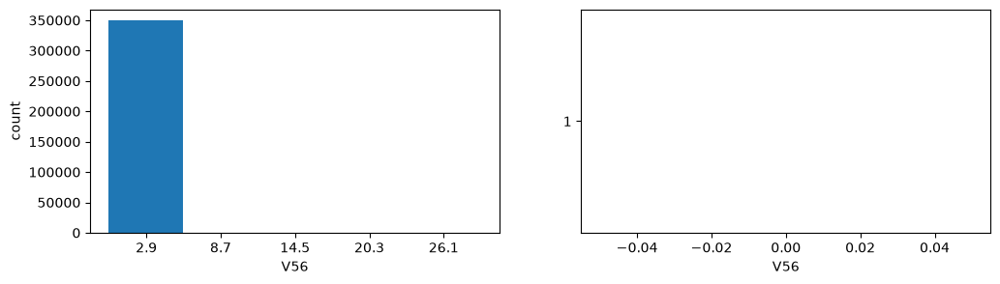

V57


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,349406,99.594957,99.594957
1,"(1.2, 2.4]",1.8,1295,0.369128,99.964085
2,"(2.4, 3.6]",3.0,107,0.030499,99.994584
3,"(3.6, 4.8]",4.2,16,0.004561,99.999145
4,"(4.8, 6.0]",5.4,3,0.000855,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


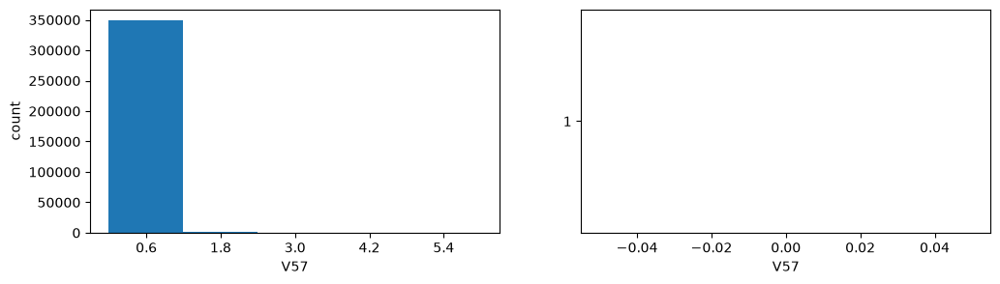

V58


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,348737,99.404265,99.404265
1,"(1.4, 2.8]",2.1,1870,0.533026,99.937291
2,"(2.8, 4.2]",3.5,216,0.061569,99.998860
3,"(4.2, 5.6]",4.9,2,0.000570,99.999430
4,"(5.6, 7.0]",6.3,2,0.000570,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


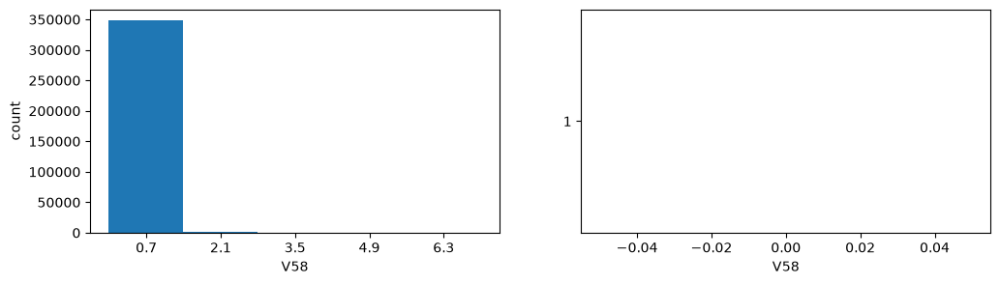

V59


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.012, 2.4]",1.2,350344,99.862325,99.862325
1,"(2.4, 4.8]",3.6,388,0.110596,99.972921
2,"(4.8, 7.2]",6.0,76,0.021663,99.994584
3,"(7.2, 9.6]",8.4,11,0.003135,99.997720
4,"(9.6, 12.0]",10.8,8,0.002280,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


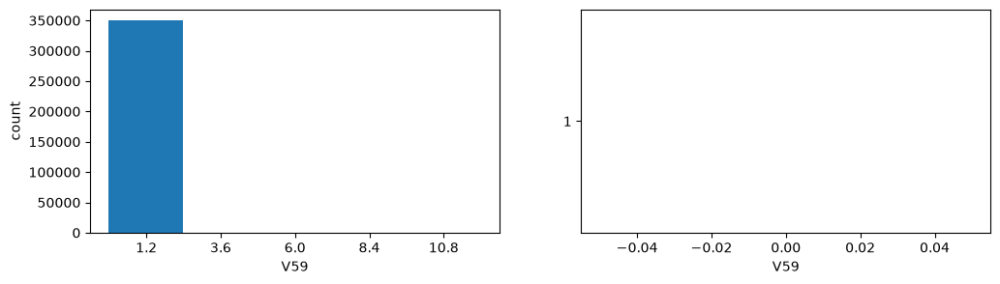

V60


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.012, 2.4]",1.2,349958,99.752300,99.752300
1,"(2.4, 4.8]",3.6,691,0.196963,99.949263
2,"(4.8, 7.2]",6.0,144,0.041046,99.990309
3,"(7.2, 9.6]",8.4,21,0.005986,99.996294
4,"(9.6, 12.0]",10.8,13,0.003706,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


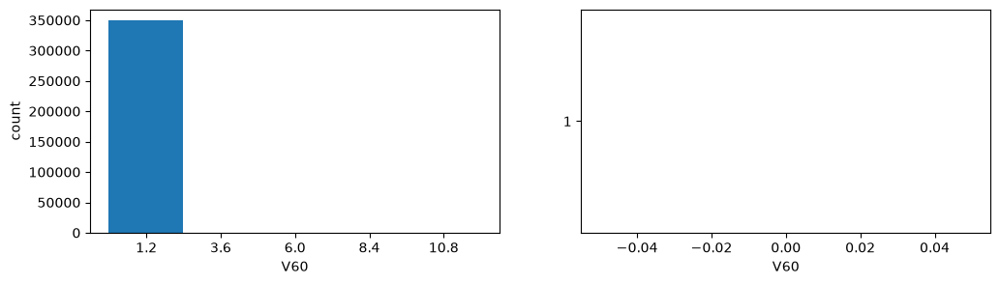

V61


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,343670,97.959963,97.959963
1,"(1.2, 2.4]",1.8,6672,1.901792,99.861755
2,"(2.4, 3.6]",3.0,438,0.124848,99.986603
3,"(3.6, 4.8]",4.2,36,0.010261,99.996865
4,"(4.8, 6.0]",5.4,11,0.003135,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


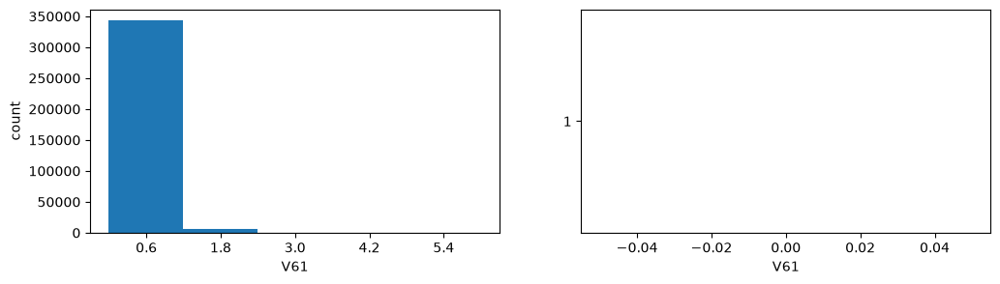

V62


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,335938,95.756028,95.756028
1,"(1.4, 2.8]",2.1,13262,3.780211,99.536239
2,"(2.8, 4.2]",3.5,1553,0.442668,99.978907
3,"(4.2, 5.6]",4.9,32,0.009121,99.988028
4,"(5.6, 7.0]",6.3,42,0.011972,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


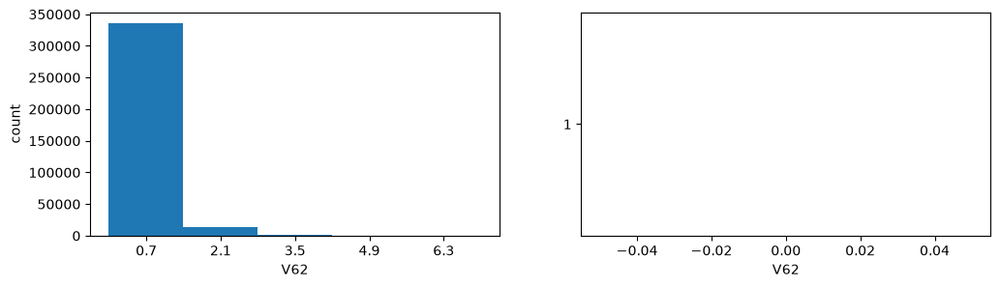

V63


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,349269,99.555906,99.555906
1,"(1.4, 2.8]",2.1,1351,0.385090,99.940997
2,"(2.8, 4.2]",3.5,187,0.053303,99.994299
3,"(4.2, 5.6]",4.9,8,0.002280,99.996580
4,"(5.6, 7.0]",6.3,12,0.003420,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


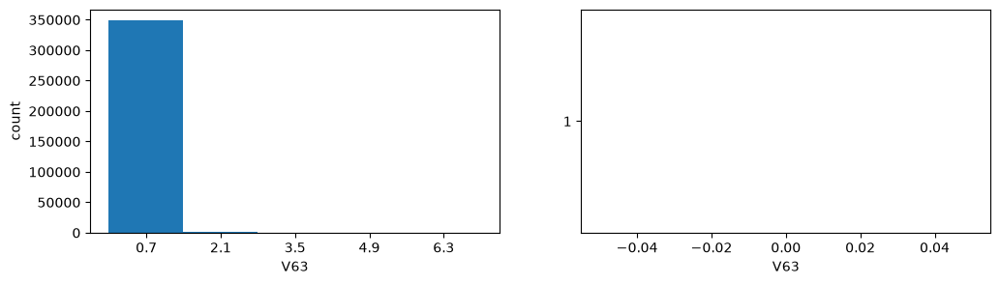

V64


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,346808,98.854421,98.854421
1,"(1.4, 2.8]",2.1,3397,0.968284,99.822705
2,"(2.8, 4.2]",3.5,536,0.152782,99.975486
3,"(4.2, 5.6]",4.9,28,0.007981,99.983468
4,"(5.6, 7.0]",6.3,58,0.016532,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


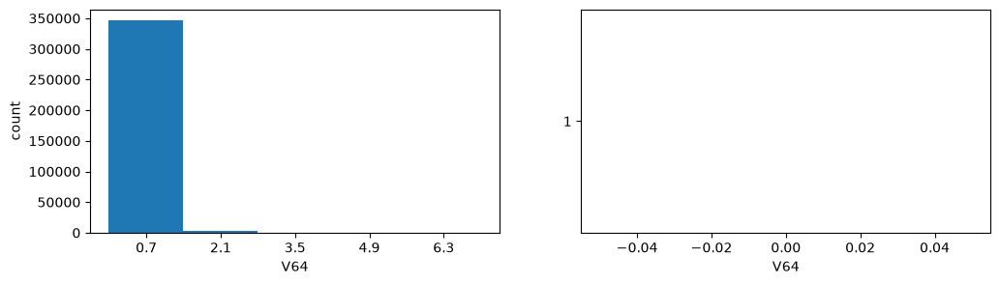

V65


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.001, 0.2]",0.1,91,0.025939,0.025939
1,"(0.2, 0.4]",0.3,0,0.000000,0.025939
2,"(0.4, 0.6]",0.5,0,0.000000,0.025939
3,"(0.6, 0.8]",0.7,0,0.000000,0.025939
4,"(0.8, 1.0]",0.9,350736,99.974061,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


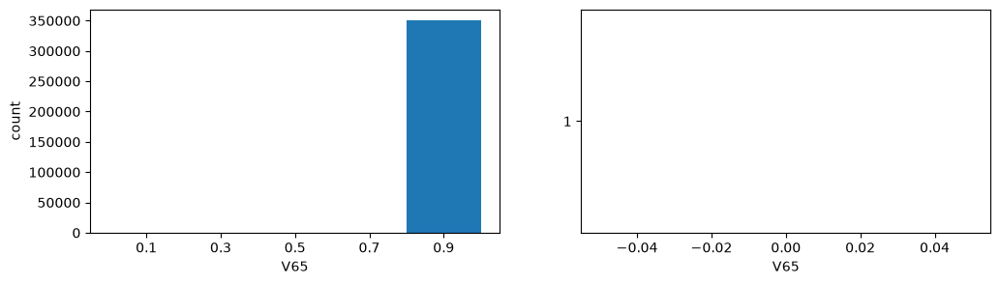

V66


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,346761,98.841024,98.841024
1,"(1.0, 2.0]",1.5,3838,1.093986,99.935011
2,"(2.0, 3.0]",2.5,197,0.056153,99.991164
3,"(3.0, 4.0]",3.5,28,0.007981,99.999145
4,"(4.0, 5.0]",4.5,3,0.000855,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


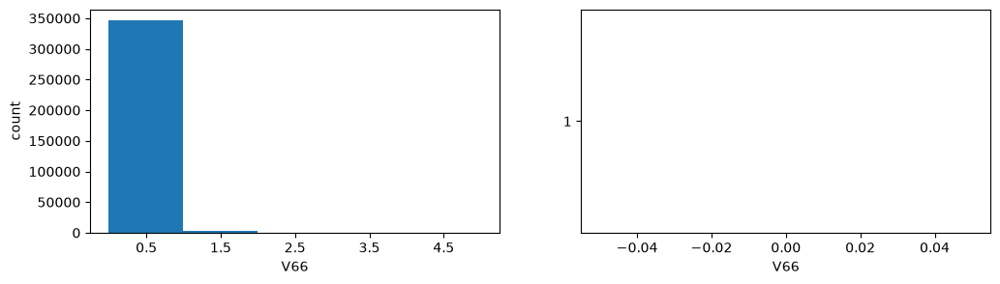

V67


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.008, 1.6]",0.8,342578,97.648699,97.648699
1,"(1.6, 3.2]",2.4,8179,2.331348,99.980047
2,"(3.2, 4.8]",4.0,56,0.015962,99.996009
3,"(4.8, 6.4]",5.6,10,0.002850,99.998860
4,"(6.4, 8.0]",7.2,4,0.001140,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


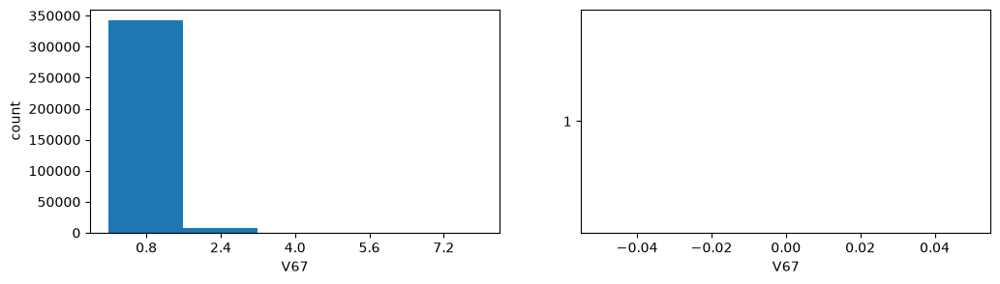

V68


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.002, 0.4]",0.2,350653,99.950403,99.950403
1,"(0.4, 0.8]",0.6,0,0.000000,99.950403
2,"(0.8, 1.2]",1.0,173,0.049312,99.999715
3,"(1.2, 1.6]",1.4,0,0.000000,99.999715
4,"(1.6, 2.0]",1.8,1,0.000285,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


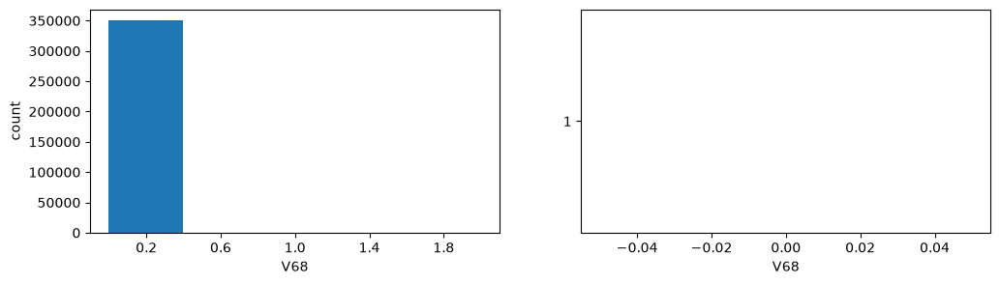

V69


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,347161,98.955041,98.955041
1,"(1.0, 2.0]",1.5,3330,0.949186,99.904226
2,"(2.0, 3.0]",2.5,286,0.081522,99.985748
3,"(3.0, 4.0]",3.5,48,0.013682,99.999430
4,"(4.0, 5.0]",4.5,2,0.000570,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


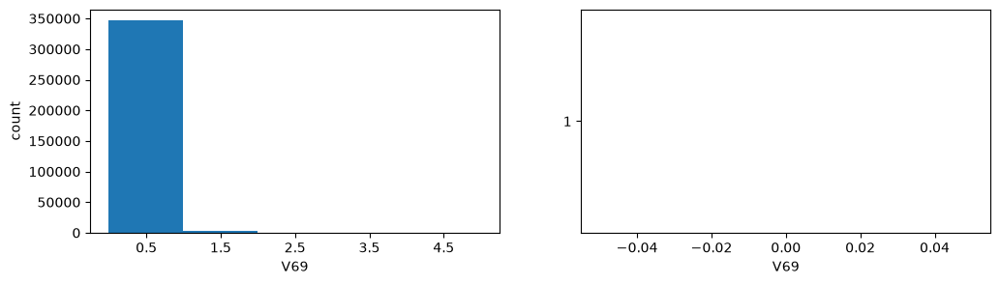

V70


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,343139,97.808607,97.808607
1,"(1.2, 2.4]",1.8,6579,1.875283,99.683890
2,"(2.4, 3.6]",3.0,833,0.237439,99.921329
3,"(3.6, 4.8]",4.2,164,0.046747,99.968075
4,"(4.8, 6.0]",5.4,112,0.031925,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


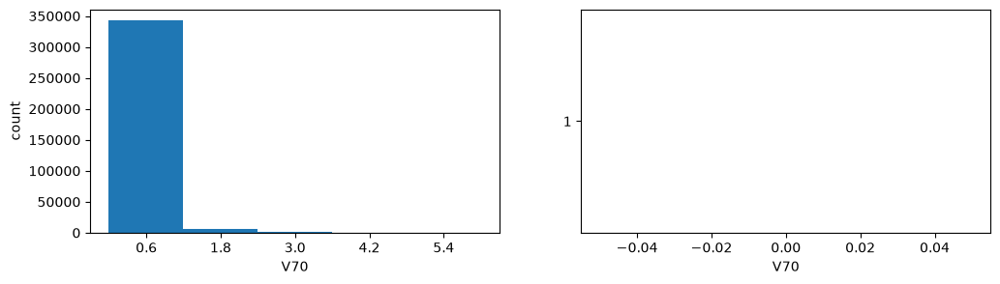

V71


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,349246,99.549351,99.549351
1,"(1.2, 2.4]",1.8,1377,0.392501,99.941852
2,"(2.4, 3.6]",3.0,178,0.050737,99.992589
3,"(3.6, 4.8]",4.2,23,0.006556,99.999145
4,"(4.8, 6.0]",5.4,3,0.000855,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


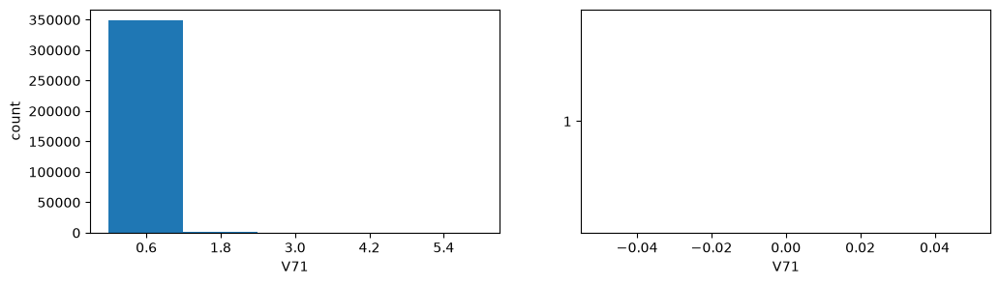

V72


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,348539,99.347827,99.347827
1,"(1.4, 2.8]",2.1,1957,0.557825,99.905652
2,"(2.8, 4.2]",3.5,305,0.086937,99.992589
3,"(4.2, 5.6]",4.9,24,0.006841,99.999430
4,"(5.6, 7.0]",6.3,2,0.000570,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


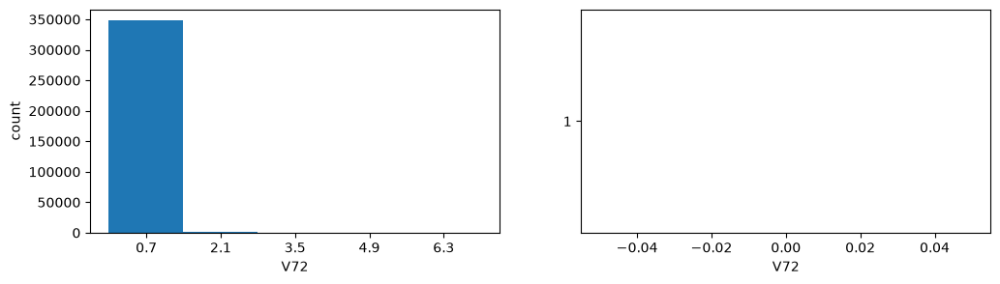

V73


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,348740,99.405120,99.405120
1,"(1.0, 2.0]",1.5,1886,0.537587,99.942707
2,"(2.0, 3.0]",2.5,173,0.049312,99.992019
3,"(3.0, 4.0]",3.5,25,0.007126,99.999145
4,"(4.0, 5.0]",4.5,3,0.000855,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


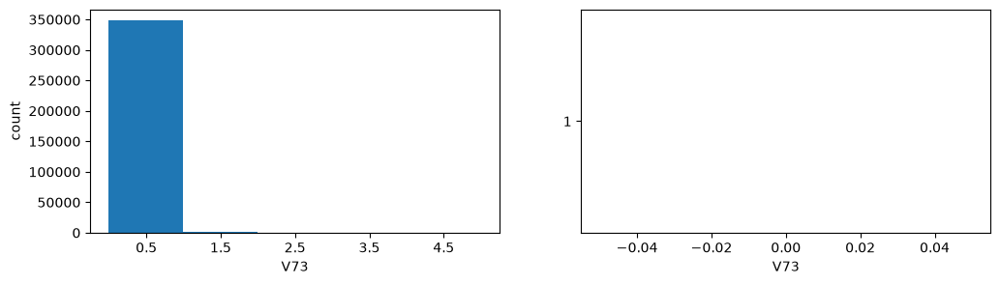

V74


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.008, 1.6]",0.8,347389,99.020030,99.020030
1,"(1.6, 3.2]",2.4,3381,0.963723,99.983753
2,"(3.2, 4.8]",4.0,44,0.012542,99.996294
3,"(4.8, 6.4]",5.6,9,0.002565,99.998860
4,"(6.4, 8.0]",7.2,4,0.001140,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


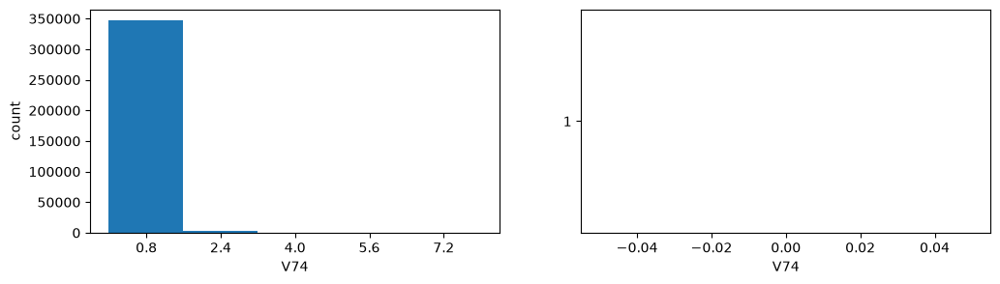

V75


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.004, 0.8]",0.4,169727,49.193095,49.193095
1,"(0.8, 1.6]",1.2,172874,50.105211,99.298306
2,"(1.6, 2.4]",2.0,2318,0.671841,99.970147
3,"(2.4, 3.2]",2.8,102,0.029563,99.999710
4,"(3.2, 4.0]",3.6,1,0.000290,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


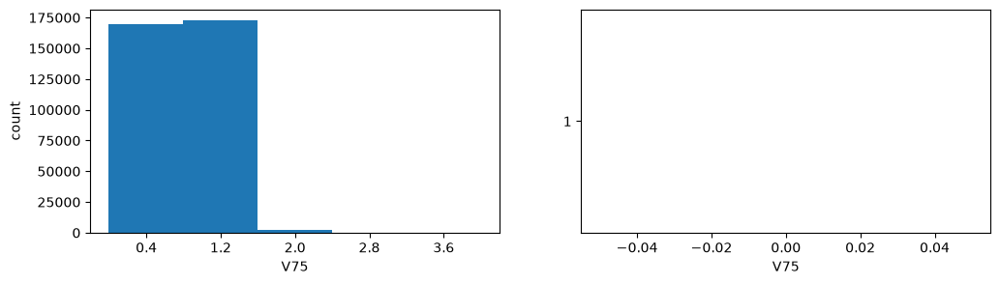

V76


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,338446,98.094035,98.094035
1,"(1.2, 2.4]",1.8,6093,1.765974,99.860009
2,"(2.4, 3.6]",3.0,438,0.126948,99.986957
3,"(3.6, 4.8]",4.2,36,0.010434,99.997391
4,"(4.8, 6.0]",5.4,9,0.002609,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


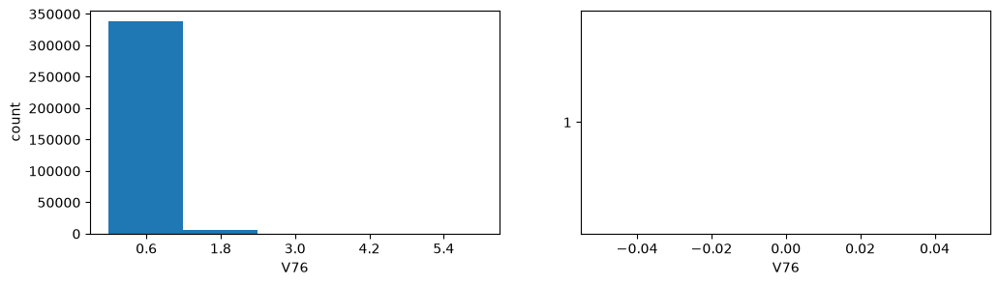

V77


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.03, 6.0]",3.0,344331,99.799723,99.799723
1,"(6.0, 12.0]",9.0,609,0.176510,99.976233
2,"(12.0, 18.0]",15.0,69,0.019999,99.996232
3,"(18.0, 24.0]",21.0,7,0.002029,99.998261
4,"(24.0, 30.0]",27.0,6,0.001739,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


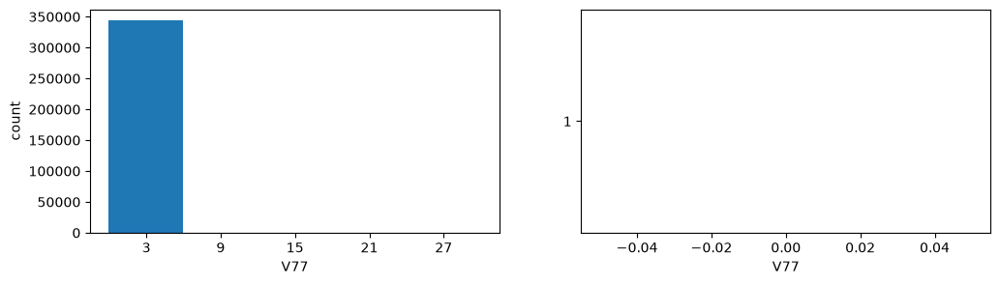

V78


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.03, 6.0]",3.0,344135,99.742915,99.742915
1,"(6.0, 12.0]",9.0,709,0.205494,99.948409
2,"(12.0, 18.0]",15.0,104,0.030143,99.978552
3,"(18.0, 24.0]",21.0,57,0.016521,99.995073
4,"(24.0, 30.0]",27.0,17,0.004927,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


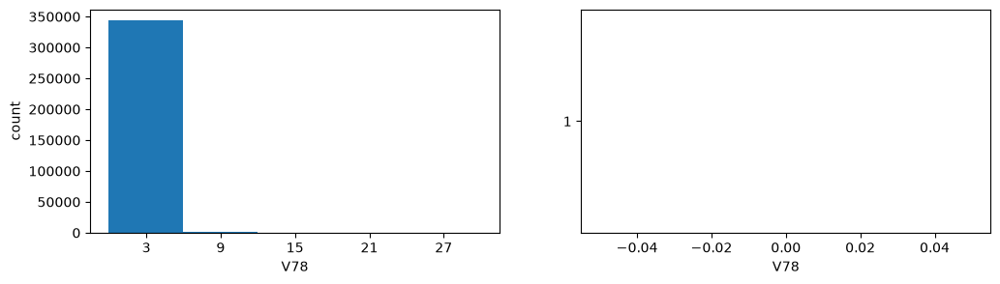

V79


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,343220,99.477714,99.477714
1,"(1.4, 2.8]",2.1,1476,0.427799,99.905513
2,"(2.8, 4.2]",3.5,316,0.091588,99.997102
3,"(4.2, 5.6]",4.9,7,0.002029,99.999130
4,"(5.6, 7.0]",6.3,3,0.000870,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


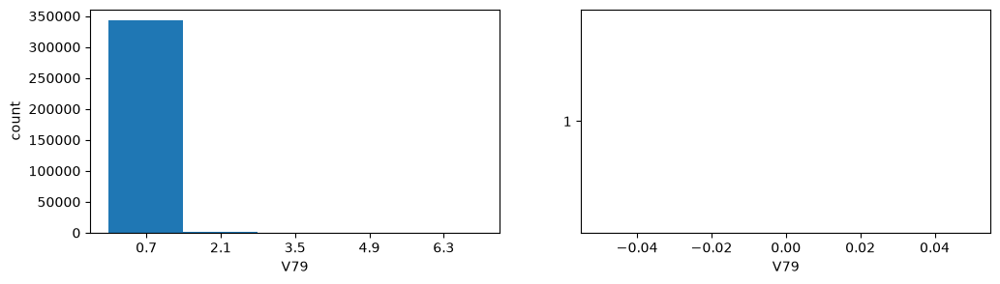

V80


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.019, 3.8]",1.9,344622,99.884065,99.884065
1,"(3.8, 7.6]",5.7,353,0.102312,99.986378
2,"(7.6, 11.4]",9.5,39,0.011304,99.997681
3,"(11.4, 15.2]",13.3,4,0.001159,99.998841
4,"(15.2, 19.0]",17.1,4,0.001159,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


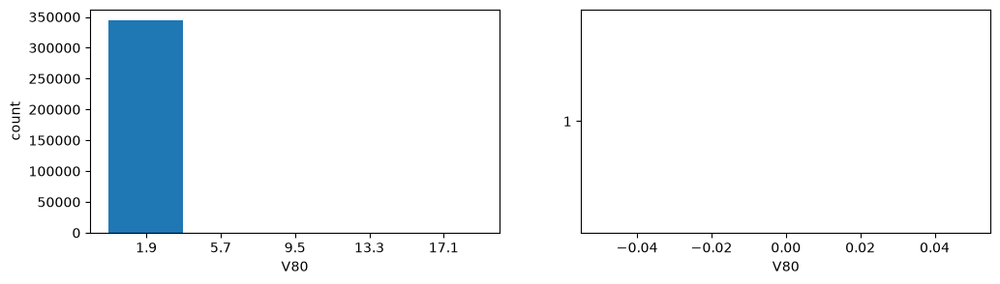

V81


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.019, 3.8]",1.9,344441,99.831605,99.831605
1,"(3.8, 7.6]",5.7,516,0.149556,99.981161
2,"(7.6, 11.4]",9.5,56,0.016231,99.997391
3,"(11.4, 15.2]",13.3,5,0.001449,99.998841
4,"(15.2, 19.0]",17.1,4,0.001159,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


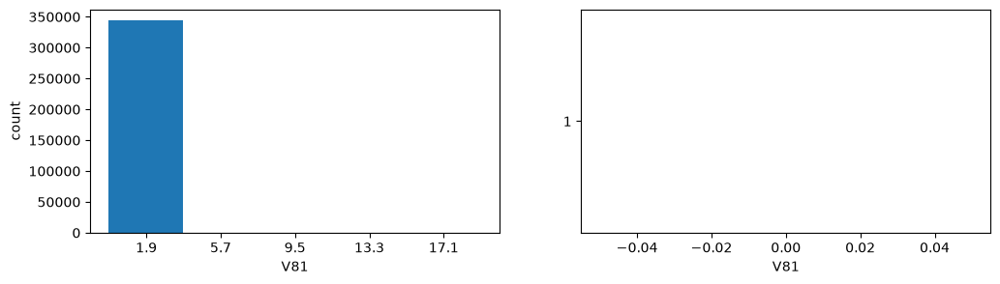

V82


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,337963,97.954044,97.954044
1,"(1.4, 2.8]",2.1,6591,1.910313,99.864356
2,"(2.8, 4.2]",3.5,460,0.133325,99.997681
3,"(4.2, 5.6]",4.9,5,0.001449,99.999130
4,"(5.6, 7.0]",6.3,3,0.000870,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


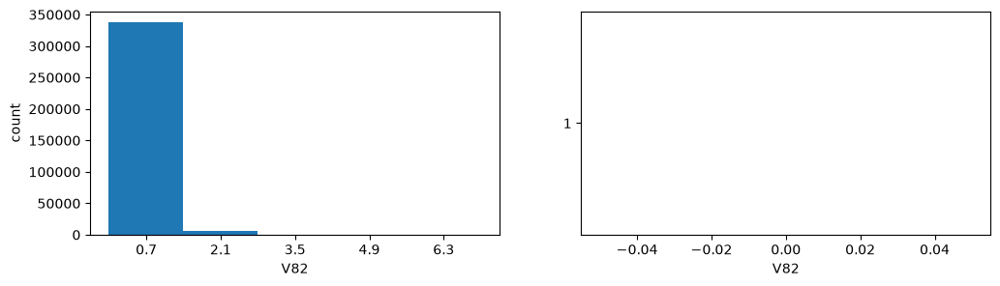

V83


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,330420,95.767806,95.767806
1,"(1.4, 2.8]",2.1,12957,3.755413,99.523219
2,"(2.8, 4.2]",3.5,1585,0.459391,99.982610
3,"(4.2, 5.6]",4.9,46,0.013332,99.995942
4,"(5.6, 7.0]",6.3,14,0.004058,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


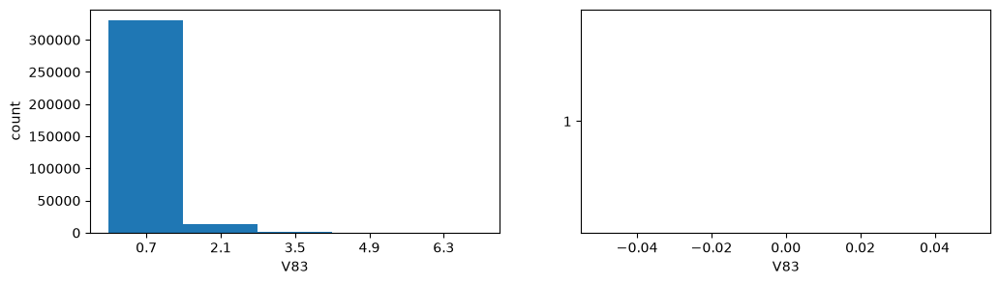

V84


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,343504,99.560028,99.560028
1,"(1.4, 2.8]",2.1,1340,0.388381,99.948409
2,"(2.8, 4.2]",3.5,164,0.047533,99.995942
3,"(4.2, 5.6]",4.9,3,0.000870,99.996812
4,"(5.6, 7.0]",6.3,11,0.003188,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


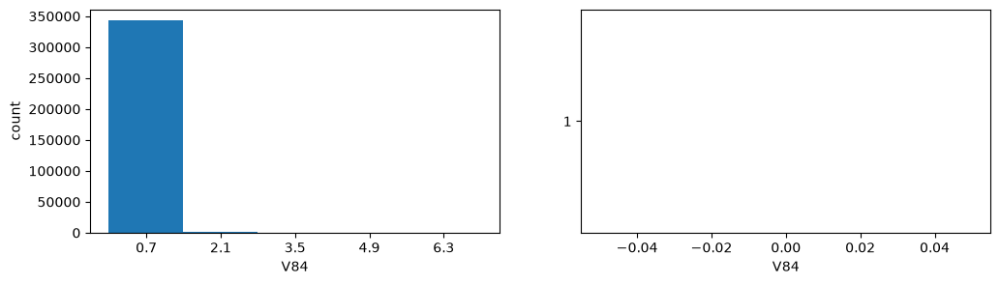

V85


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,340887,98.801526,98.801526
1,"(1.4, 2.8]",2.1,3333,0.966025,99.767551
2,"(2.8, 4.2]",3.5,763,0.221145,99.988696
3,"(4.2, 5.6]",4.9,28,0.008115,99.996812
4,"(5.6, 7.0]",6.3,11,0.003188,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


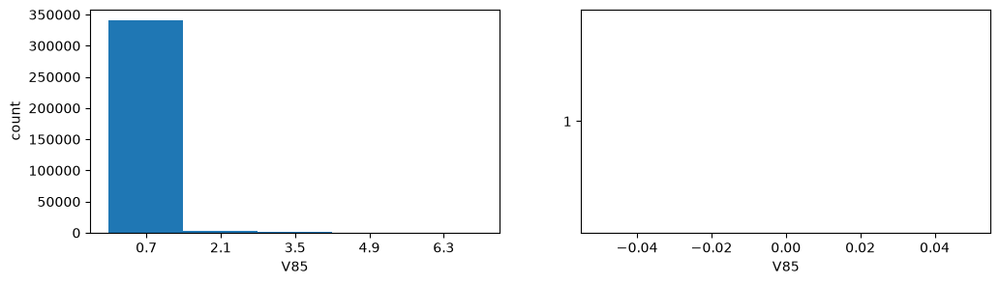

V86


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.03, 6.0]",3.0,344698,99.906093,99.906093
1,"(6.0, 12.0]",9.0,270,0.078256,99.984349
2,"(12.0, 18.0]",15.0,41,0.011883,99.996232
3,"(18.0, 24.0]",21.0,7,0.002029,99.998261
4,"(24.0, 30.0]",27.0,6,0.001739,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


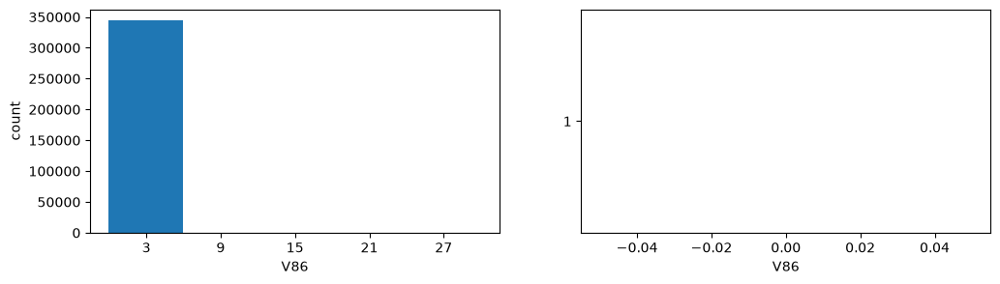

V87


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.03, 6.0]",3.0,344574,99.870153,99.870153
1,"(6.0, 12.0]",9.0,367,0.106370,99.976523
2,"(12.0, 18.0]",15.0,45,0.013043,99.989566
3,"(18.0, 24.0]",21.0,30,0.008695,99.998261
4,"(24.0, 30.0]",27.0,6,0.001739,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


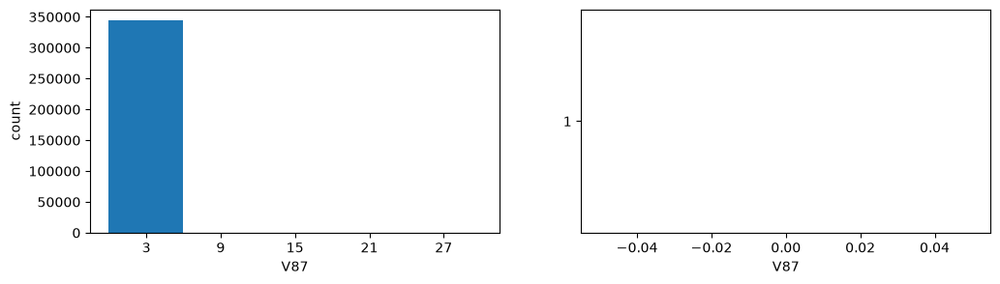

V88


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.001, 0.2]",0.1,222,0.064344,0.064344
1,"(0.2, 0.4]",0.3,0,0.000000,0.064344
2,"(0.4, 0.6]",0.5,0,0.000000,0.064344
3,"(0.6, 0.8]",0.7,0,0.000000,0.064344
4,"(0.8, 1.0]",0.9,344800,99.935656,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


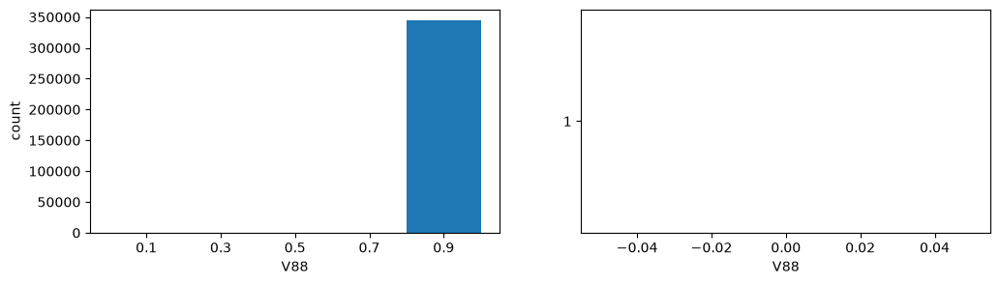

V89


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.002, 0.4]",0.2,344736,99.917107,99.917107
1,"(0.4, 0.8]",0.6,0,0.000000,99.917107
2,"(0.8, 1.2]",1.0,278,0.080575,99.997681
3,"(1.2, 1.6]",1.4,0,0.000000,99.997681
4,"(1.6, 2.0]",1.8,8,0.002319,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


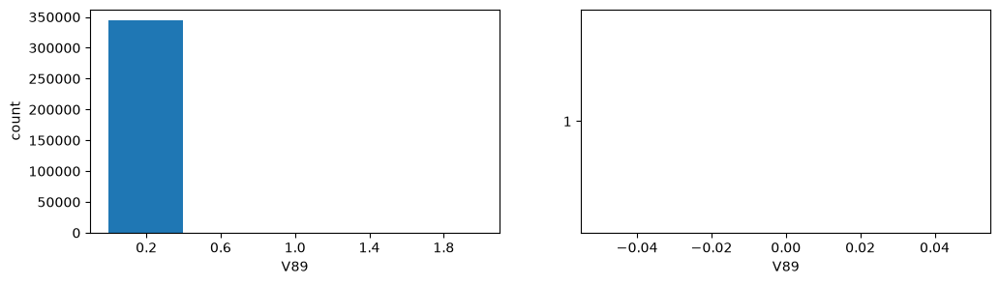

V90


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,341393,98.948183,98.948183
1,"(1.0, 2.0]",1.5,3301,0.956751,99.904934
2,"(2.0, 3.0]",2.5,272,0.078836,99.983769
3,"(3.0, 4.0]",3.5,52,0.015072,99.998841
4,"(4.0, 5.0]",4.5,4,0.001159,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


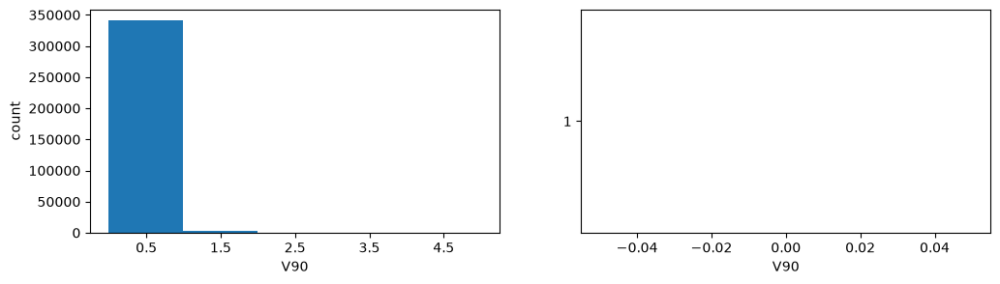

V91


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,336969,97.665946,97.665946
1,"(1.2, 2.4]",1.8,6934,2.009727,99.675673
2,"(2.4, 3.6]",3.0,715,0.207233,99.882906
3,"(3.6, 4.8]",4.2,252,0.073039,99.955945
4,"(4.8, 6.0]",5.4,152,0.044055,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


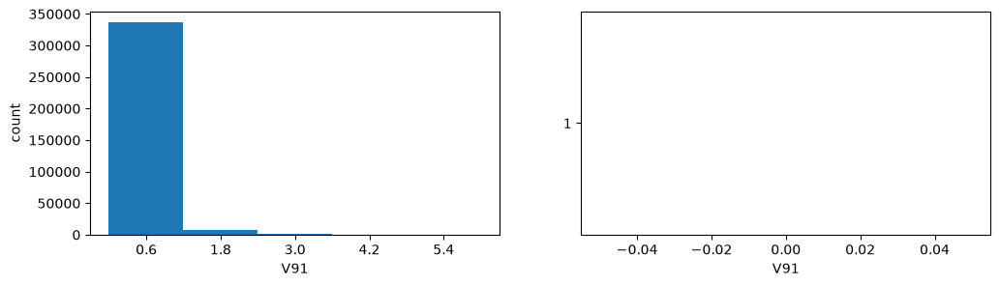

V92


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,343468,99.549594,99.549594
1,"(1.4, 2.8]",2.1,1288,0.373310,99.922903
2,"(2.8, 4.2]",3.5,258,0.074778,99.997681
3,"(4.2, 5.6]",4.9,5,0.001449,99.999130
4,"(5.6, 7.0]",6.3,3,0.000870,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


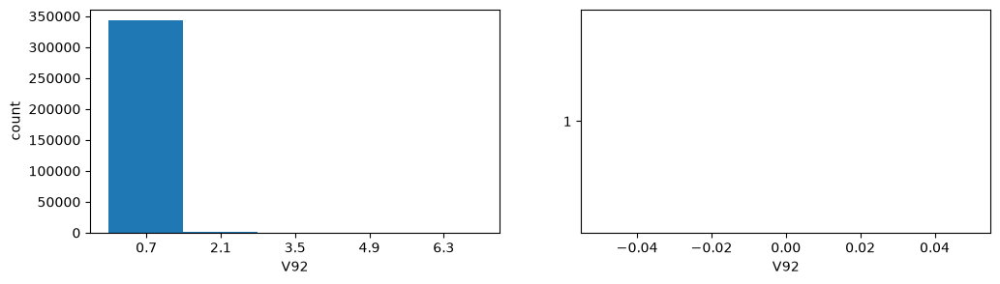

V93


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,342749,99.341201,99.341201
1,"(1.4, 2.8]",2.1,1838,0.532720,99.873921
2,"(2.8, 4.2]",3.5,398,0.115355,99.989276
3,"(4.2, 5.6]",4.9,34,0.009854,99.999130
4,"(5.6, 7.0]",6.3,3,0.000870,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


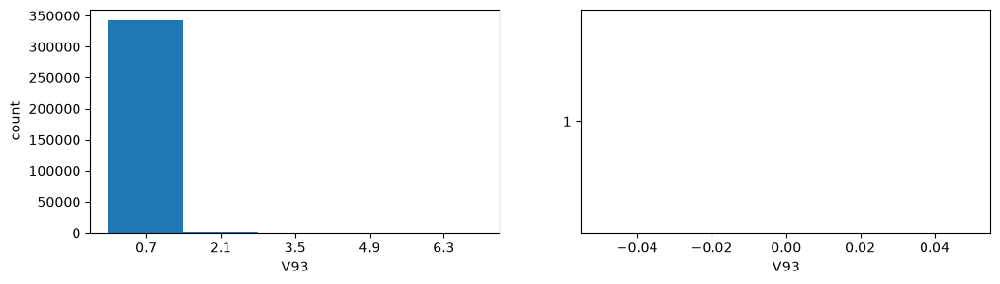

V94


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.001, 0.2]",0.1,295695,85.703231,85.703231
1,"(0.2, 0.4]",0.3,0,0.000000,85.703231
2,"(0.4, 0.6]",0.5,0,0.000000,85.703231
3,"(0.6, 0.8]",0.7,0,0.000000,85.703231
4,"(0.8, 1.0]",0.9,49327,14.296769,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


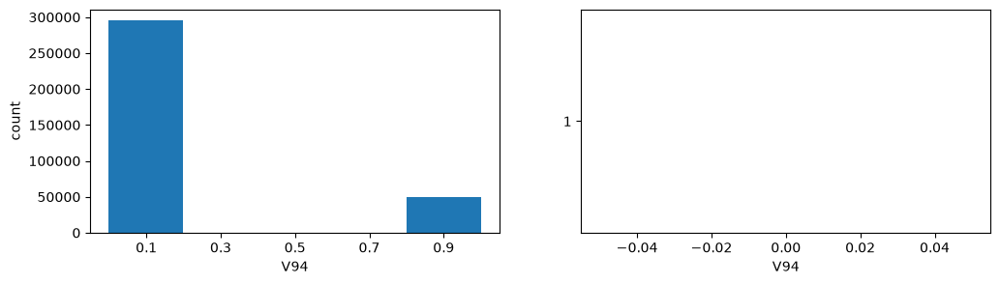

V95


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.027, 5.4]",2.7,412003,99.667375,99.667375
1,"(5.4, 10.8]",8.1,1163,0.281341,99.948715
2,"(10.8, 16.2]",13.5,164,0.039673,99.988388
3,"(16.2, 21.6]",18.9,36,0.008709,99.997097
4,"(21.6, 27.0]",24.3,12,0.002903,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


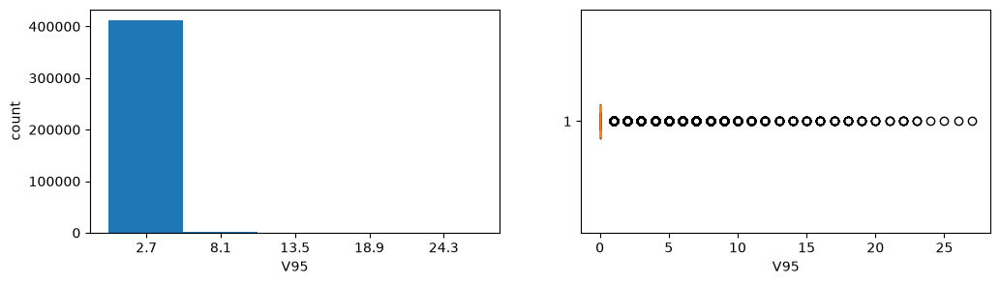

V96


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.126, 25.2]",12.5,411247,99.484491,99.484491
1,"(25.2, 50.4]",37.8,1328,0.321256,99.805747
2,"(50.4, 75.6]",63.0,436,0.105472,99.911219
3,"(75.6, 100.8]",88.2,264,0.063864,99.975083
4,"(100.8, 126.0]",113.4,103,0.024917,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


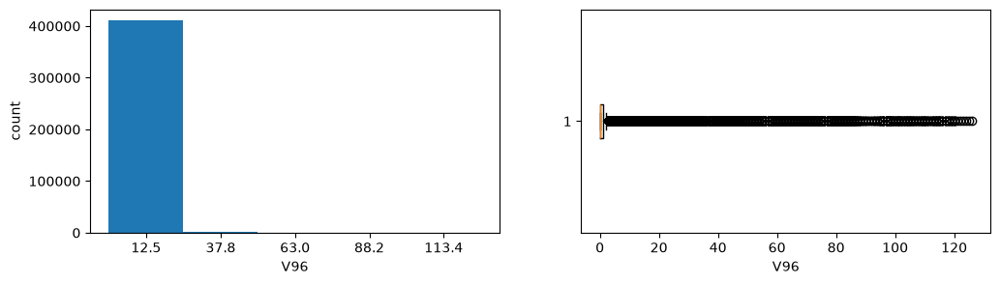

V97


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.048, 9.6]",4.8,410791,99.374181,99.374181
1,"(9.6, 19.2]",14.4,1977,0.478255,99.852435
2,"(19.2, 28.8]",24.0,437,0.105714,99.958150
3,"(28.8, 38.4]",33.6,130,0.031448,99.989598
4,"(38.4, 48.0]",43.2,43,0.010402,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


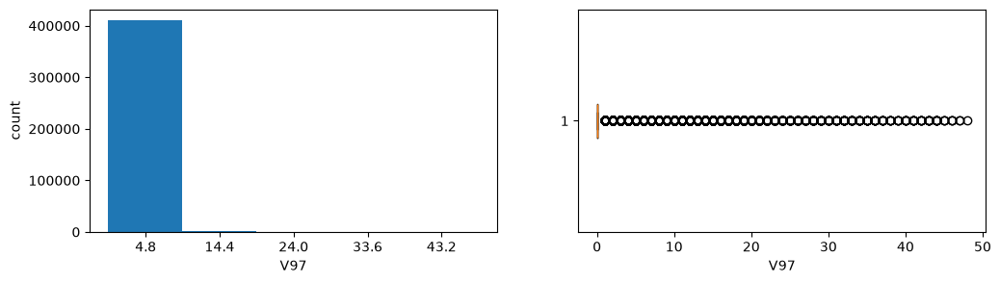

V98


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.012, 2.4]",1.2,412818,99.864531,99.864531
1,"(2.4, 4.8]",3.6,489,0.118294,99.982824
2,"(4.8, 7.2]",6.0,62,0.014998,99.997823
3,"(7.2, 9.6]",8.4,6,0.001451,99.999274
4,"(9.6, 12.0]",10.8,3,0.000726,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


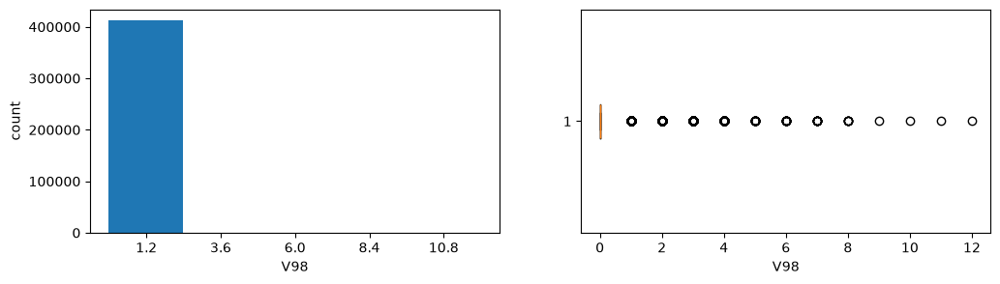

V99


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.088, 17.6]",8.8,412477,99.782040,99.782040
1,"(17.6, 35.2]",26.4,614,0.148532,99.930572
2,"(35.2, 52.8]",44.0,110,0.026610,99.957182
3,"(52.8, 70.4]",61.6,81,0.019595,99.976777
4,"(70.4, 88.0]",79.2,96,0.023223,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


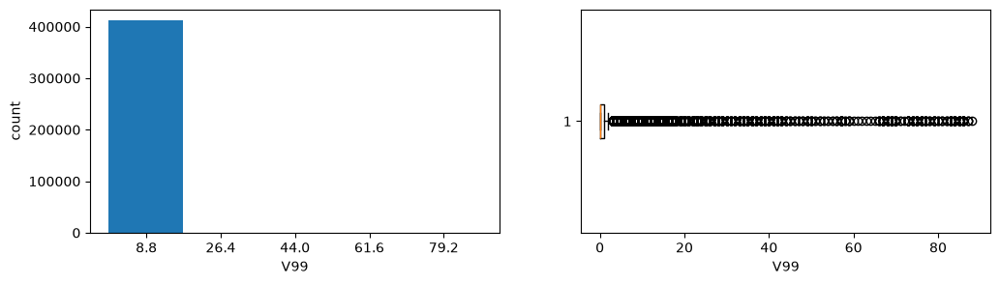

V100


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.028, 5.6]",2.8,412315,99.742850,99.742850
1,"(5.6, 11.2]",8.4,729,0.176352,99.919202
2,"(11.2, 16.8]",14.0,115,0.027820,99.947022
3,"(16.8, 22.4]",19.6,187,0.045237,99.992259
4,"(22.4, 28.0]",25.2,32,0.007741,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


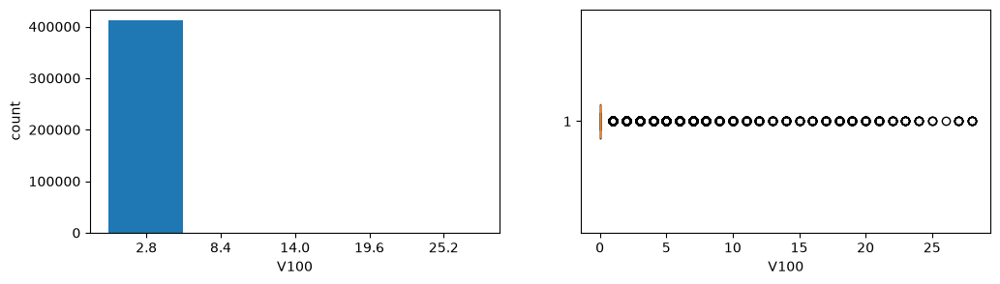

V101


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.022, 4.4]",2.2,412122,99.696162,99.696162
1,"(4.4, 8.8]",6.6,1058,0.255940,99.952102
2,"(8.8, 13.2]",11.0,155,0.037496,99.989598
3,"(13.2, 17.6]",15.4,31,0.007499,99.997097
4,"(17.6, 22.0]",19.8,12,0.002903,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


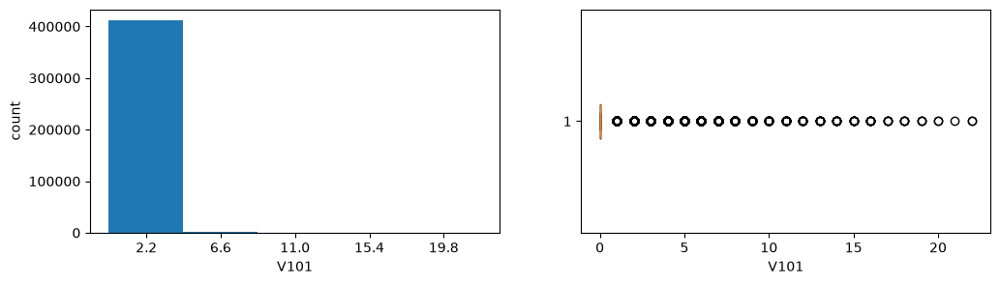

V102


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.115, 23.0]",11.4,412326,99.745511,99.745511
1,"(23.0, 46.0]",34.5,628,0.151919,99.897430
2,"(46.0, 69.0]",57.5,309,0.074750,99.972180
3,"(69.0, 92.0]",80.5,54,0.013063,99.985244
4,"(92.0, 115.0]",103.5,61,0.014756,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


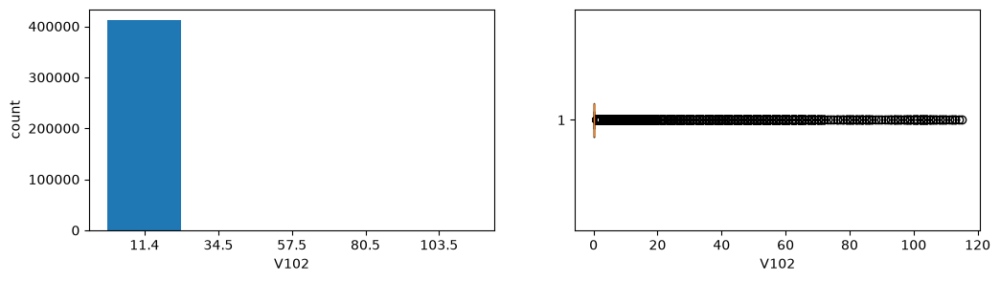

V103


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.045, 9.0]",4.5,412232,99.722772,99.722772
1,"(9.0, 18.0]",13.5,848,0.205139,99.927911
2,"(18.0, 27.0]",22.5,218,0.052736,99.980647
3,"(27.0, 36.0]",31.5,58,0.014031,99.994678
4,"(36.0, 45.0]",40.5,22,0.005322,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


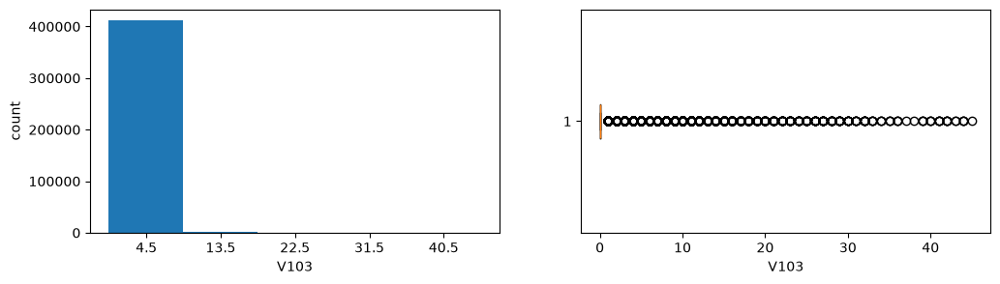

V104


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,412809,99.862354,99.862354
1,"(3.0, 6.0]",4.5,451,0.109101,99.971455
2,"(6.0, 9.0]",7.5,72,0.017417,99.988872
3,"(9.0, 12.0]",10.5,38,0.009193,99.998065
4,"(12.0, 15.0]",13.5,8,0.001935,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


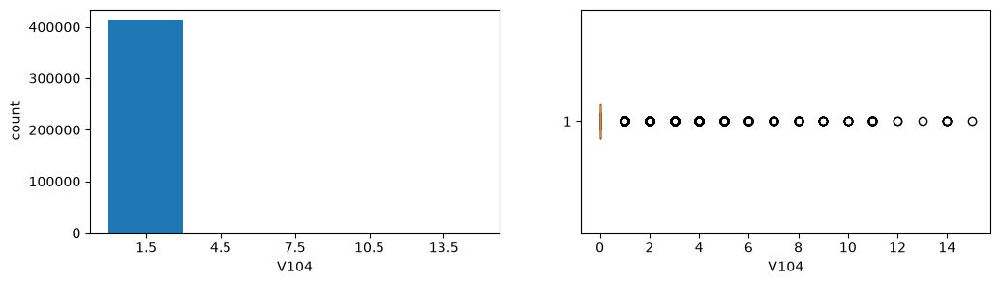

V105


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.038, 7.6]",3.8,412666,99.827761,99.827761
1,"(7.6, 15.2]",11.4,417,0.100876,99.928637
2,"(15.2, 22.8]",19.0,191,0.046205,99.974841
3,"(22.8, 30.4]",26.6,71,0.017176,99.992017
4,"(30.4, 38.0]",34.2,33,0.007983,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


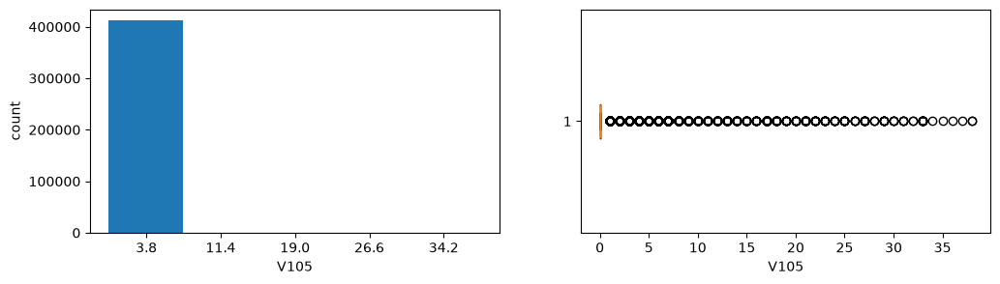

V106


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.023, 4.6]",2.3,412719,99.840582,99.840582
1,"(4.6, 9.2]",6.9,445,0.107650,99.948231
2,"(9.2, 13.8]",11.5,159,0.038464,99.986695
3,"(13.8, 18.4]",16.1,42,0.010160,99.996855
4,"(18.4, 23.0]",20.7,13,0.003145,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


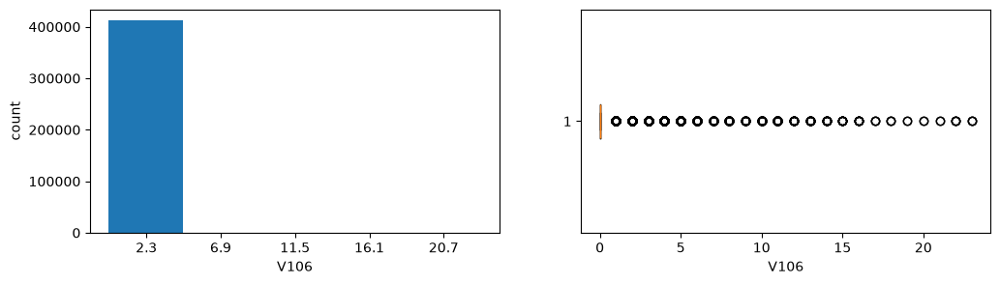

V107


,bins,mid_bin,counts,freq,cum_freq
0,"(0.999, 0.9994]",1.0,0,0.0,0.0
1,"(0.9994, 0.9998]",1.0,0,0.0,0.0
2,"(0.9998, 1.0002]",1.0,413378,100.0,100.0
3,"(1.0002, 1.0006]",1.0,0,0.0,100.0
4,"(1.0006, 1.001]",1.0,0,0.0,100.0


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


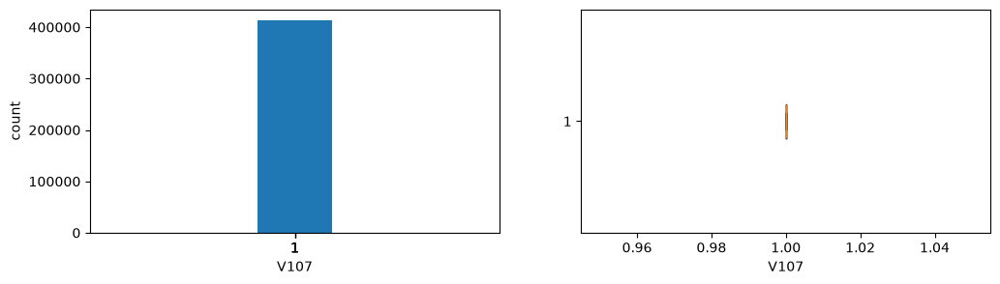

V108


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,411620,99.574723,99.574723
1,"(1.4, 2.8]",2.1,1629,0.394070,99.968794
2,"(2.8, 4.2]",3.5,117,0.028303,99.997097
3,"(4.2, 5.6]",4.9,7,0.001693,99.998790
4,"(5.6, 7.0]",6.3,5,0.001210,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


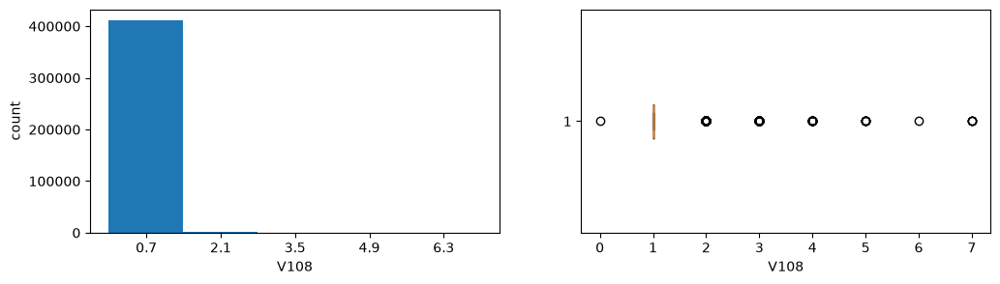

V109


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,408225,98.753441,98.753441
1,"(1.4, 2.8]",2.1,4961,1.200112,99.953553
2,"(2.8, 4.2]",3.5,180,0.043544,99.997097
3,"(4.2, 5.6]",4.9,7,0.001693,99.998790
4,"(5.6, 7.0]",6.3,5,0.001210,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


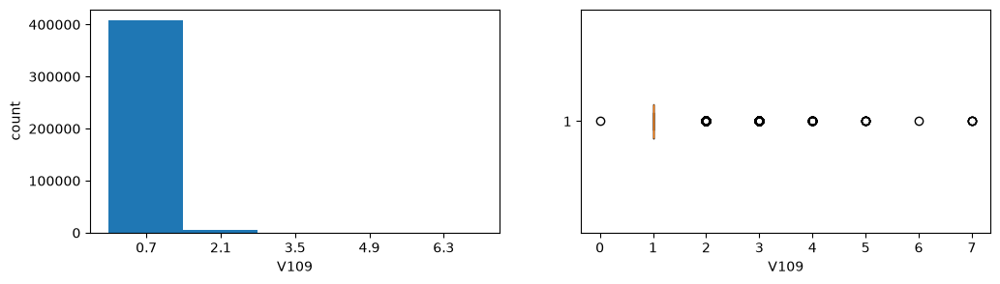

V110


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,410605,99.329185,99.329185
1,"(1.4, 2.8]",2.1,2638,0.638157,99.967342
2,"(2.8, 4.2]",3.5,123,0.029755,99.997097
3,"(4.2, 5.6]",4.9,7,0.001693,99.998790
4,"(5.6, 7.0]",6.3,5,0.001210,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


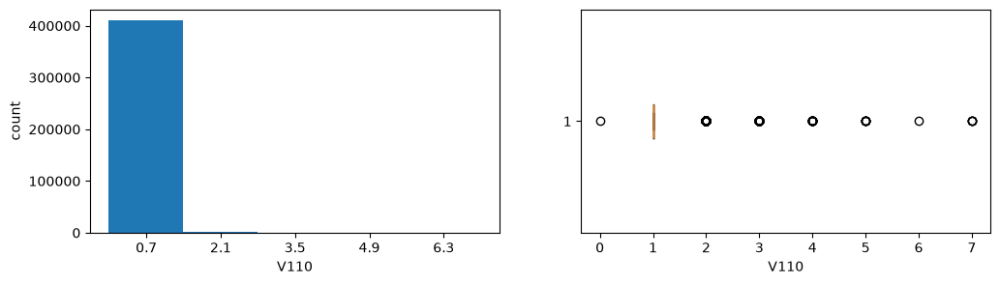

V111


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.009, 1.8]",0.9,412359,99.753494,99.753494
1,"(1.8, 3.6]",2.7,972,0.235136,99.988630
2,"(3.6, 5.4]",4.5,39,0.009434,99.998065
3,"(5.4, 7.2]",6.3,3,0.000726,99.998790
4,"(7.2, 9.0]",8.1,5,0.001210,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


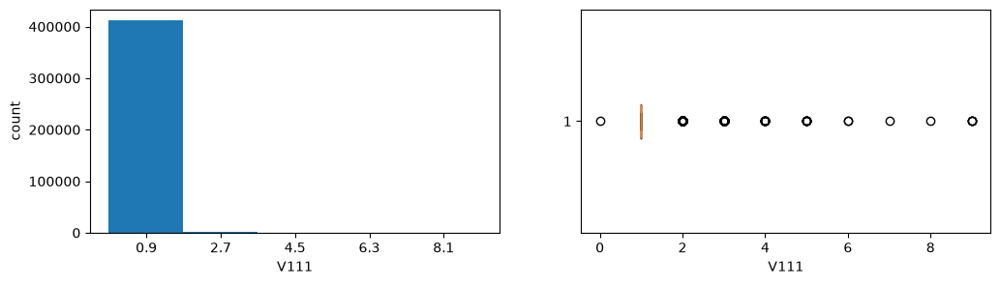

V112


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.009, 1.8]",0.9,411452,99.534083,99.534083
1,"(1.8, 3.6]",2.7,1879,0.454548,99.988630
2,"(3.6, 5.4]",4.5,39,0.009434,99.998065
3,"(5.4, 7.2]",6.3,3,0.000726,99.998790
4,"(7.2, 9.0]",8.1,5,0.001210,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


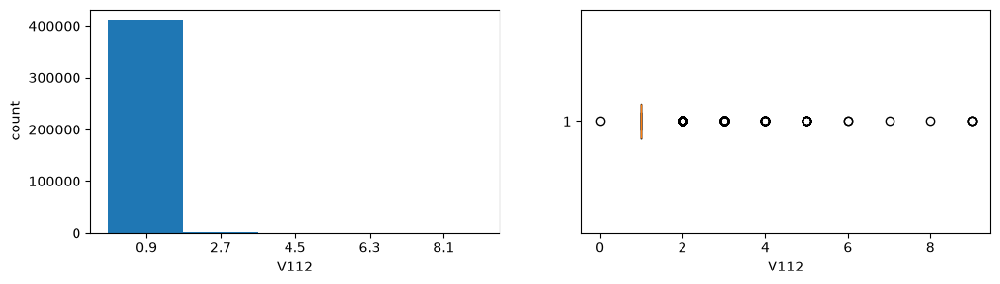

V113


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.009, 1.8]",0.9,412104,99.691807,99.691807
1,"(1.8, 3.6]",2.7,1227,0.296823,99.988630
2,"(3.6, 5.4]",4.5,39,0.009434,99.998065
3,"(5.4, 7.2]",6.3,3,0.000726,99.998790
4,"(7.2, 9.0]",8.1,5,0.001210,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


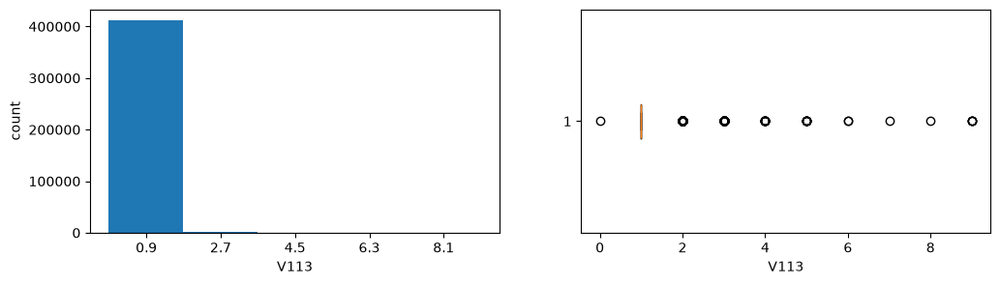

V114


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,410060,99.197345,99.197345
1,"(1.2, 2.4]",1.8,3096,0.748951,99.946296
2,"(2.4, 3.6]",3.0,169,0.040883,99.987179
3,"(3.6, 4.8]",4.2,35,0.008467,99.995646
4,"(4.8, 6.0]",5.4,18,0.004354,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


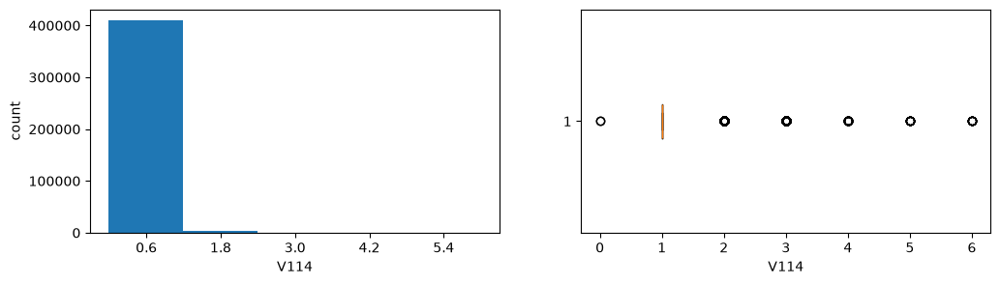

V115


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,402664,97.408183,97.408183
1,"(1.2, 2.4]",1.8,10162,2.458283,99.866466
2,"(2.4, 3.6]",3.0,476,0.115149,99.981615
3,"(3.6, 4.8]",4.2,57,0.013789,99.995404
4,"(4.8, 6.0]",5.4,19,0.004596,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


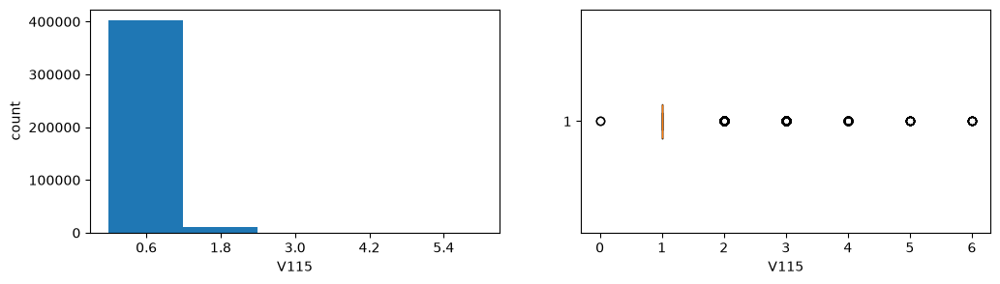

V116


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.006, 1.2]",0.6,408019,98.703608,98.703608
1,"(1.2, 2.4]",1.8,5086,1.230351,99.933959
2,"(2.4, 3.6]",3.0,215,0.052011,99.985969
3,"(3.6, 4.8]",4.2,40,0.009676,99.995646
4,"(4.8, 6.0]",5.4,18,0.004354,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


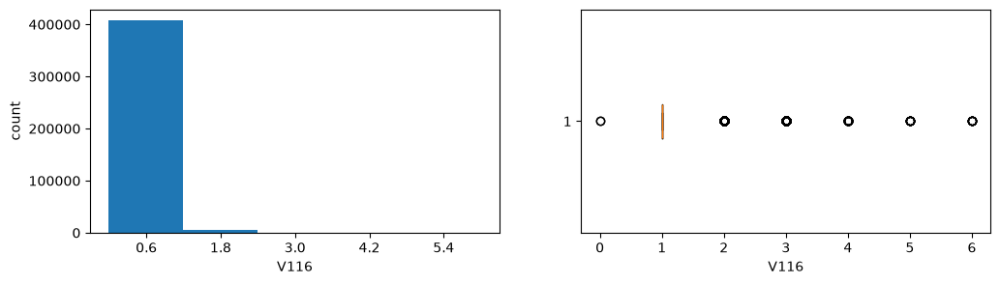

V117


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.003, 0.6]",0.3,1,0.000242,0.000242
1,"(0.6, 1.2]",0.9,413074,99.926460,99.926701
2,"(1.2, 1.8]",1.5,0,0.000000,99.926701
3,"(1.8, 2.4]",2.1,301,0.072815,99.999516
4,"(2.4, 3.0]",2.7,2,0.000484,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


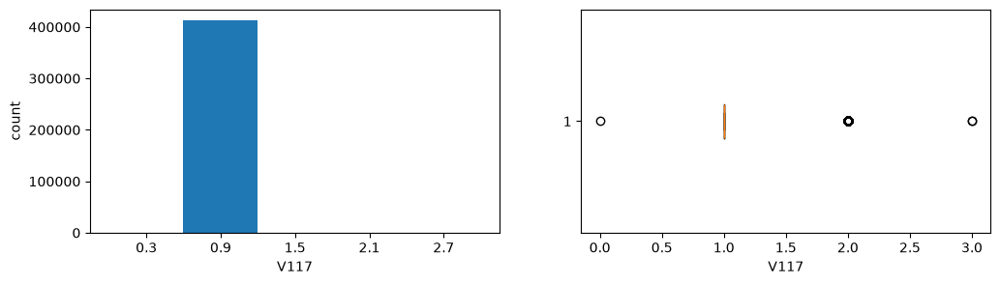

V118


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.003, 0.6]",0.3,1,0.000242,0.000242
1,"(0.6, 1.2]",0.9,412808,99.862112,99.862354
2,"(1.2, 1.8]",1.5,0,0.000000,99.862354
3,"(1.8, 2.4]",2.1,567,0.137163,99.999516
4,"(2.4, 3.0]",2.7,2,0.000484,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


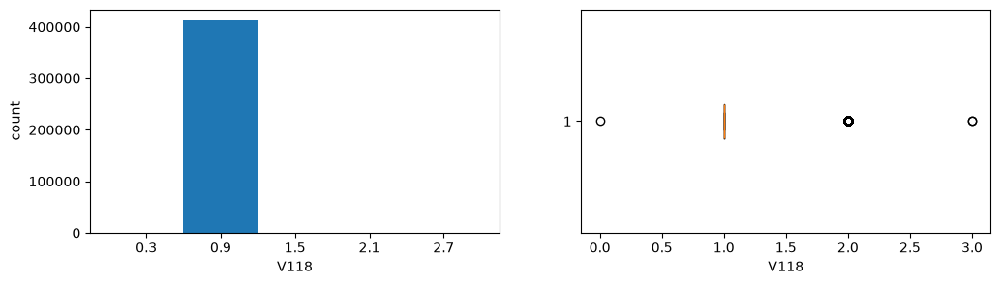

V119


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.003, 0.6]",0.3,1,0.000242,0.000242
1,"(0.6, 1.2]",0.9,412995,99.907349,99.907591
2,"(1.2, 1.8]",1.5,0,0.000000,99.907591
3,"(1.8, 2.4]",2.1,380,0.091926,99.999516
4,"(2.4, 3.0]",2.7,2,0.000484,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


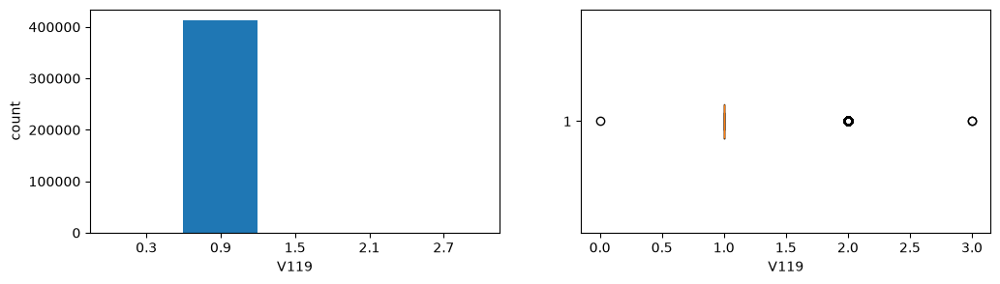

V120


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.003, 0.6]",0.3,1,0.000242,0.000242
1,"(0.6, 1.2]",0.9,412890,99.881948,99.882190
2,"(1.2, 1.8]",1.5,0,0.000000,99.882190
3,"(1.8, 2.4]",2.1,481,0.116358,99.998549
4,"(2.4, 3.0]",2.7,6,0.001451,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


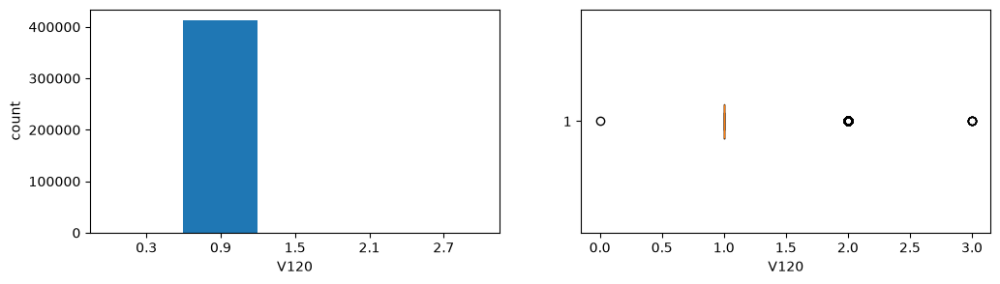

V121


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.003, 0.6]",0.3,1,0.000242,0.000242
1,"(0.6, 1.2]",0.9,411869,99.634959,99.635201
2,"(1.2, 1.8]",1.5,0,0.000000,99.635201
3,"(1.8, 2.4]",2.1,1498,0.362380,99.997581
4,"(2.4, 3.0]",2.7,10,0.002419,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


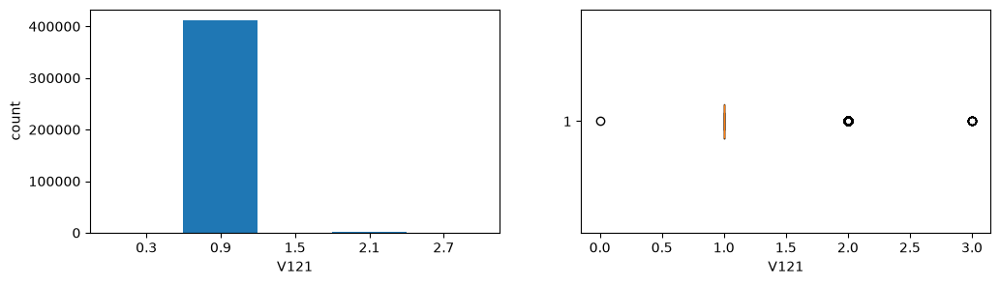

V122


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.003, 0.6]",0.3,1,0.000242,0.000242
1,"(0.6, 1.2]",0.9,412660,99.826309,99.826551
2,"(1.2, 1.8]",1.5,0,0.000000,99.826551
3,"(1.8, 2.4]",2.1,711,0.171998,99.998549
4,"(2.4, 3.0]",2.7,6,0.001451,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


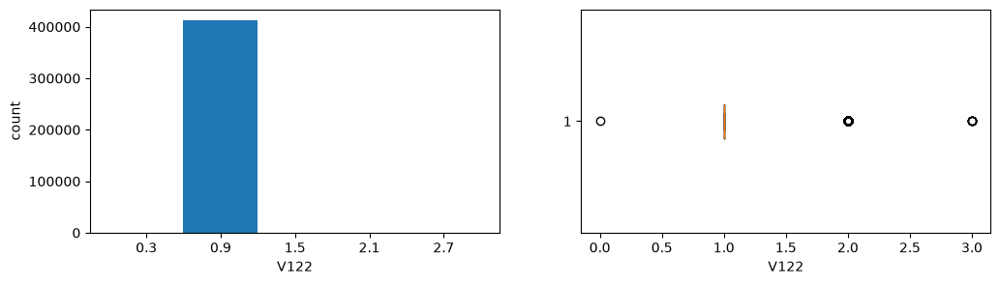

V123


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.013, 2.6]",1.3,412105,99.692049,99.692049
1,"(2.6, 5.2]",3.9,1147,0.277470,99.969519
2,"(5.2, 7.8]",6.5,77,0.018627,99.988146
3,"(7.8, 10.4]",9.1,41,0.009918,99.998065
4,"(10.4, 13.0]",11.7,8,0.001935,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


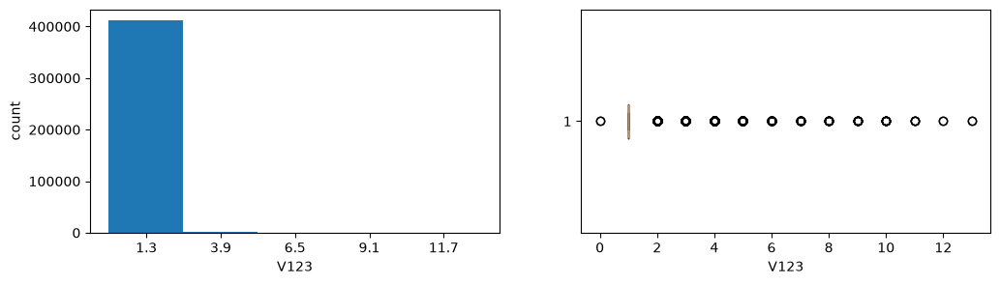

V124


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.013, 2.6]",1.3,409576,99.080261,99.080261
1,"(2.6, 5.2]",3.9,3639,0.880308,99.960569
2,"(5.2, 7.8]",6.5,103,0.024917,99.985485
3,"(7.8, 10.4]",9.1,51,0.012337,99.997823
4,"(10.4, 13.0]",11.7,9,0.002177,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


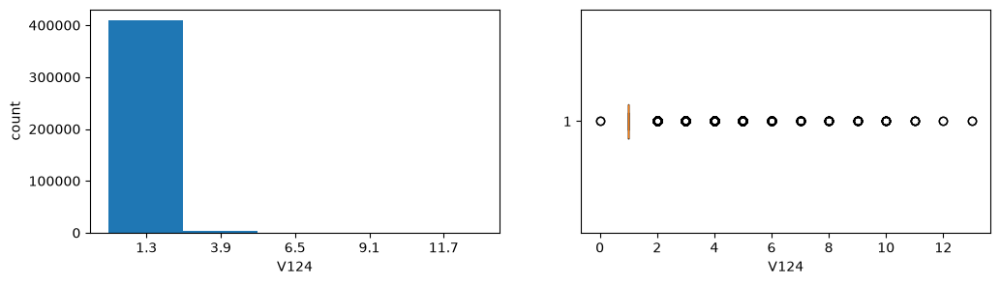

V125


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.013, 2.6]",1.3,411619,99.574481,99.574481
1,"(2.6, 5.2]",3.9,1631,0.394554,99.969036
2,"(5.2, 7.8]",6.5,79,0.019111,99.988146
3,"(7.8, 10.4]",9.1,41,0.009918,99.998065
4,"(10.4, 13.0]",11.7,8,0.001935,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


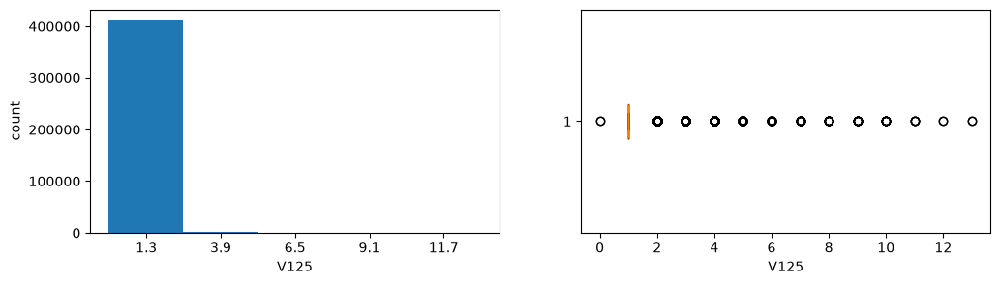

V126


,bins,mid_bin,counts,freq,cum_freq
0,"(-65.297, 13059.434]",6497.1,413351,99.993468,99.993468
1,"(13059.434, 26118.869]",19589.2,20,0.004838,99.998307
2,"(26118.869, 39178.303]",32648.6,3,0.000726,99.999032
3,"(39178.303, 52237.738]",45708.0,1,0.000242,99.999274
4,"(52237.738, 65297.172]",58767.5,3,0.000726,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


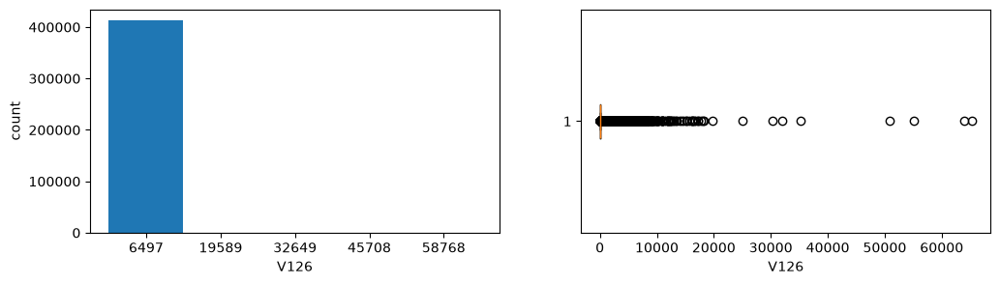

V127


,bins,mid_bin,counts,freq,cum_freq
0,"(-65.297, 13059.434]",6497.1,413173,99.950409,99.950409
1,"(13059.434, 26118.869]",19589.2,190,0.045963,99.996371
2,"(26118.869, 39178.303]",32648.6,10,0.002419,99.998790
3,"(39178.303, 52237.738]",45708.0,2,0.000484,99.999274
4,"(52237.738, 65297.172]",58767.5,3,0.000726,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


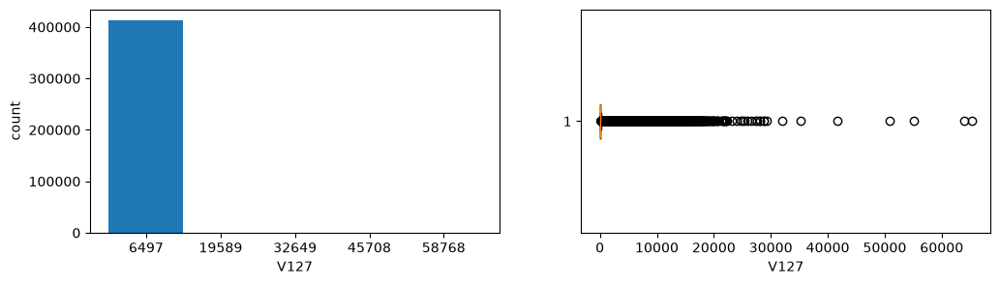

V128


,bins,mid_bin,counts,freq,cum_freq
0,"(-65.297, 13059.434]",6497.1,413350,99.993227,99.993227
1,"(13059.434, 26118.869]",19589.2,21,0.005080,99.998307
2,"(26118.869, 39178.303]",32648.6,3,0.000726,99.999032
3,"(39178.303, 52237.738]",45708.0,1,0.000242,99.999274
4,"(52237.738, 65297.172]",58767.5,3,0.000726,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


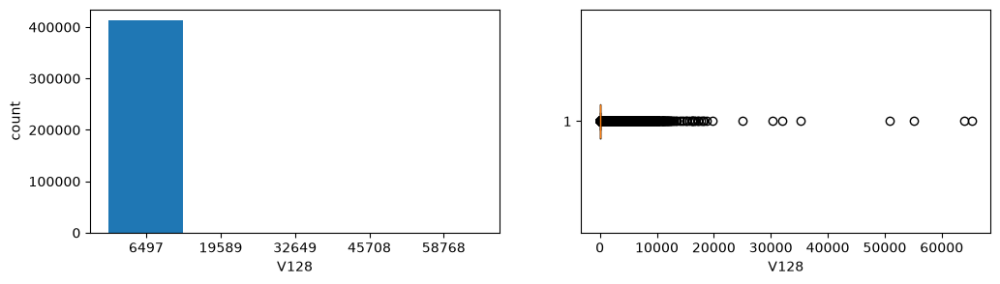

V129


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,413374,99.999032,99.999032
1,"(11025.0, 22050.0]",16537.5,2,0.000484,99.999516
2,"(22050.0, 33075.0]",27562.5,1,0.000242,99.999758
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999758
4,"(44100.0, 55125.0]",49612.5,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


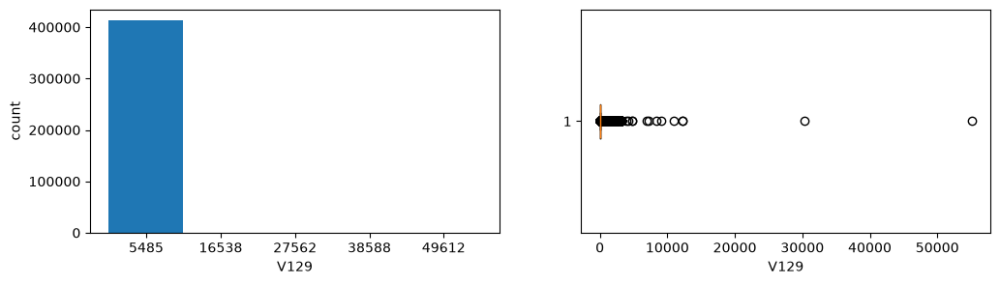

V130


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,413373,99.998790,99.998790
1,"(11025.0, 22050.0]",16537.5,3,0.000726,99.999516
2,"(22050.0, 33075.0]",27562.5,0,0.000000,99.999516
3,"(33075.0, 44100.0]",38587.5,1,0.000242,99.999758
4,"(44100.0, 55125.0]",49612.5,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


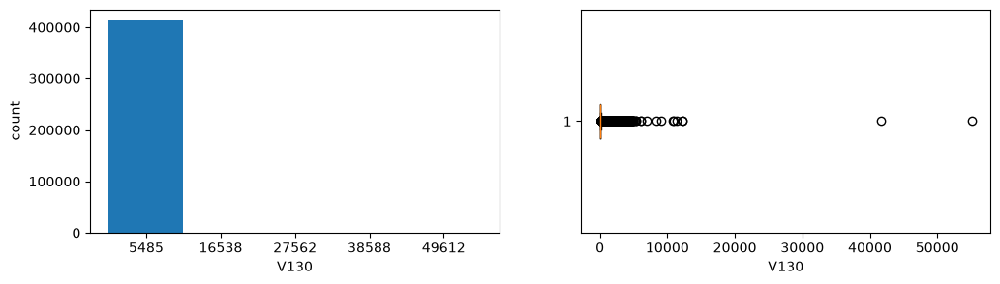

V131


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,413374,99.999032,99.999032
1,"(11025.0, 22050.0]",16537.5,2,0.000484,99.999516
2,"(22050.0, 33075.0]",27562.5,1,0.000242,99.999758
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999758
4,"(44100.0, 55125.0]",49612.5,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


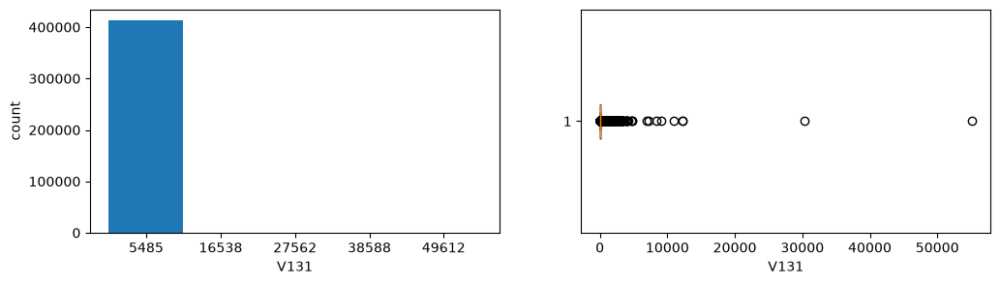

V132


,bins,mid_bin,counts,freq,cum_freq
0,"(-63.875, 12774.956]",6355.5,413375,99.999274,99.999274
1,"(12774.956, 25549.912]",19162.4,0,0.000000,99.999274
2,"(25549.912, 38324.869]",31937.4,1,0.000242,99.999516
3,"(38324.869, 51099.825]",44712.3,0,0.000000,99.999516
4,"(51099.825, 63874.781]",57487.3,2,0.000484,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


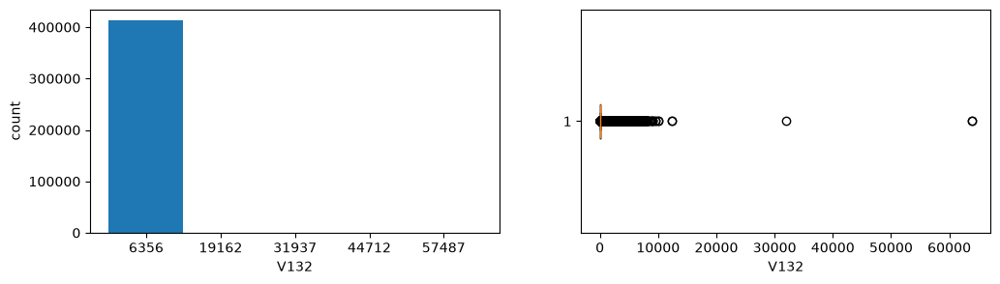

V133


,bins,mid_bin,counts,freq,cum_freq
0,"(-63.875, 12774.956]",6355.5,413257,99.970729,99.970729
1,"(12774.956, 25549.912]",19162.4,114,0.027578,99.998307
2,"(25549.912, 38324.869]",31937.4,5,0.001210,99.999516
3,"(38324.869, 51099.825]",44712.3,0,0.000000,99.999516
4,"(51099.825, 63874.781]",57487.3,2,0.000484,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


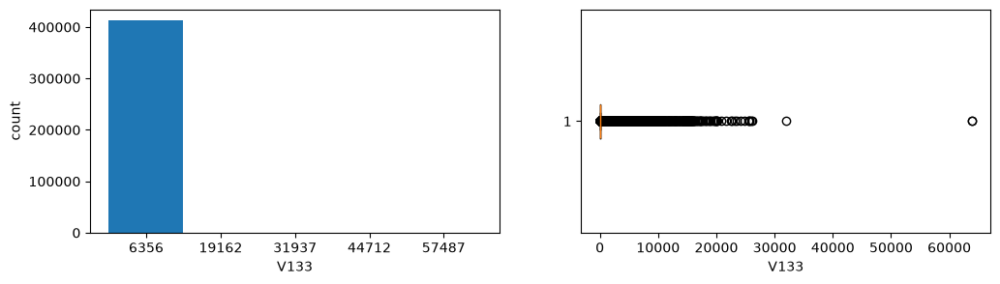

V134


,bins,mid_bin,counts,freq,cum_freq
0,"(-63.875, 12774.956]",6355.5,413375,99.999274,99.999274
1,"(12774.956, 25549.912]",19162.4,0,0.000000,99.999274
2,"(25549.912, 38324.869]",31937.4,1,0.000242,99.999516
3,"(38324.869, 51099.825]",44712.3,0,0.000000,99.999516
4,"(51099.825, 63874.781]",57487.3,2,0.000484,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


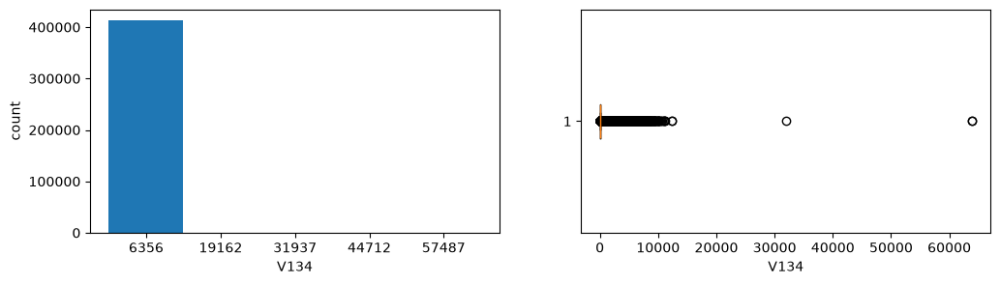

V135


,bins,mid_bin,counts,freq,cum_freq
0,"(-50.82, 10164.0]",5056.6,413366,99.997097,99.997097
1,"(10164.0, 20328.0]",15246.0,9,0.002177,99.999274
2,"(20328.0, 30492.0]",25410.0,2,0.000484,99.999758
3,"(30492.0, 40656.0]",35574.0,0,0.000000,99.999758
4,"(40656.0, 50820.0]",45738.0,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


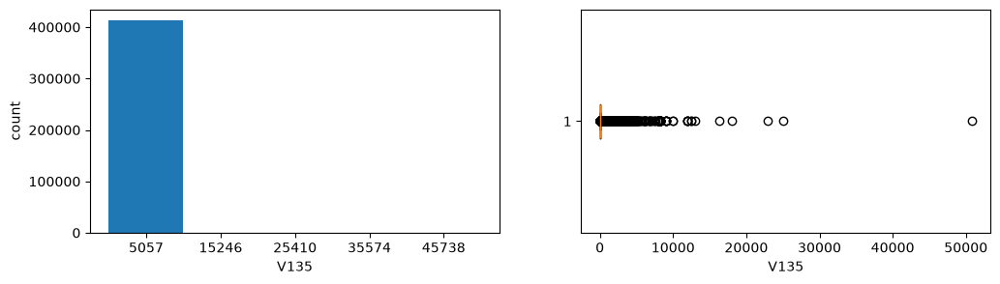

V136


,bins,mid_bin,counts,freq,cum_freq
0,"(-50.82, 10164.0]",5056.6,413366,99.997097,99.997097
1,"(10164.0, 20328.0]",15246.0,9,0.002177,99.999274
2,"(20328.0, 30492.0]",25410.0,2,0.000484,99.999758
3,"(30492.0, 40656.0]",35574.0,0,0.000000,99.999758
4,"(40656.0, 50820.0]",45738.0,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


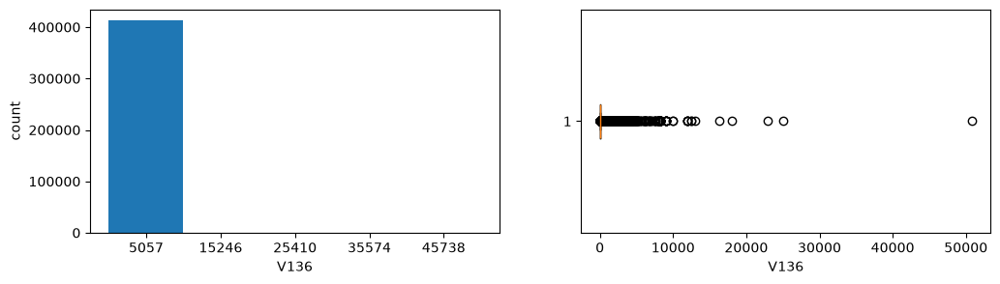

V137


,bins,mid_bin,counts,freq,cum_freq
0,"(-50.82, 10164.0]",5056.6,413366,99.997097,99.997097
1,"(10164.0, 20328.0]",15246.0,9,0.002177,99.999274
2,"(20328.0, 30492.0]",25410.0,2,0.000484,99.999758
3,"(30492.0, 40656.0]",35574.0,0,0.000000,99.999758
4,"(40656.0, 50820.0]",45738.0,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


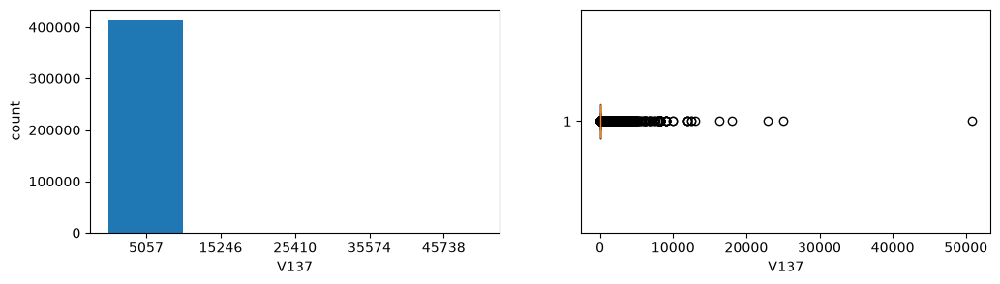

V138


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.022, 4.4]",2.2,65053,99.820470,99.820470
1,"(4.4, 8.8]",6.6,78,0.119687,99.940157
2,"(8.8, 13.2]",11.0,22,0.033758,99.973914
3,"(13.2, 17.6]",15.4,12,0.018413,99.992328
4,"(17.6, 22.0]",19.8,5,0.007672,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


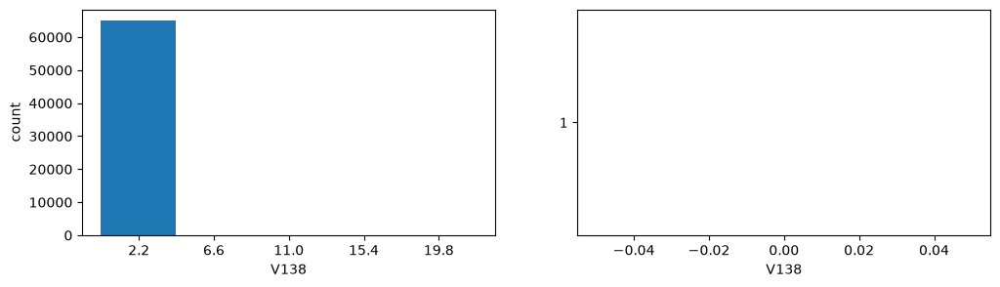

V139


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.033, 6.6]",3.3,64638,99.183673,99.183673
1,"(6.6, 13.2]",9.9,431,0.661347,99.845021
2,"(13.2, 19.8]",16.5,69,0.105877,99.950898
3,"(19.8, 26.4]",23.1,25,0.038361,99.989259
4,"(26.4, 33.0]",29.7,7,0.010741,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


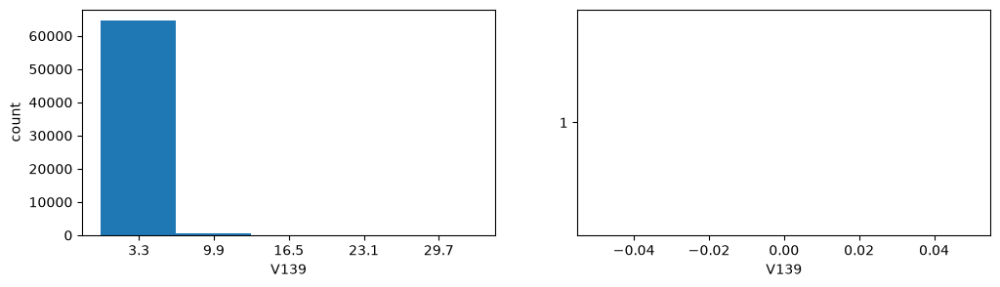

V140


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.033, 6.6]",3.3,64421,98.850698,98.850698
1,"(6.6, 13.2]",9.9,617,0.946755,99.797453
2,"(13.2, 19.8]",16.5,97,0.148841,99.946294
3,"(19.8, 26.4]",23.1,28,0.042965,99.989259
4,"(26.4, 33.0]",29.7,7,0.010741,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


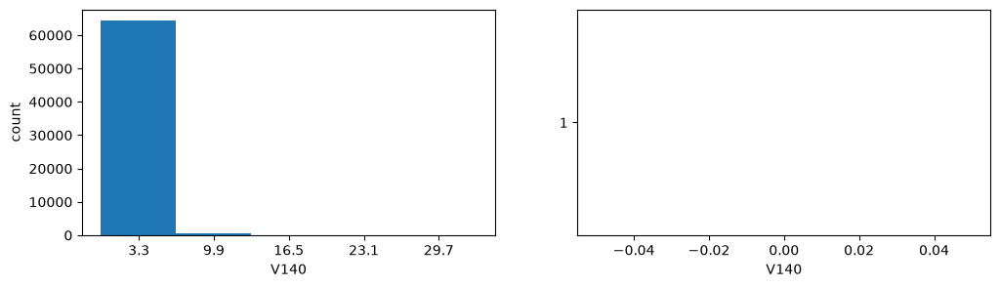

V141


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.005, 1.0]",0.5,64933,99.636336,99.636336
1,"(1.0, 2.0]",1.5,201,0.308424,99.944760
2,"(2.0, 3.0]",2.5,32,0.049102,99.993862
3,"(3.0, 4.0]",3.5,2,0.003069,99.996931
4,"(4.0, 5.0]",4.5,2,0.003069,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


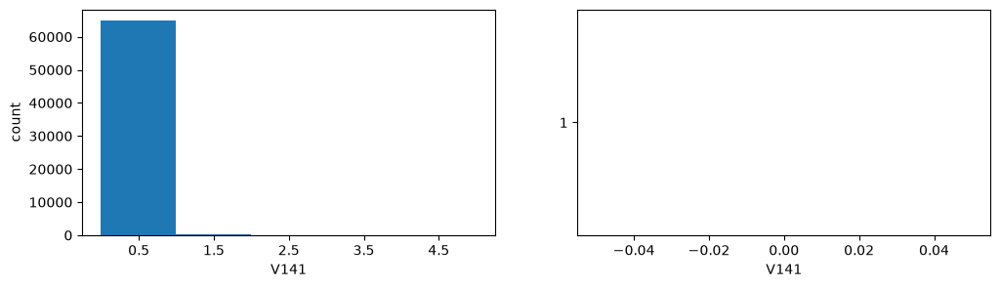

V142


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.009, 1.8]",0.9,64765,99.378548,99.378548
1,"(1.8, 3.6]",2.7,324,0.497161,99.875710
2,"(3.6, 5.4]",4.5,64,0.098205,99.973914
3,"(5.4, 7.2]",6.3,12,0.018413,99.992328
4,"(7.2, 9.0]",8.1,5,0.007672,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


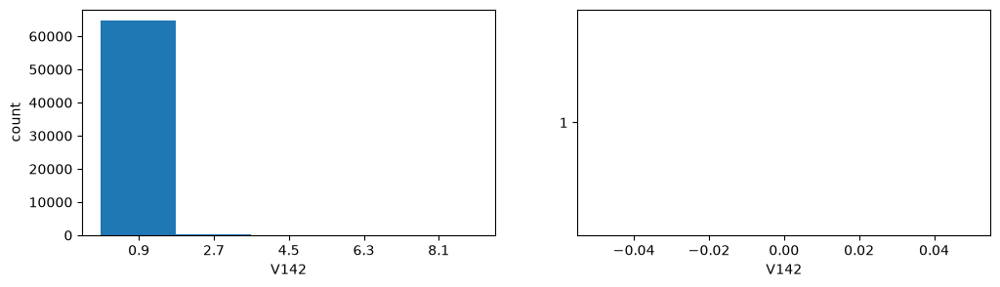

V143


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.054, 10.8]",5.4,56970,87.417523,87.417523
1,"(10.8, 21.6]",16.2,3134,4.808961,92.226485
2,"(21.6, 32.4]",27.0,3837,5.887678,98.114163
3,"(32.4, 43.2]",37.8,911,1.397882,99.512045
4,"(43.2, 54.0]",48.6,318,0.487955,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


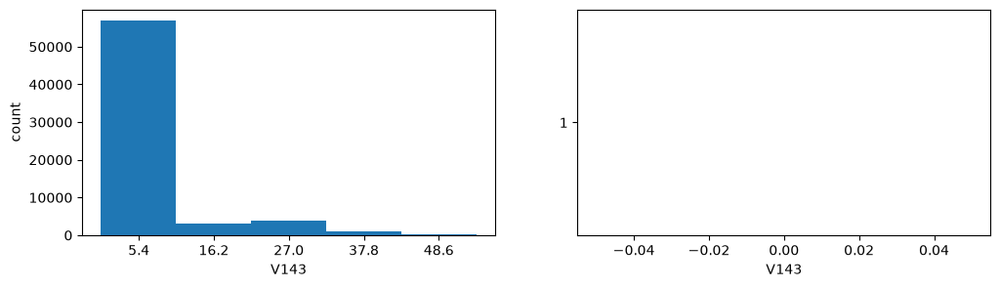

V144


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.062, 12.4]",6.2,57208,87.782722,87.782722
1,"(12.4, 24.8]",18.6,2242,3.440233,91.222955
2,"(24.8, 37.2]",31.0,2519,3.865275,95.088231
3,"(37.2, 49.6]",43.4,2588,3.971152,99.059383
4,"(49.6, 62.0]",55.8,613,0.940617,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


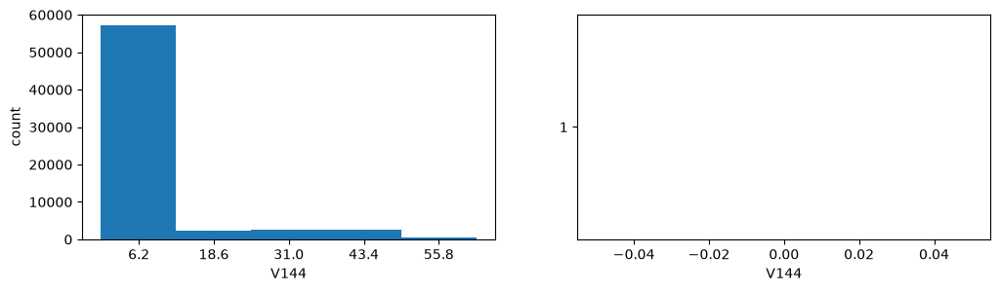

V145


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.297, 59.4]",29.6,56793,87.145926,87.145926
1,"(59.4, 118.8]",89.1,92,0.141169,87.287095
2,"(118.8, 178.2]",148.5,3352,5.143471,92.430566
3,"(178.2, 237.6]",207.9,1781,2.732853,95.163419
4,"(237.6, 297.0]",267.3,3152,4.836581,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


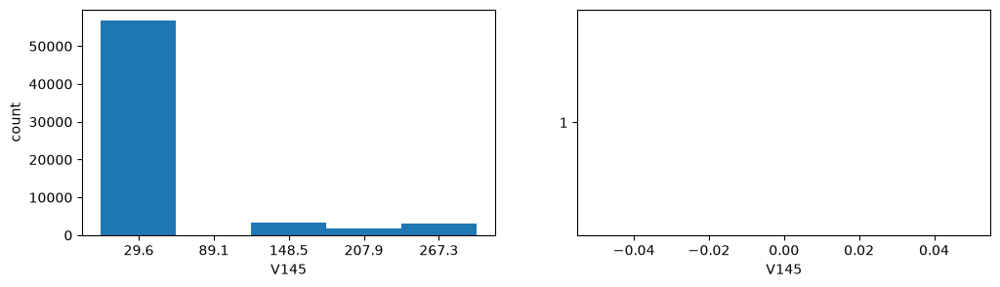

V146


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.017, 3.4]",1.7,64759,99.369342,99.369342
1,"(3.4, 6.8]",5.1,335,0.514040,99.883382
2,"(6.8, 10.2]",8.5,45,0.069050,99.952432
3,"(10.2, 13.6]",11.9,27,0.041430,99.993862
4,"(13.6, 17.0]",15.3,4,0.006138,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


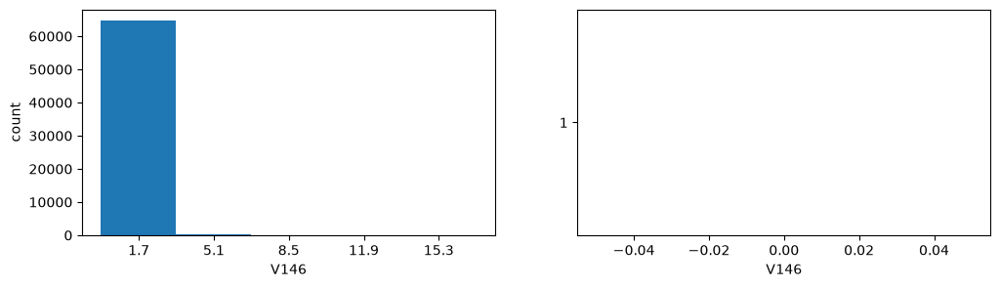

V147


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.017, 3.4]",1.7,64673,99.237379,99.237379
1,"(3.4, 6.8]",5.1,368,0.564677,99.802056
2,"(6.8, 10.2]",8.5,73,0.112015,99.914071
3,"(10.2, 13.6]",11.9,43,0.065981,99.980052
4,"(13.6, 17.0]",15.3,13,0.019948,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


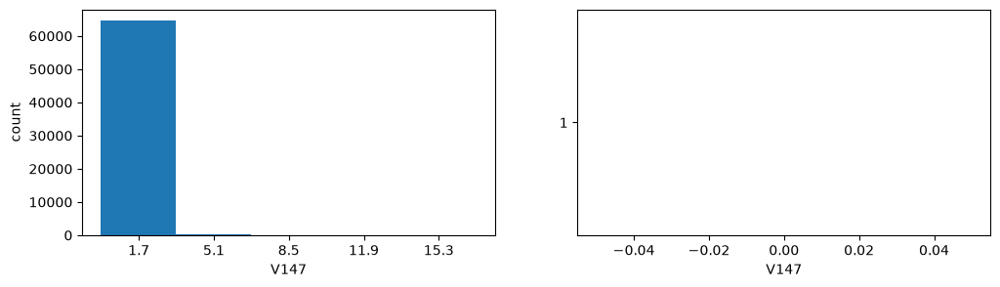

V148


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,65017,99.765229,99.765229
1,"(3.0, 6.0]",4.5,125,0.191806,99.957035
2,"(6.0, 9.0]",7.5,20,0.030689,99.987724
3,"(9.0, 12.0]",10.5,3,0.004603,99.992328
4,"(12.0, 15.0]",13.5,5,0.007672,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


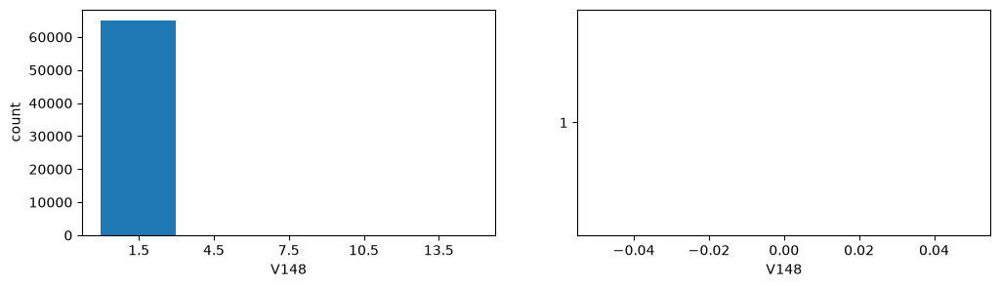

V149


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,64926,99.625595,99.625595
1,"(3.0, 6.0]",4.5,192,0.294614,99.920209
2,"(6.0, 9.0]",7.5,35,0.053706,99.973914
3,"(9.0, 12.0]",10.5,6,0.009207,99.983121
4,"(12.0, 15.0]",13.5,11,0.016879,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


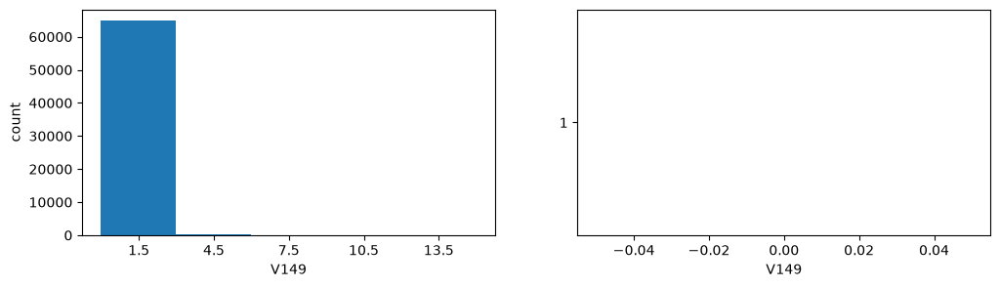

V150


,bins,mid_bin,counts,freq,cum_freq
0,"(-2.388, 678.6]",338.1,56812,87.175081,87.175081
1,"(678.6, 1356.2]",1017.4,113,0.173393,87.348473
2,"(1356.2, 2033.8]",1695.0,1717,2.634648,89.983121
3,"(2033.8, 2711.4]",2372.6,2009,3.082707,93.065828
4,"(2711.4, 3389.0]",3050.2,4519,6.934172,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


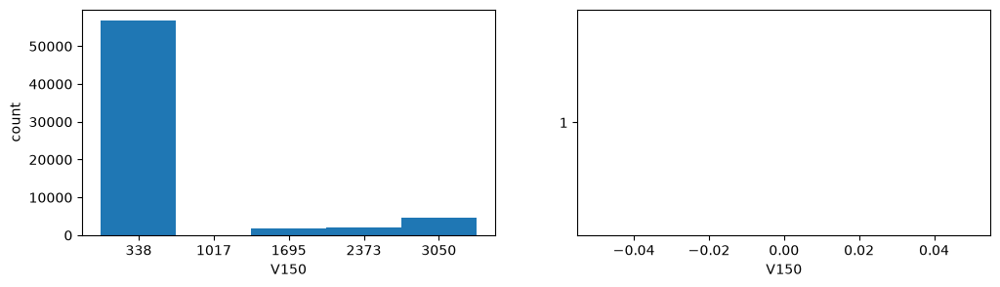

V151


,bins,mid_bin,counts,freq,cum_freq
0,"(0.944, 12.2]",6.6,56025,85.967470,85.967470
1,"(12.2, 23.4]",17.8,800,1.227559,87.195028
2,"(23.4, 34.6]",29.0,246,0.377474,87.572503
3,"(34.6, 45.8]",40.2,364,0.558539,88.131042
4,"(45.8, 57.0]",51.4,7735,11.868958,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


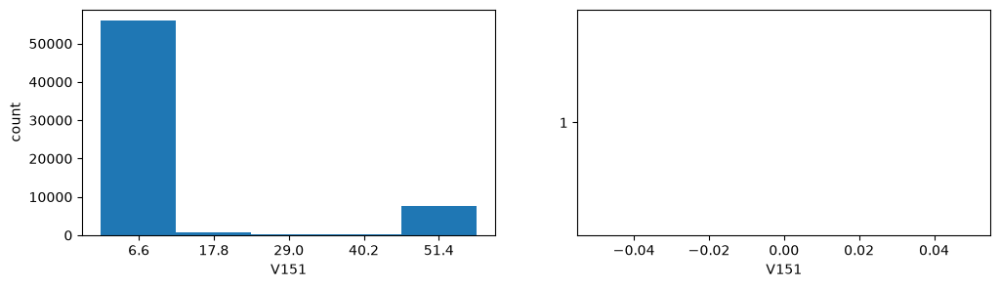

V152


,bins,mid_bin,counts,freq,cum_freq
0,"(0.932, 14.6]",7.8,55277,84.819702,84.819702
1,"(14.6, 28.2]",21.4,0,0.000000,84.819702
2,"(28.2, 41.8]",35.0,0,0.000000,84.819702
3,"(41.8, 55.4]",48.6,887,1.361056,86.180758
4,"(55.4, 69.0]",62.2,9006,13.819242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


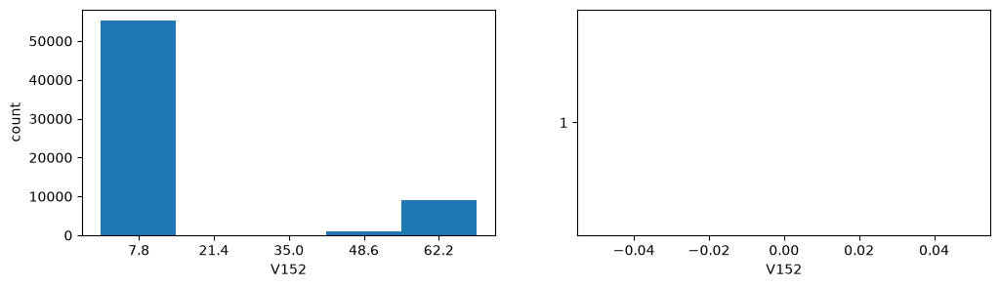

V153


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,64467,98.921283,98.921283
1,"(1.4, 2.8]",2.1,514,0.788706,99.709989
2,"(2.8, 4.2]",3.5,157,0.240908,99.950898
3,"(4.2, 5.6]",4.9,18,0.027620,99.978518
4,"(5.6, 7.0]",6.3,14,0.021482,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


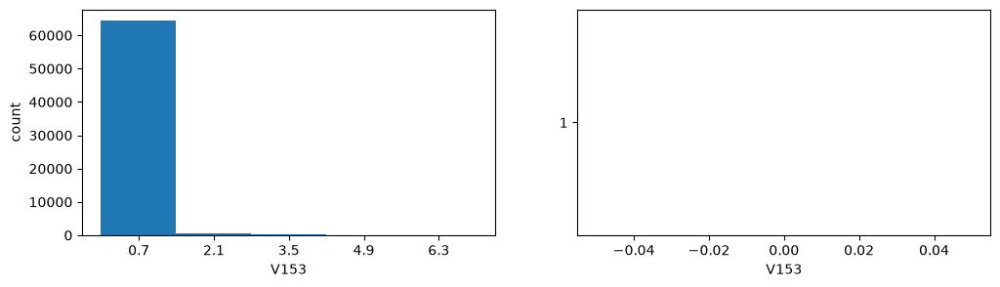

V154


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.008, 1.6]",0.8,64357,98.752493,98.752493
1,"(1.6, 3.2]",2.4,717,1.100199,99.852693
2,"(3.2, 4.8]",4.0,53,0.081326,99.934019
3,"(4.8, 6.4]",5.6,39,0.059843,99.993862
4,"(6.4, 8.0]",7.2,4,0.006138,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


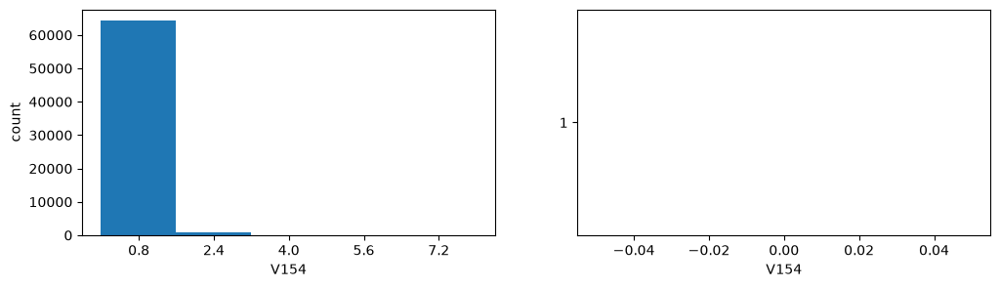

V155


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.014, 2.8]",1.4,64777,99.396962,99.396962
1,"(2.8, 5.6]",4.2,346,0.530919,99.927881
2,"(5.6, 8.4]",7.0,37,0.056775,99.984656
3,"(8.4, 11.2]",9.8,5,0.007672,99.992328
4,"(11.2, 14.0]",12.6,5,0.007672,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


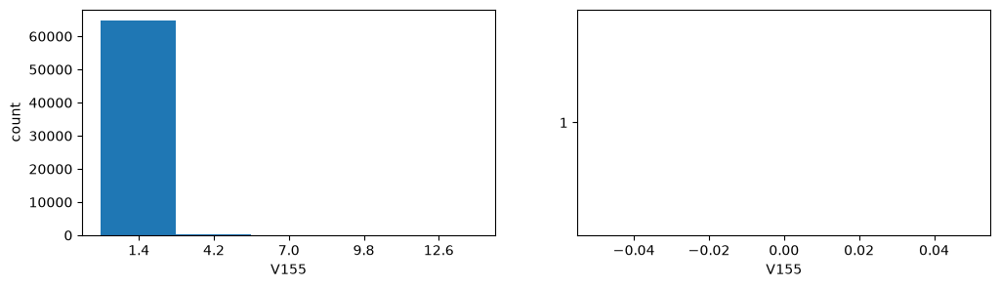

V156


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.016, 3.2]",1.6,64906,99.594906,99.594906
1,"(3.2, 6.4]",4.8,213,0.326838,99.921743
2,"(6.4, 9.6]",8.0,34,0.052171,99.973914
3,"(9.6, 12.8]",11.2,8,0.012276,99.986190
4,"(12.8, 16.0]",14.4,9,0.013810,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


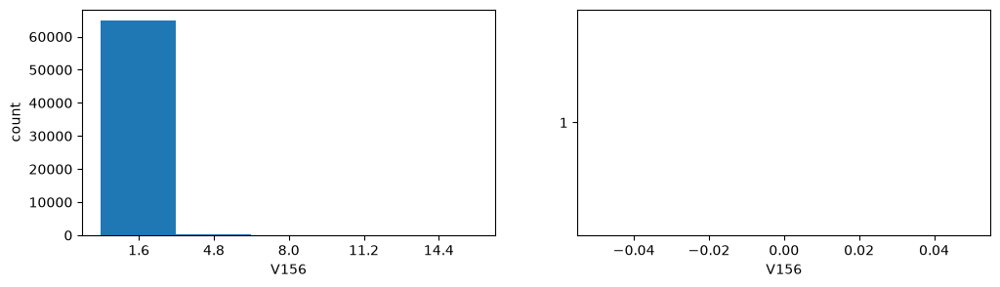

V157


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,64868,99.536597,99.536597
1,"(3.0, 6.0]",4.5,262,0.402025,99.938622
2,"(6.0, 9.0]",7.5,32,0.049102,99.987724
3,"(9.0, 12.0]",10.5,3,0.004603,99.992328
4,"(12.0, 15.0]",13.5,5,0.007672,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


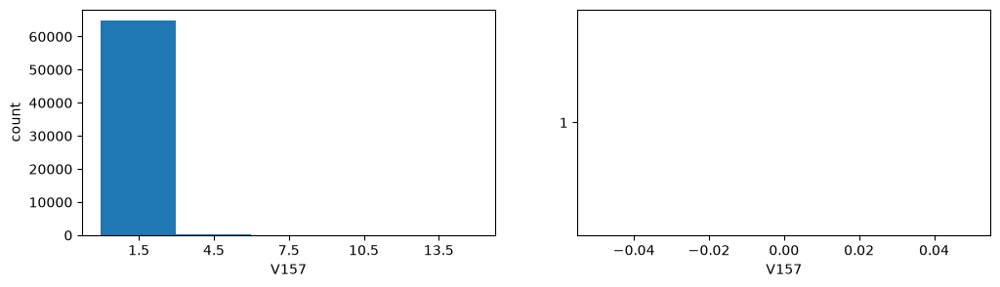

V158


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.016, 3.2]",1.6,64744,99.346325,99.346325
1,"(3.2, 6.4]",4.8,356,0.546264,99.892589
2,"(6.4, 9.6]",8.0,52,0.079791,99.972380
3,"(9.6, 12.8]",11.2,7,0.010741,99.983121
4,"(12.8, 16.0]",14.4,11,0.016879,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


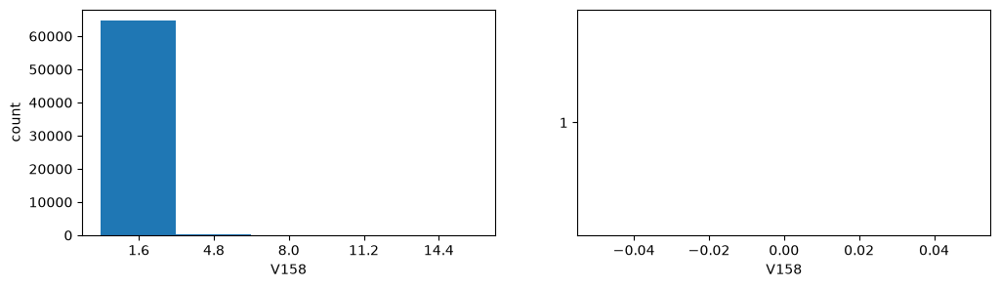

V159


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,57190,87.755102,87.755102
1,"(11025.0, 22050.0]",16537.5,1542,2.366119,90.121221
2,"(22050.0, 33075.0]",27562.5,4761,7.305509,97.426730
3,"(33075.0, 44100.0]",38587.5,1674,2.568667,99.995397
4,"(44100.0, 55125.0]",49612.5,3,0.004603,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


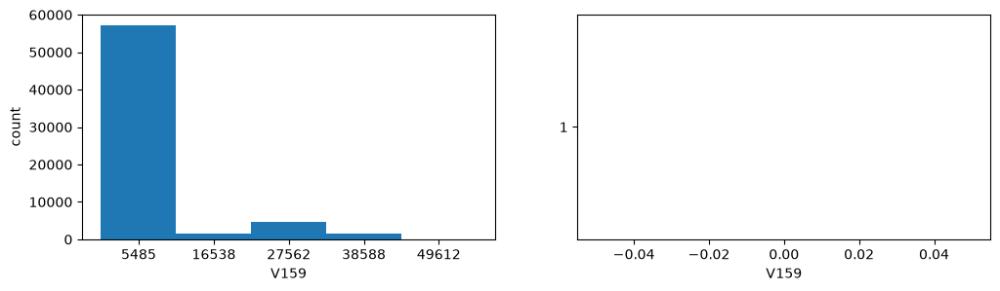

V160


,bins,mid_bin,counts,freq,cum_freq
0,"(-641.511, 128302.288]",63830.4,56338,86.447752,86.447752
1,"(128302.288, 256604.575]",192453.4,1378,2.114470,88.562222
2,"(256604.575, 384906.863]",320755.7,2115,3.245358,91.807580
3,"(384906.863, 513209.15]",449058.0,2112,3.240755,95.048335
4,"(513209.15, 641511.438]",577360.3,3227,4.951665,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


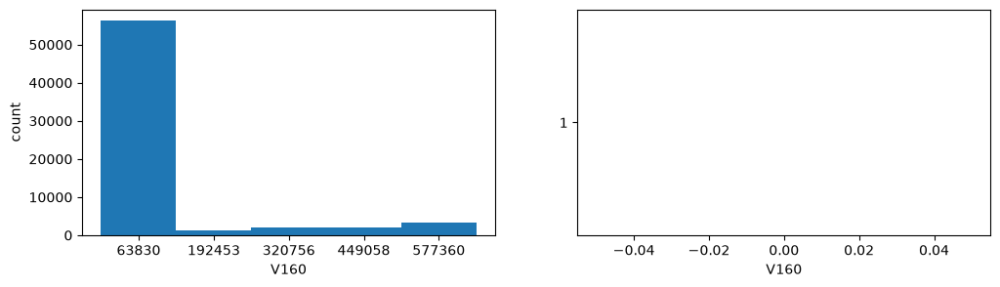

V161


,bins,mid_bin,counts,freq,cum_freq
0,"(-3.3, 660.0]",328.4,65089,99.875710,99.875710
1,"(660.0, 1320.0]",990.0,61,0.093601,99.969311
2,"(1320.0, 1980.0]",1650.0,2,0.003069,99.972380
3,"(1980.0, 2640.0]",2310.0,2,0.003069,99.975449
4,"(2640.0, 3300.0]",2970.0,16,0.024551,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


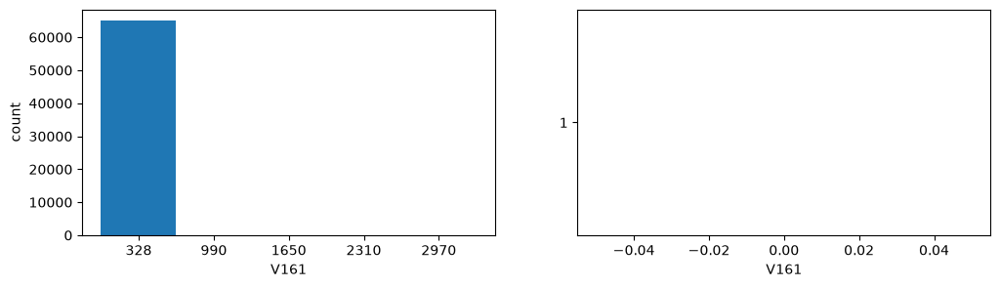

V162


,bins,mid_bin,counts,freq,cum_freq
0,"(-3.3, 660.0]",328.4,65049,99.814332,99.814332
1,"(660.0, 1320.0]",990.0,97,0.148841,99.963173
2,"(1320.0, 1980.0]",1650.0,3,0.004603,99.967777
3,"(1980.0, 2640.0]",2310.0,3,0.004603,99.972380
4,"(2640.0, 3300.0]",2970.0,18,0.027620,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


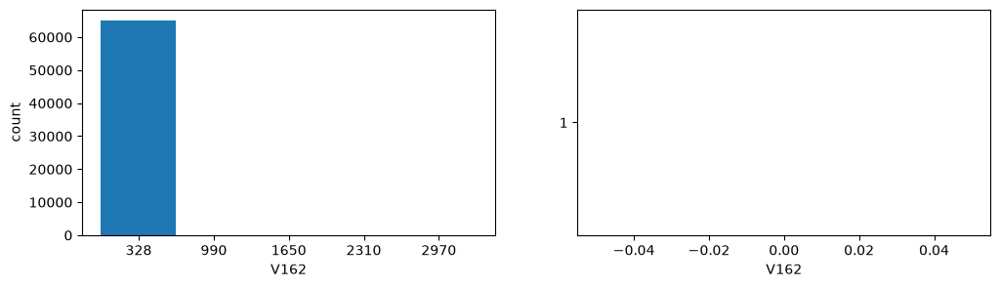

V163


,bins,mid_bin,counts,freq,cum_freq
0,"(-3.3, 660.0]",328.4,65075,99.854227,99.854227
1,"(660.0, 1320.0]",990.0,72,0.110480,99.964708
2,"(1320.0, 1980.0]",1650.0,2,0.003069,99.967777
3,"(1980.0, 2640.0]",2310.0,3,0.004603,99.972380
4,"(2640.0, 3300.0]",2970.0,18,0.027620,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


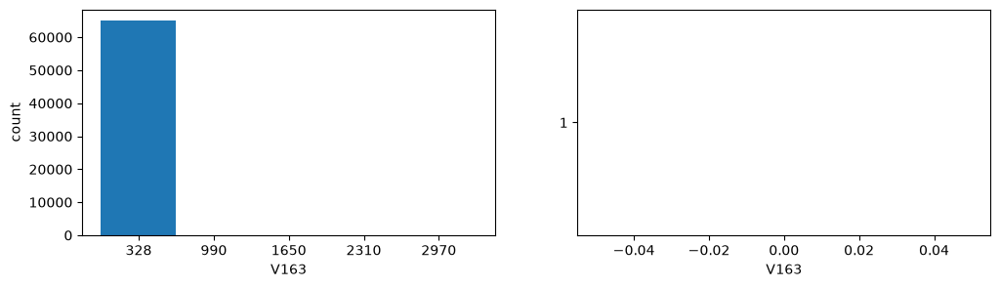

V164


,bins,mid_bin,counts,freq,cum_freq
0,"(-20.4, 4080.0]",2029.8,64983,99.713058,99.713058
1,"(4080.0, 8160.0]",6120.0,155,0.237839,99.950898
2,"(8160.0, 12240.0]",10200.0,24,0.036827,99.987724
3,"(12240.0, 16320.0]",14280.0,4,0.006138,99.993862
4,"(16320.0, 20400.0]",18360.0,4,0.006138,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


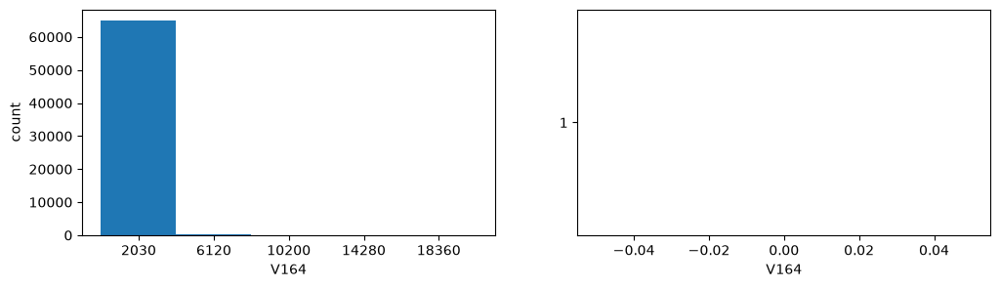

V165


,bins,mid_bin,counts,freq,cum_freq
0,"(-20.4, 4080.0]",2029.8,56384,86.518337,86.518337
1,"(4080.0, 8160.0]",6120.0,1965,3.015191,89.533528
2,"(8160.0, 12240.0]",10200.0,1656,2.541046,92.074574
3,"(12240.0, 16320.0]",14280.0,3891,5.970539,98.045113
4,"(16320.0, 20400.0]",18360.0,1274,1.954887,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


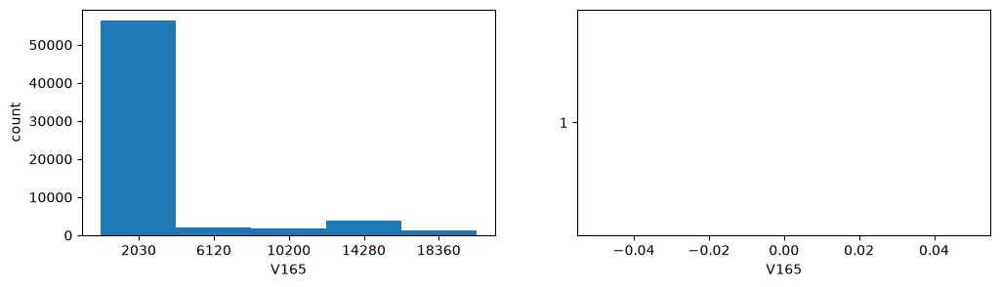

V166


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,65166,99.993862,99.993862
1,"(20328.0, 40656.0]",30492.0,2,0.003069,99.996931
2,"(40656.0, 60984.0]",50820.0,1,0.001534,99.998466
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.998466
4,"(81312.0, 101640.0]",91476.0,1,0.001534,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


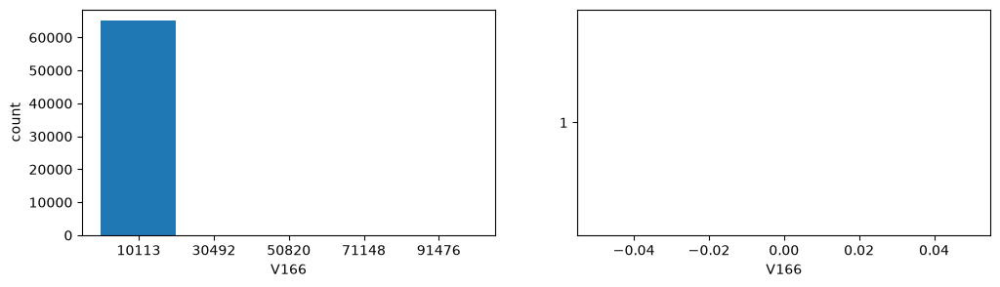

V167


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.058, 11.6]",5.8,105904,99.375991,99.375991
1,"(11.6, 23.2]",17.4,412,0.386604,99.762595
2,"(23.2, 34.8]",29.0,104,0.097589,99.860184
3,"(34.8, 46.4]",40.6,124,0.116357,99.976541
4,"(46.4, 58.0]",52.2,25,0.023459,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


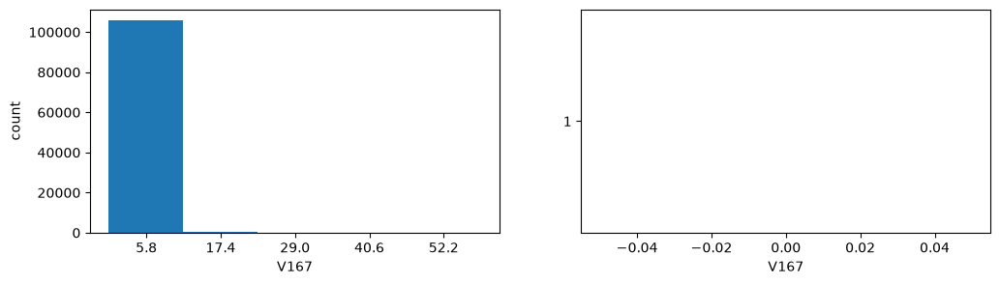

V168


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.215, 43.0]",21.4,106076,99.537389,99.537389
1,"(43.0, 86.0]",64.5,209,0.196117,99.733506
2,"(86.0, 129.0]",107.5,108,0.101343,99.834849
3,"(129.0, 172.0]",150.5,67,0.062870,99.897719
4,"(172.0, 215.0]",193.5,109,0.102281,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


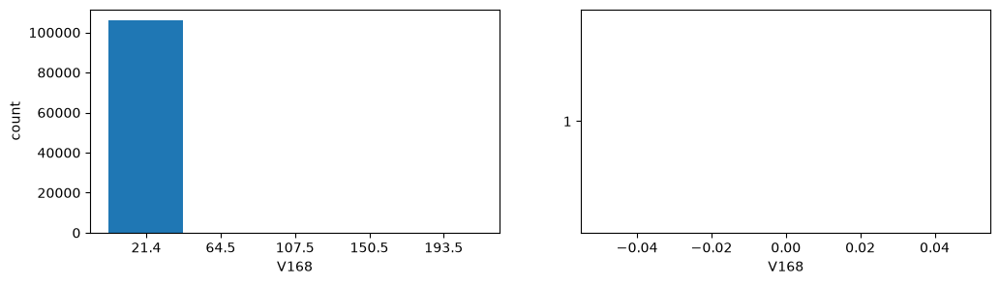

V169


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.019, 3.8]",1.9,104955,98.475324,98.475324
1,"(3.8, 7.6]",5.7,1312,1.231000,99.706324
2,"(7.6, 11.4]",9.5,232,0.217677,99.924001
3,"(11.4, 15.2]",13.3,72,0.067555,99.991556
4,"(15.2, 19.0]",17.1,9,0.008444,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


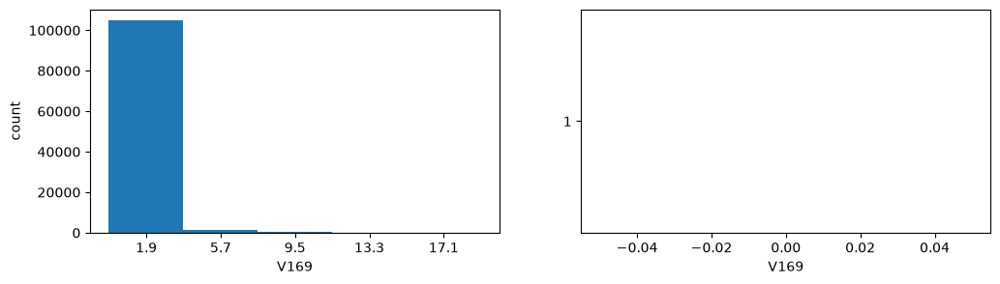

V170


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.048, 9.6]",4.8,105986,99.442672,99.442672
1,"(9.6, 19.2]",14.4,524,0.491649,99.934322
2,"(19.2, 28.8]",24.0,34,0.031901,99.966223
3,"(28.8, 38.4]",33.6,21,0.019704,99.985926
4,"(38.4, 48.0]",43.2,15,0.014074,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


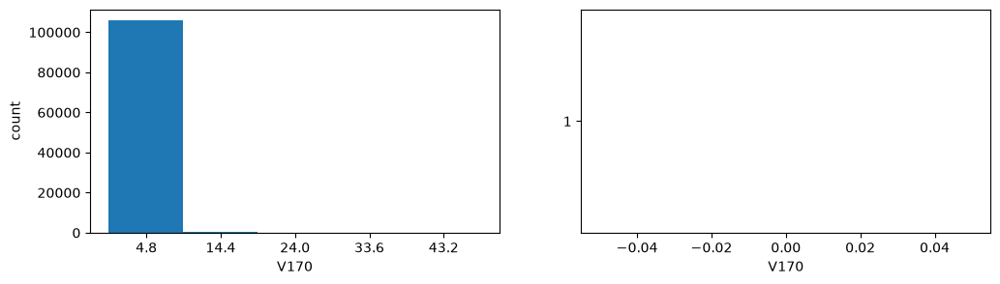

V171


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.048, 9.6]",4.8,105605,99.085194,99.085194
1,"(9.6, 19.2]",14.4,858,0.805029,99.890223
2,"(19.2, 28.8]",24.0,81,0.075999,99.966223
3,"(28.8, 38.4]",33.6,21,0.019704,99.985926
4,"(38.4, 48.0]",43.2,15,0.014074,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


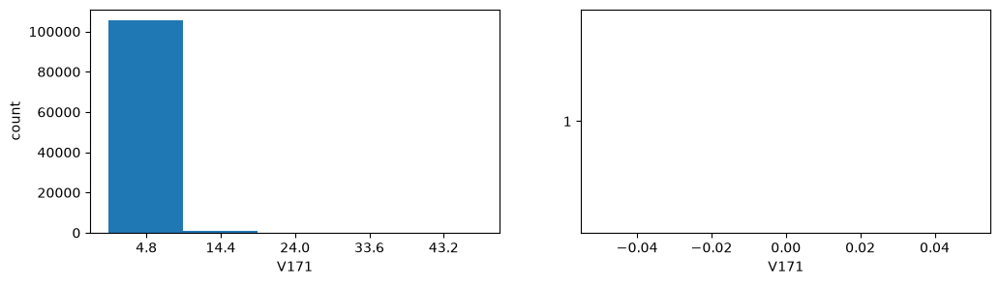

V172


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.031, 6.2]",3.1,106210,99.663129,99.663129
1,"(6.2, 12.4]",9.3,163,0.152953,99.816082
2,"(12.4, 18.6]",15.5,75,0.070377,99.886459
3,"(18.6, 24.8]",21.7,66,0.061932,99.948390
4,"(24.8, 31.0]",27.9,55,0.051610,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


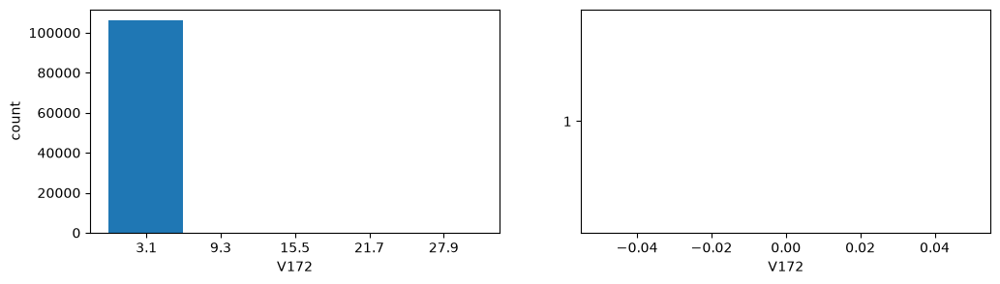

V173


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,105942,99.411649,99.411649
1,"(1.4, 2.8]",2.1,481,0.451351,99.863000
2,"(2.8, 4.2]",3.5,133,0.124802,99.987801
3,"(4.2, 5.6]",4.9,5,0.004692,99.992493
4,"(5.6, 7.0]",6.3,8,0.007507,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


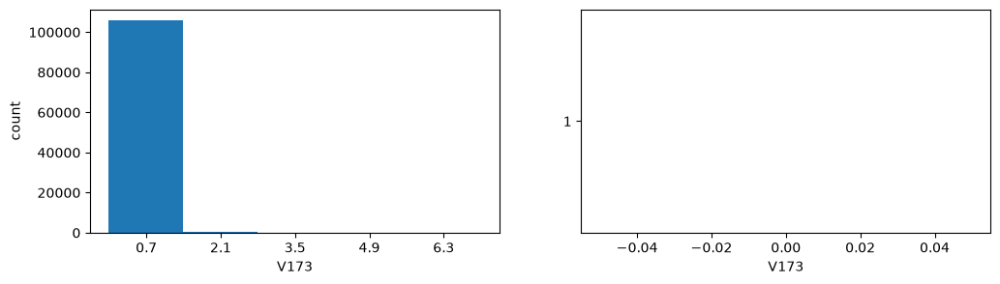

V174


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.008, 1.6]",0.8,105376,98.870332,98.870332
1,"(1.6, 3.2]",2.4,1180,1.107150,99.977482
2,"(3.2, 4.8]",4.0,14,0.013136,99.990617
3,"(4.8, 6.4]",5.6,7,0.006568,99.997185
4,"(6.4, 8.0]",7.2,3,0.002815,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


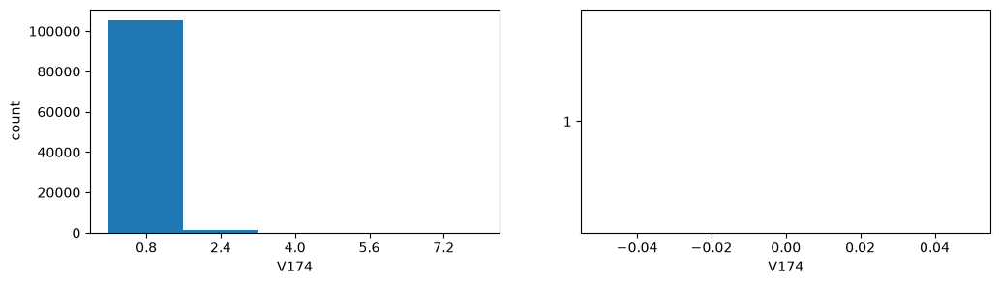

V175


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.014, 2.8]",1.4,105787,99.255958,99.255958
1,"(2.8, 5.6]",4.2,609,0.571402,99.827360
2,"(5.6, 8.4]",7.0,122,0.114468,99.941828
3,"(8.4, 11.2]",9.8,59,0.055357,99.997185
4,"(11.2, 14.0]",12.6,3,0.002815,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


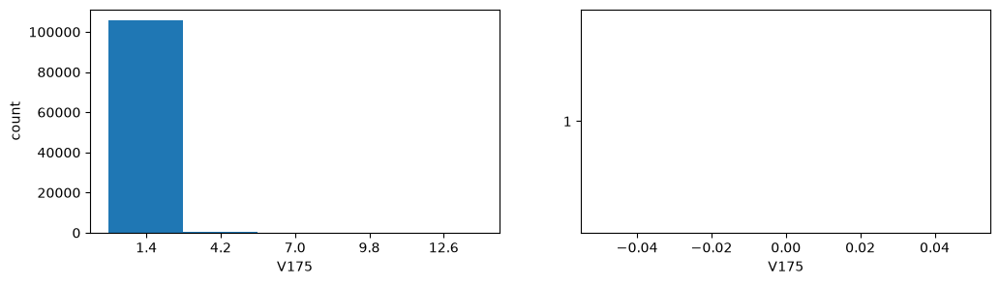

V176


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.048, 9.6]",4.8,105839,99.314998,99.314998
1,"(9.6, 19.2]",14.4,472,0.442906,99.757903
2,"(19.2, 28.8]",24.0,123,0.115418,99.873322
3,"(28.8, 38.4]",33.6,93,0.087267,99.960589
4,"(38.4, 48.0]",43.2,42,0.039411,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


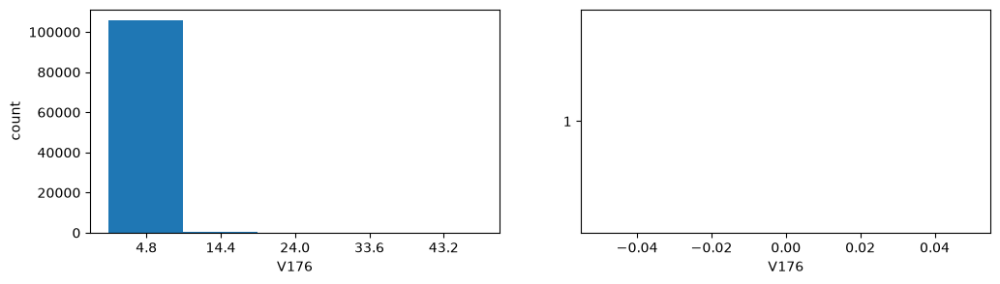

V177


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.047, 9.4]",4.7,106129,99.587122,99.587122
1,"(9.4, 18.8]",14.1,340,0.319042,99.906164
2,"(18.8, 28.2]",23.5,67,0.062870,99.969034
3,"(28.2, 37.6]",32.9,19,0.017829,99.986863
4,"(37.6, 47.0]",42.3,14,0.013137,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


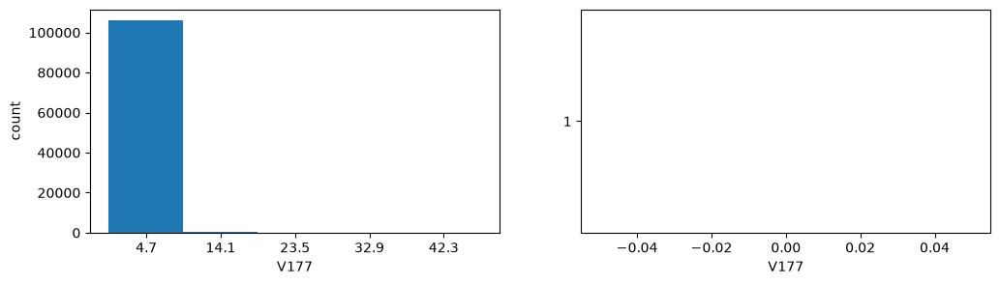

V178


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.13, 26.0]",12.9,105818,99.295292,99.295292
1,"(26.0, 52.0]",39.0,243,0.228021,99.523314
2,"(52.0, 78.0]",65.0,190,0.178288,99.701602
3,"(78.0, 104.0]",91.0,200,0.187672,99.889274
4,"(104.0, 130.0]",117.0,118,0.110726,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


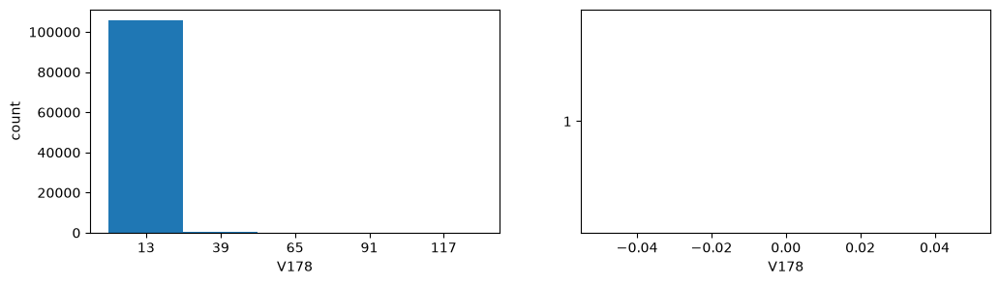

V179


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.068, 13.6]",6.8,105858,99.332827,99.332827
1,"(13.6, 27.2]",20.4,398,0.373467,99.706294
2,"(27.2, 40.8]",34.0,92,0.086329,99.792623
3,"(40.8, 54.4]",47.6,132,0.123863,99.916486
4,"(54.4, 68.0]",61.2,89,0.083514,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


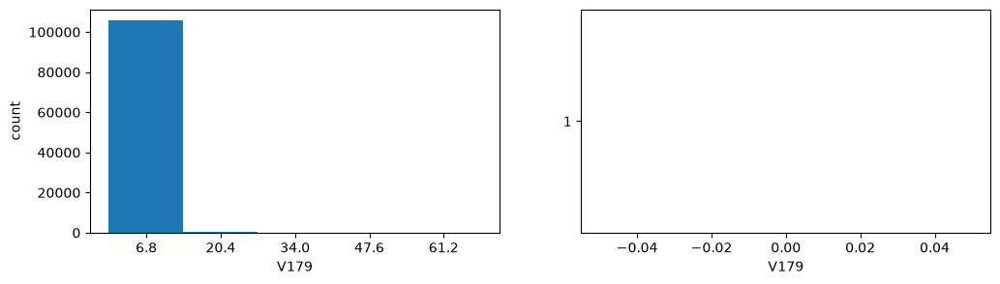

V180


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.068, 13.6]",6.8,105735,99.207168,99.207168
1,"(13.6, 27.2]",20.4,334,0.313380,99.520548
2,"(27.2, 40.8]",34.0,275,0.258022,99.778570
3,"(40.8, 54.4]",47.6,125,0.117283,99.895853
4,"(54.4, 68.0]",61.2,111,0.104147,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


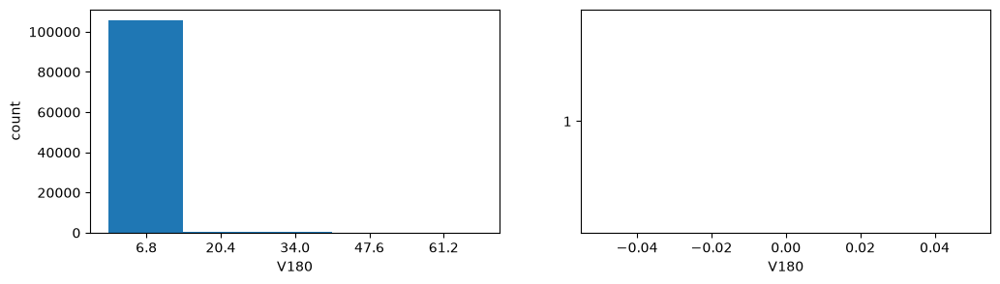

V181


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.016, 3.2]",1.6,106016,99.481087,99.481087
1,"(3.2, 6.4]",4.8,411,0.385666,99.866753
2,"(6.4, 9.6]",8.0,72,0.067562,99.934315
3,"(9.6, 12.8]",11.2,42,0.039411,99.973726
4,"(12.8, 16.0]",14.4,28,0.026274,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


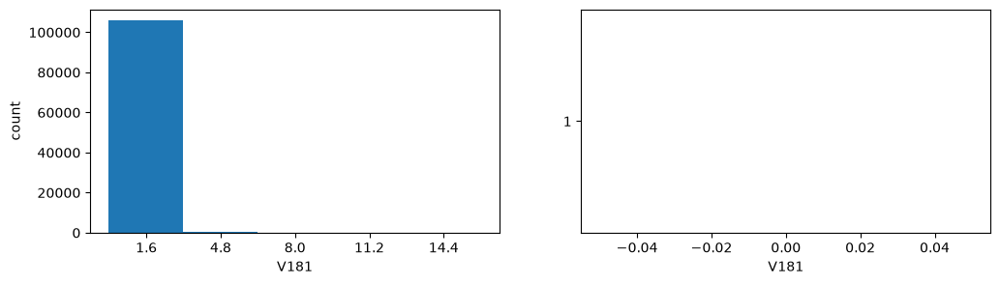

V182


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.05, 10.0]",5.0,105696,99.180812,99.180812
1,"(10.0, 20.0]",15.0,412,0.386604,99.567416
2,"(20.0, 30.0]",25.0,216,0.202686,99.770102
3,"(30.0, 40.0]",35.0,123,0.115418,99.885520
4,"(40.0, 50.0]",45.0,122,0.114480,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


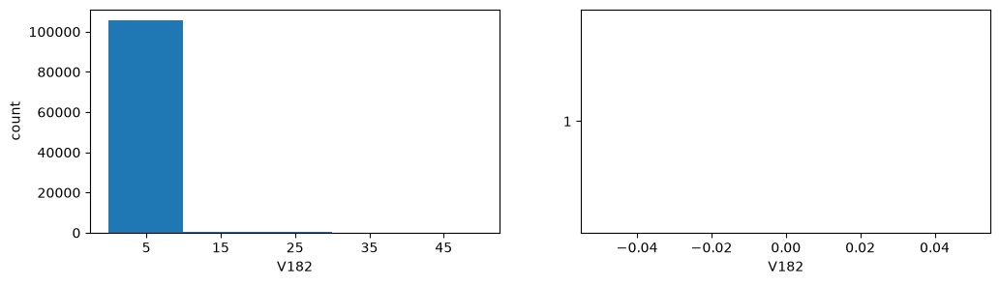

V183


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.03, 6.0]",3.0,105954,99.422909,99.422909
1,"(6.0, 12.0]",9.0,362,0.339686,99.762595
2,"(12.0, 18.0]",15.0,207,0.194240,99.956835
3,"(18.0, 24.0]",21.0,22,0.020644,99.977479
4,"(24.0, 30.0]",27.0,24,0.022521,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


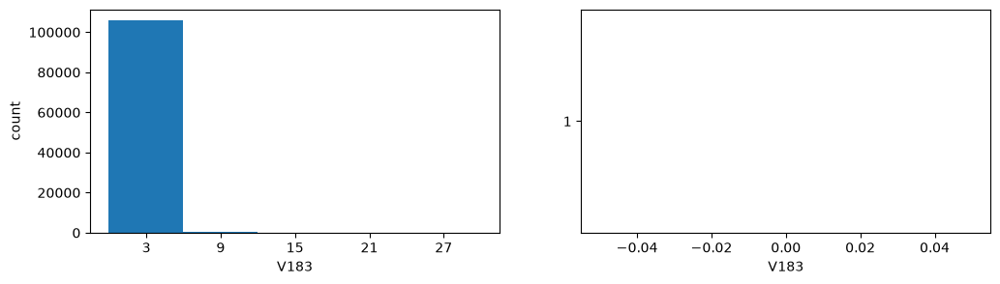

V184


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.016, 3.2]",1.6,106219,99.661287,99.661287
1,"(3.2, 6.4]",4.8,294,0.275849,99.937136
2,"(6.4, 9.6]",8.0,38,0.035654,99.972790
3,"(9.6, 12.8]",11.2,25,0.023457,99.996247
4,"(12.8, 16.0]",14.4,4,0.003753,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


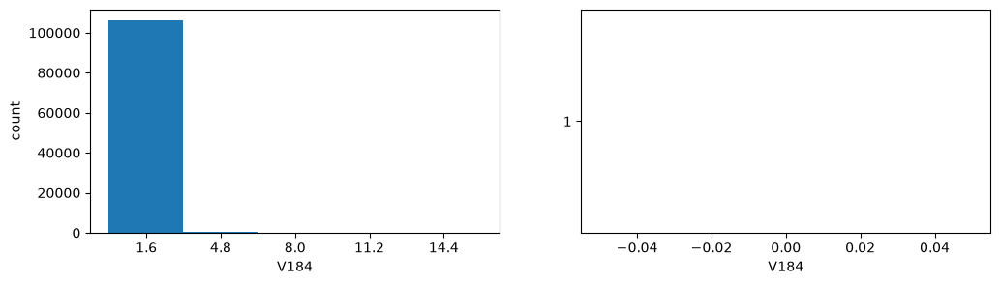

V185


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.016, 3.2]",1.6,106069,99.520548,99.520548
1,"(3.2, 6.4]",4.8,407,0.381873,99.902421
2,"(6.4, 9.6]",8.0,62,0.058172,99.960593
3,"(9.6, 12.8]",11.2,33,0.030963,99.991556
4,"(12.8, 16.0]",14.4,9,0.008444,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


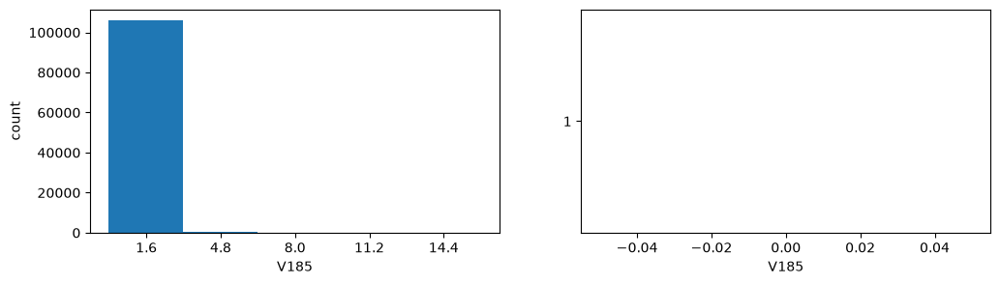

V186


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.038, 7.6]",3.8,106032,99.496101,99.496101
1,"(7.6, 15.2]",11.4,287,0.269309,99.765410
2,"(15.2, 22.8]",19.0,125,0.117295,99.882705
3,"(22.8, 30.4]",26.6,82,0.076945,99.959651
4,"(30.4, 38.0]",34.2,43,0.040349,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


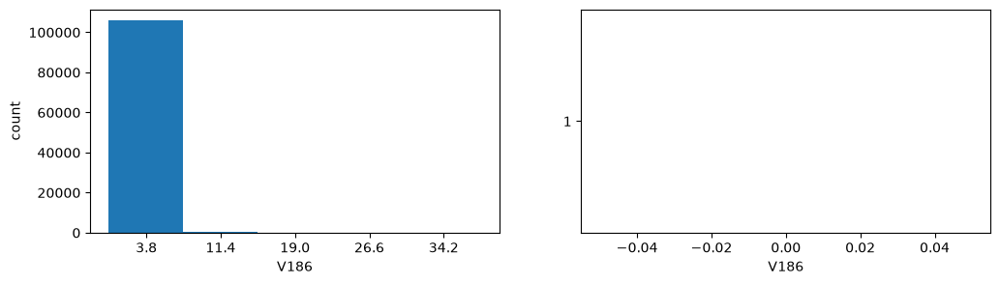

V187


,bins,mid_bin,counts,freq,cum_freq
0,"(0.783, 44.4]",22.6,105885,99.358162,99.358162
1,"(44.4, 87.8]",66.1,184,0.172658,99.530820
2,"(87.8, 131.2]",109.5,183,0.171720,99.702540
3,"(131.2, 174.6]",152.9,150,0.140754,99.843294
4,"(174.6, 218.0]",196.3,167,0.156706,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


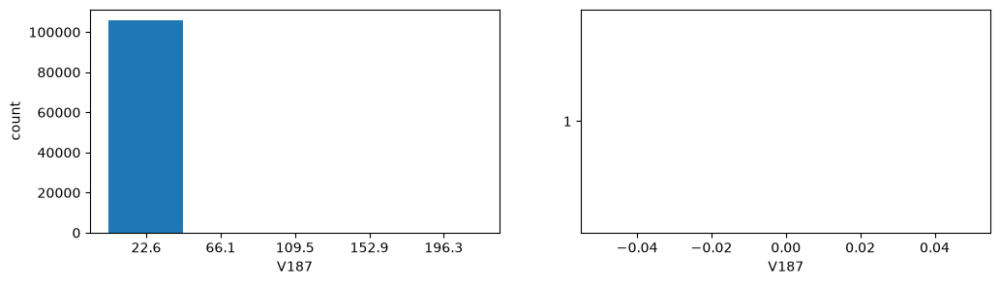

V188


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.017, 3.4]",1.7,105970,99.427660,99.427660
1,"(3.4, 6.8]",5.1,445,0.417527,99.845187
2,"(6.8, 10.2]",8.5,127,0.119159,99.964346
3,"(10.2, 13.6]",11.9,26,0.024395,99.988741
4,"(13.6, 17.0]",15.3,12,0.011259,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


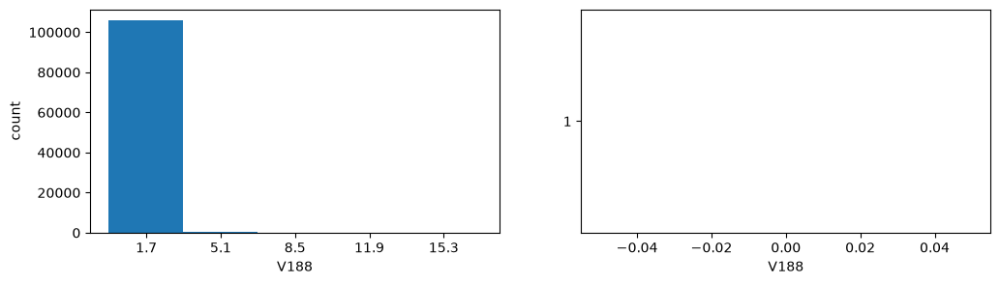

V189


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.017, 3.4]",1.7,105733,99.205292,99.205292
1,"(3.4, 6.8]",5.1,511,0.479452,99.684744
2,"(6.8, 10.2]",8.5,221,0.207356,99.892100
3,"(10.2, 13.6]",11.9,97,0.091011,99.983111
4,"(13.6, 17.0]",15.3,18,0.016889,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


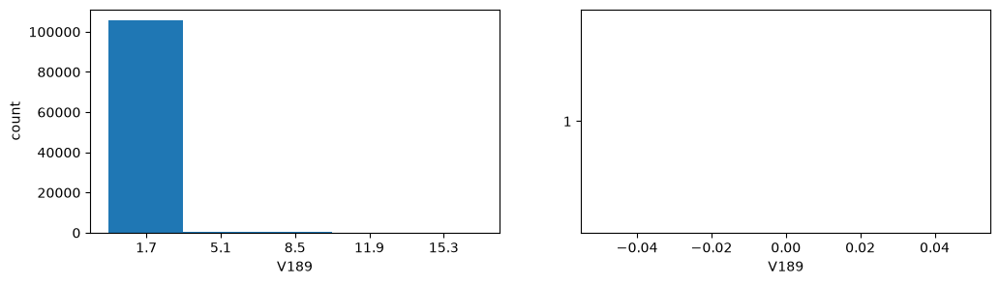

V190


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.042, 8.4]",4.2,105972,99.439800,99.439800
1,"(8.4, 16.8]",12.6,310,0.290891,99.730691
2,"(16.8, 25.2]",21.0,159,0.149199,99.879890
3,"(25.2, 33.6]",29.4,82,0.076945,99.956835
4,"(33.6, 42.0]",37.8,46,0.043165,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


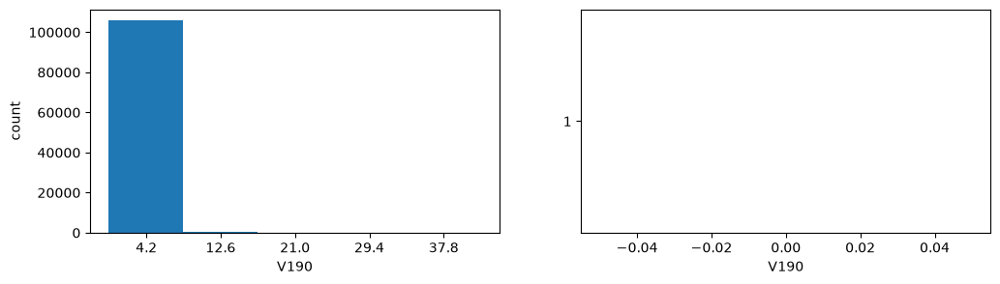

V191


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.021, 4.2]",2.1,105993,99.459505,99.459505
1,"(4.2, 8.4]",6.3,271,0.254295,99.713800
2,"(8.4, 12.6]",10.5,161,0.151076,99.864876
3,"(12.6, 16.8]",14.7,76,0.071315,99.936192
4,"(16.8, 21.0]",18.9,68,0.063808,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


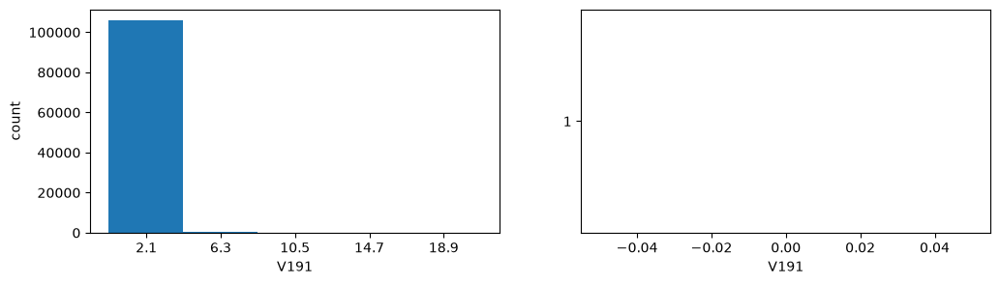

V192


,bins,mid_bin,counts,freq,cum_freq
0,"(0.957, 9.6]",5.3,105772,99.252128,99.252128
1,"(9.6, 18.2]",13.9,70,0.065685,99.317813
2,"(18.2, 26.8]",22.5,74,0.069439,99.387251
3,"(26.8, 35.4]",31.1,235,0.220514,99.607766
4,"(35.4, 44.0]",39.7,418,0.392234,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


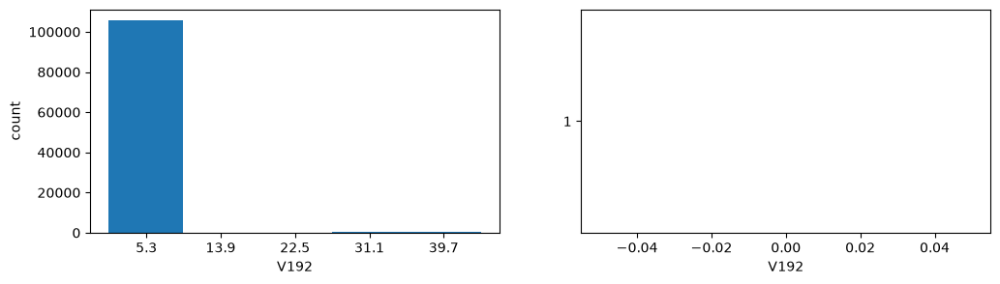

V193


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.037, 7.4]",3.7,105821,99.298107,99.298107
1,"(7.4, 14.8]",11.1,187,0.175473,99.473580
2,"(14.8, 22.2]",18.5,159,0.149199,99.622780
3,"(22.2, 29.6]",25.9,253,0.237405,99.860184
4,"(29.6, 37.0]",33.3,149,0.139816,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


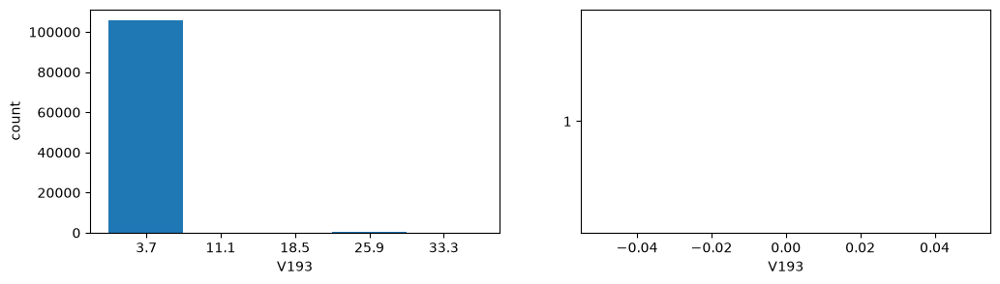

V194


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.007, 1.4]",0.7,105563,99.045787,99.045787
1,"(1.4, 2.8]",2.1,799,0.749672,99.795459
2,"(2.8, 4.2]",3.5,193,0.181085,99.976543
3,"(4.2, 5.6]",4.9,13,0.012197,99.988741
4,"(5.6, 7.0]",6.3,12,0.011259,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


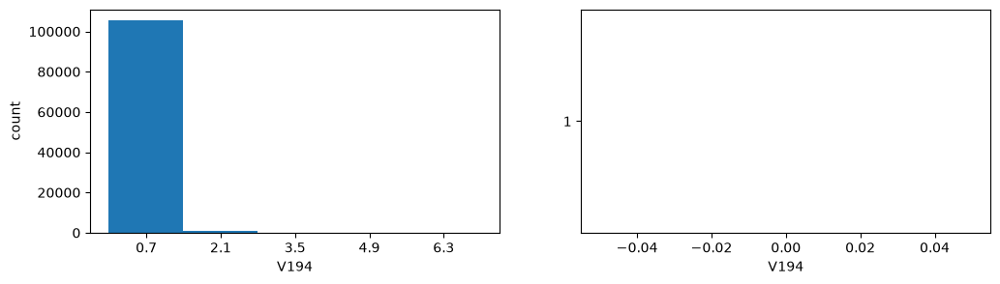

V195


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.008, 1.6]",0.8,105314,98.812160,98.812160
1,"(1.6, 3.2]",2.4,1123,1.053669,99.865828
2,"(3.2, 4.8]",4.0,43,0.040345,99.906174
3,"(4.8, 6.4]",5.6,40,0.037530,99.943704
4,"(6.4, 8.0]",7.2,60,0.056296,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


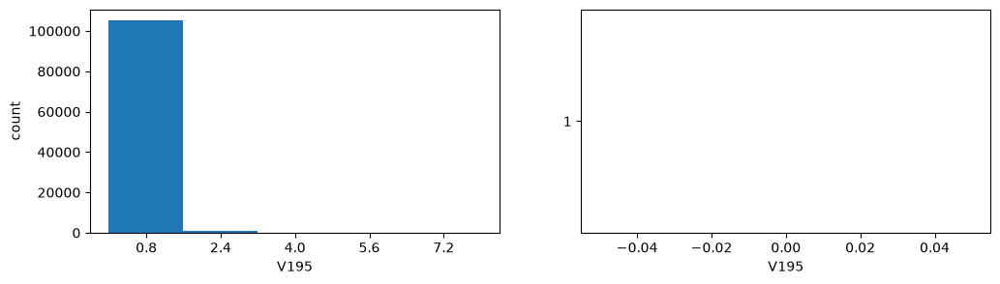

V196


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.038, 7.6]",3.8,106104,99.563663,99.563663
1,"(7.6, 15.2]",11.4,224,0.210192,99.773855
2,"(15.2, 22.8]",19.0,124,0.116357,99.890212
3,"(22.8, 30.4]",26.6,77,0.072254,99.962466
4,"(30.4, 38.0]",34.2,40,0.037534,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


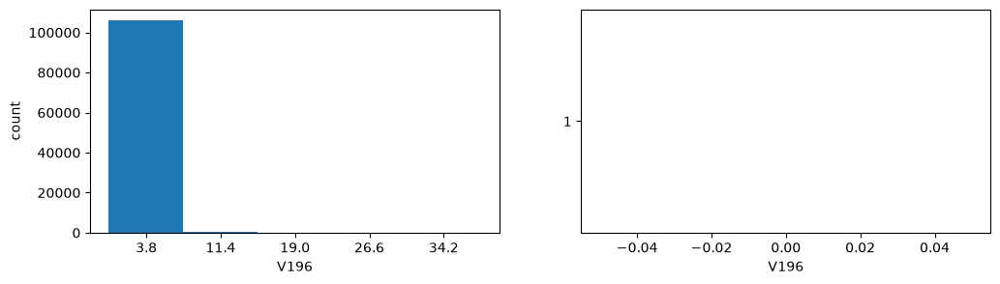

V197


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.014, 2.8]",1.4,106253,99.693188,99.693188
1,"(2.8, 5.6]",4.2,287,0.269281,99.962470
2,"(5.6, 8.4]",7.0,30,0.028148,99.990617
3,"(8.4, 11.2]",9.8,5,0.004691,99.995309
4,"(11.2, 14.0]",12.6,5,0.004691,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


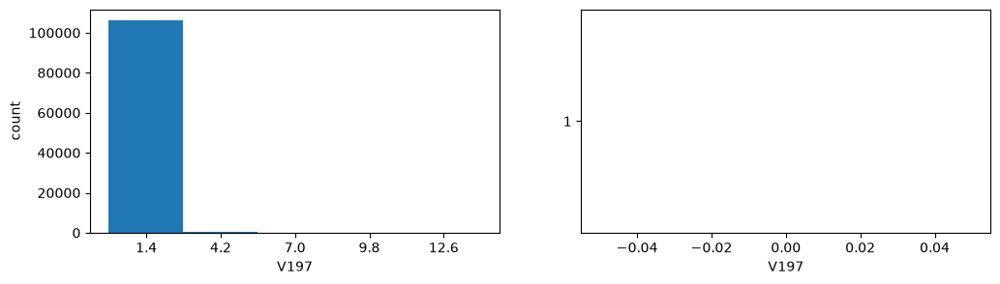

V198


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.014, 2.8]",1.4,106096,99.545881,99.545881
1,"(2.8, 5.6]",4.2,350,0.328392,99.874273
2,"(5.6, 8.4]",7.0,43,0.040345,99.914618
3,"(8.4, 11.2]",9.8,30,0.028148,99.942766
4,"(11.2, 14.0]",12.6,61,0.057234,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


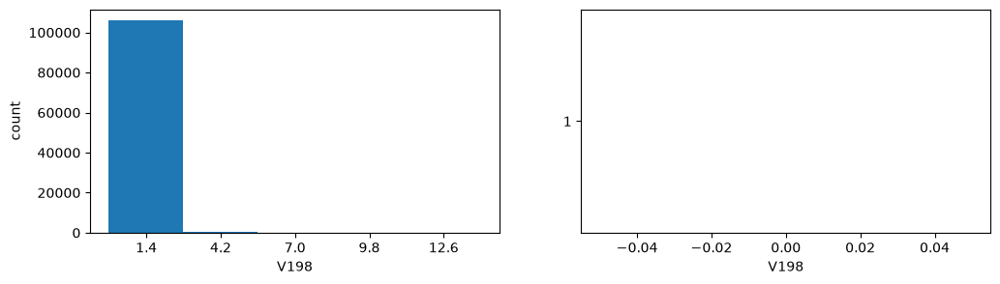

V199


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.045, 9.0]",4.5,105968,99.436046,99.436046
1,"(9.0, 18.0]",13.5,303,0.284323,99.720369
2,"(18.0, 27.0]",22.5,156,0.146384,99.866753
3,"(27.0, 36.0]",31.5,99,0.092898,99.959651
4,"(36.0, 45.0]",40.5,43,0.040349,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


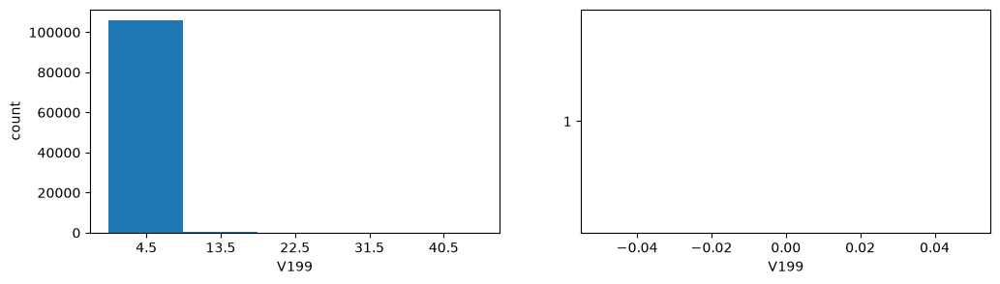

V200


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.045, 9.0]",4.5,106365,99.798274,99.798274
1,"(9.0, 18.0]",13.5,150,0.140739,99.939013
2,"(18.0, 27.0]",22.5,27,0.025333,99.964346
3,"(27.0, 36.0]",31.5,23,0.021580,99.985926
4,"(36.0, 45.0]",40.5,15,0.014074,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


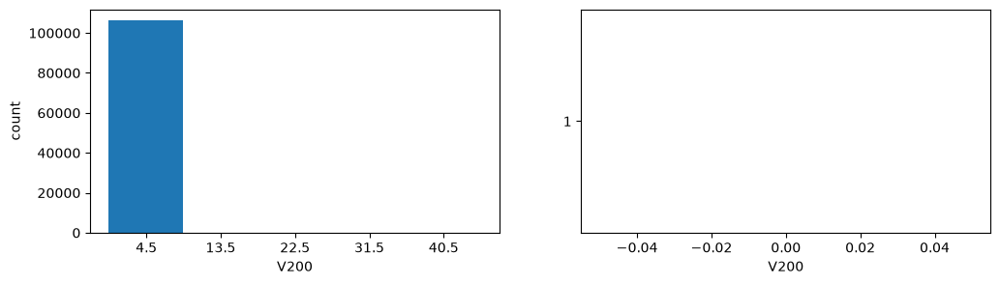

V201


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.045, 9.0]",4.5,106227,99.668793,99.668793
1,"(9.0, 18.0]",13.5,283,0.265528,99.934322
2,"(18.0, 27.0]",22.5,32,0.030024,99.964346
3,"(27.0, 36.0]",31.5,23,0.021580,99.985926
4,"(36.0, 45.0]",40.5,15,0.014074,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


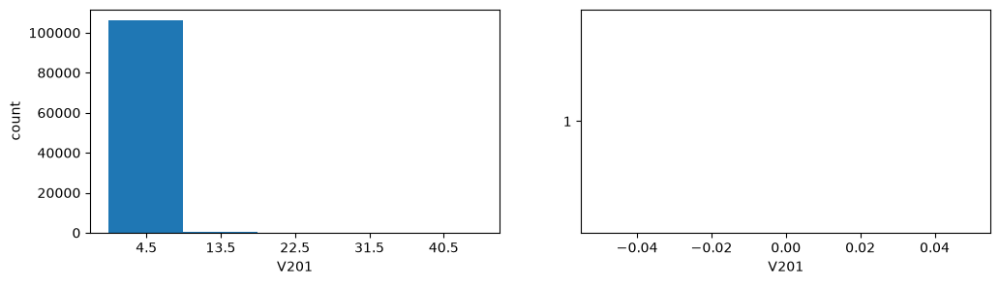

V202


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,106564,99.995308,99.995308
1,"(20328.0, 40656.0]",30492.0,2,0.001877,99.997185
2,"(40656.0, 60984.0]",50820.0,2,0.001877,99.999062
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999062
4,"(81312.0, 101640.0]",91476.0,1,0.000938,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


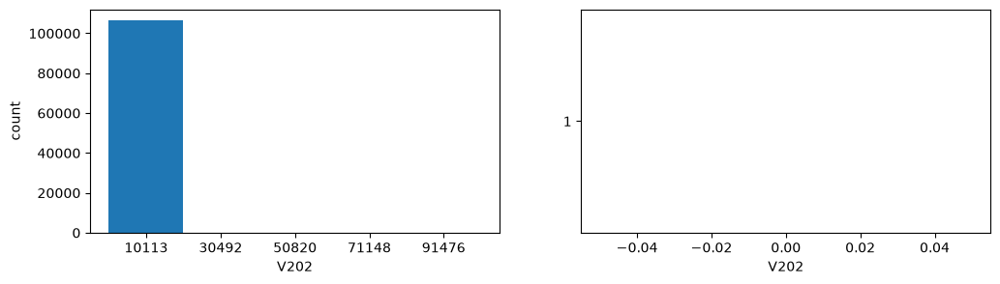

V203


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,105885,99.358162,99.358162
1,"(20328.0, 40656.0]",30492.0,156,0.146384,99.504546
2,"(40656.0, 60984.0]",50820.0,225,0.211131,99.715677
3,"(60984.0, 81312.0]",71148.0,179,0.167966,99.883643
4,"(81312.0, 101640.0]",91476.0,124,0.116357,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


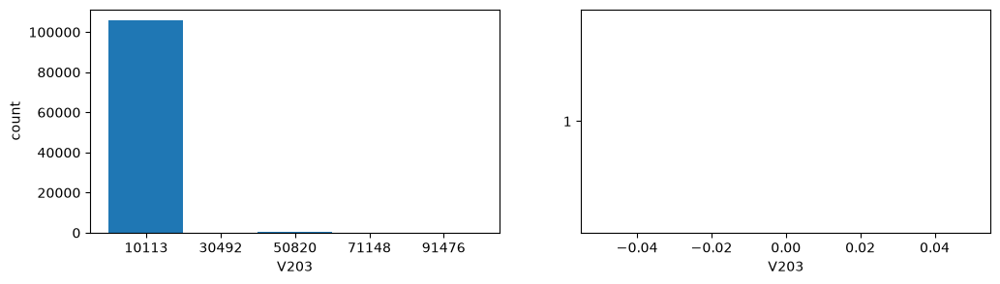

V204


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,106248,99.698787,99.698787
1,"(20328.0, 40656.0]",30492.0,244,0.228960,99.927746
2,"(40656.0, 60984.0]",50820.0,76,0.071315,99.999062
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999062
4,"(81312.0, 101640.0]",91476.0,1,0.000938,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


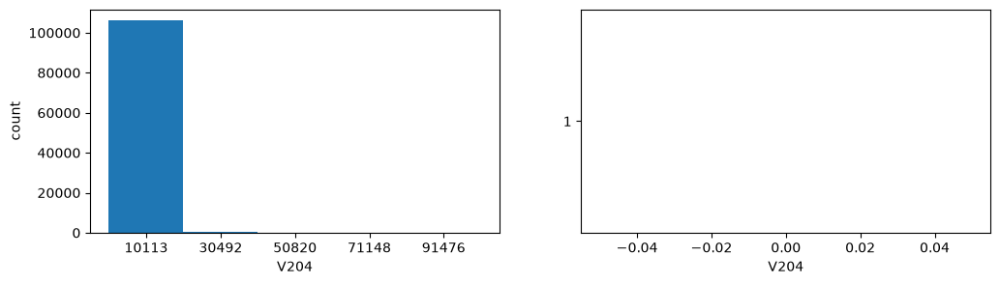

V205


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,106565,99.996247,99.996247
1,"(11025.0, 22050.0]",16537.5,2,0.001877,99.998123
2,"(22050.0, 33075.0]",27562.5,1,0.000938,99.999062
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999062
4,"(44100.0, 55125.0]",49612.5,1,0.000938,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


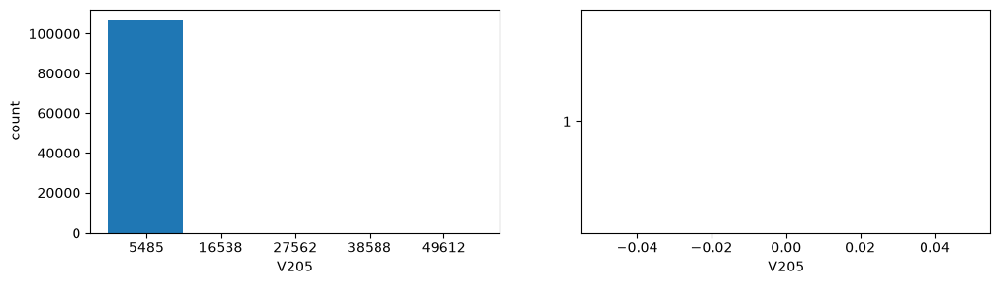

V206


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,106566,99.997185,99.997185
1,"(11025.0, 22050.0]",16537.5,1,0.000938,99.998123
2,"(22050.0, 33075.0]",27562.5,1,0.000938,99.999062
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999062
4,"(44100.0, 55125.0]",49612.5,1,0.000938,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


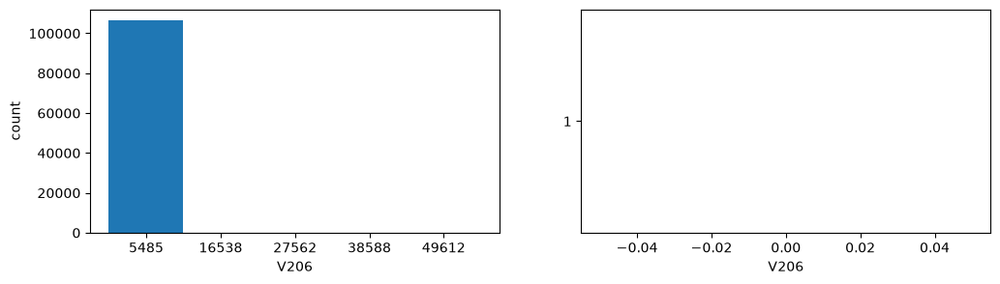

V207


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,106289,99.737259,99.737259
1,"(11025.0, 22050.0]",16537.5,186,0.174535,99.911794
2,"(22050.0, 33075.0]",27562.5,93,0.087267,99.999062
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999062
4,"(44100.0, 55125.0]",49612.5,1,0.000938,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


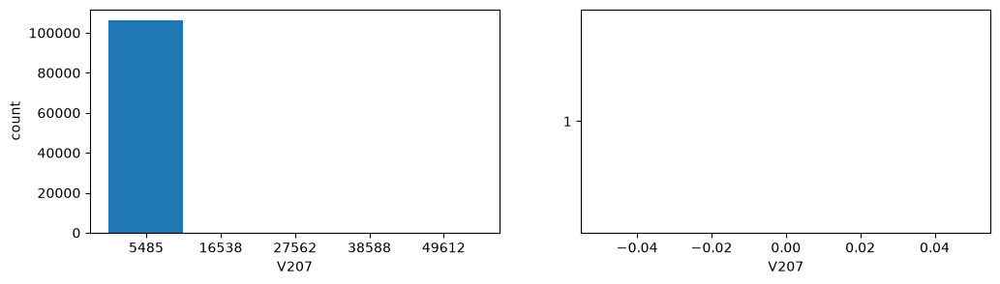

V208


,bins,mid_bin,counts,freq,cum_freq
0,"(-3.3, 660.0]",328.4,106419,99.848940,99.848940
1,"(660.0, 1320.0]",990.0,124,0.116345,99.965284
2,"(1320.0, 1980.0]",1650.0,5,0.004691,99.969976
3,"(1980.0, 2640.0]",2310.0,18,0.016889,99.986864
4,"(2640.0, 3300.0]",2970.0,14,0.013136,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


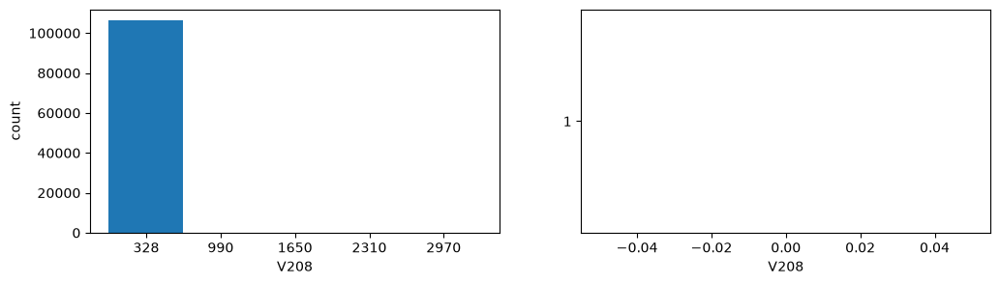

V209


,bins,mid_bin,counts,freq,cum_freq
0,"(-8.05, 1610.0]",801.0,106220,99.662226,99.662226
1,"(1610.0, 3220.0]",2415.0,221,0.207356,99.869582
2,"(3220.0, 4830.0]",4025.0,121,0.113530,99.983111
3,"(4830.0, 6440.0]",5635.0,4,0.003753,99.986864
4,"(6440.0, 8050.0]",7245.0,14,0.013136,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


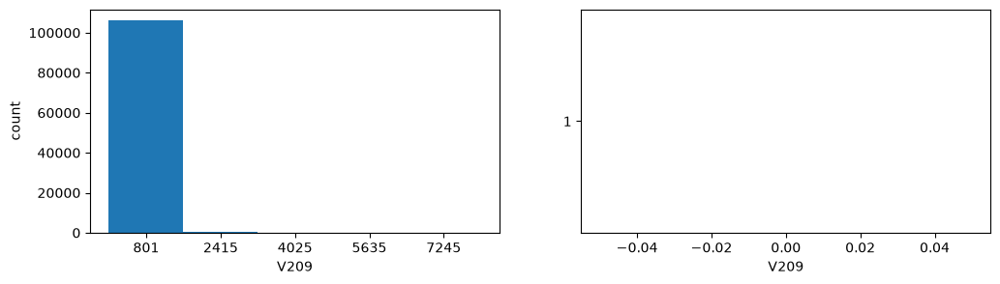

V210


,bins,mid_bin,counts,freq,cum_freq
0,"(-3.3, 660.0]",328.4,106317,99.753237,99.753237
1,"(660.0, 1320.0]",990.0,166,0.155752,99.908989
2,"(1320.0, 1980.0]",1650.0,62,0.058172,99.967161
3,"(1980.0, 2640.0]",2310.0,19,0.017827,99.984988
4,"(2640.0, 3300.0]",2970.0,16,0.015012,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


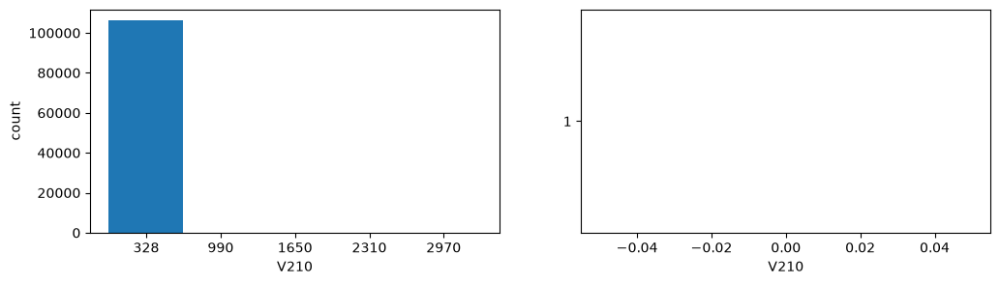

V211


,bins,mid_bin,counts,freq,cum_freq
0,"(-13.2, 2640.0]",1313.4,106316,99.762595,99.762595
1,"(2640.0, 5280.0]",3960.0,181,0.169843,99.932438
2,"(5280.0, 7920.0]",6600.0,50,0.046918,99.979356
3,"(7920.0, 10560.0]",9240.0,18,0.016890,99.996247
4,"(10560.0, 13200.0]",11880.0,4,0.003753,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


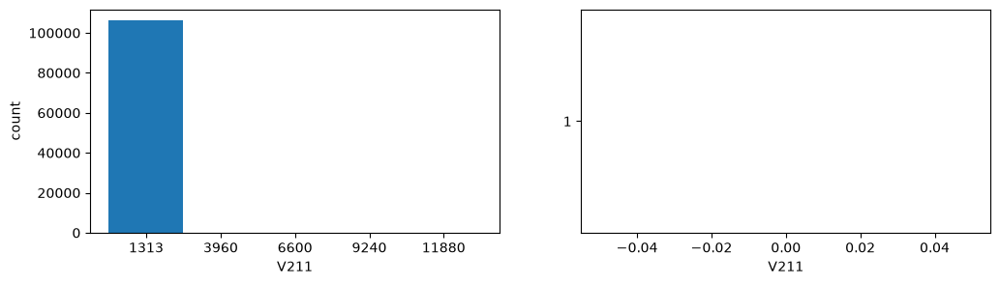

V212


,bins,mid_bin,counts,freq,cum_freq
0,"(-66.0, 13200.0]",6567.0,106000,99.466074,99.466074
1,"(13200.0, 26400.0]",19800.0,333,0.312474,99.778547
2,"(26400.0, 39600.0]",33000.0,235,0.220514,99.999062
3,"(39600.0, 52800.0]",46200.0,0,0.000000,99.999062
4,"(52800.0, 66000.0]",59400.0,1,0.000938,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


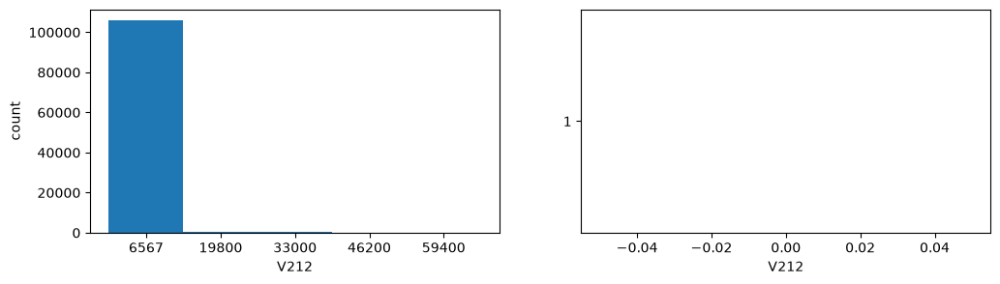

V213


,bins,mid_bin,counts,freq,cum_freq
0,"(-16.95, 3390.0]",1686.5,105940,99.409772,99.409772
1,"(3390.0, 6780.0]",5085.0,278,0.260864,99.670636
2,"(6780.0, 10170.0]",8475.0,148,0.138877,99.809513
3,"(10170.0, 13560.0]",11865.0,98,0.091959,99.901472
4,"(13560.0, 16950.0]",15255.0,105,0.098528,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


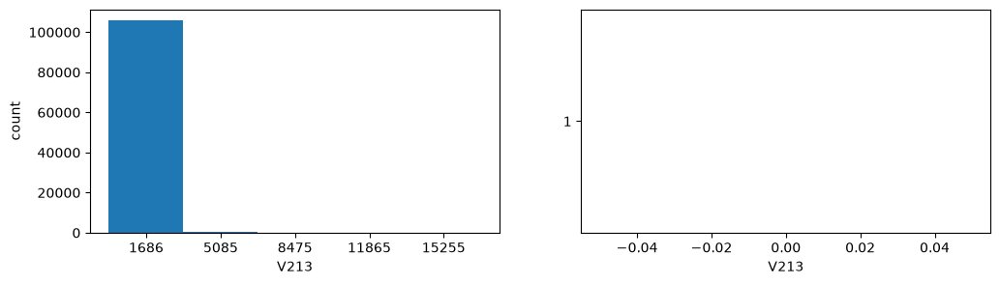

V214


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,106566,99.997185,99.997185
1,"(20328.0, 40656.0]",30492.0,1,0.000938,99.998123
2,"(40656.0, 60984.0]",50820.0,1,0.000938,99.999062
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999062
4,"(81312.0, 101640.0]",91476.0,1,0.000938,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


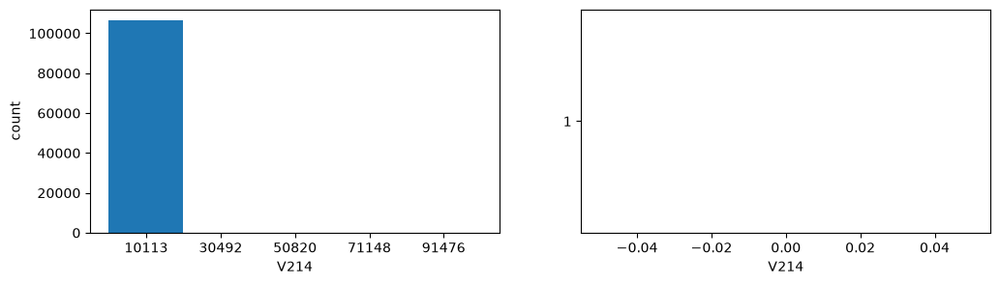

V215


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,106566,99.997185,99.997185
1,"(20328.0, 40656.0]",30492.0,1,0.000938,99.998123
2,"(40656.0, 60984.0]",50820.0,1,0.000938,99.999062
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999062
4,"(81312.0, 101640.0]",91476.0,1,0.000938,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


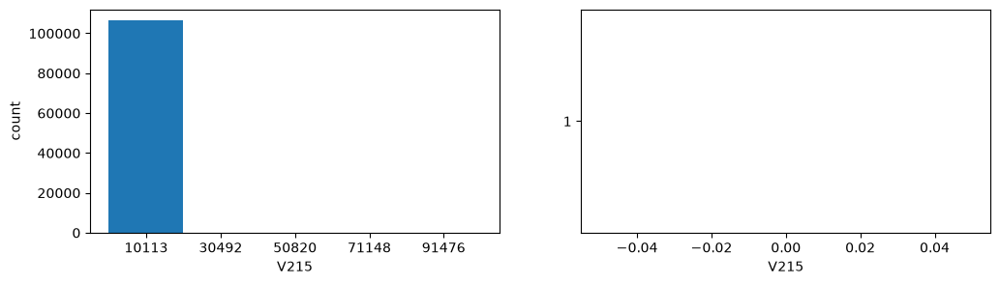

V216


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,106566,99.997185,99.997185
1,"(20328.0, 40656.0]",30492.0,1,0.000938,99.998123
2,"(40656.0, 60984.0]",50820.0,1,0.000938,99.999062
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999062
4,"(81312.0, 101640.0]",91476.0,1,0.000938,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


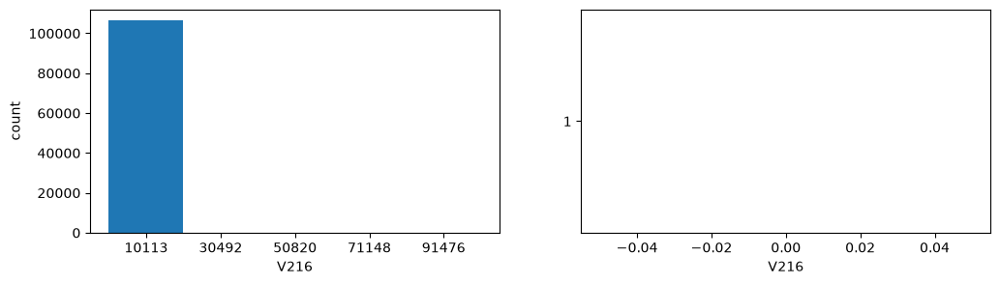

V217


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.053, 10.6]",5.3,100270,99.426860,99.426860
1,"(10.6, 21.2]",15.9,499,0.494804,99.921664
2,"(21.2, 31.8]",26.5,47,0.046605,99.968269
3,"(31.8, 42.4]",37.1,21,0.020823,99.989092
4,"(42.4, 53.0]",47.7,11,0.010908,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


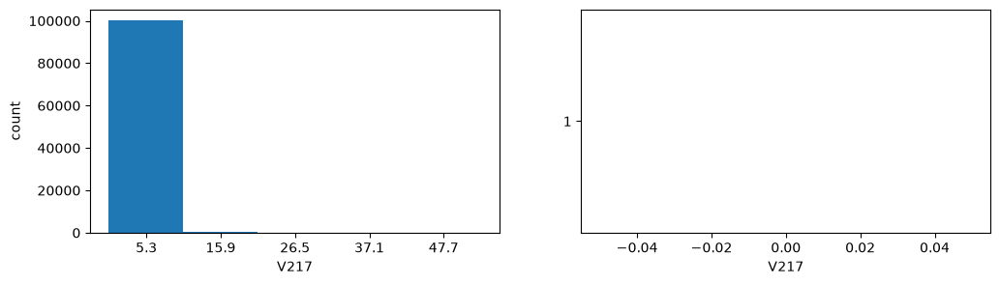

V218


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.219, 43.8]",21.8,100735,99.887950,99.887950
1,"(43.8, 87.6]",65.7,33,0.032723,99.920673
2,"(87.6, 131.4]",109.5,0,0.000000,99.920673
3,"(131.4, 175.2]",153.3,12,0.011899,99.932572
4,"(175.2, 219.0]",197.1,68,0.067428,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


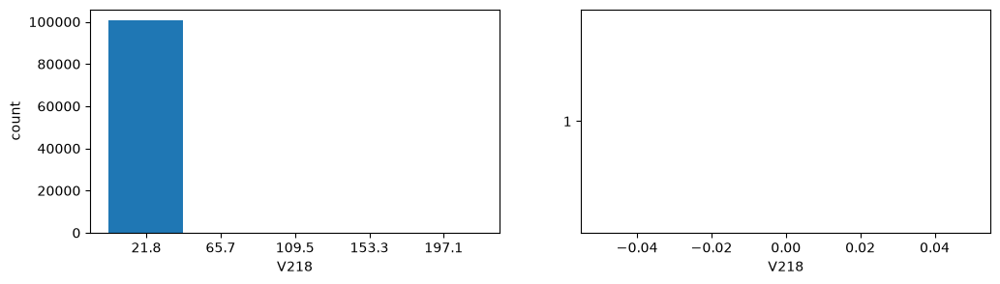

V219


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.079, 15.8]",7.9,100431,99.586506,99.586506
1,"(15.8, 31.6]",23.7,290,0.287561,99.874068
2,"(31.6, 47.4]",39.5,46,0.045613,99.919681
3,"(47.4, 63.2]",55.3,32,0.031731,99.951412
4,"(63.2, 79.0]",71.1,49,0.048588,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


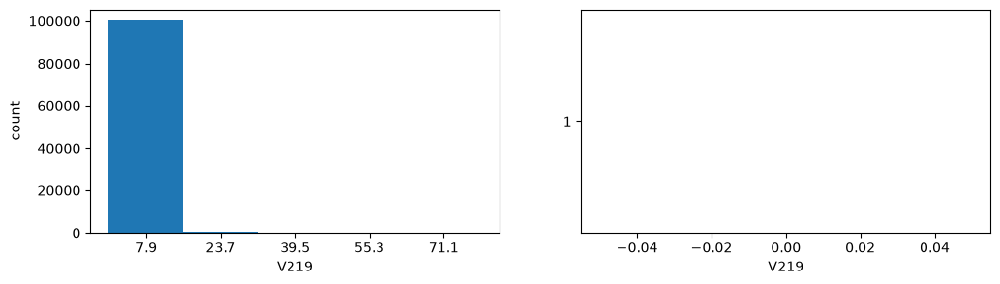

V220


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.024, 4.8]",2.4,107003,98.953160,98.953160
1,"(4.8, 9.6]",7.2,881,0.814722,99.767883
2,"(9.6, 14.4]",12.0,172,0.159060,99.926943
3,"(14.4, 19.2]",16.8,52,0.048088,99.975031
4,"(19.2, 24.0]",21.6,27,0.024969,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


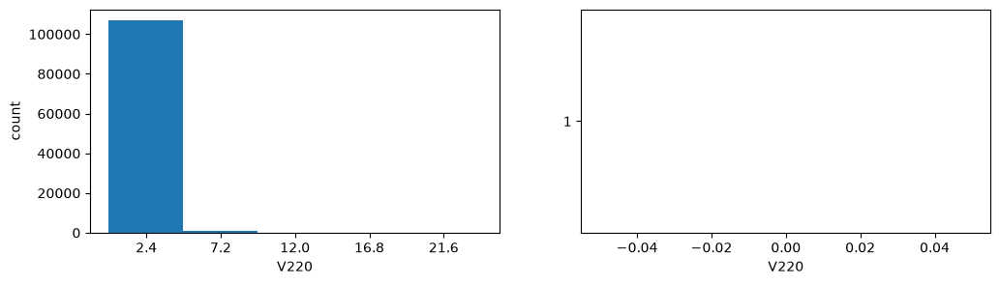

V221


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.384, 76.8]",38.2,108121,99.987053,99.987053
1,"(76.8, 153.6]",115.2,6,0.005549,99.992602
2,"(153.6, 230.4]",192.0,5,0.004624,99.997226
3,"(230.4, 307.2]",268.8,2,0.001850,99.999075
4,"(307.2, 384.0]",345.6,1,0.000925,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


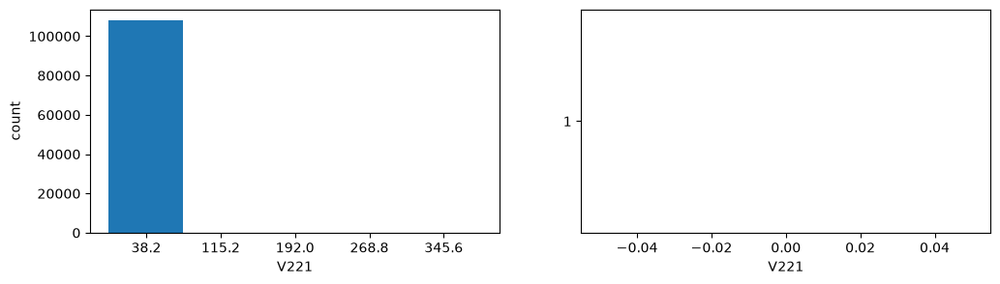

V222


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.384, 76.8]",38.2,108120,99.986128,99.986128
1,"(76.8, 153.6]",115.2,7,0.006473,99.992602
2,"(153.6, 230.4]",192.0,5,0.004624,99.997226
3,"(230.4, 307.2]",268.8,2,0.001850,99.999075
4,"(307.2, 384.0]",345.6,1,0.000925,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


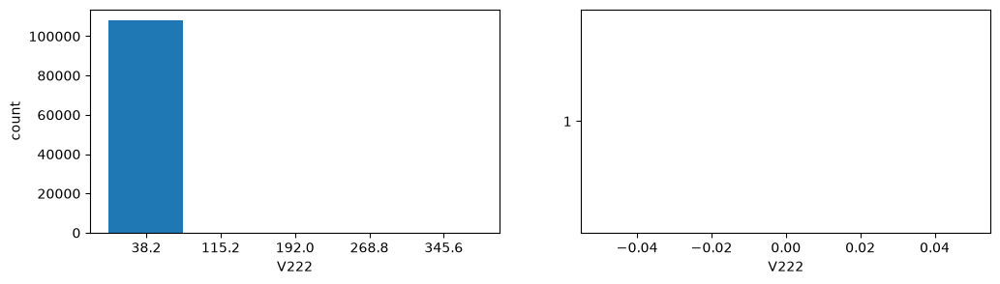

V223


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.016, 3.2]",1.6,100730,99.882992,99.882992
1,"(3.2, 6.4]",4.8,61,0.060487,99.943479
2,"(6.4, 9.6]",8.0,29,0.028756,99.972235
3,"(9.6, 12.8]",11.2,14,0.013882,99.986118
4,"(12.8, 16.0]",14.4,14,0.013882,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


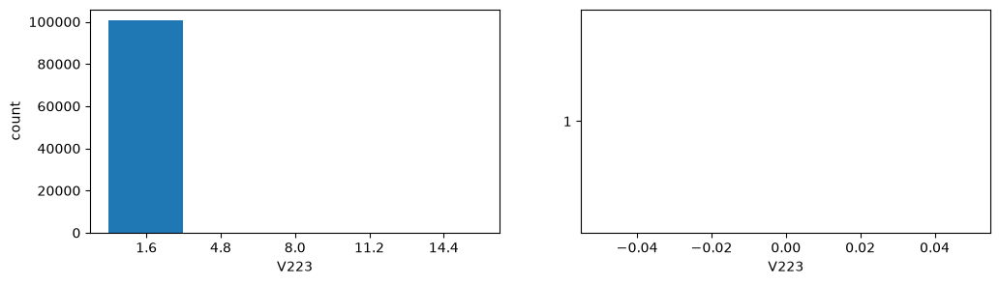

V224


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.144, 28.8]",14.3,100741,99.893900,99.893900
1,"(28.8, 57.6]",43.2,27,0.026773,99.920673
2,"(57.6, 86.4]",72.0,0,0.000000,99.920673
3,"(86.4, 115.2]",100.8,32,0.031731,99.952404
4,"(115.2, 144.0]",129.6,48,0.047596,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


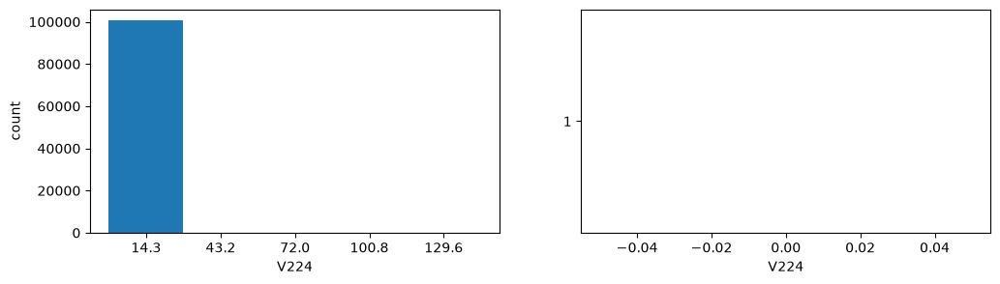

V225


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.051, 10.2]",5.1,100753,99.905799,99.905799
1,"(10.2, 20.4]",15.3,15,0.014874,99.920673
2,"(20.4, 30.6]",25.5,0,0.000000,99.920673
3,"(30.6, 40.8]",35.7,22,0.021815,99.942488
4,"(40.8, 51.0]",45.9,58,0.057512,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


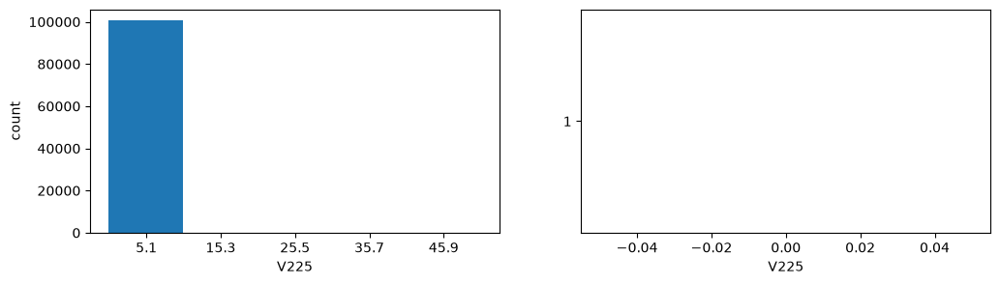

V226


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.242, 48.4]",24.1,100841,99.993059,99.993059
1,"(48.4, 96.8]",72.6,3,0.002975,99.996034
2,"(96.8, 145.2]",121.0,3,0.002975,99.999008
3,"(145.2, 193.6]",169.4,0,0.000000,99.999008
4,"(193.6, 242.0]",217.8,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


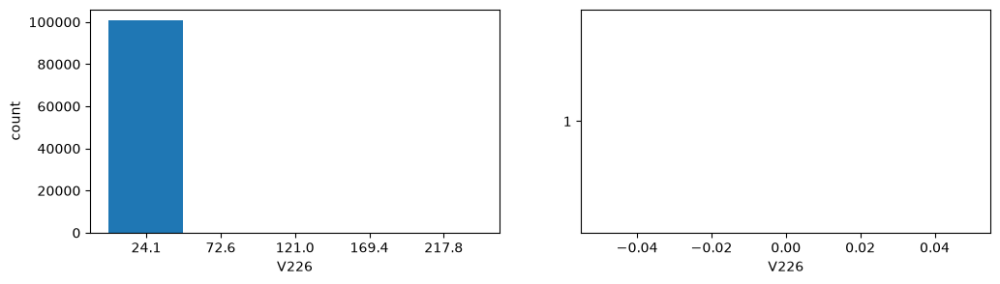

V227


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.36, 72.0]",35.8,108120,99.986128,99.986128
1,"(72.0, 144.0]",108.0,7,0.006473,99.992602
2,"(144.0, 216.0]",180.0,5,0.004624,99.997226
3,"(216.0, 288.0]",252.0,2,0.001850,99.999075
4,"(288.0, 360.0]",324.0,1,0.000925,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


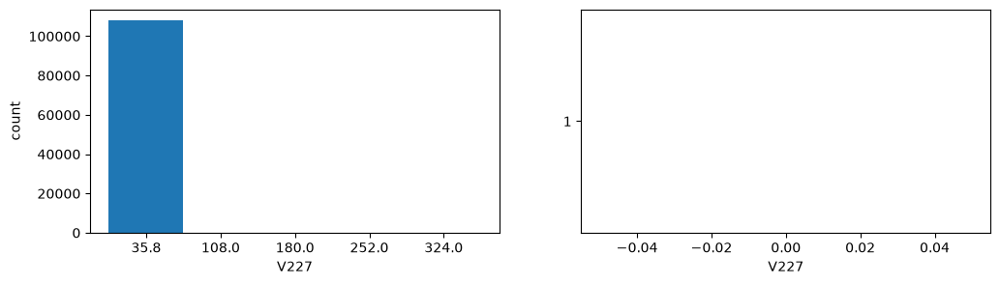

V228


,bins,mid_bin,counts,freq,cum_freq
0,"(0.947, 11.6]",6.3,100591,99.745161,99.745161
1,"(11.6, 22.2]",16.9,223,0.221125,99.966286
2,"(22.2, 32.8]",27.5,12,0.011899,99.978185
3,"(32.8, 43.4]",38.1,11,0.010908,99.989092
4,"(43.4, 54.0]",48.7,11,0.010908,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


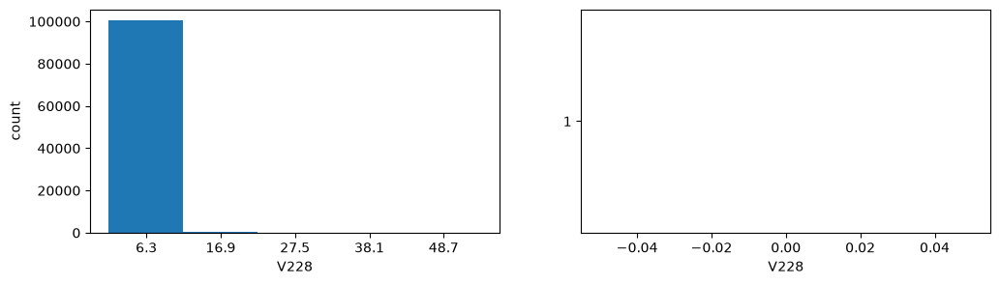

V229


,bins,mid_bin,counts,freq,cum_freq
0,"(0.825, 36.0]",18.4,100734,99.886959,99.886959
1,"(36.0, 71.0]",53.5,34,0.033714,99.920673
2,"(71.0, 106.0]",88.5,0,0.000000,99.920673
3,"(106.0, 141.0]",123.5,9,0.008924,99.929597
4,"(141.0, 176.0]",158.5,71,0.070403,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


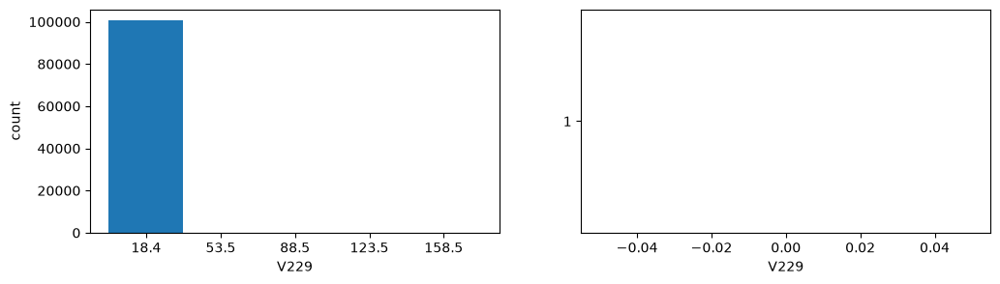

V230


,bins,mid_bin,counts,freq,cum_freq
0,"(0.936, 13.8]",7.4,100534,99.688640,99.688640
1,"(13.8, 26.6]",20.2,202,0.200301,99.888942
2,"(26.6, 39.4]",33.0,19,0.018840,99.907782
3,"(39.4, 52.2]",45.8,36,0.035697,99.943479
4,"(52.2, 65.0]",58.6,57,0.056521,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


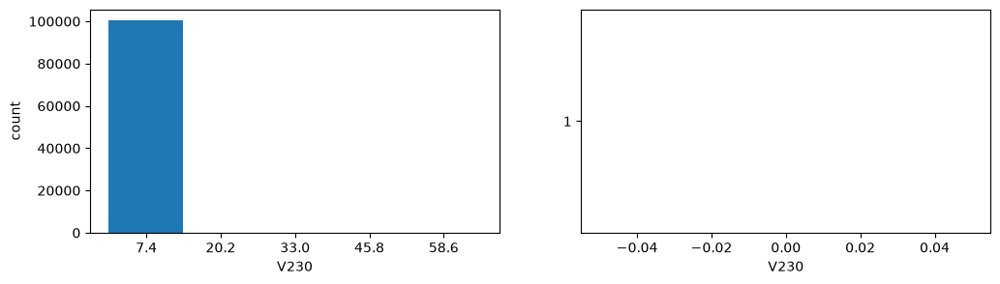

V231


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.051, 10.2]",5.1,100465,99.620221,99.620221
1,"(10.2, 20.4]",15.3,307,0.304419,99.924639
2,"(20.4, 30.6]",25.5,43,0.042638,99.967277
3,"(30.6, 40.8]",35.7,21,0.020823,99.988101
4,"(40.8, 51.0]",45.9,12,0.011899,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


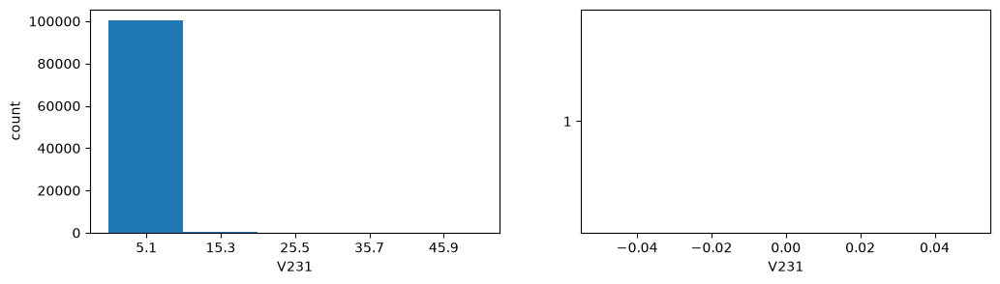

V232


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.051, 10.2]",5.1,100082,99.240441,99.240441
1,"(10.2, 20.4]",15.3,530,0.525543,99.765984
2,"(20.4, 30.6]",25.5,96,0.095193,99.861177
3,"(30.6, 40.8]",35.7,123,0.121966,99.983143
4,"(40.8, 51.0]",45.9,17,0.016857,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


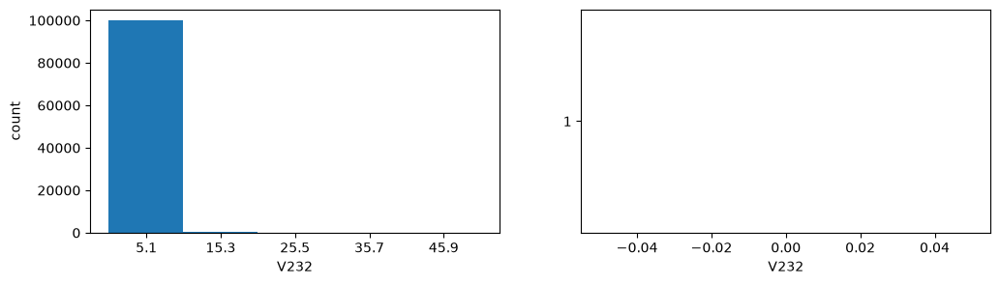

V233


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.051, 10.2]",5.1,100272,99.428843,99.428843
1,"(10.2, 20.4]",15.3,468,0.464065,99.892908
2,"(20.4, 30.6]",25.5,61,0.060487,99.953395
3,"(30.6, 40.8]",35.7,33,0.032723,99.986118
4,"(40.8, 51.0]",45.9,14,0.013882,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


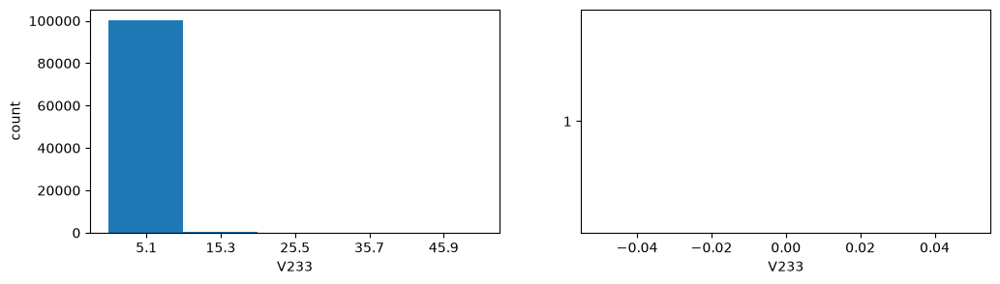

V234


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.121, 24.2]",12.0,105944,97.973829,97.973829
1,"(24.2, 48.4]",36.3,243,0.224719,98.198548
2,"(48.4, 72.6]",60.5,1161,1.073658,99.272206
3,"(72.6, 96.8]",84.7,553,0.511398,99.783604
4,"(96.8, 121.0]",108.9,234,0.216396,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


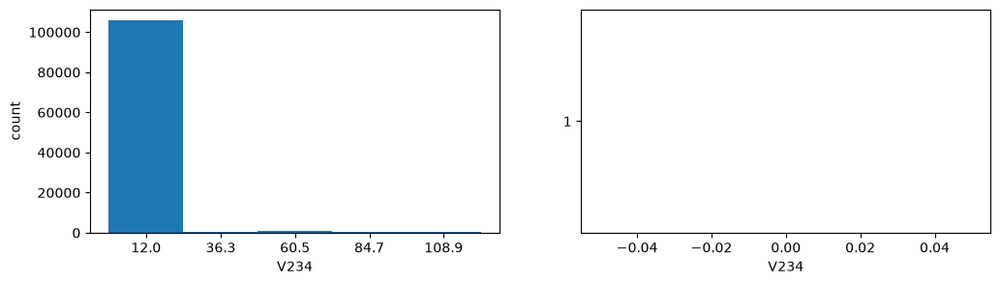

V235


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,100393,99.548826,99.548826
1,"(3.0, 6.0]",4.5,369,0.365897,99.914723
2,"(6.0, 9.0]",7.5,44,0.043630,99.958353
3,"(9.0, 12.0]",10.5,25,0.024790,99.983143
4,"(12.0, 15.0]",13.5,17,0.016857,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


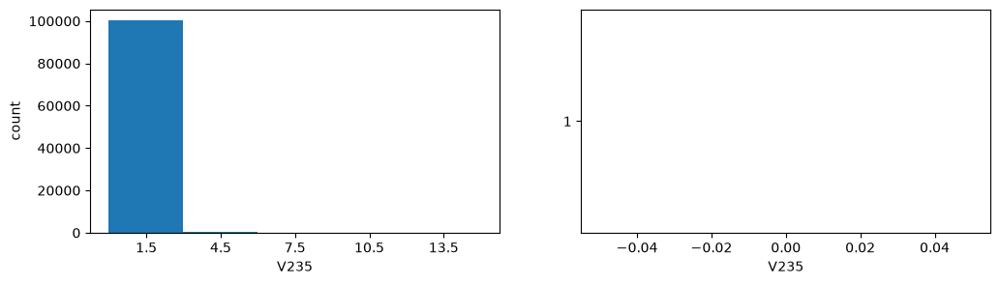

V236


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.034, 6.8]",3.4,100571,99.725329,99.725329
1,"(6.8, 13.6]",10.2,150,0.148739,99.874068
2,"(13.6, 20.4]",17.0,49,0.048588,99.922656
3,"(20.4, 27.2]",23.8,3,0.002975,99.925631
4,"(27.2, 34.0]",30.6,75,0.074369,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


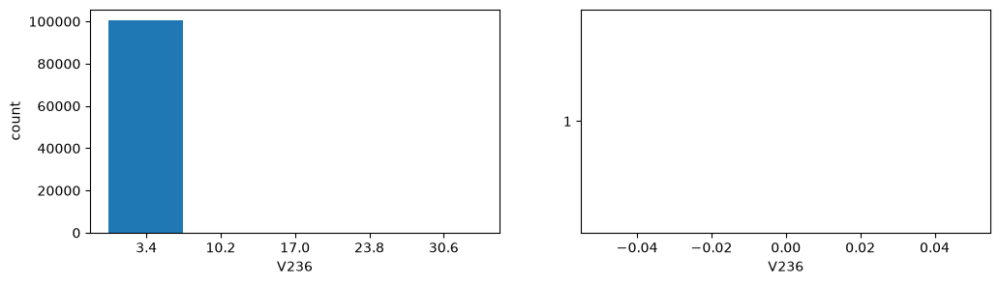

V237


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.016, 3.2]",1.6,100234,99.391163,99.391163
1,"(3.2, 6.4]",4.8,426,0.422418,99.813581
2,"(6.4, 9.6]",8.0,79,0.078336,99.891917
3,"(9.6, 12.8]",11.2,61,0.060487,99.952404
4,"(12.8, 16.0]",14.4,48,0.047596,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


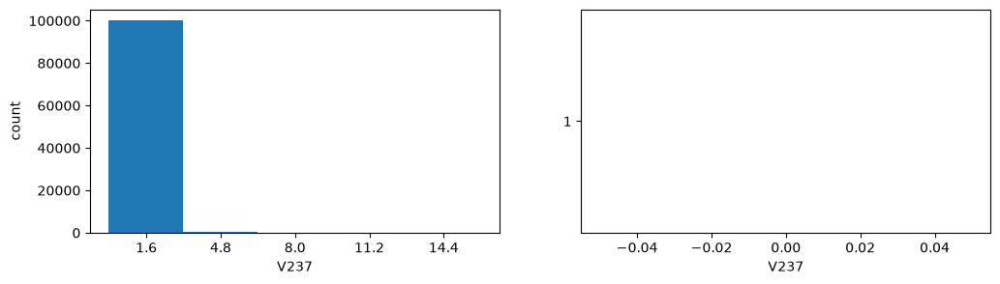

V238


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.023, 4.6]",2.3,107924,99.804874,99.804874
1,"(4.6, 9.2]",6.9,176,0.162760,99.967633
2,"(9.2, 13.8]",11.5,24,0.022194,99.989828
3,"(13.8, 18.4]",16.1,9,0.008323,99.998150
4,"(18.4, 23.0]",20.7,2,0.001850,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


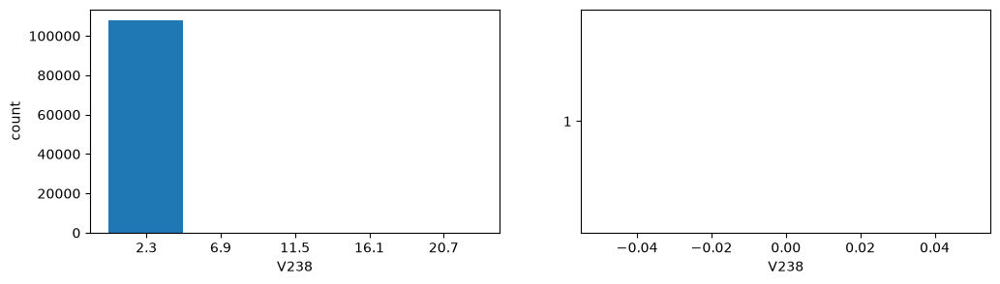

V239


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.023, 4.6]",2.3,107862,99.747538,99.747538
1,"(4.6, 9.2]",6.9,220,0.203449,99.950987
2,"(9.2, 13.8]",11.5,33,0.030517,99.981505
3,"(13.8, 18.4]",16.1,18,0.016646,99.998150
4,"(18.4, 23.0]",20.7,2,0.001850,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


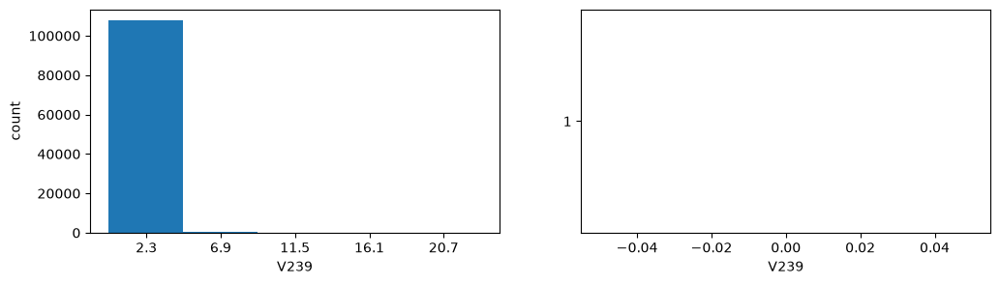

V240


,bins,mid_bin,counts,freq,cum_freq
0,"(0.994, 2.2]",1.6,100839,99.991076,99.991076
1,"(2.2, 3.4]",2.8,0,0.000000,99.991076
2,"(3.4, 4.6]",4.0,0,0.000000,99.991076
3,"(4.6, 5.8]",5.2,2,0.001983,99.993059
4,"(5.8, 7.0]",6.4,7,0.006941,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


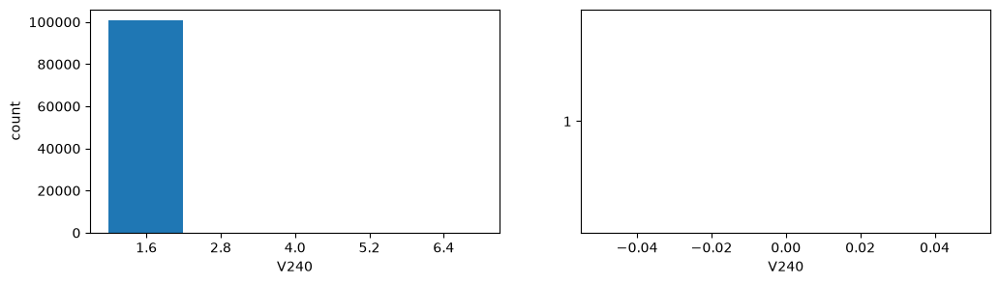

V241


,bins,mid_bin,counts,freq,cum_freq
0,"(0.996, 1.8]",1.4,100824,99.976202,99.976202
1,"(1.8, 2.6]",2.2,21,0.020823,99.997025
2,"(2.6, 3.4]",3.0,0,0.000000,99.997025
3,"(3.4, 4.2]",3.8,2,0.001983,99.999008
4,"(4.2, 5.0]",4.6,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


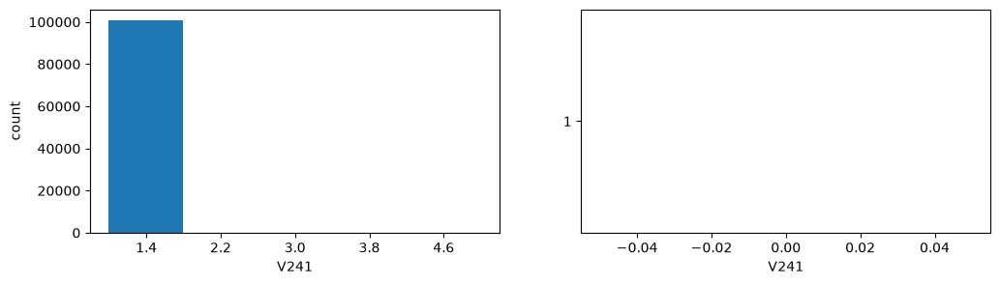

V242


,bins,mid_bin,counts,freq,cum_freq
0,"(0.981, 4.8]",2.9,100221,99.378272,99.378272
1,"(4.8, 8.6]",6.7,499,0.494804,99.873076
2,"(8.6, 12.4]",10.5,87,0.086268,99.959345
3,"(12.4, 16.2]",14.3,31,0.030739,99.990084
4,"(16.2, 20.0]",18.1,10,0.009916,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


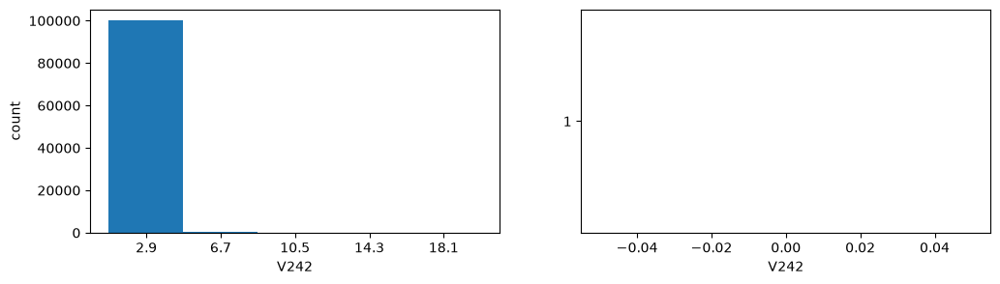

V243


,bins,mid_bin,counts,freq,cum_freq
0,"(0.944, 12.2]",6.6,100728,99.881009,99.881009
1,"(12.2, 23.4]",17.8,40,0.039664,99.920673
2,"(23.4, 34.6]",29.0,2,0.001983,99.922656
3,"(34.6, 45.8]",40.2,23,0.022807,99.945462
4,"(45.8, 57.0]",51.4,55,0.054538,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


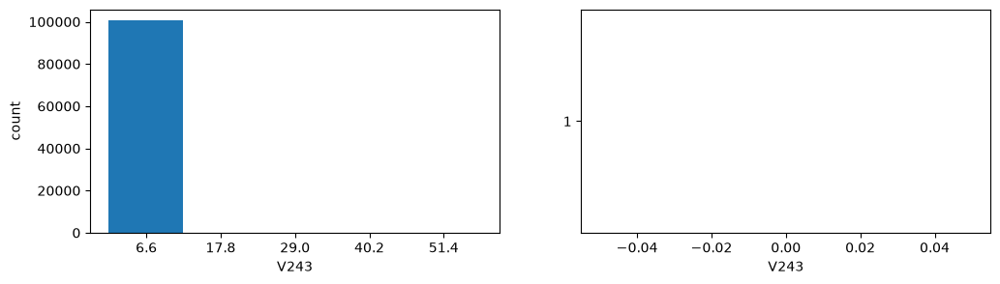

V244


,bins,mid_bin,counts,freq,cum_freq
0,"(0.979, 5.2]",3.1,100380,99.535935,99.535935
1,"(5.2, 9.4]",7.3,354,0.351023,99.886959
2,"(9.4, 13.6]",11.5,78,0.077344,99.964303
3,"(13.6, 17.8]",15.7,27,0.026773,99.991076
4,"(17.8, 22.0]",19.9,9,0.008924,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


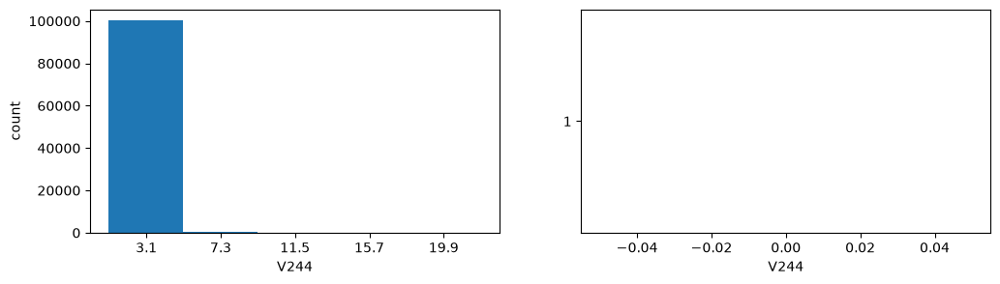

V245


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.262, 52.4]",26.1,108118,99.984279,99.984279
1,"(52.4, 104.8]",78.6,9,0.008323,99.992602
2,"(104.8, 157.2]",131.0,1,0.000925,99.993527
3,"(157.2, 209.6]",183.4,6,0.005549,99.999075
4,"(209.6, 262.0]",235.8,1,0.000925,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


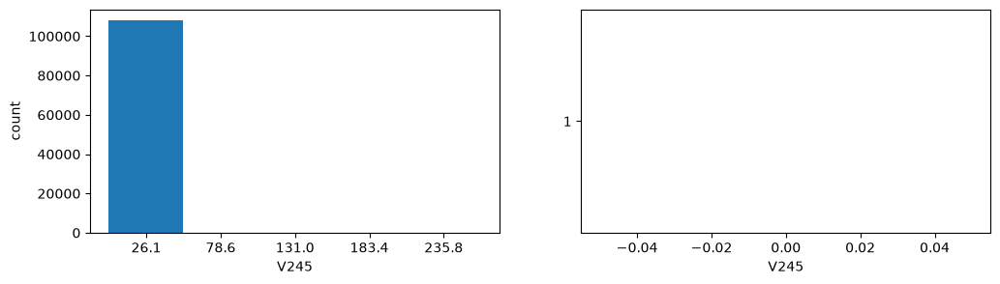

V246


,bins,mid_bin,counts,freq,cum_freq
0,"(0.956, 9.8]",5.4,100624,99.777884,99.777884
1,"(9.8, 18.6]",14.2,182,0.180470,99.958353
2,"(18.6, 27.4]",23.0,20,0.019832,99.978185
3,"(27.4, 36.2]",31.8,11,0.010908,99.989092
4,"(36.2, 45.0]",40.6,11,0.010908,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


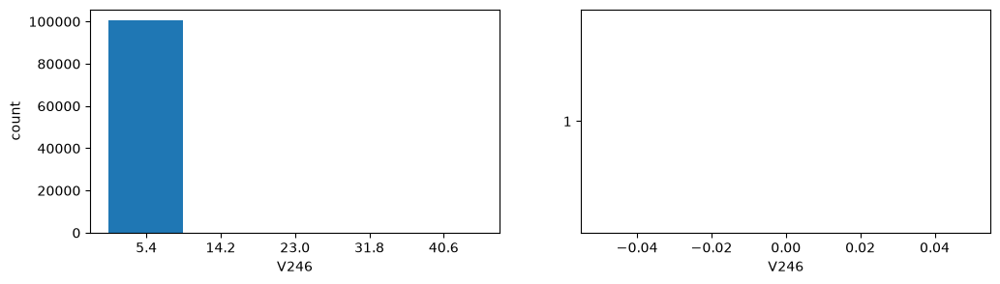

V247


,bins,mid_bin,counts,freq,cum_freq
0,"(0.989, 3.2]",2.1,100710,99.863160,99.863160
1,"(3.2, 5.4]",4.3,68,0.067428,99.930589
2,"(5.4, 7.6]",6.5,33,0.032723,99.963311
3,"(7.6, 9.8]",8.7,22,0.021815,99.985126
4,"(9.8, 12.0]",10.9,15,0.014874,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


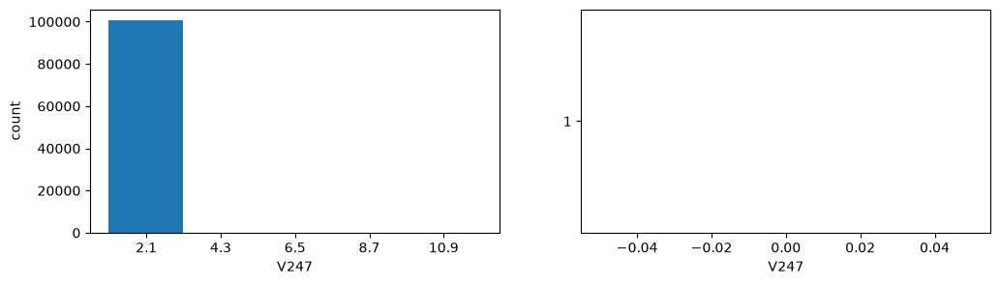

V248


,bins,mid_bin,counts,freq,cum_freq
0,"(0.965, 8.0]",4.5,100761,99.913732,99.913732
1,"(8.0, 15.0]",11.5,9,0.008924,99.922656
2,"(15.0, 22.0]",18.5,0,0.000000,99.922656
3,"(22.0, 29.0]",25.5,0,0.000000,99.922656
4,"(29.0, 36.0]",32.5,78,0.077344,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


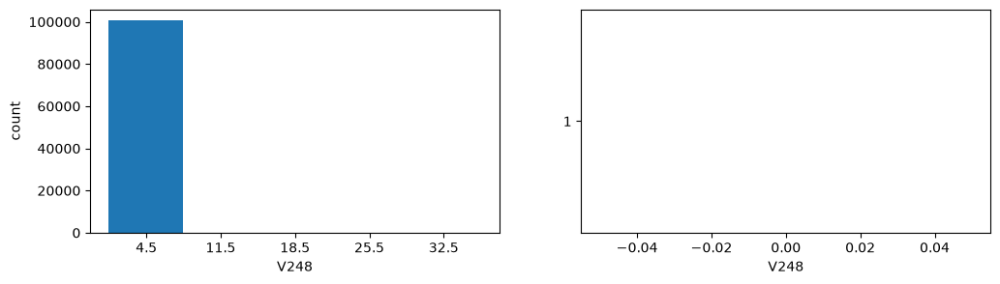

V249


,bins,mid_bin,counts,freq,cum_freq
0,"(0.979, 5.2]",3.1,100753,99.905799,99.905799
1,"(5.2, 9.4]",7.3,17,0.016857,99.922656
2,"(9.4, 13.6]",11.5,0,0.000000,99.922656
3,"(13.6, 17.8]",15.7,5,0.004958,99.927614
4,"(17.8, 22.0]",19.9,73,0.072386,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


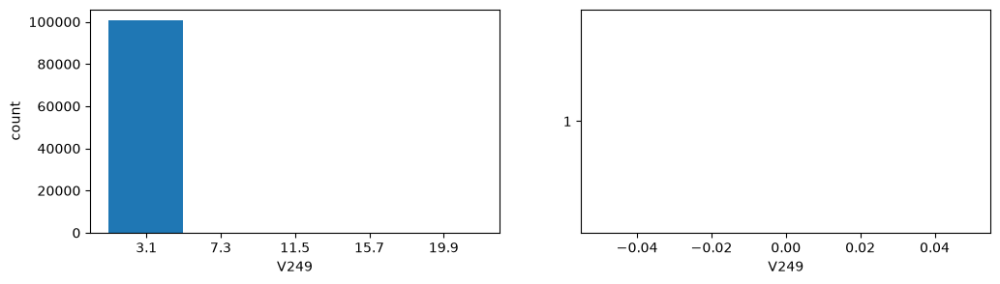

V250


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.017, 3.4]",1.7,108061,99.931567,99.931567
1,"(3.4, 6.8]",5.1,61,0.056411,99.987978
2,"(6.8, 10.2]",8.5,5,0.004624,99.992602
3,"(10.2, 13.6]",11.9,6,0.005549,99.998150
4,"(13.6, 17.0]",15.3,2,0.001850,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


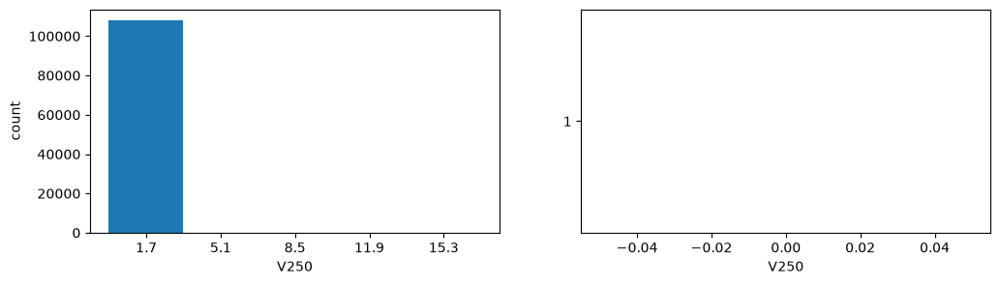

V251


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.017, 3.4]",1.7,108019,99.892727,99.892727
1,"(3.4, 6.8]",5.1,98,0.090627,99.983354
2,"(6.8, 10.2]",8.5,9,0.008323,99.991677
3,"(10.2, 13.6]",11.9,7,0.006473,99.998150
4,"(13.6, 17.0]",15.3,2,0.001850,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


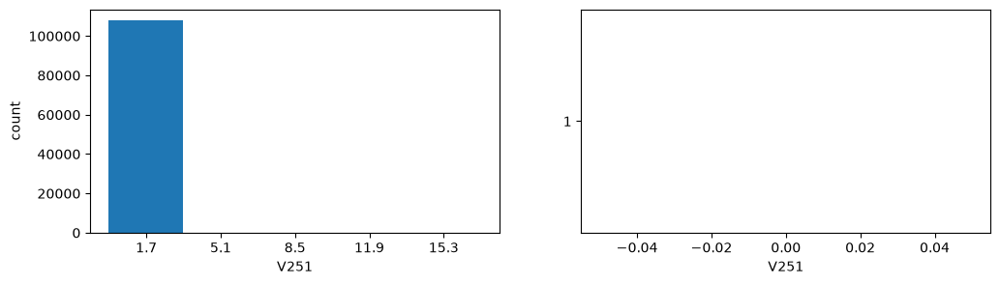

V252


,bins,mid_bin,counts,freq,cum_freq
0,"(0.983, 4.4]",2.7,100682,99.835396,99.835396
1,"(4.4, 7.8]",6.1,87,0.086268,99.921664
2,"(7.8, 11.2]",9.5,49,0.048588,99.970252
3,"(11.2, 14.6]",12.9,14,0.013882,99.984135
4,"(14.6, 18.0]",16.3,16,0.015865,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


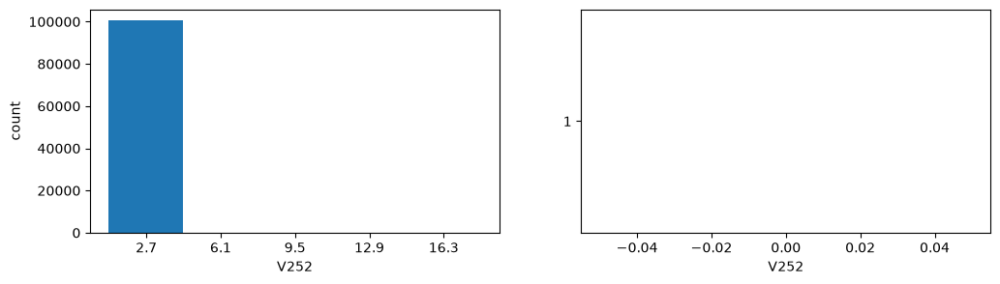

V253


,bins,mid_bin,counts,freq,cum_freq
0,"(0.838, 33.4]",17.1,100764,99.916706,99.916706
1,"(33.4, 65.8]",49.6,6,0.005950,99.922656
2,"(65.8, 98.2]",82.0,0,0.000000,99.922656
3,"(98.2, 130.6]",114.4,0,0.000000,99.922656
4,"(130.6, 163.0]",146.8,78,0.077344,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


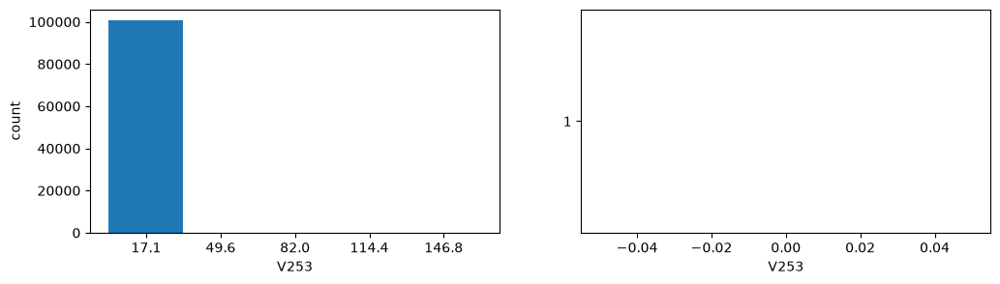

V254


,bins,mid_bin,counts,freq,cum_freq
0,"(0.941, 12.8]",6.9,100757,99.909765,99.909765
1,"(12.8, 24.6]",18.7,11,0.010908,99.920673
2,"(24.6, 36.4]",30.5,2,0.001983,99.922656
3,"(36.4, 48.2]",42.3,20,0.019832,99.942488
4,"(48.2, 60.0]",54.1,58,0.057512,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


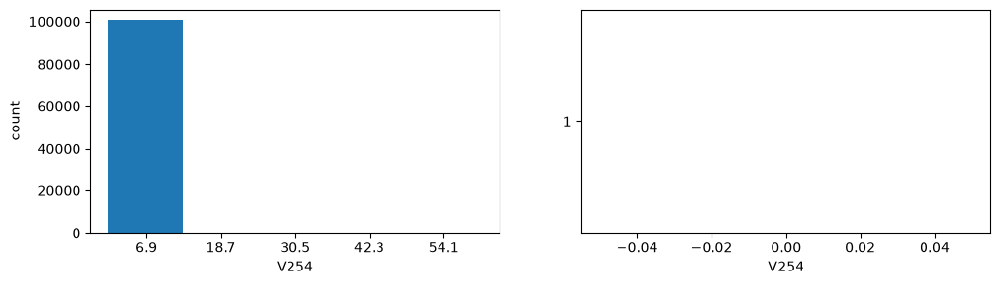

V255


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.087, 17.4]",8.7,108103,99.970407,99.970407
1,"(17.4, 34.8]",26.1,16,0.014796,99.985204
2,"(34.8, 52.2]",43.5,7,0.006473,99.991677
3,"(52.2, 69.6]",60.9,1,0.000925,99.992602
4,"(69.6, 87.0]",78.3,8,0.007398,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


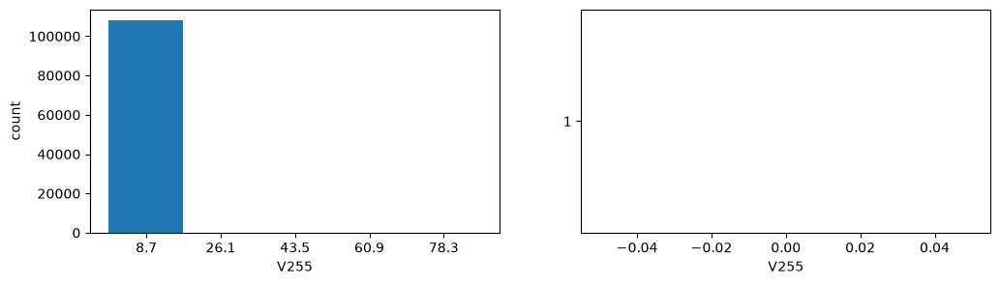

V256


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.087, 17.4]",8.7,108100,99.967633,99.967633
1,"(17.4, 34.8]",26.1,18,0.016646,99.984279
2,"(34.8, 52.2]",43.5,7,0.006473,99.990752
3,"(52.2, 69.6]",60.9,2,0.001850,99.992602
4,"(69.6, 87.0]",78.3,8,0.007398,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


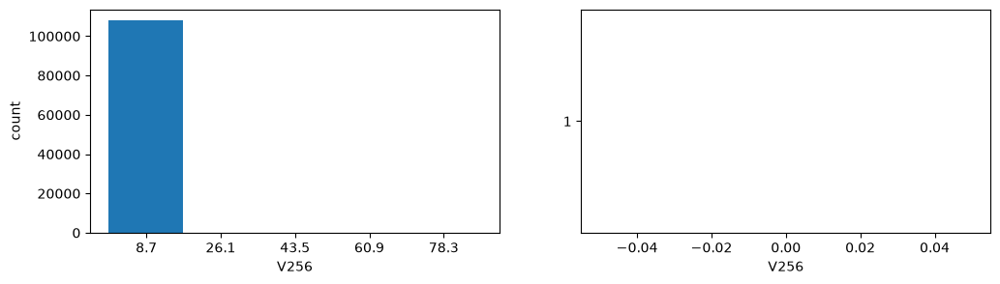

V257


,bins,mid_bin,counts,freq,cum_freq
0,"(0.953, 10.4]",5.7,100523,99.677733,99.677733
1,"(10.4, 19.8]",15.1,258,0.255831,99.933563
2,"(19.8, 29.2]",24.5,33,0.032723,99.966286
3,"(29.2, 38.6]",33.9,21,0.020823,99.987109
4,"(38.6, 48.0]",43.3,13,0.012891,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


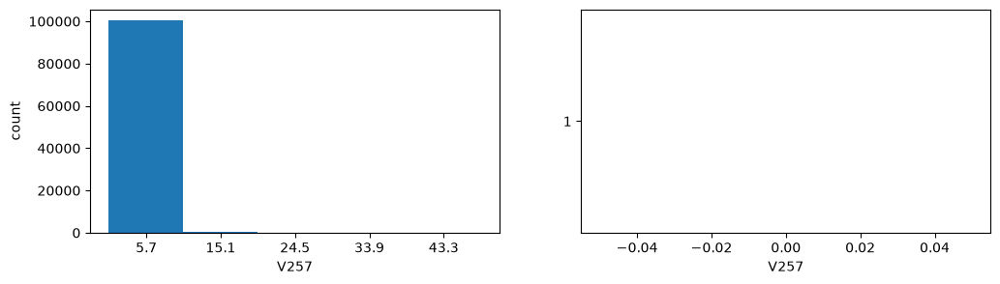

V258


,bins,mid_bin,counts,freq,cum_freq
0,"(0.935, 14.0]",7.5,100572,99.726321,99.726321
1,"(14.0, 27.0]",20.5,152,0.150722,99.877043
2,"(27.0, 40.0]",33.5,37,0.036689,99.913732
3,"(40.0, 53.0]",46.5,33,0.032723,99.946454
4,"(53.0, 66.0]",59.5,54,0.053546,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


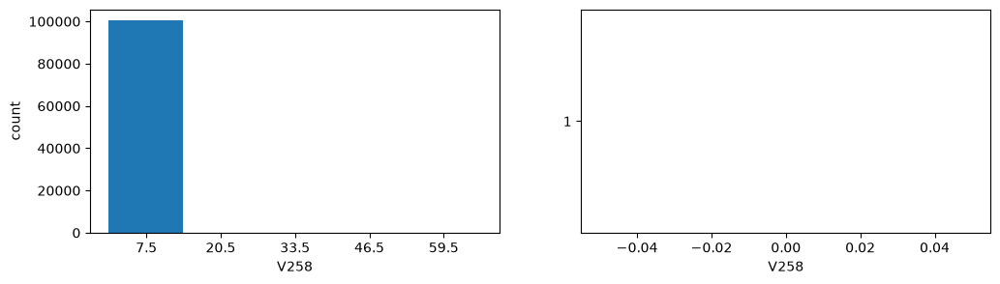

V259


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.285, 57.0]",28.4,108118,99.984279,99.984279
1,"(57.0, 114.0]",85.5,9,0.008323,99.992602
2,"(114.0, 171.0]",142.5,1,0.000925,99.993527
3,"(171.0, 228.0]",199.5,6,0.005549,99.999075
4,"(228.0, 285.0]",256.5,1,0.000925,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


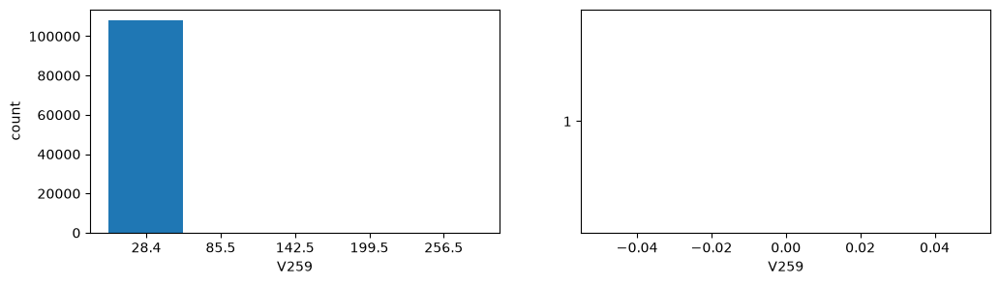

V260


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.008, 1.6]",0.8,97883,97.059932,97.059932
1,"(1.6, 3.2]",2.4,2762,2.738775,99.798707
2,"(3.2, 4.8]",4.0,145,0.143781,99.942488
3,"(4.8, 6.4]",5.6,54,0.053546,99.996034
4,"(6.4, 8.0]",7.2,4,0.003966,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


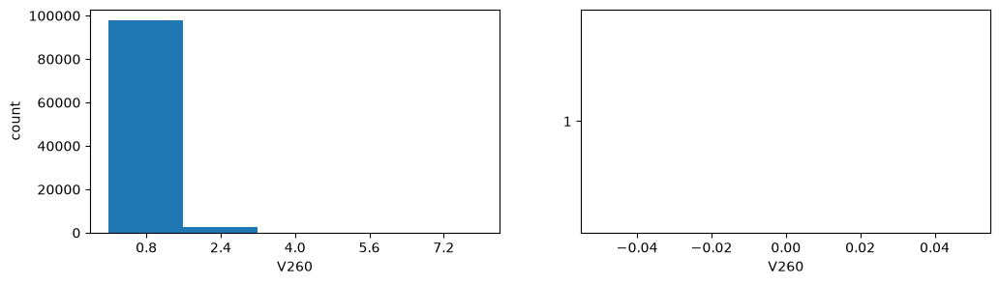

V261


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.049, 9.8]",4.9,100667,99.820522,99.820522
1,"(9.8, 19.6]",14.7,93,0.092218,99.912740
2,"(19.6, 29.4]",24.5,9,0.008924,99.921664
3,"(29.4, 39.2]",34.3,24,0.023798,99.945462
4,"(39.2, 49.0]",44.1,55,0.054538,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


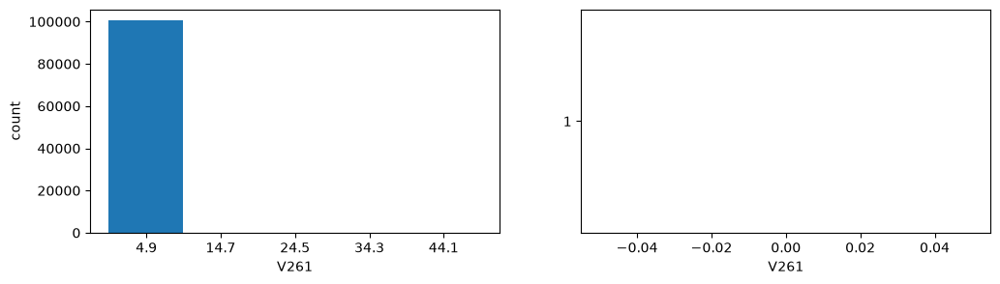

V262


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.02, 4.0]",2.0,100517,99.671783,99.671783
1,"(4.0, 8.0]",6.0,213,0.211209,99.882992
2,"(8.0, 12.0]",10.0,40,0.039664,99.922656
3,"(12.0, 16.0]",14.0,61,0.060487,99.983143
4,"(16.0, 20.0]",18.0,17,0.016857,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


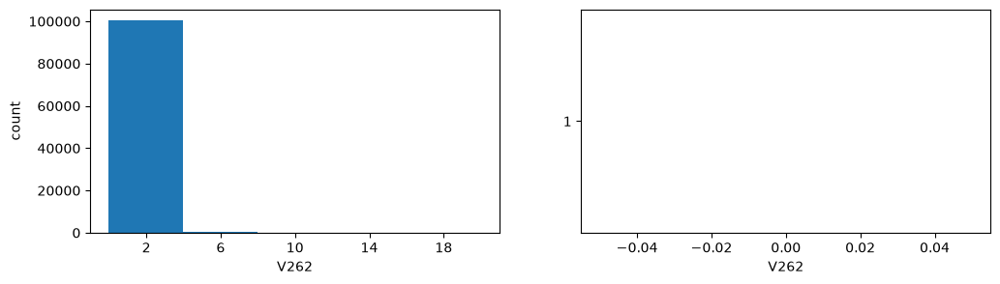

V263


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,100837,99.989092,99.989092
1,"(20328.0, 40656.0]",30492.0,8,0.007933,99.997025
2,"(40656.0, 60984.0]",50820.0,2,0.001983,99.999008
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999008
4,"(81312.0, 101640.0]",91476.0,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


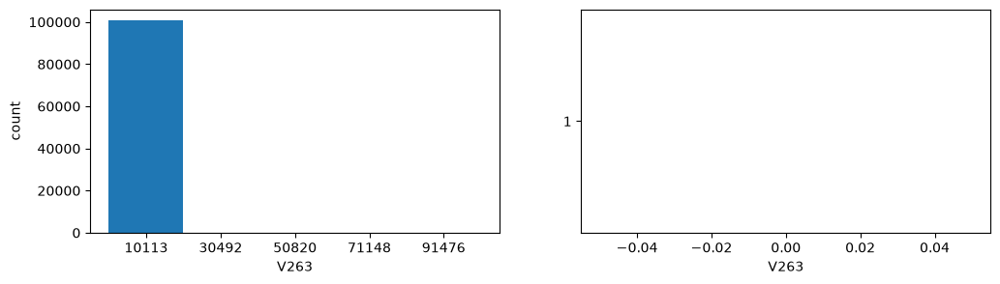

V264


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,100757,99.909765,99.909765
1,"(20328.0, 40656.0]",30492.0,9,0.008924,99.918690
2,"(40656.0, 60984.0]",50820.0,3,0.002975,99.921664
3,"(60984.0, 81312.0]",71148.0,78,0.077344,99.999008
4,"(81312.0, 101640.0]",91476.0,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


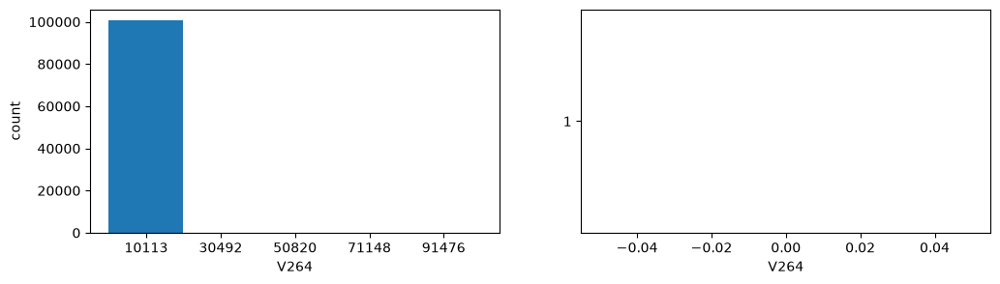

V265


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,100813,99.965294,99.965294
1,"(20328.0, 40656.0]",30492.0,32,0.031731,99.997025
2,"(40656.0, 60984.0]",50820.0,2,0.001983,99.999008
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999008
4,"(81312.0, 101640.0]",91476.0,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


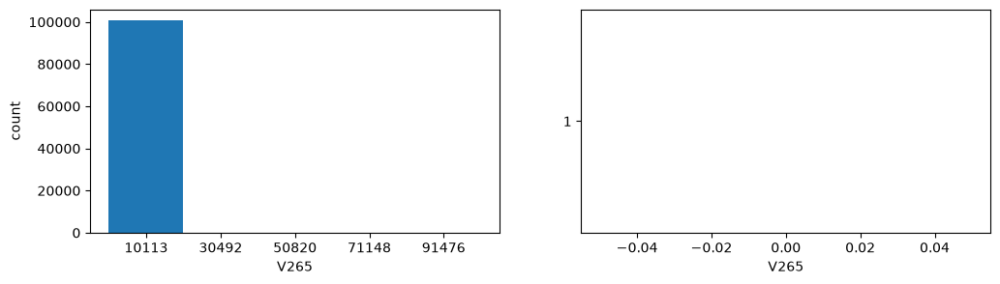

V266


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,100844,99.996034,99.996034
1,"(11025.0, 22050.0]",16537.5,2,0.001983,99.998017
2,"(22050.0, 33075.0]",27562.5,1,0.000992,99.999008
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999008
4,"(44100.0, 55125.0]",49612.5,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


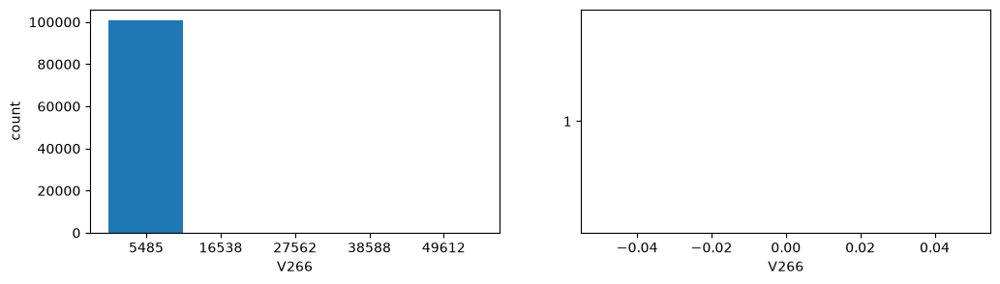

V267


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,100765,99.917698,99.917698
1,"(11025.0, 22050.0]",16537.5,25,0.024790,99.942488
2,"(22050.0, 33075.0]",27562.5,57,0.056521,99.999008
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999008
4,"(44100.0, 55125.0]",49612.5,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


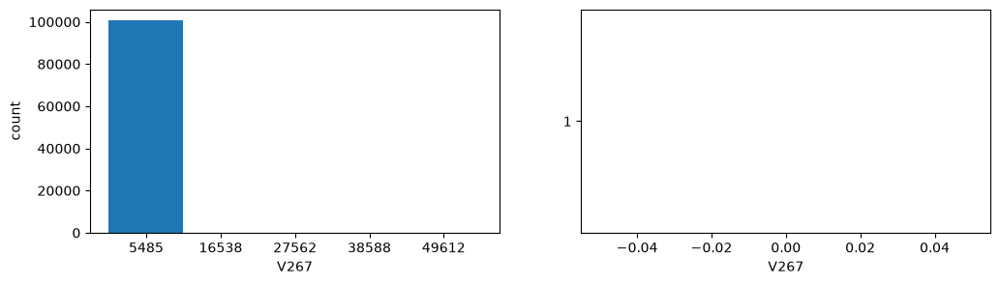

V268


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,100824,99.976202,99.976202
1,"(11025.0, 22050.0]",16537.5,22,0.021815,99.998017
2,"(22050.0, 33075.0]",27562.5,1,0.000992,99.999008
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999008
4,"(44100.0, 55125.0]",49612.5,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


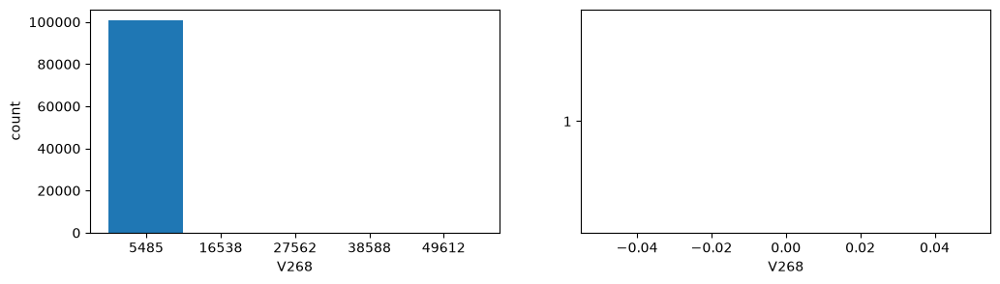

V269


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,100844,99.996034,99.996034
1,"(11025.0, 22050.0]",16537.5,2,0.001983,99.998017
2,"(22050.0, 33075.0]",27562.5,1,0.000992,99.999008
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999008
4,"(44100.0, 55125.0]",49612.5,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


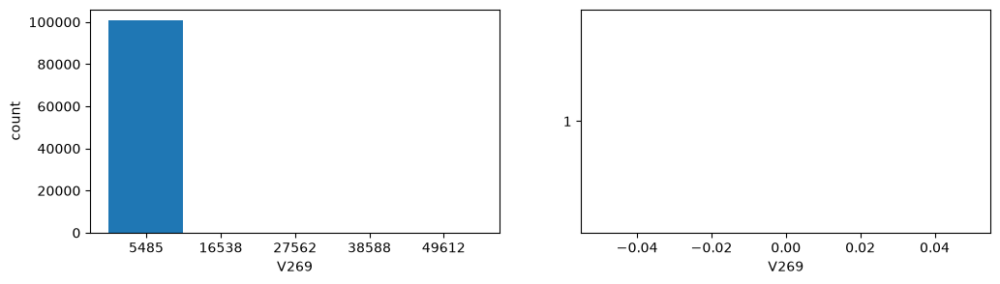

V270


,bins,mid_bin,counts,freq,cum_freq
0,"(-4.0, 800.0]",398.0,108001,99.876081,99.876081
1,"(800.0, 1600.0]",1200.0,91,0.084154,99.960235
2,"(1600.0, 2400.0]",2000.0,20,0.018495,99.978730
3,"(2400.0, 3200.0]",2800.0,12,0.011097,99.989828
4,"(3200.0, 4000.0]",3600.0,11,0.010172,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


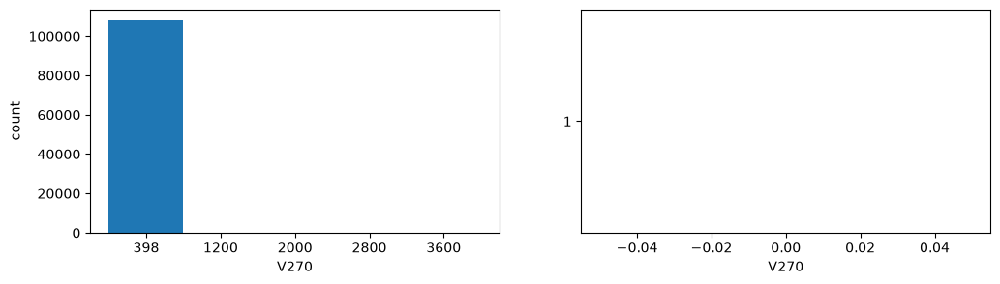

V271


,bins,mid_bin,counts,freq,cum_freq
0,"(-4.0, 800.0]",398.0,107954,99.832617,99.832617
1,"(800.0, 1600.0]",1200.0,131,0.121145,99.953762
2,"(1600.0, 2400.0]",2000.0,24,0.022194,99.975956
3,"(2400.0, 3200.0]",2800.0,15,0.013872,99.989828
4,"(3200.0, 4000.0]",3600.0,11,0.010172,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


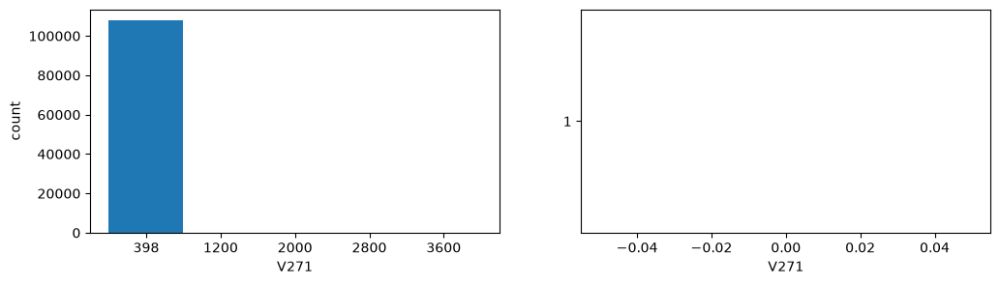

V272


,bins,mid_bin,counts,freq,cum_freq
0,"(-4.0, 800.0]",398.0,107976,99.852962,99.852962
1,"(800.0, 1600.0]",1200.0,112,0.103574,99.956536
2,"(1600.0, 2400.0]",2000.0,22,0.020345,99.976881
3,"(2400.0, 3200.0]",2800.0,14,0.012947,99.989828
4,"(3200.0, 4000.0]",3600.0,11,0.010172,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


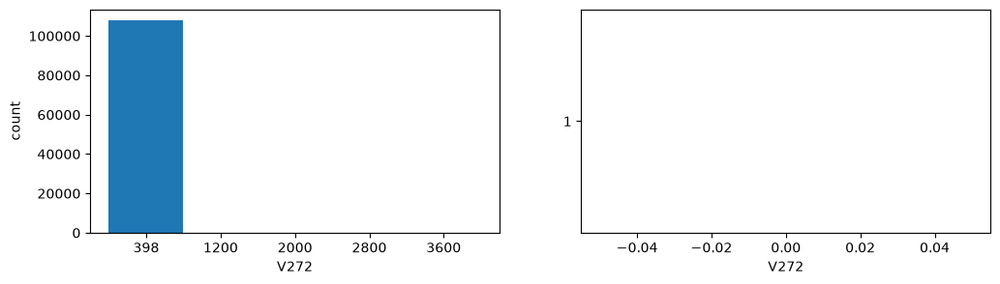

V273


,bins,mid_bin,counts,freq,cum_freq
0,"(-15.0, 3000.0]",1492.5,100711,99.864152,99.864152
1,"(3000.0, 6000.0]",4500.0,97,0.096184,99.960336
2,"(6000.0, 9000.0]",7500.0,24,0.023798,99.984135
3,"(9000.0, 12000.0]",10500.0,13,0.012891,99.997025
4,"(12000.0, 15000.0]",13500.0,3,0.002975,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


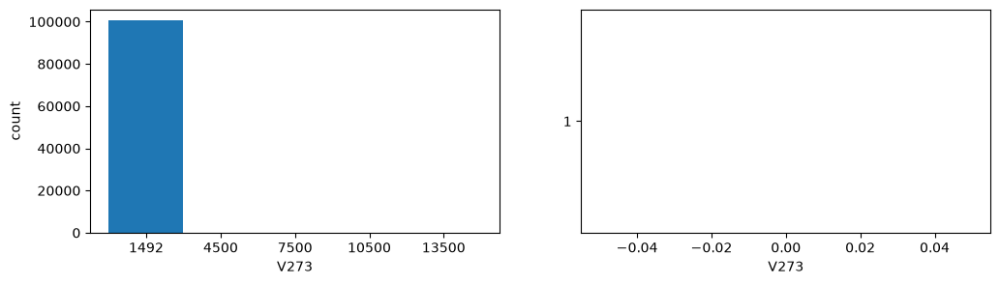

V274


,bins,mid_bin,counts,freq,cum_freq
0,"(-66.0, 13200.0]",6567.0,100766,99.918690,99.918690
1,"(13200.0, 26400.0]",19800.0,30,0.029748,99.948437
2,"(26400.0, 39600.0]",33000.0,51,0.050571,99.999008
3,"(39600.0, 52800.0]",46200.0,0,0.000000,99.999008
4,"(52800.0, 66000.0]",59400.0,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


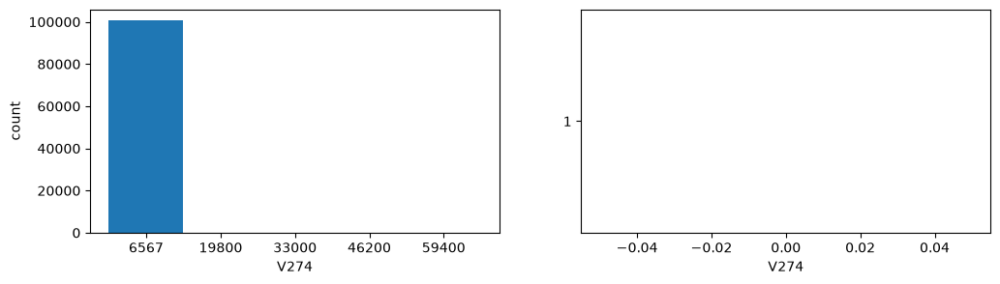

V275


,bins,mid_bin,counts,freq,cum_freq
0,"(-20.85, 4170.0]",2074.6,100723,99.876051,99.876051
1,"(4170.0, 8340.0]",6255.0,68,0.067428,99.943479
2,"(8340.0, 12510.0]",10425.0,32,0.031731,99.975210
3,"(12510.0, 16680.0]",14595.0,4,0.003966,99.979177
4,"(16680.0, 20850.0]",18765.0,21,0.020823,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


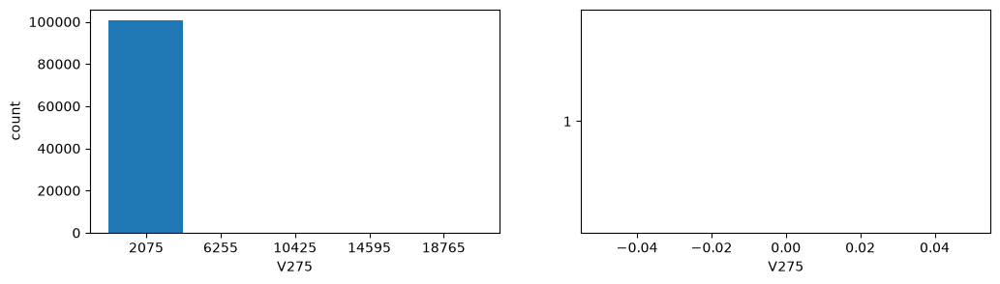

V276


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,100844,99.996034,99.996034
1,"(20328.0, 40656.0]",30492.0,2,0.001983,99.998017
2,"(40656.0, 60984.0]",50820.0,1,0.000992,99.999008
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999008
4,"(81312.0, 101640.0]",91476.0,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


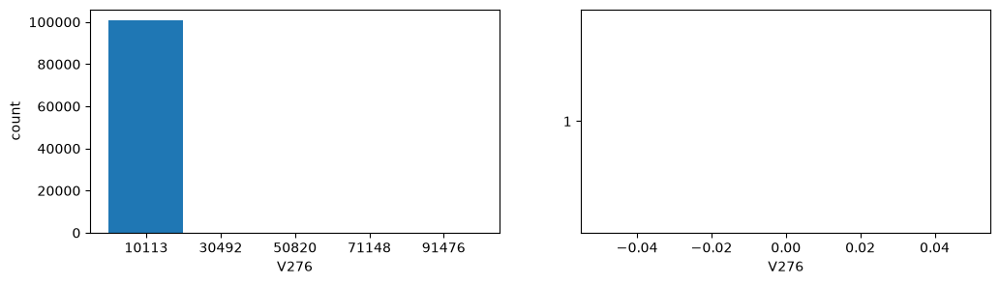

V277


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,100844,99.996034,99.996034
1,"(20328.0, 40656.0]",30492.0,2,0.001983,99.998017
2,"(40656.0, 60984.0]",50820.0,1,0.000992,99.999008
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999008
4,"(81312.0, 101640.0]",91476.0,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


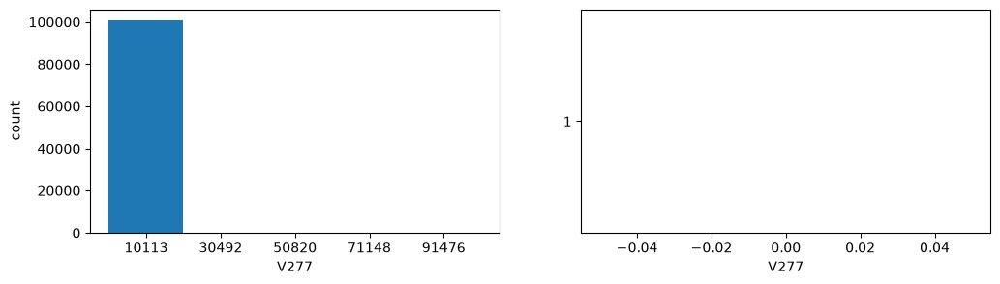

V278


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,100844,99.996034,99.996034
1,"(20328.0, 40656.0]",30492.0,2,0.001983,99.998017
2,"(40656.0, 60984.0]",50820.0,1,0.000992,99.999008
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999008
4,"(81312.0, 101640.0]",91476.0,1,0.000992,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


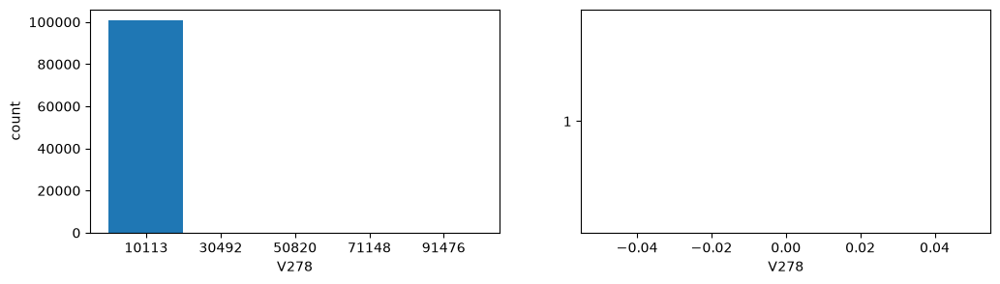

V279


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.066, 13.2]",6.6,413059,99.925732,99.925732
1,"(13.2, 26.4]",19.8,199,0.048141,99.973873
2,"(26.4, 39.6]",33.0,79,0.019111,99.992984
3,"(39.6, 52.8]",46.2,17,0.004113,99.997097
4,"(52.8, 66.0]",59.4,12,0.002903,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


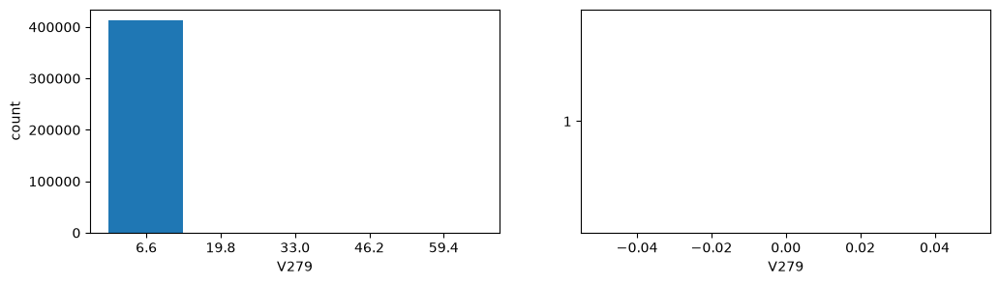

V280


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.323, 64.6]",32.1,413169,99.952342,99.952342
1,"(64.6, 129.2]",96.9,5,0.001210,99.953552
2,"(129.2, 193.8]",161.5,108,0.026127,99.979679
3,"(193.8, 258.4]",226.1,69,0.016692,99.996371
4,"(258.4, 323.0]",290.7,15,0.003629,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


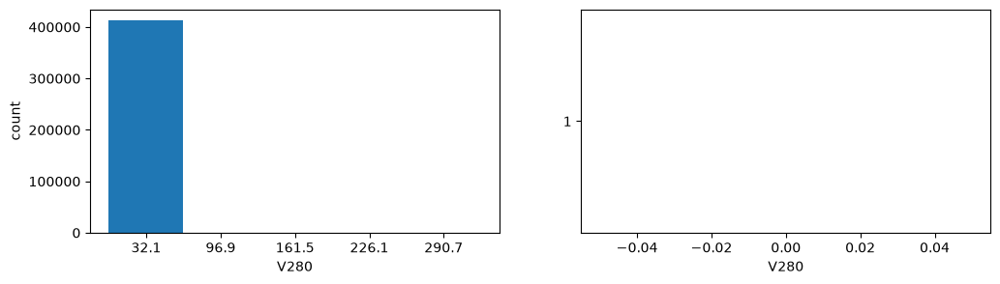

V281


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.022, 4.4]",2.2,412033,99.740502,99.740502
1,"(4.4, 8.8]",6.6,919,0.222462,99.962963
2,"(8.8, 13.2]",11.0,139,0.033648,99.996611
3,"(13.2, 17.6]",15.4,9,0.002179,99.998790
4,"(17.6, 22.0]",19.8,5,0.001210,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


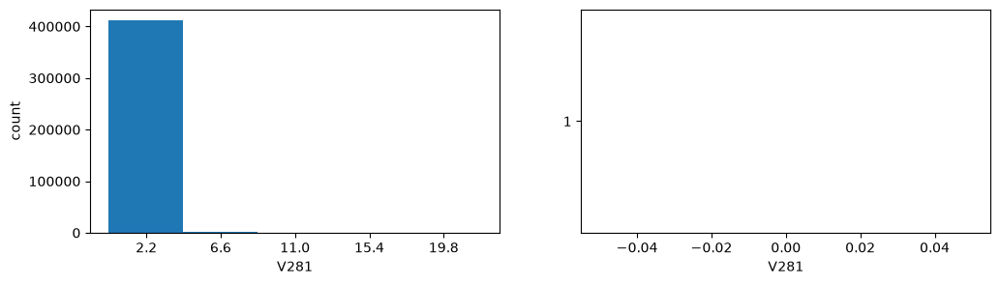

V282


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.032, 6.4]",3.2,412007,99.734208,99.734208
1,"(6.4, 12.8]",9.6,1028,0.248847,99.983055
2,"(12.8, 19.2]",16.0,50,0.012103,99.995159
3,"(19.2, 25.6]",22.4,12,0.002905,99.998063
4,"(25.6, 32.0]",28.8,8,0.001937,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


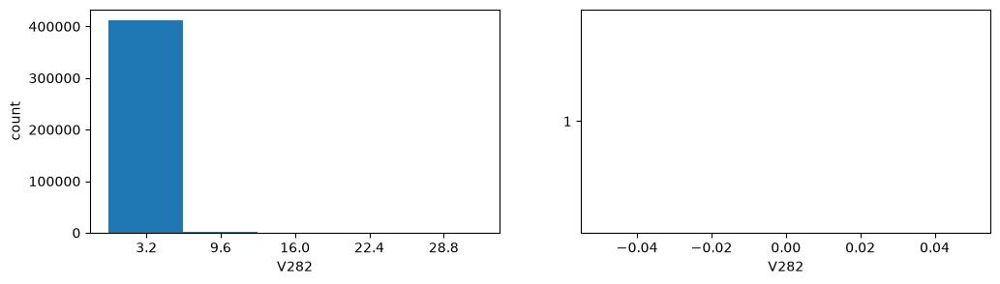

V283


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.068, 13.6]",6.8,412471,99.846528,99.846528
1,"(13.6, 27.2]",20.4,521,0.126118,99.972646
2,"(27.2, 40.8]",34.0,49,0.011861,99.984508
3,"(40.8, 54.4]",47.6,6,0.001452,99.985960
4,"(54.4, 68.0]",61.2,58,0.014040,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


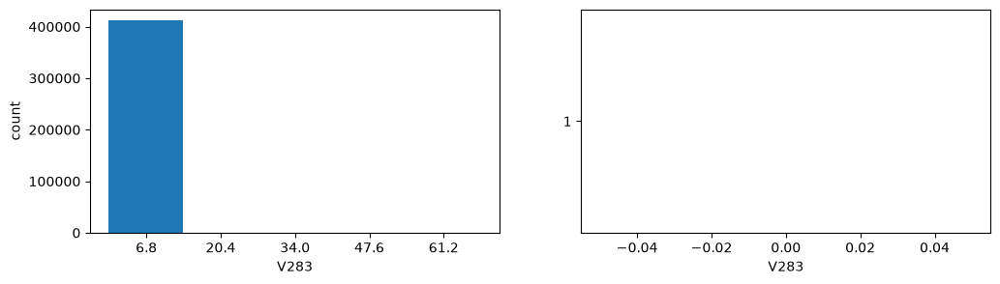

V284


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.012, 2.4]",1.2,412498,99.790017,99.790017
1,"(2.4, 4.8]",3.6,763,0.184582,99.974599
2,"(4.8, 7.2]",6.0,91,0.022014,99.996613
3,"(7.2, 9.6]",8.4,11,0.002661,99.999274
4,"(9.6, 12.0]",10.8,3,0.000726,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


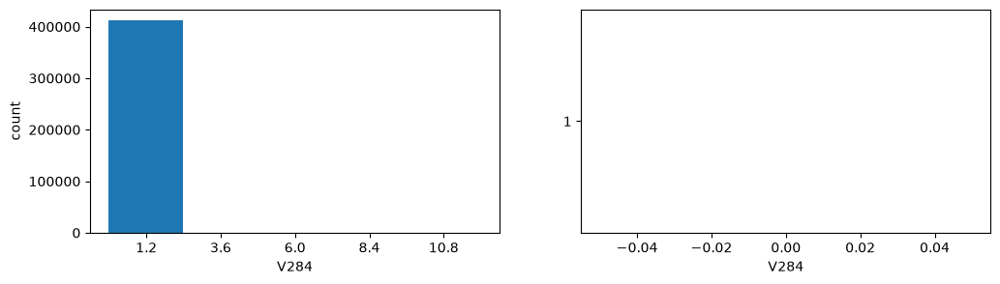

V285


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.095, 19.0]",9.5,412256,99.731473,99.731473
1,"(19.0, 38.0]",28.5,700,0.169341,99.900814
2,"(38.0, 57.0]",47.5,93,0.022498,99.923313
3,"(57.0, 76.0]",66.5,101,0.024434,99.947746
4,"(76.0, 95.0]",85.5,216,0.052254,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


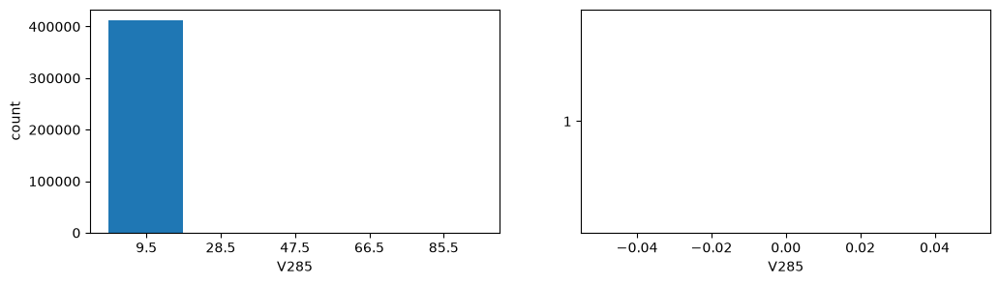

V286


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.008, 1.6]",0.8,412548,99.802112,99.802112
1,"(1.6, 3.2]",2.4,787,0.190388,99.992501
2,"(3.2, 4.8]",4.0,11,0.002661,99.995162
3,"(4.8, 6.4]",5.6,11,0.002661,99.997823
4,"(6.4, 8.0]",7.2,9,0.002177,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


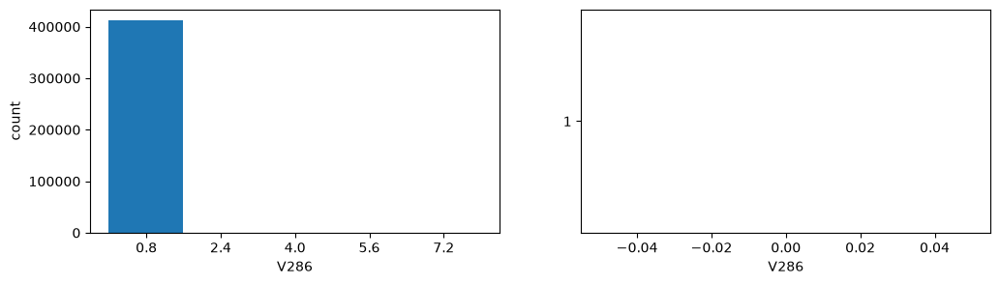

V287


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.031, 6.2]",3.1,412301,99.742359,99.742359
1,"(6.2, 12.4]",9.3,574,0.138860,99.881219
2,"(12.4, 18.6]",15.5,204,0.049351,99.930570
3,"(18.6, 24.8]",21.7,218,0.052738,99.983308
4,"(24.8, 31.0]",27.9,69,0.016692,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


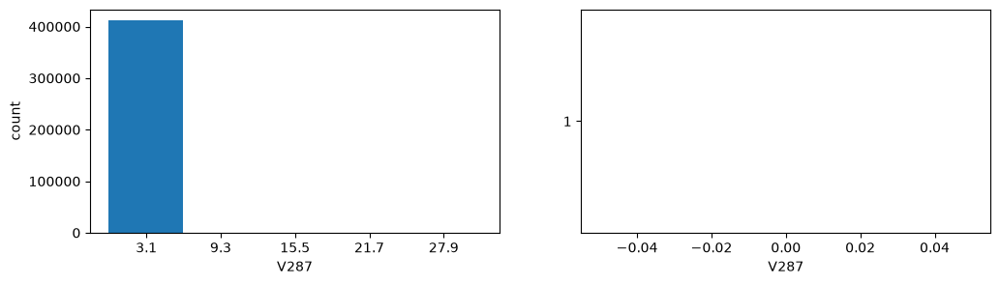

V288


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.01, 2.0]",1.0,412539,99.862989,99.862989
1,"(2.0, 4.0]",3.0,523,0.126602,99.989591
2,"(4.0, 6.0]",5.0,29,0.007020,99.996611
3,"(6.0, 8.0]",7.0,9,0.002179,99.998790
4,"(8.0, 10.0]",9.0,5,0.001210,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


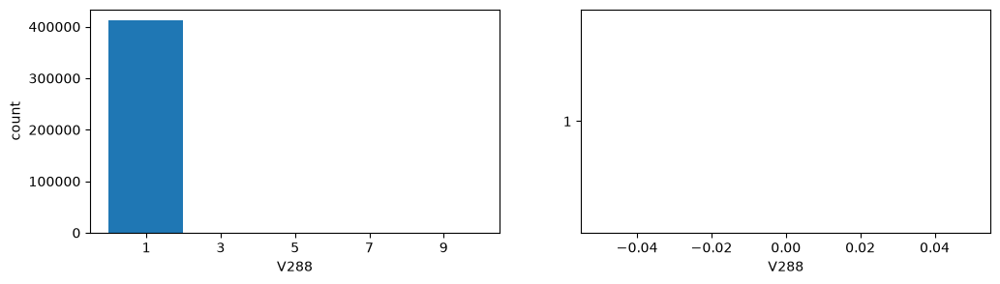

V289


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.012, 2.4]",1.2,408035,98.772709,98.772709
1,"(2.4, 4.8]",3.6,4695,1.136515,99.909224
2,"(4.8, 7.2]",6.0,314,0.076010,99.985234
3,"(7.2, 9.6]",8.4,57,0.013798,99.999032
4,"(9.6, 12.0]",10.8,4,0.000968,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


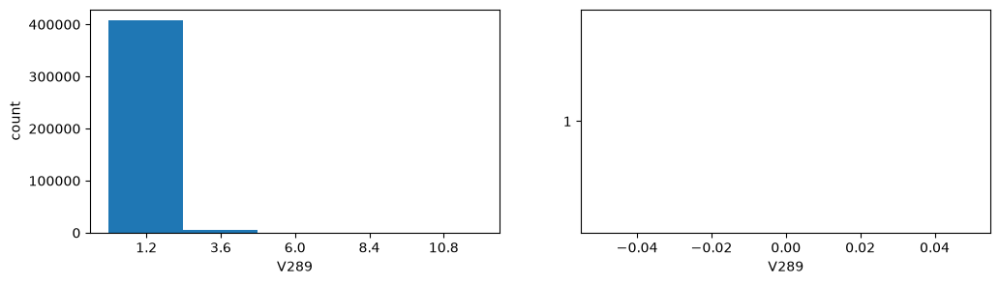

V290


,bins,mid_bin,counts,freq,cum_freq
0,"(0.934, 14.2]",7.6,413168,99.952101,99.952101
1,"(14.2, 27.4]",20.8,99,0.023950,99.976050
2,"(27.4, 40.6]",34.0,71,0.017176,99.993226
3,"(40.6, 53.8]",47.2,17,0.004113,99.997339
4,"(53.8, 67.0]",60.4,11,0.002661,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


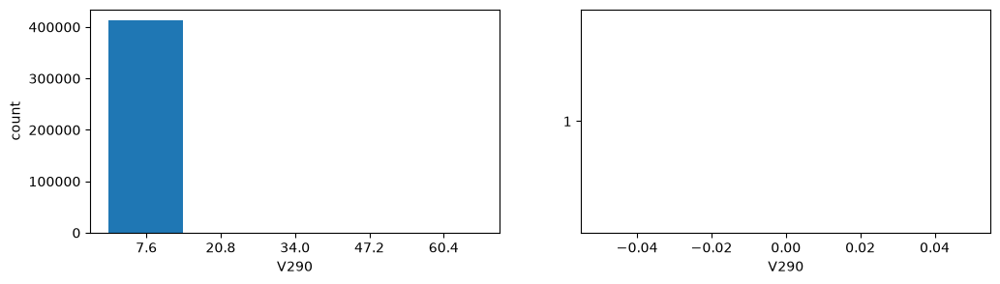

V291


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.054, 211.8]",105.9,413169,99.952342,99.952342
1,"(211.8, 422.6]",317.2,0,0.000000,99.952342
2,"(422.6, 633.4]",528.0,0,0.000000,99.952342
3,"(633.4, 844.2]",738.8,148,0.035804,99.988146
4,"(844.2, 1055.0]",949.6,49,0.011854,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


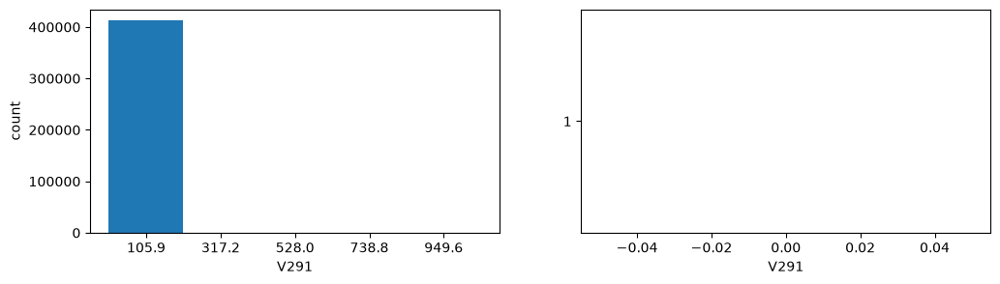

V292


,bins,mid_bin,counts,freq,cum_freq
0,"(0.678, 65.4]",33.0,413169,99.952342,99.952342
1,"(65.4, 129.8]",97.6,5,0.001210,99.953552
2,"(129.8, 194.2]",162.0,117,0.028304,99.981856
3,"(194.2, 258.6]",226.4,62,0.014999,99.996855
4,"(258.6, 323.0]",290.8,13,0.003145,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


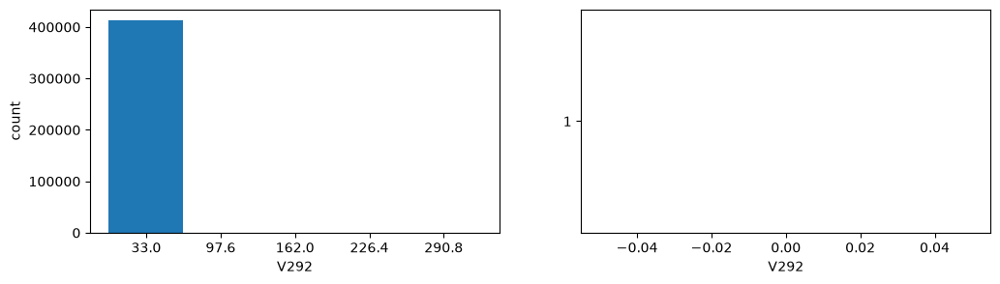

V293


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.066, 13.2]",6.6,413109,99.937827,99.937827
1,"(13.2, 26.4]",19.8,154,0.037255,99.975083
2,"(26.4, 39.6]",33.0,75,0.018144,99.993226
3,"(39.6, 52.8]",46.2,16,0.003871,99.997097
4,"(52.8, 66.0]",59.4,12,0.002903,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


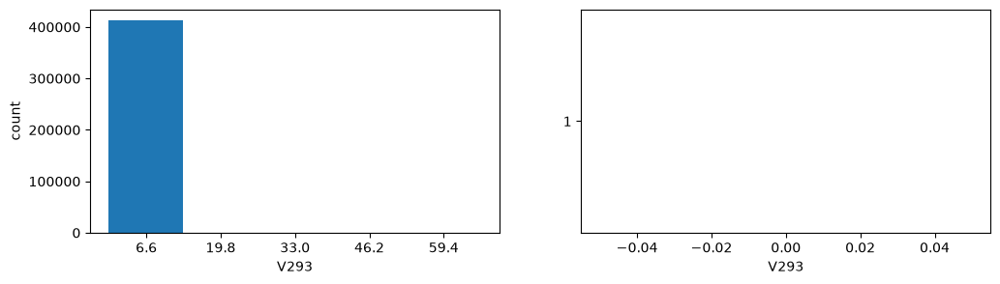

V294


,bins,mid_bin,counts,freq,cum_freq
0,"(-1.093, 218.6]",108.8,413169,99.952342,99.952342
1,"(218.6, 437.2]",327.9,0,0.000000,99.952342
2,"(437.2, 655.8]",546.5,6,0.001451,99.953794
3,"(655.8, 874.4]",765.1,155,0.037497,99.991291
4,"(874.4, 1093.0]",983.7,36,0.008709,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


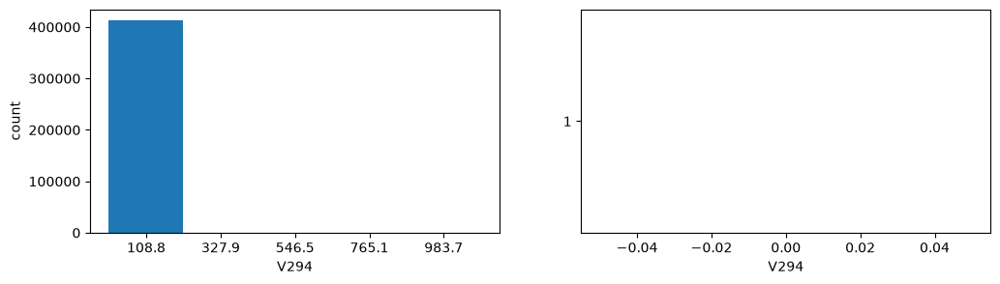

V295


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.322, 64.4]",32.0,413169,99.952342,99.952342
1,"(64.4, 128.8]",96.6,5,0.001210,99.953552
2,"(128.8, 193.2]",161.0,108,0.026127,99.979679
3,"(193.2, 257.6]",225.4,69,0.016692,99.996371
4,"(257.6, 322.0]",289.8,15,0.003629,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


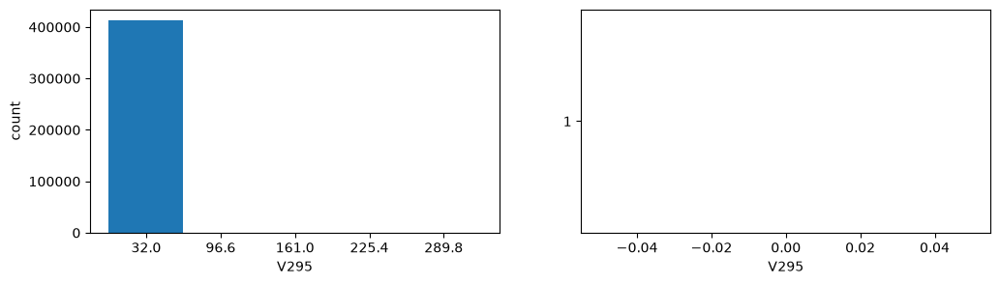

V296


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.061, 12.2]",6.1,412396,99.828373,99.828373
1,"(12.2, 24.4]",18.3,366,0.088597,99.916970
2,"(24.4, 36.6]",30.5,263,0.063664,99.980634
3,"(36.6, 48.8]",42.7,39,0.009441,99.990075
4,"(48.8, 61.0]",54.9,41,0.009925,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


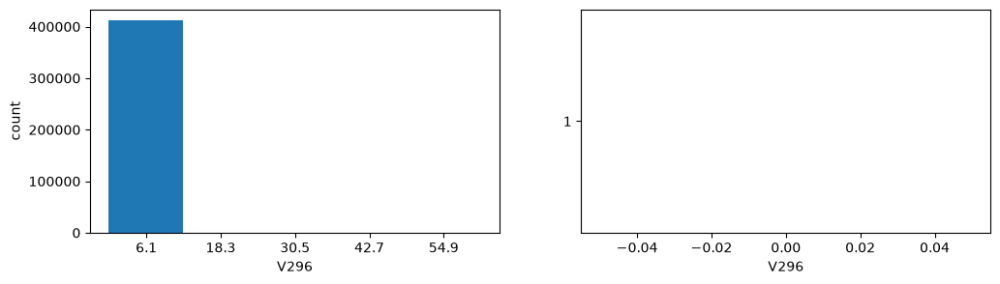

V297


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.012, 2.4]",1.2,411679,99.591887,99.591887
1,"(2.4, 4.8]",3.6,1307,0.316185,99.908072
2,"(4.8, 7.2]",6.0,284,0.068704,99.976776
3,"(7.2, 9.6]",8.4,40,0.009677,99.986453
4,"(9.6, 12.0]",10.8,56,0.013547,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


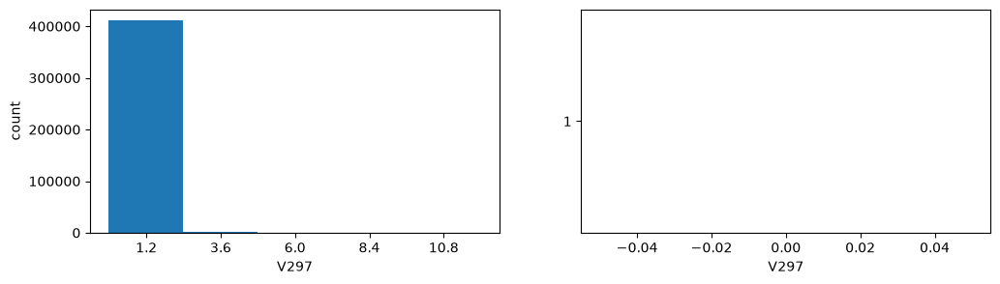

V298


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.047, 9.4]",4.7,412604,99.815660,99.815660
1,"(9.4, 18.8]",14.1,362,0.087574,99.903233
2,"(18.8, 28.2]",23.5,339,0.082010,99.985243
3,"(28.2, 37.6]",32.9,33,0.007983,99.993226
4,"(37.6, 47.0]",42.3,28,0.006774,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


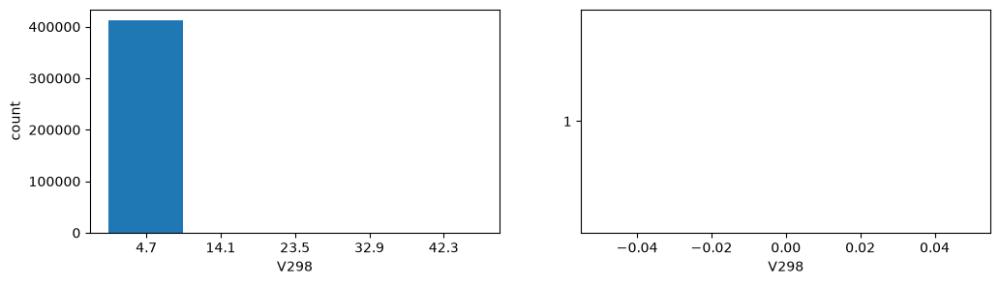

V299


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.025, 5.0]",2.5,412777,99.857511,99.857511
1,"(5.0, 10.0]",7.5,356,0.086122,99.943633
2,"(10.0, 15.0]",12.5,187,0.045238,99.988872
3,"(15.0, 20.0]",17.5,28,0.006774,99.995646
4,"(20.0, 25.0]",22.5,18,0.004354,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


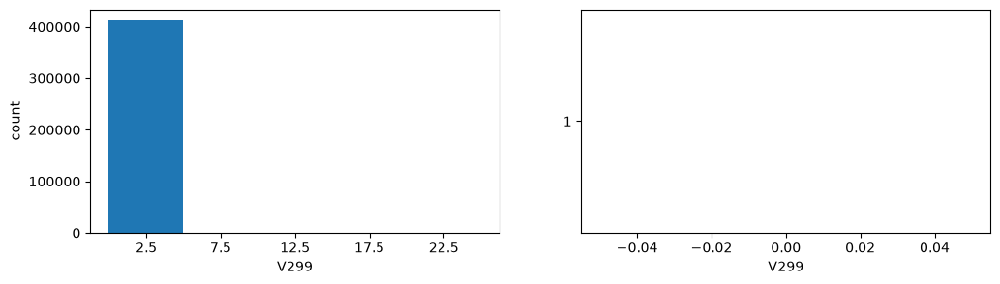

V300


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.011, 2.2]",1.1,412092,99.754784,99.754784
1,"(2.2, 4.4]",3.3,846,0.204791,99.959574
2,"(4.4, 6.6]",5.5,110,0.026628,99.986202
3,"(6.6, 8.8]",7.7,21,0.005083,99.991286
4,"(8.8, 11.0]",9.9,36,0.008714,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


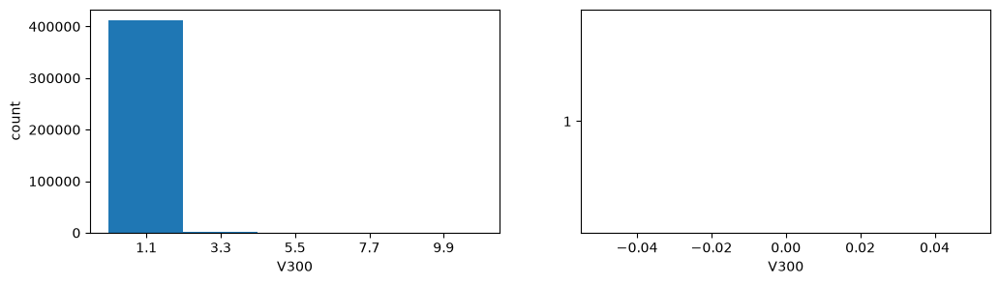

V301


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.011, 2.2]",1.1,411884,99.704433,99.704433
1,"(2.2, 4.4]",3.3,1014,0.245458,99.949892
2,"(4.4, 6.6]",5.5,144,0.034858,99.984750
3,"(6.6, 8.8]",7.7,23,0.005568,99.990317
4,"(8.8, 11.0]",9.9,40,0.009683,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


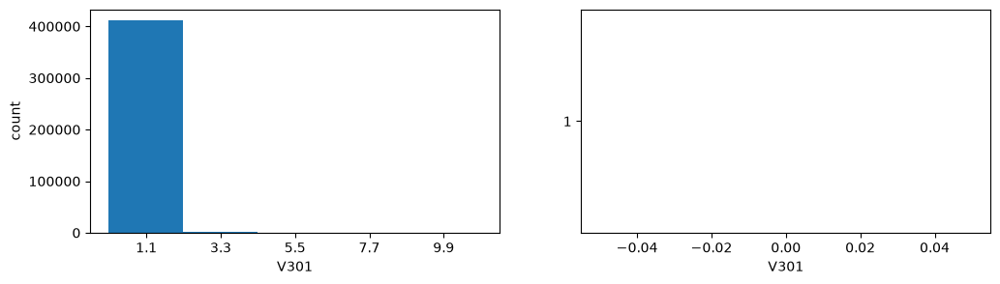

V302


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.01, 2.0]",1.0,412648,99.826304,99.826304
1,"(2.0, 4.0]",3.0,589,0.142489,99.968793
2,"(4.0, 6.0]",5.0,97,0.023466,99.992259
3,"(6.0, 8.0]",7.0,25,0.006048,99.998307
4,"(8.0, 10.0]",9.0,7,0.001693,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


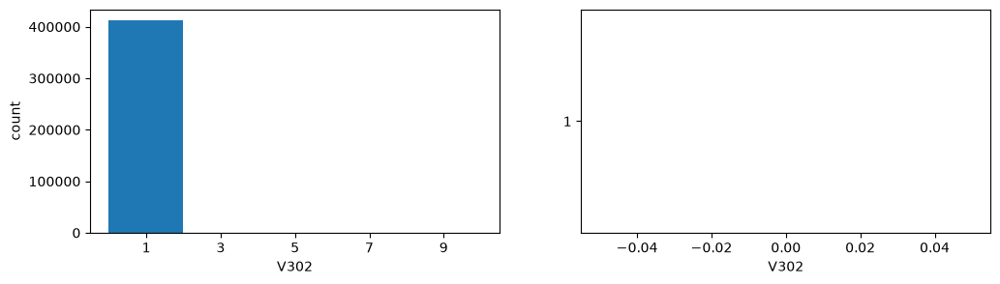

V303


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.017, 3.4]",1.7,412157,99.707523,99.707523
1,"(3.4, 6.8]",5.1,958,0.231756,99.939279
2,"(6.8, 10.2]",8.5,212,0.051286,99.990565
3,"(10.2, 13.6]",11.9,26,0.006290,99.996855
4,"(13.6, 17.0]",15.3,13,0.003145,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


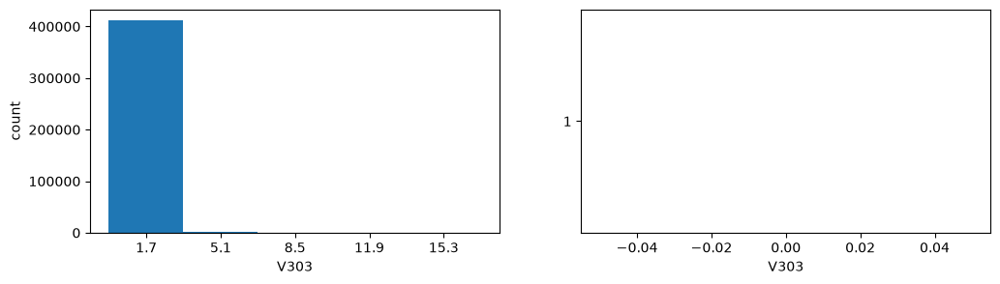

V304


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.011, 2.2]",1.1,412075,99.687686,99.687686
1,"(2.2, 4.4]",3.3,1061,0.256673,99.944359
2,"(4.4, 6.6]",5.5,179,0.043303,99.987662
3,"(6.6, 8.8]",7.7,33,0.007983,99.995646
4,"(8.8, 11.0]",9.9,18,0.004354,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


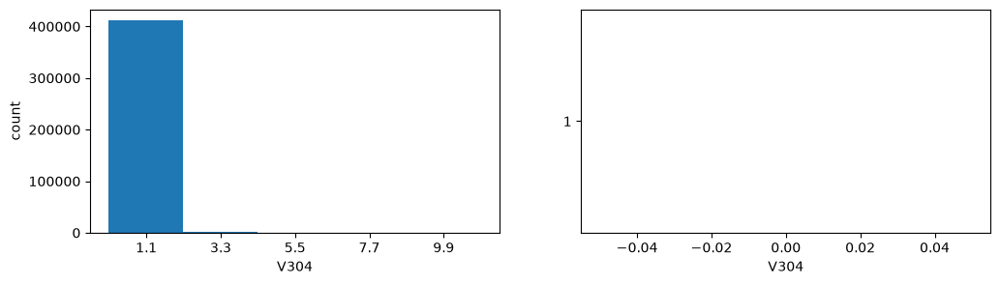

V305


,bins,mid_bin,counts,freq,cum_freq
0,"(0.999, 1.2]",1.1,413363,99.999274,99.999274
1,"(1.2, 1.4]",1.3,0,0.000000,99.999274
2,"(1.4, 1.6]",1.5,0,0.000000,99.999274
3,"(1.6, 1.8]",1.7,0,0.000000,99.999274
4,"(1.8, 2.0]",1.9,3,0.000726,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


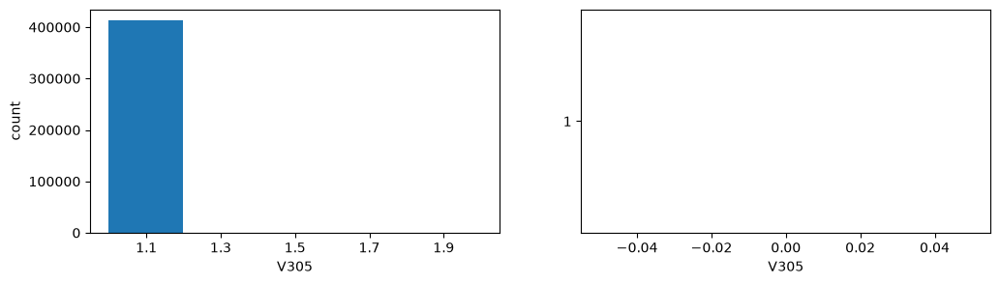

V306


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,413356,99.997581,99.997581
1,"(20328.0, 40656.0]",30492.0,4,0.000968,99.998549
2,"(40656.0, 60984.0]",50820.0,2,0.000484,99.999032
3,"(60984.0, 81312.0]",71148.0,3,0.000726,99.999758
4,"(81312.0, 101640.0]",91476.0,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


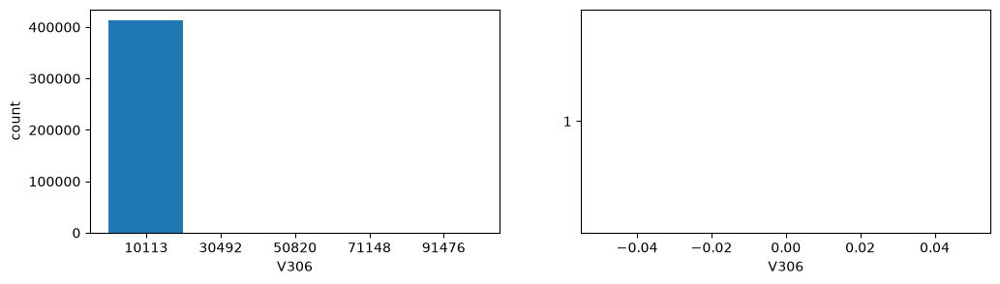

V307


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,413044,99.922103,99.922103
1,"(20328.0, 40656.0]",30492.0,117,0.028304,99.950407
2,"(40656.0, 60984.0]",50820.0,135,0.032659,99.983066
3,"(60984.0, 81312.0]",71148.0,59,0.014273,99.997339
4,"(81312.0, 101640.0]",91476.0,11,0.002661,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


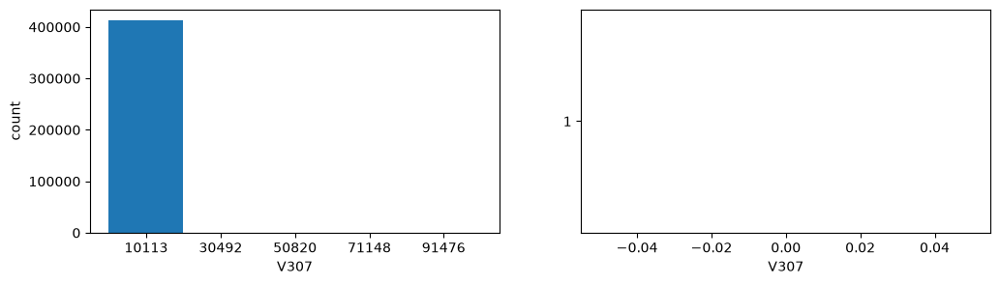

V308


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,413342,99.994194,99.994194
1,"(20328.0, 40656.0]",30492.0,18,0.004354,99.998549
2,"(40656.0, 60984.0]",50820.0,2,0.000484,99.999032
3,"(60984.0, 81312.0]",71148.0,3,0.000726,99.999758
4,"(81312.0, 101640.0]",91476.0,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


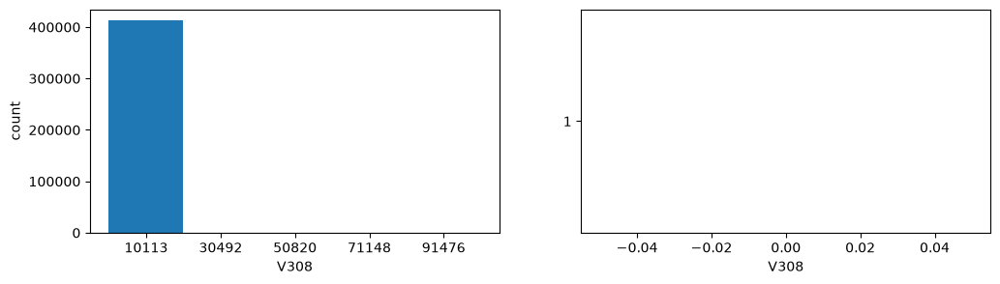

V309


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,413362,99.999032,99.999032
1,"(11025.0, 22050.0]",16537.5,2,0.000484,99.999516
2,"(22050.0, 33075.0]",27562.5,1,0.000242,99.999758
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999758
4,"(44100.0, 55125.0]",49612.5,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


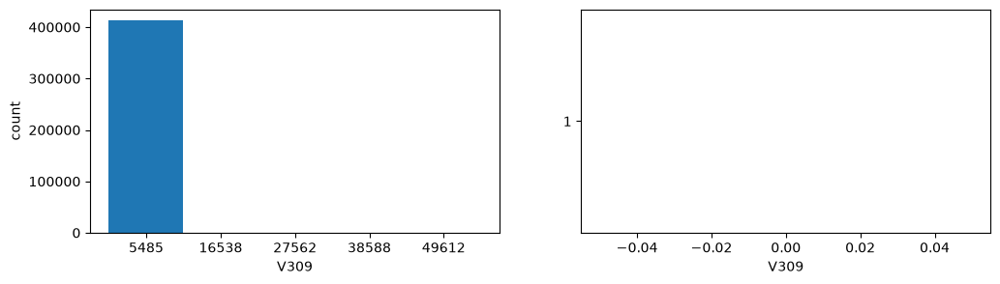

V310


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,413360,99.998549,99.998549
1,"(11025.0, 22050.0]",16537.5,4,0.000968,99.999516
2,"(22050.0, 33075.0]",27562.5,0,0.000000,99.999516
3,"(33075.0, 44100.0]",38587.5,1,0.000242,99.999758
4,"(44100.0, 55125.0]",49612.5,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


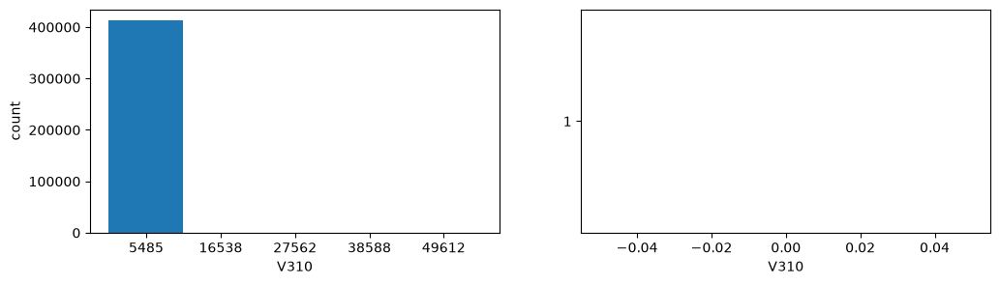

V311


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,413363,99.999274,99.999274
1,"(11025.0, 22050.0]",16537.5,1,0.000242,99.999516
2,"(22050.0, 33075.0]",27562.5,1,0.000242,99.999758
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999758
4,"(44100.0, 55125.0]",49612.5,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


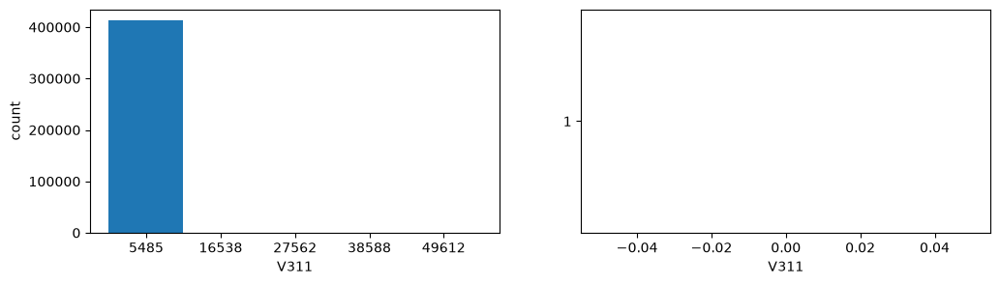

V312


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,413362,99.999032,99.999032
1,"(11025.0, 22050.0]",16537.5,2,0.000484,99.999516
2,"(22050.0, 33075.0]",27562.5,1,0.000242,99.999758
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.999758
4,"(44100.0, 55125.0]",49612.5,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


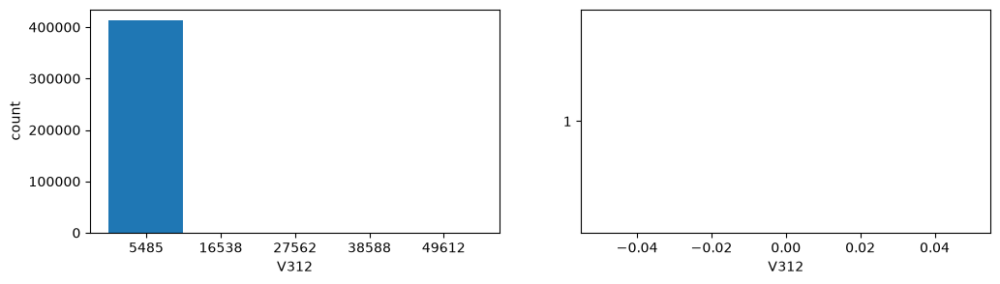

V313


,bins,mid_bin,counts,freq,cum_freq
0,"(-4.817, 963.494]",479.3,412422,99.834667,99.834667
1,"(963.494, 1926.988]",1445.2,527,0.127570,99.962237
2,"(1926.988, 2890.482]",2408.7,114,0.027596,99.989833
3,"(2890.482, 3853.976]",3372.2,32,0.007746,99.997579
4,"(3853.976, 4817.47]",4335.7,10,0.002421,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


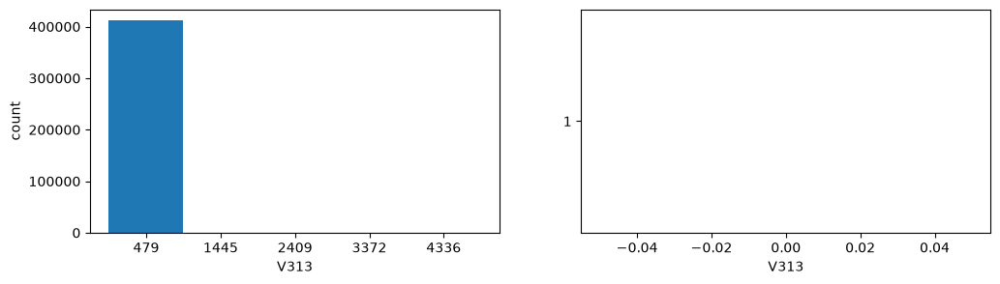

V314


,bins,mid_bin,counts,freq,cum_freq
0,"(-6.16, 1231.978]",612.9,411728,99.666671,99.666671
1,"(1231.978, 2463.956]",1848.0,1124,0.272086,99.938756
2,"(2463.956, 3695.934]",3079.9,205,0.049624,99.988381
3,"(3695.934, 4927.912]",4311.9,40,0.009683,99.998063
4,"(4927.912, 6159.89]",5543.9,8,0.001937,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


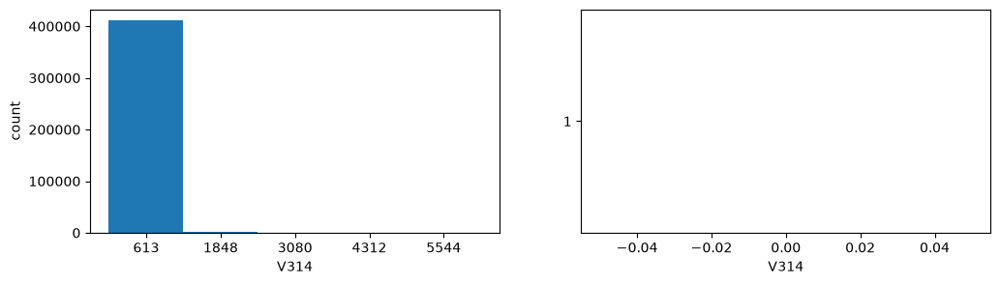

V315


,bins,mid_bin,counts,freq,cum_freq
0,"(-4.817, 963.494]",479.3,411990,99.730093,99.730093
1,"(963.494, 1926.988]",1445.2,933,0.225851,99.955943
2,"(1926.988, 2890.482]",2408.7,127,0.030743,99.986686
3,"(2890.482, 3853.976]",3372.2,35,0.008472,99.995159
4,"(3853.976, 4817.47]",4335.7,20,0.004841,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


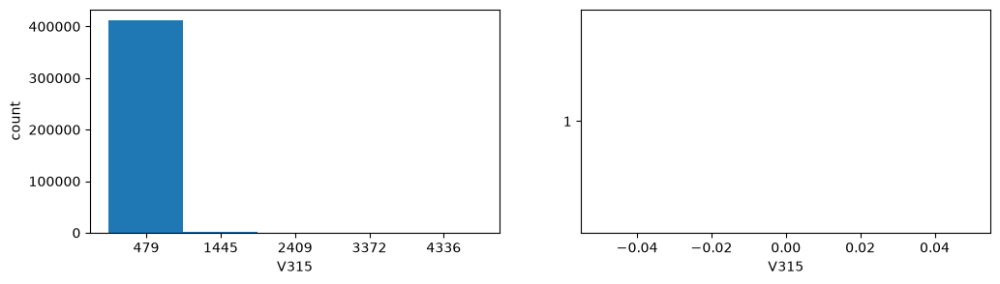

V316


,bins,mid_bin,counts,freq,cum_freq
0,"(-63.875, 12774.956]",6355.5,413359,99.998307,99.998307
1,"(12774.956, 25549.912]",19162.4,3,0.000726,99.999032
2,"(25549.912, 38324.869]",31937.4,1,0.000242,99.999274
3,"(38324.869, 51099.825]",44712.3,0,0.000000,99.999274
4,"(51099.825, 63874.781]",57487.3,3,0.000726,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


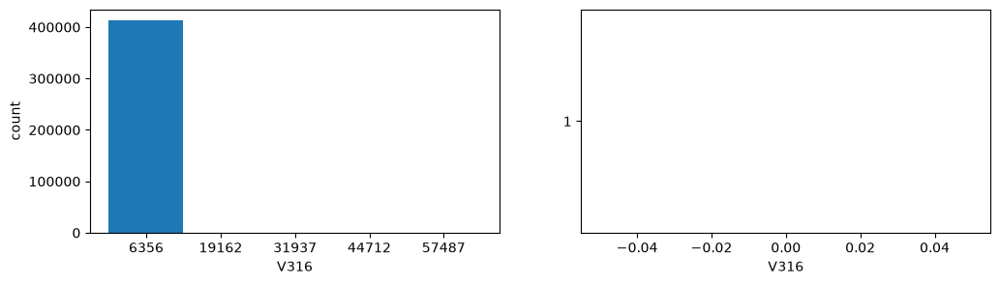

V317


,bins,mid_bin,counts,freq,cum_freq
0,"(-86.716, 17343.192]",8628.2,413051,99.923796,99.923796
1,"(17343.192, 34686.384]",26014.8,114,0.027578,99.951375
2,"(34686.384, 52029.577]",43358.0,88,0.021289,99.972663
3,"(52029.577, 69372.769]",60701.2,81,0.019595,99.992259
4,"(69372.769, 86715.961]",78044.4,32,0.007741,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


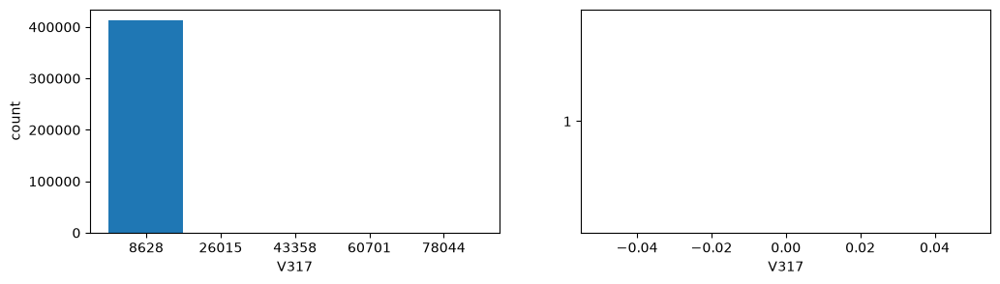

V318


,bins,mid_bin,counts,freq,cum_freq
0,"(-63.875, 12774.956]",6355.5,413246,99.970970,99.970970
1,"(12774.956, 25549.912]",19162.4,114,0.027578,99.998549
2,"(25549.912, 38324.869]",31937.4,3,0.000726,99.999274
3,"(38324.869, 51099.825]",44712.3,0,0.000000,99.999274
4,"(51099.825, 63874.781]",57487.3,3,0.000726,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


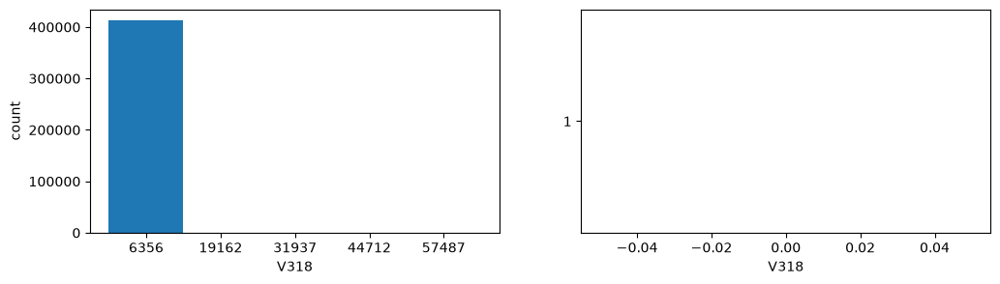

V319


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,413362,99.999032,99.999032
1,"(20328.0, 40656.0]",30492.0,2,0.000484,99.999516
2,"(40656.0, 60984.0]",50820.0,1,0.000242,99.999758
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999758
4,"(81312.0, 101640.0]",91476.0,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


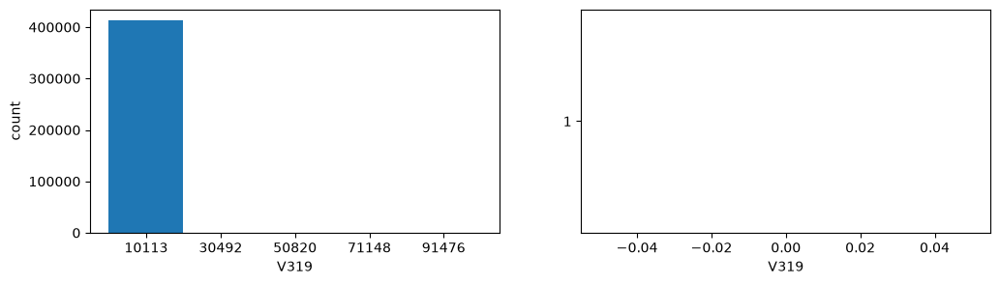

V320


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,413362,99.999032,99.999032
1,"(20328.0, 40656.0]",30492.0,2,0.000484,99.999516
2,"(40656.0, 60984.0]",50820.0,1,0.000242,99.999758
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999758
4,"(81312.0, 101640.0]",91476.0,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


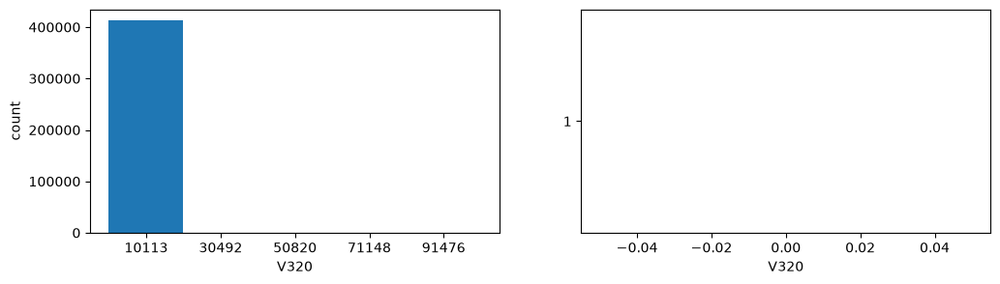

V321


,bins,mid_bin,counts,freq,cum_freq
0,"(-101.64, 20328.0]",10113.2,413362,99.999032,99.999032
1,"(20328.0, 40656.0]",30492.0,2,0.000484,99.999516
2,"(40656.0, 60984.0]",50820.0,1,0.000242,99.999758
3,"(60984.0, 81312.0]",71148.0,0,0.000000,99.999758
4,"(81312.0, 101640.0]",91476.0,1,0.000242,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


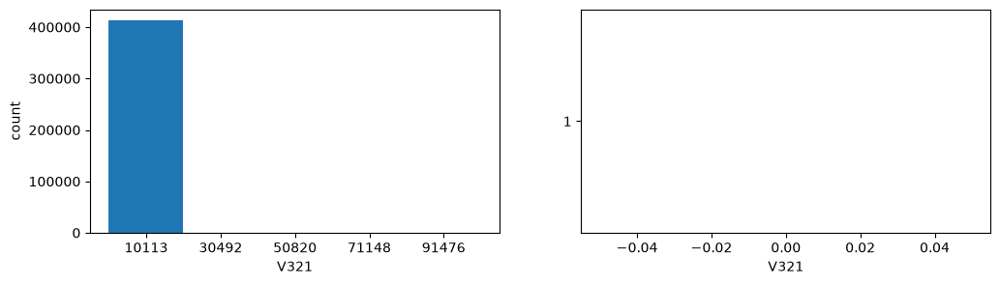

V322


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.032, 6.4]",3.2,65090,99.433250,99.433250
1,"(6.4, 12.8]",9.6,290,0.443012,99.876262
2,"(12.8, 19.2]",16.0,61,0.093185,99.969447
3,"(19.2, 25.6]",22.4,13,0.019859,99.989307
4,"(25.6, 32.0]",28.8,7,0.010693,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


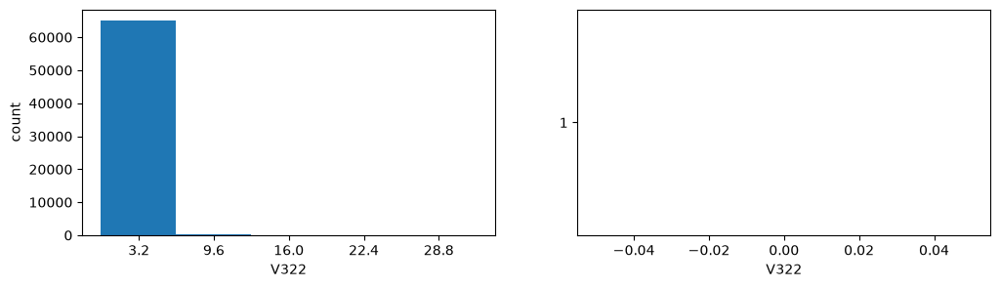

V323


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.049, 9.8]",4.9,64415,98.402102,98.402102
1,"(9.8, 19.6]",14.7,632,0.965460,99.367562
2,"(19.6, 29.4]",24.5,213,0.325385,99.692947
3,"(29.4, 39.2]",34.3,112,0.171094,99.864041
4,"(39.2, 49.0]",44.1,89,0.135959,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


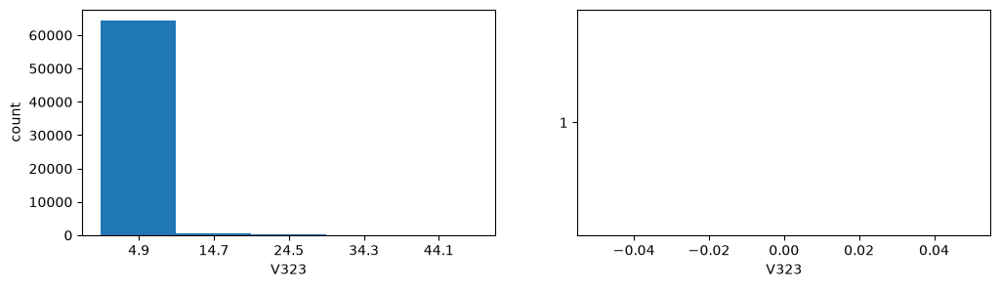

V324


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.033, 6.6]",3.3,64714,98.858863,98.858863
1,"(6.6, 13.2]",9.9,605,0.924214,99.783077
2,"(13.2, 19.8]",16.5,99,0.151235,99.934312
3,"(19.8, 26.4]",23.1,36,0.054995,99.989307
4,"(26.4, 33.0]",29.7,7,0.010693,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


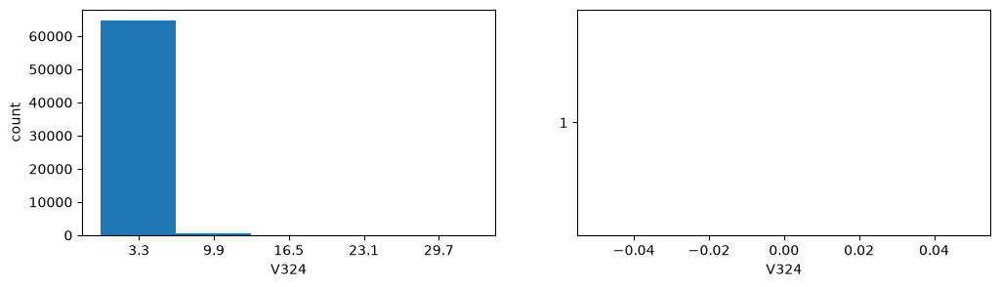

V325


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.012, 2.4]",1.2,65362,99.848765,99.848765
1,"(2.4, 4.8]",3.6,78,0.119155,99.967920
2,"(4.8, 7.2]",6.0,16,0.024442,99.992362
3,"(7.2, 9.6]",8.4,2,0.003055,99.995417
4,"(9.6, 12.0]",10.8,3,0.004583,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


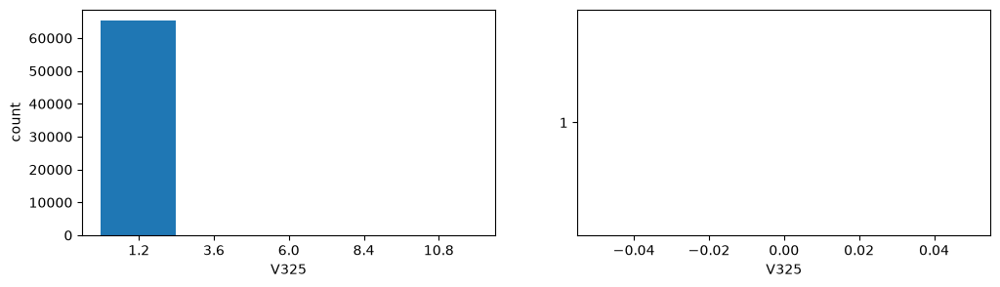

V326


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.044, 8.8]",4.4,64678,98.803868,98.803868
1,"(8.8, 17.6]",13.2,439,0.670628,99.474496
2,"(17.6, 26.4]",22.0,217,0.331495,99.805991
3,"(26.4, 35.2]",30.8,75,0.114572,99.920563
4,"(35.2, 44.0]",39.6,52,0.079437,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


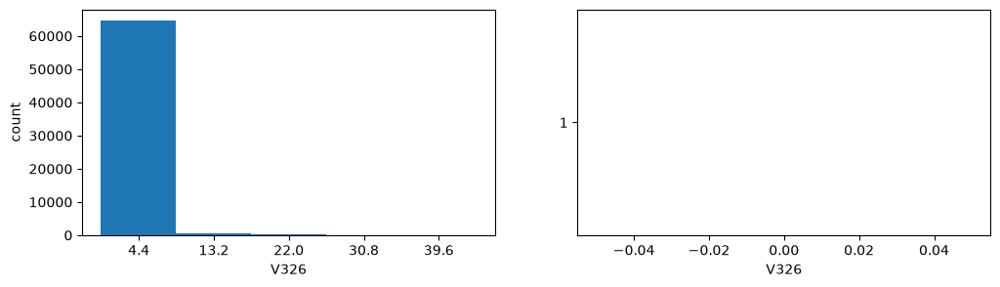

V327


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.018, 3.6]",1.8,64859,99.080368,99.080368
1,"(3.6, 7.2]",5.4,426,0.650769,99.731138
2,"(7.2, 10.8]",9.0,142,0.216923,99.948061
3,"(10.8, 14.4]",12.6,25,0.038191,99.986251
4,"(14.4, 18.0]",16.2,9,0.013749,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


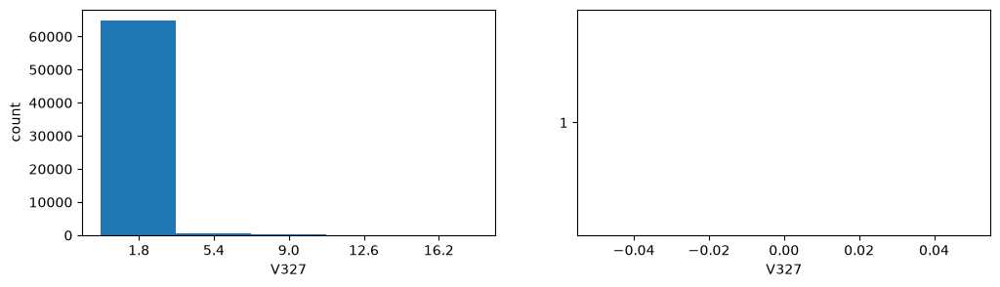

V328


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,65139,99.508104,99.508104
1,"(3.0, 6.0]",4.5,232,0.354409,99.862514
2,"(6.0, 9.0]",7.5,44,0.067216,99.929729
3,"(9.0, 12.0]",10.5,38,0.058050,99.987779
4,"(12.0, 15.0]",13.5,8,0.012221,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


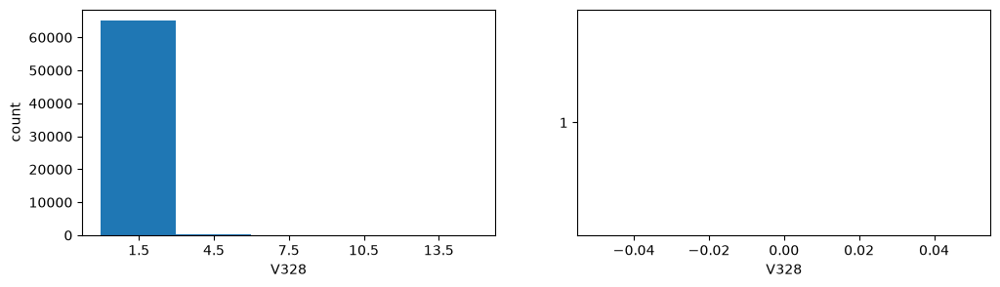

V329


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.024, 4.8]",2.4,65059,99.385894,99.385894
1,"(4.8, 9.6]",7.2,228,0.348299,99.734193
2,"(9.6, 14.4]",12.0,96,0.146652,99.880845
3,"(14.4, 19.2]",16.8,32,0.048884,99.929729
4,"(19.2, 24.0]",21.6,46,0.070271,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


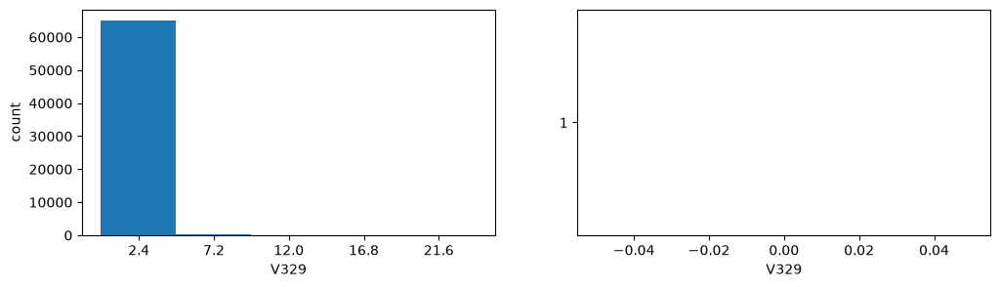

V330


,bins,mid_bin,counts,freq,cum_freq
0,"(-0.015, 3.0]",1.5,65053,99.376728,99.376728
1,"(3.0, 6.0]",4.5,268,0.409404,99.786132
2,"(6.0, 9.0]",7.5,64,0.097768,99.883900
3,"(9.0, 12.0]",10.5,65,0.099296,99.983196
4,"(12.0, 15.0]",13.5,11,0.016804,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


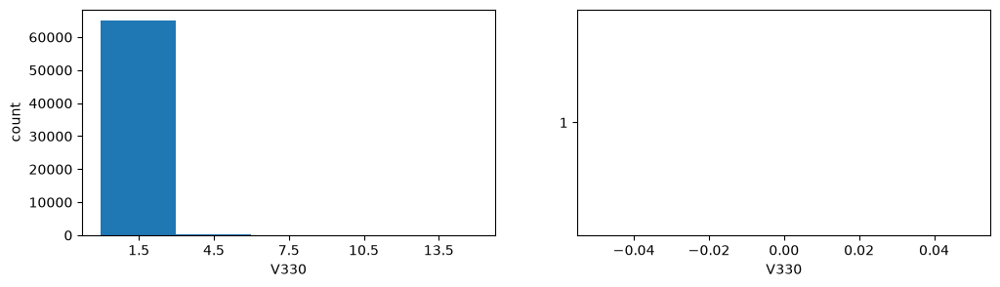

V331


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,65425,99.945005,99.945005
1,"(11025.0, 22050.0]",16537.5,32,0.048884,99.993889
2,"(22050.0, 33075.0]",27562.5,2,0.003055,99.996945
3,"(33075.0, 44100.0]",38587.5,1,0.001528,99.998472
4,"(44100.0, 55125.0]",49612.5,1,0.001528,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


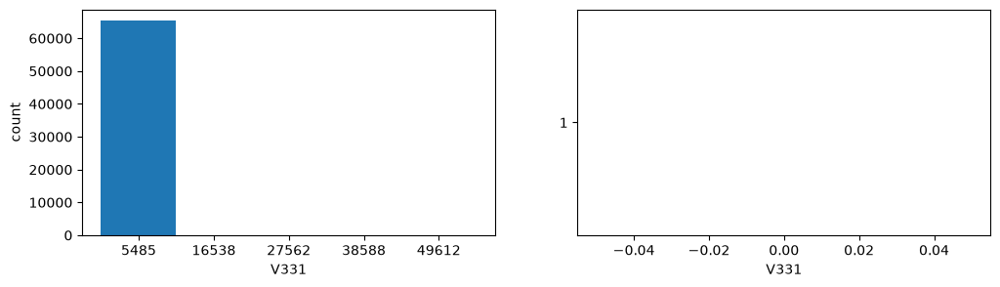

V332


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,65408,99.919036,99.919036
1,"(11025.0, 22050.0]",16537.5,47,0.071798,99.990834
2,"(22050.0, 33075.0]",27562.5,3,0.004583,99.995417
3,"(33075.0, 44100.0]",38587.5,2,0.003055,99.998472
4,"(44100.0, 55125.0]",49612.5,1,0.001528,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


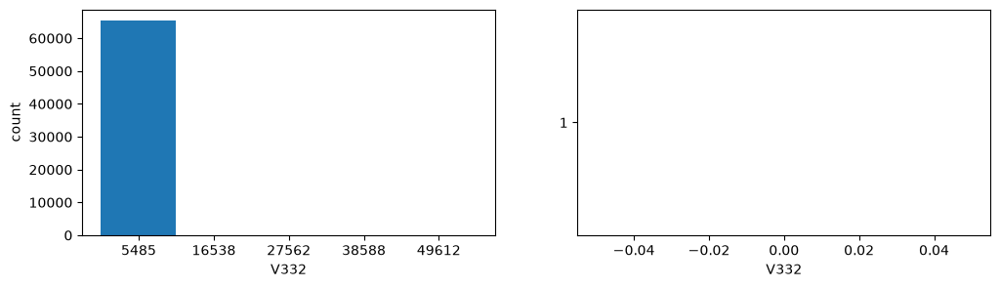

V333


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,65424,99.943478,99.943478
1,"(11025.0, 22050.0]",16537.5,33,0.050412,99.993889
2,"(22050.0, 33075.0]",27562.5,2,0.003055,99.996945
3,"(33075.0, 44100.0]",38587.5,1,0.001528,99.998472
4,"(44100.0, 55125.0]",49612.5,1,0.001528,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


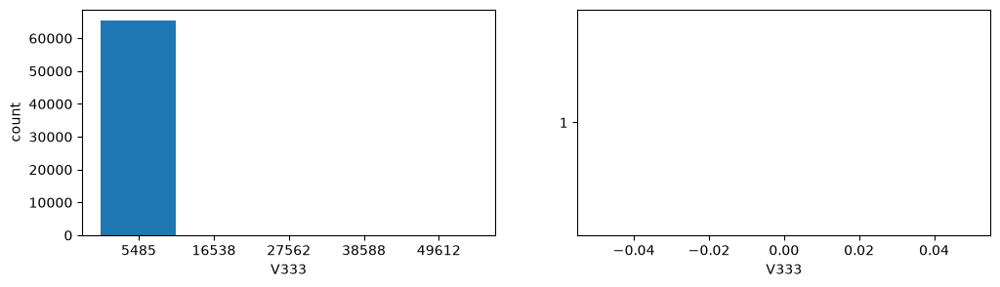

V334


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,65457,99.993889,99.993889
1,"(11025.0, 22050.0]",16537.5,2,0.003055,99.996945
2,"(22050.0, 33075.0]",27562.5,1,0.001528,99.998472
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.998472
4,"(44100.0, 55125.0]",49612.5,1,0.001528,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


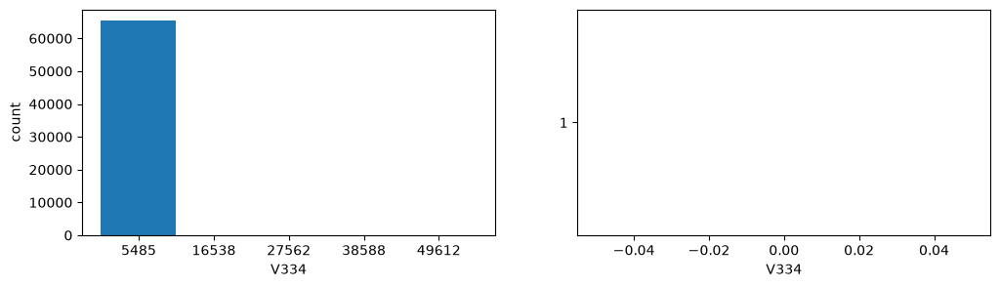

V335


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,65456,99.992362,99.992362
1,"(11025.0, 22050.0]",16537.5,3,0.004583,99.996945
2,"(22050.0, 33075.0]",27562.5,0,0.000000,99.996945
3,"(33075.0, 44100.0]",38587.5,1,0.001528,99.998472
4,"(44100.0, 55125.0]",49612.5,1,0.001528,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


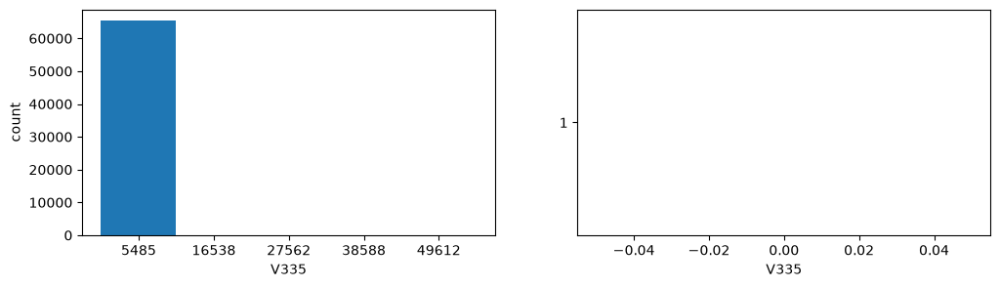

V336


,bins,mid_bin,counts,freq,cum_freq
0,"(-55.125, 11025.0]",5484.9,65457,99.993889,99.993889
1,"(11025.0, 22050.0]",16537.5,2,0.003055,99.996945
2,"(22050.0, 33075.0]",27562.5,1,0.001528,99.998472
3,"(33075.0, 44100.0]",38587.5,0,0.000000,99.998472
4,"(44100.0, 55125.0]",49612.5,1,0.001528,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


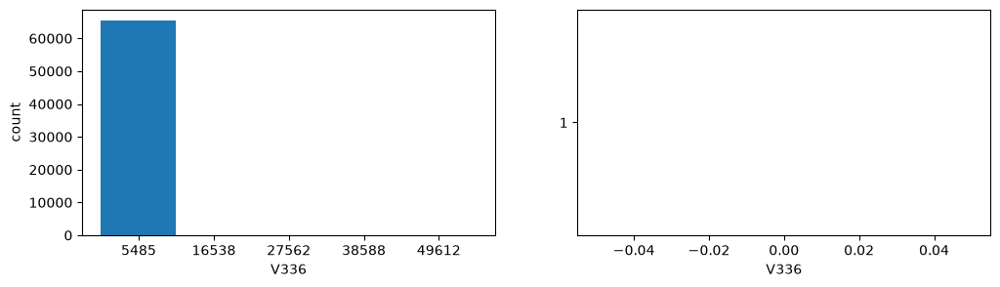

V337


,bins,mid_bin,counts,freq,cum_freq
0,"(-25.0, 5000.0]",2487.5,65416,99.931257,99.931257
1,"(5000.0, 10000.0]",7500.0,38,0.058050,99.989307
2,"(10000.0, 15000.0]",12500.0,3,0.004583,99.993889
3,"(15000.0, 20000.0]",17500.0,2,0.003055,99.996945
4,"(20000.0, 25000.0]",22500.0,2,0.003055,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


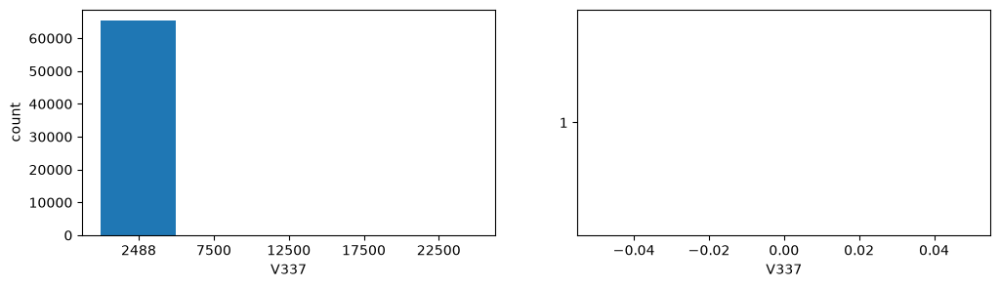

V338


,bins,mid_bin,counts,freq,cum_freq
0,"(-25.0, 5000.0]",2487.5,65405,99.914453,99.914453
1,"(5000.0, 10000.0]",7500.0,49,0.074854,99.989307
2,"(10000.0, 15000.0]",12500.0,3,0.004583,99.993889
3,"(15000.0, 20000.0]",17500.0,2,0.003055,99.996945
4,"(20000.0, 25000.0]",22500.0,2,0.003055,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


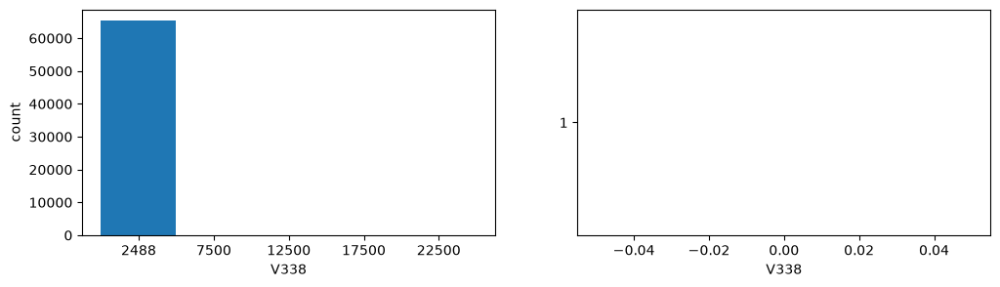

V339


,bins,mid_bin,counts,freq,cum_freq
0,"(-25.0, 5000.0]",2487.5,65415,99.929729,99.929729
1,"(5000.0, 10000.0]",7500.0,39,0.059577,99.989307
2,"(10000.0, 15000.0]",12500.0,3,0.004583,99.993889
3,"(15000.0, 20000.0]",17500.0,2,0.003055,99.996945
4,"(20000.0, 25000.0]",22500.0,2,0.003055,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


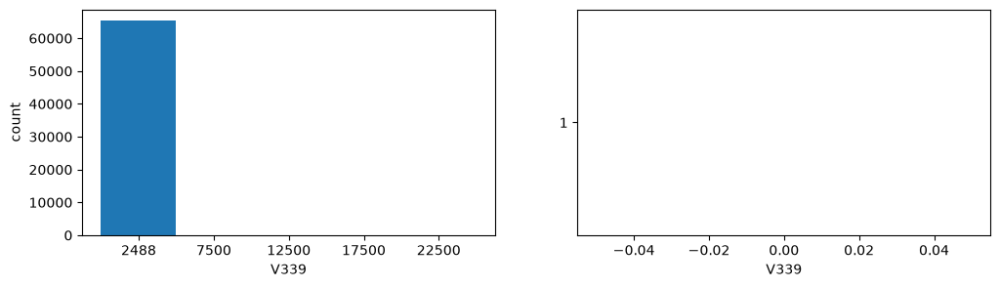

id_01


,bins,mid_bin,counts,freq,cum_freq
0,"(-100.1, -80.0]",-90.0,1488,1.353823,1.353823
1,"(-80.0, -60.0]",-70.0,486,0.442176,1.795999
2,"(-60.0, -40.0]",-50.0,3484,3.169837,4.965836
3,"(-40.0, -20.0]",-30.0,13125,11.941480,16.907316
4,"(-20.0, 0.0]",-10.0,91328,83.092684,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


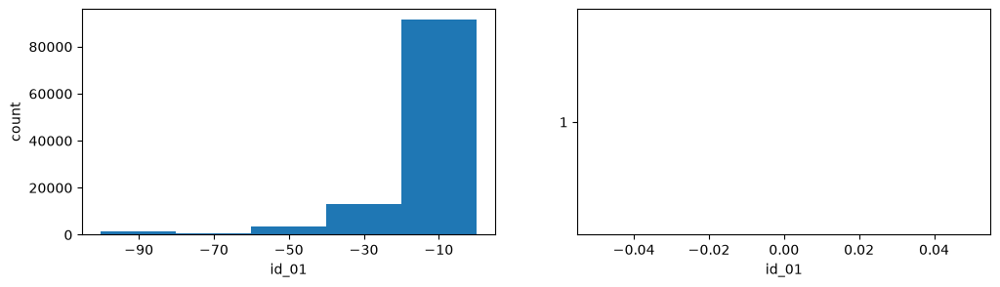

id_02


,bins,mid_bin,counts,freq,cum_freq
0,"(-969.565, 199943.0]",99486.7,77605,72.237064,72.237064
1,"(199943.0, 399856.0]",299899.5,21362,19.884391,92.121455
2,"(399856.0, 599769.0]",499812.5,5944,5.532854,97.654308
3,"(599769.0, 799682.0]",699725.5,1829,1.702488,99.356796
4,"(799682.0, 999595.0]",899638.5,691,0.643204,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


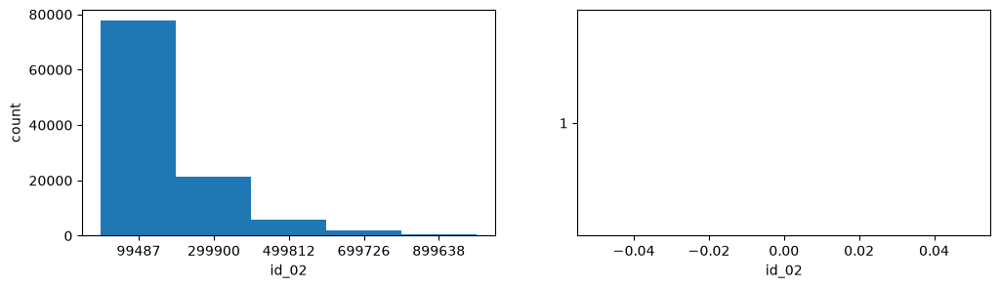

id_03


,bins,mid_bin,counts,freq,cum_freq
0,"(-12.022, -7.6]",-9.8,33,0.067118,0.067118
1,"(-7.6, -3.2]",-5.4,66,0.134236,0.201355
2,"(-3.2, 1.2]",-1.0,48001,97.628491,97.829845
3,"(1.2, 5.6]",3.4,1010,2.054223,99.884069
4,"(5.6, 10.0]",7.8,57,0.115931,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


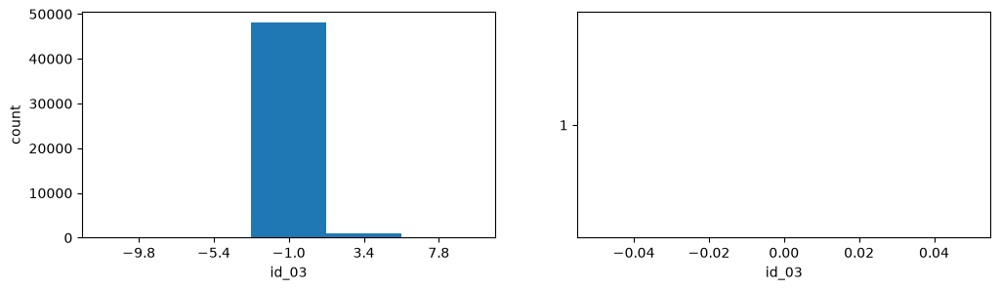

id_04


,bins,mid_bin,counts,freq,cum_freq
0,"(-28.028, -22.4]",-25.2,2,0.004068,0.004068
1,"(-22.4, -16.8]",-19.6,0,0.000000,0.004068
2,"(-16.8, -11.2]",-14.0,37,0.075254,0.079321
3,"(-11.2, -5.6]",-8.4,187,0.380336,0.459658
4,"(-5.6, 0.0]",-2.8,48941,99.540342,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


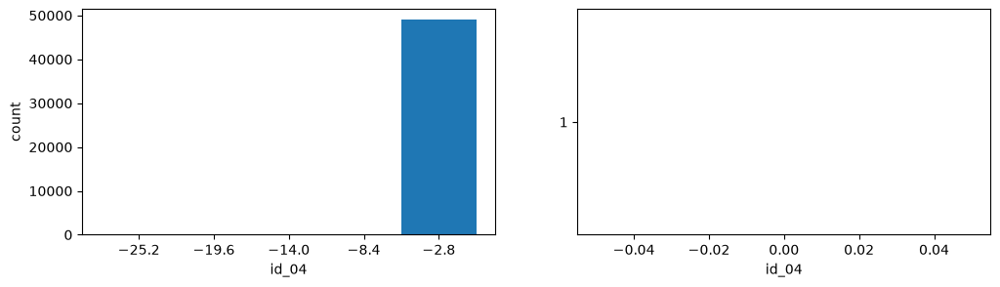

id_05


,bins,mid_bin,counts,freq,cum_freq
0,"(-72.124, -47.2]",-59.7,5,0.004780,0.004780
1,"(-47.2, -22.4]",-34.8,60,0.057362,0.062142
2,"(-22.4, 2.4]",-10.0,85177,81.431945,81.494087
3,"(2.4, 27.2]",14.8,18707,17.884492,99.378579
4,"(27.2, 52.0]",39.6,650,0.621421,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


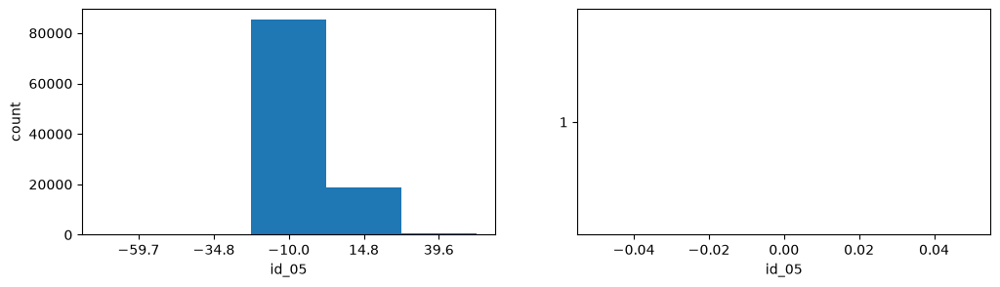

id_06


,bins,mid_bin,counts,freq,cum_freq
0,"(-100.1, -80.0]",-90.0,1997,1.909196,1.909196
1,"(-80.0, -60.0]",-70.0,268,0.256217,2.165413
2,"(-60.0, -40.0]",-50.0,1443,1.379554,3.544967
3,"(-40.0, -20.0]",-30.0,8475,8.102372,11.647339
4,"(-20.0, 0.0]",-10.0,92416,88.352661,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


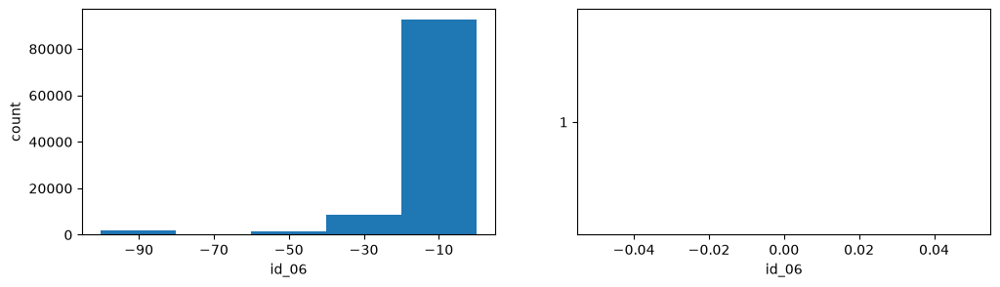

id_07


,bins,mid_bin,counts,freq,cum_freq
0,"(-46.107, -24.6]",-35.4,15,0.381679,0.381679
1,"(-24.6, -3.2]",-13.9,142,3.613232,3.994911
2,"(-3.2, 18.2]",7.5,2446,62.239186,66.234097
3,"(18.2, 39.6]",28.9,1284,32.671756,98.905852
4,"(39.6, 61.0]",50.3,43,1.094148,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


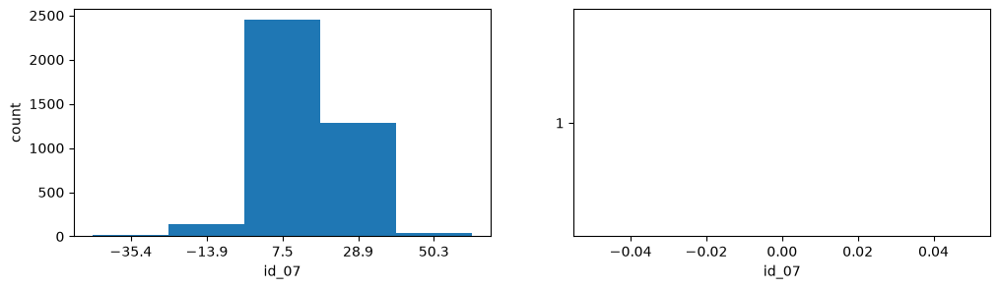

id_08


,bins,mid_bin,counts,freq,cum_freq
0,"(-100.1, -80.0]",-90.0,415,10.559796,10.559796
1,"(-80.0, -60.0]",-70.0,144,3.664122,14.223919
2,"(-60.0, -40.0]",-50.0,946,24.071247,38.295165
3,"(-40.0, -20.0]",-30.0,1639,41.704835,80.000000
4,"(-20.0, 0.0]",-10.0,786,20.000000,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


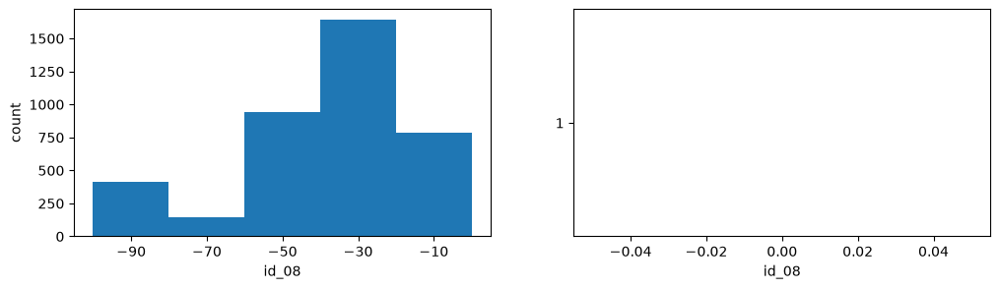

id_09


,bins,mid_bin,counts,freq,cum_freq
0,"(-36.061, -23.8]",-29.9,2,0.003560,0.003560
1,"(-23.8, -11.6]",-17.7,14,0.024917,0.028476
2,"(-11.6, 0.6]",-5.5,52884,94.121416,94.149892
3,"(0.6, 12.8]",6.7,3275,5.828750,99.978643
4,"(12.8, 25.0]",18.9,12,0.021357,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


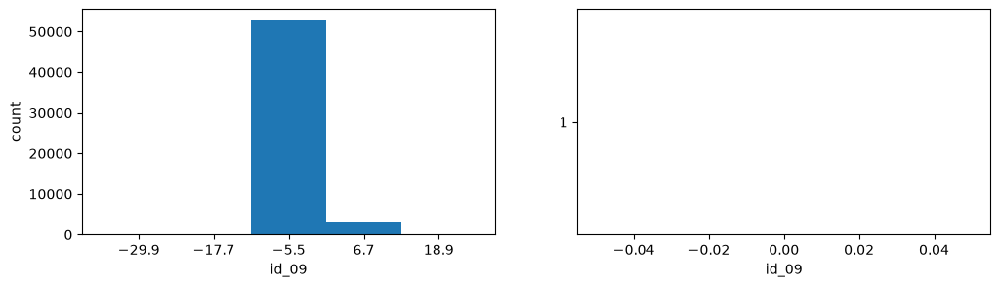

id_10


,bins,mid_bin,counts,freq,cum_freq
0,"(-100.1, -80.0]",-90.0,6,0.010679,0.010679
1,"(-80.0, -60.0]",-70.0,6,0.010679,0.021357
2,"(-60.0, -40.0]",-50.0,25,0.044494,0.065852
3,"(-40.0, -20.0]",-30.0,143,0.254507,0.320359
4,"(-20.0, 0.0]",-10.0,56007,99.679641,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


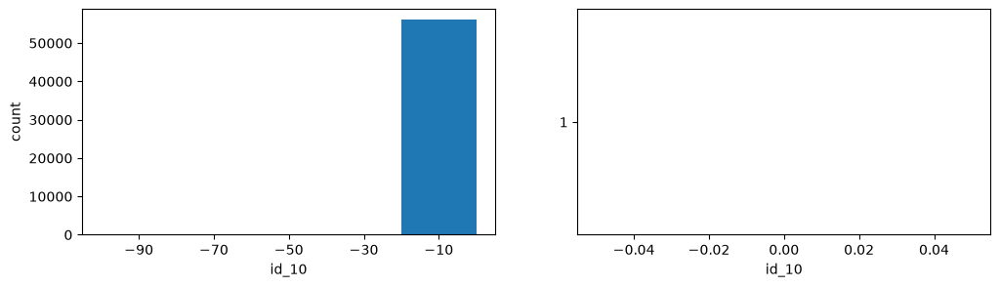

id_11


,bins,mid_bin,counts,freq,cum_freq
0,"(89.99, 92.0]",91.0,373,0.346835,0.346835
1,"(92.0, 94.0]",93.0,586,0.544893,0.891728
2,"(94.0, 96.0]",95.0,2849,2.649148,3.540876
3,"(96.0, 98.0]",97.0,2355,2.189801,5.730678
4,"(98.0, 100.0]",99.0,101381,94.269322,100.000000


/var/folders/16/syxp1z8s64xdp8skd8gbnf_m0000gn/T/ipykernel_3096/1541271705.py:78: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(data, vert = False)


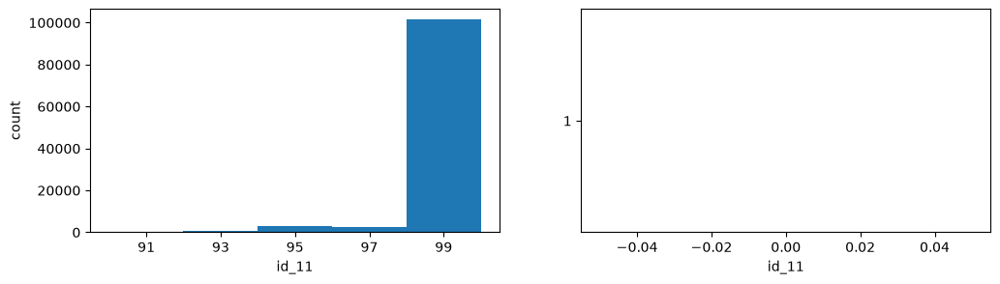

In [14]:
for col in quant_cols:
    freq_tab = freq_table(data = df[col])

    print(col)
    display(freq_tab)
    plot_quant(data = df[col], title = col)

## Qualitative Columns

ProductCD


,ProductCD,counts,freq
0,W,297911,72.067454
1,C,50006,12.096919
2,R,30144,7.292115
3,H,28112,6.800555
4,S,7205,1.742957


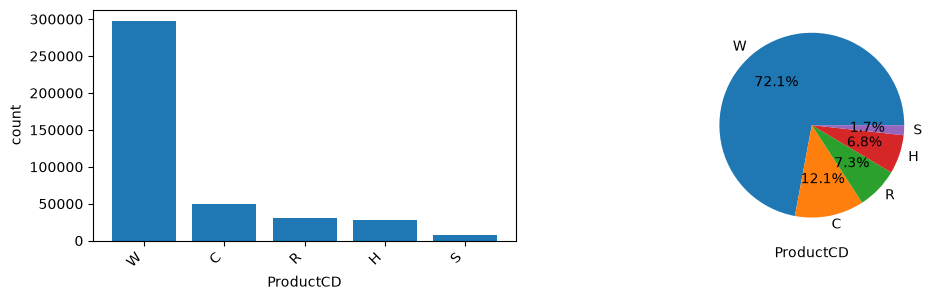

card1


,card1,counts,freq
0,7919,10147,2.454654
1,9500,9680,2.341682
2,15885,7543,1.824722
3,17188,7105,1.718766
4,15066,5459,1.320583
...,...,...,...
12237,15590,1,0.000242
12238,11125,1,0.000242
12239,11678,1,0.000242
12240,12174,1,0.000242


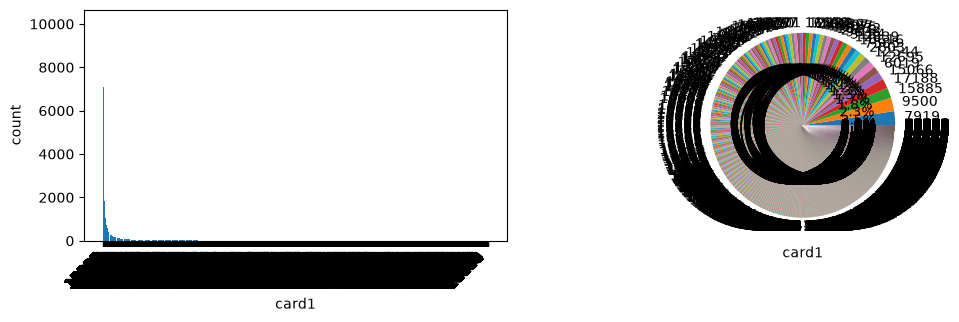

card2


,card2,counts,freq
0,321.0,33645,8.269470
1,111.0,31429,7.724808
2,555.0,29649,7.287309
3,490.0,26051,6.402971
4,583.0,16466,4.047112
...,...,...,...
495,447.0,24,0.005899
496,182.0,23,0.005653
497,582.0,13,0.003195
498,473.0,9,0.002212


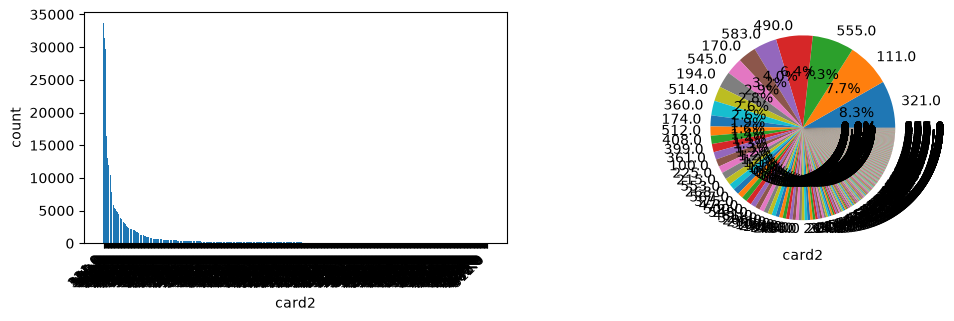

card3


,card3,counts,freq
0,150.0,363155,88.025412
1,185.0,41221,9.991589
2,106.0,1115,0.270266
3,144.0,989,0.239724
4,146.0,895,0.216940
...,...,...,...
100,164.0,1,0.000242
101,155.0,1,0.000242
102,209.0,1,0.000242
103,176.0,1,0.000242


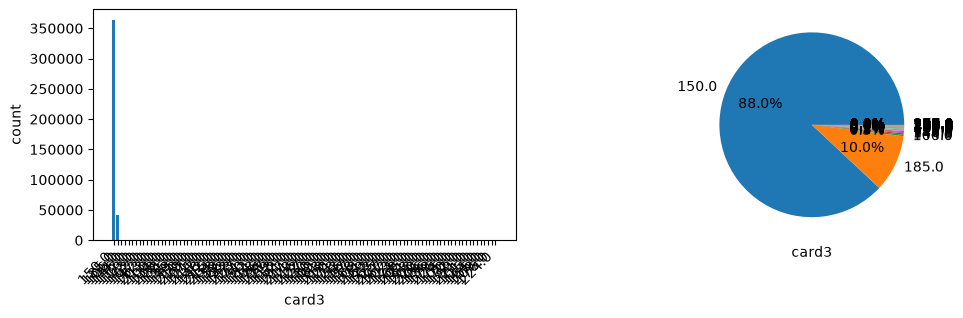

card4


,card4,counts,freq
0,visa,270078,65.465678
1,mastercard,130967,31.745805
2,american express,6741,1.633988
3,discover,4763,1.154530


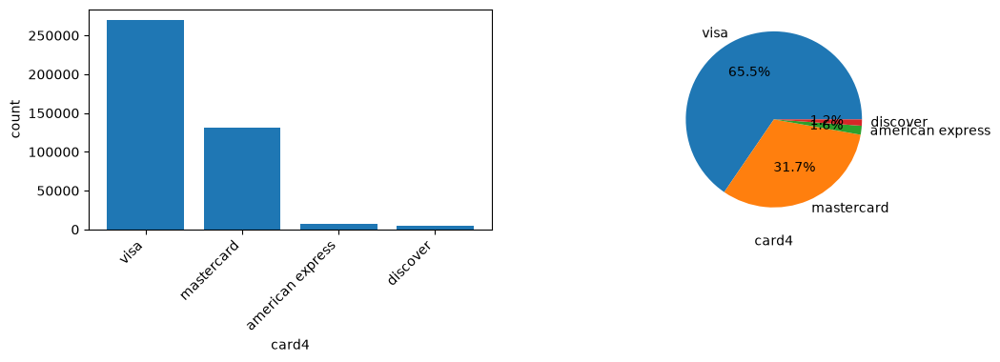

card5


,card5,counts,freq
0,226.0,207524,50.565168
1,224.0,56697,13.814756
2,166.0,39248,9.563143
3,102.0,19786,4.821044
4,117.0,17469,4.256486
...,...,...,...
105,191.0,1,0.000244
106,165.0,1,0.000244
107,115.0,1,0.000244
108,178.0,1,0.000244


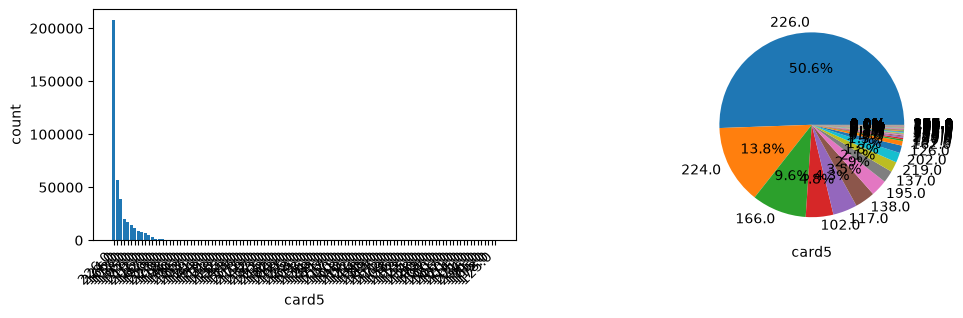

card6


,card6,counts,freq
0,debit,303147,73.480919
1,credit,109361,26.508416
2,debit or credit,29,0.007029
3,charge card,15,0.003636


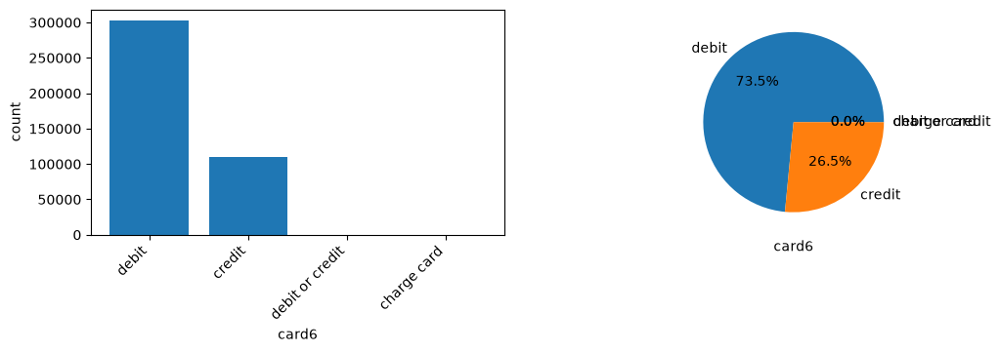

addr1


,addr1,counts,freq
0,299.0,32938,9.002897
1,325.0,29730,8.126059
2,204.0,29160,7.970262
3,264.0,27673,7.563822
4,330.0,17352,4.742798
...,...,...,...
313,195.0,1,0.000273
314,361.0,1,0.000273
315,151.0,1,0.000273
316,417.0,1,0.000273


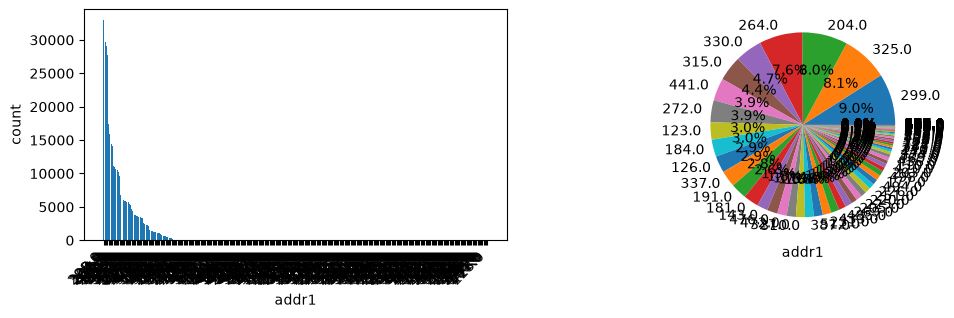

addr2


,addr2,counts,freq
0,87.0,362242,99.011097
1,60.0,2574,0.703548
2,96.0,518,0.141584
3,32.0,77,0.021046
4,65.0,74,0.020226
...,...,...,...
62,84.0,1,0.000273
63,82.0,1,0.000273
64,40.0,1,0.000273
65,36.0,1,0.000273


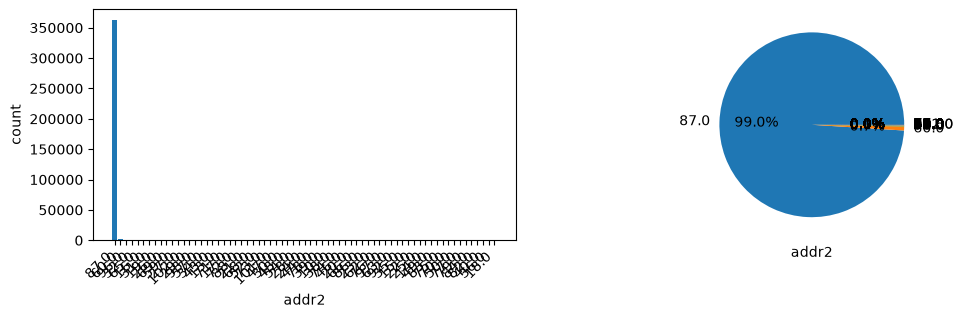

P_emaildomain


,P_emaildomain,counts,freq
0,gmail.com,159214,45.609341
1,yahoo.com,70404,20.168327
2,hotmail.com,32817,9.400943
3,anonymous.com,26745,7.661524
4,aol.com,19798,5.671447
5,comcast.net,5736,1.643167
6,icloud.com,4319,1.237245
7,outlook.com,3550,1.016953
8,msn.com,2964,0.849084
9,att.net,2712,0.776895


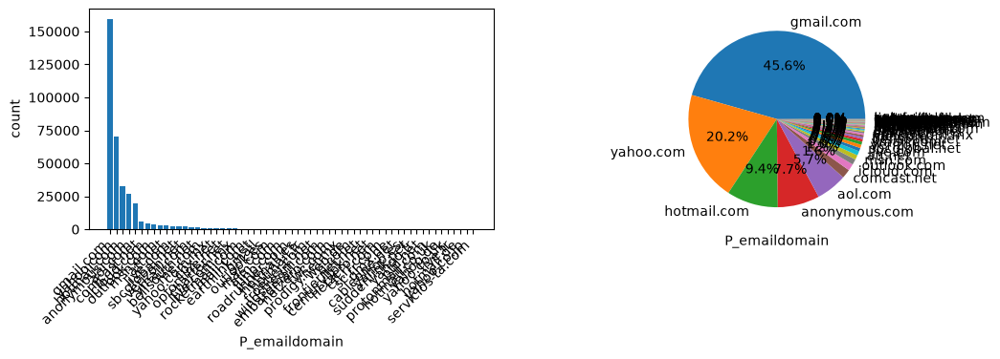

R_emaildomain


,R_emaildomain,counts,freq
0,gmail.com,42668,41.408760
1,hotmail.com,20496,19.891111
2,anonymous.com,15798,15.331761
3,yahoo.com,8274,8.029813
4,aol.com,3065,2.974544
5,outlook.com,1775,1.722615
6,comcast.net,1509,1.464466
7,yahoo.com.mx,1134,1.100533
8,icloud.com,1035,1.004455
9,msn.com,676,0.656050


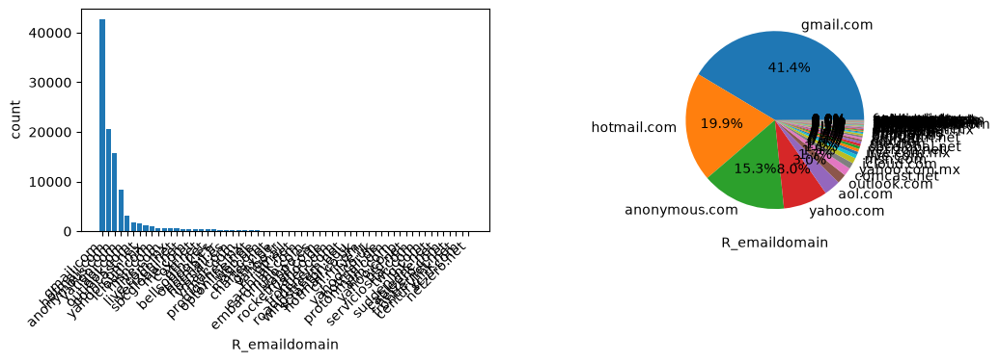

M1


,M1,counts,freq
0,T,190946,99.991098
1,F,17,0.008902


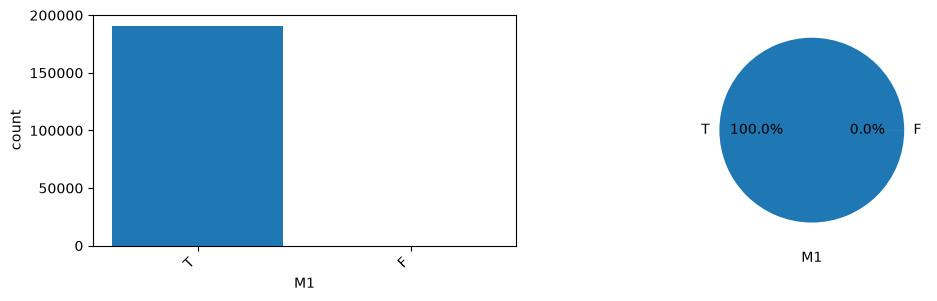

M2


,M2,counts,freq
0,T,170984,89.537764
1,F,19979,10.462236


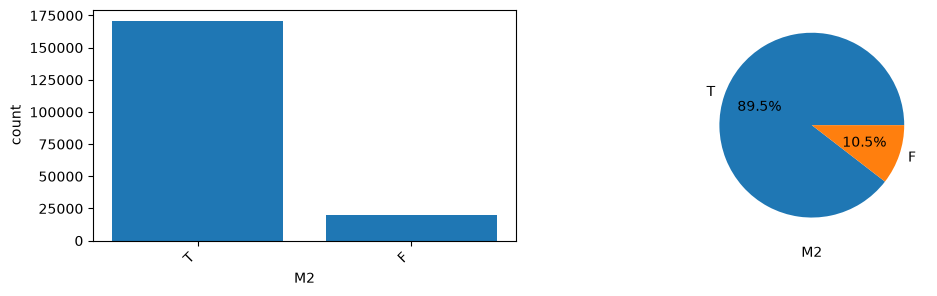

M3


,M3,counts,freq
0,T,150136,78.620466
1,F,40827,21.379534


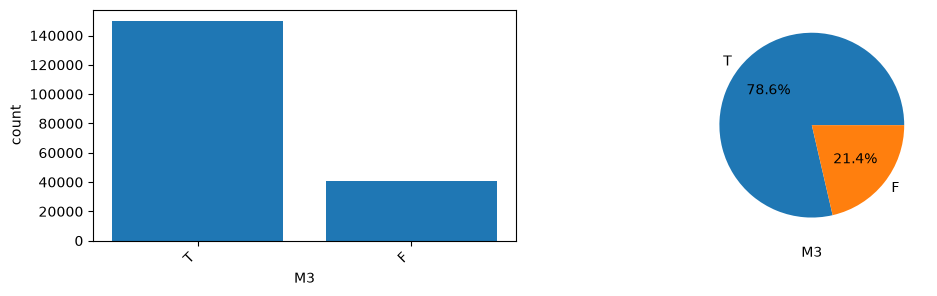

M4


,M4,counts,freq
0,M0,134704,63.172803
1,M2,42774,20.059935
2,M1,35753,16.767262


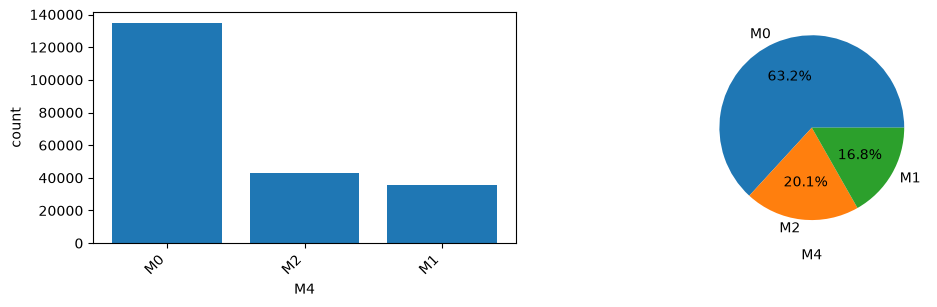

M5


,M5,counts,freq
0,F,90231,55.1423
1,T,73402,44.8577


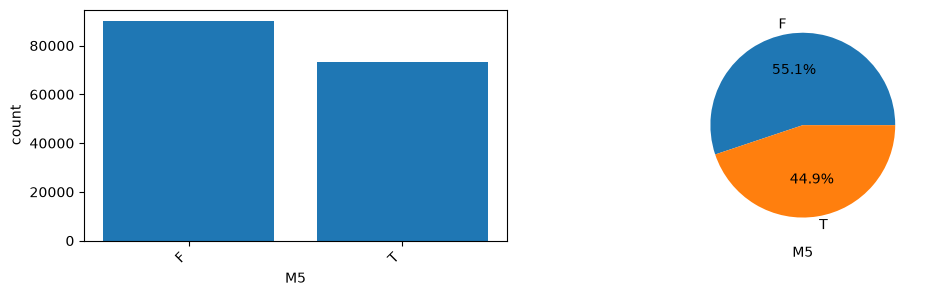

M6


,M6,counts,freq
0,F,153816,54.022274
1,T,130911,45.977726


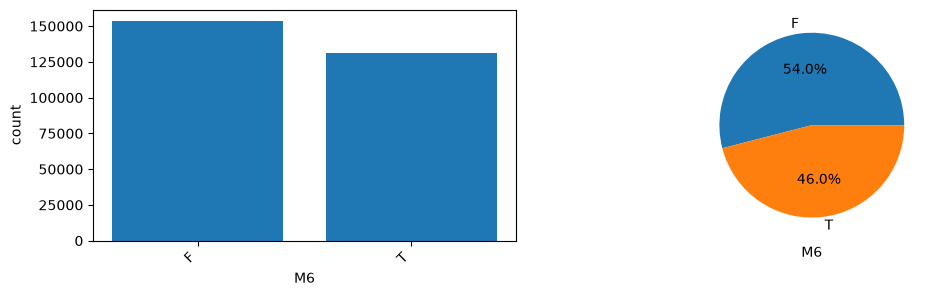

M7


,M7,counts,freq
0,F,118349,86.548489
1,T,18394,13.451511


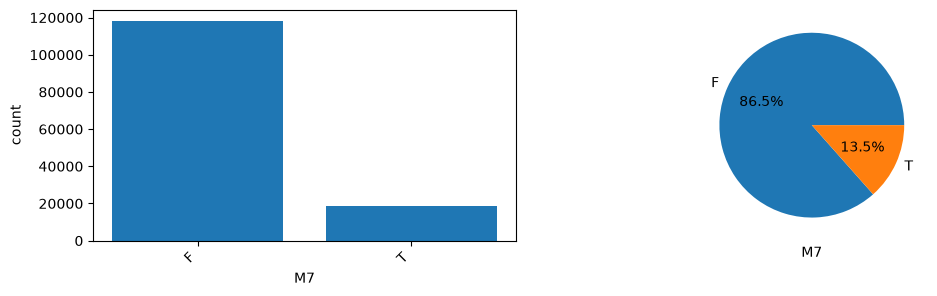

M8


,M8,counts,freq
0,F,86682,63.388594
1,T,50065,36.611406


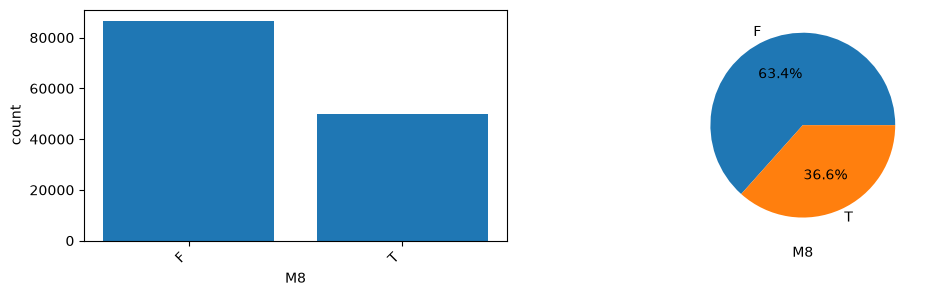

M9


,M9,counts,freq
0,T,115361,84.3609
1,F,21386,15.6391


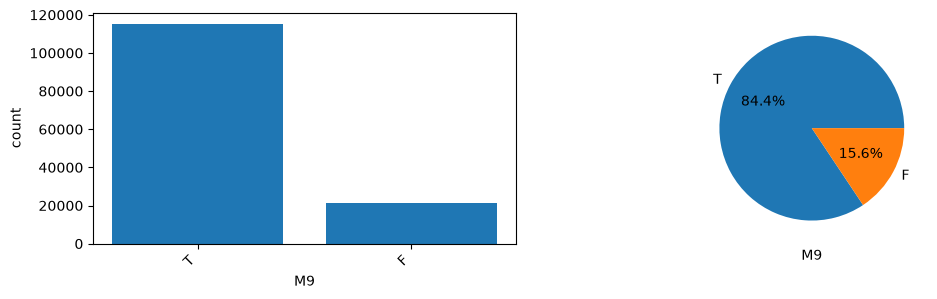

DeviceType


,DeviceType,counts,freq
0,desktop,65963,61.419779
1,mobile,41434,38.580221


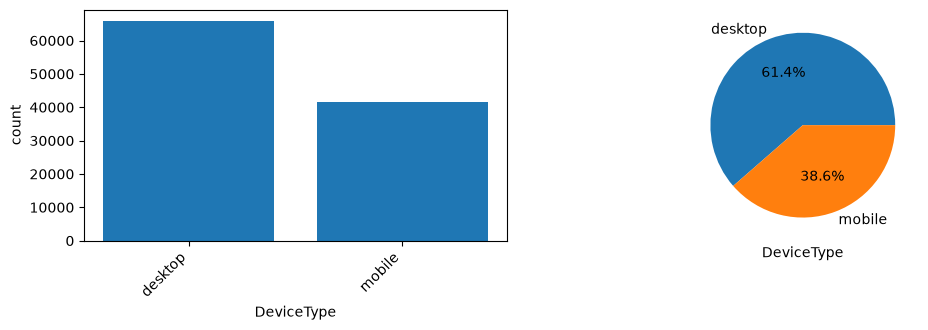

DeviceInfo


,DeviceInfo,counts,freq
0,Windows,36668,40.134848
1,iOS Device,16084,17.604693
2,MacOS,10191,11.154528
3,Trident/7.0,6048,6.619820
4,rv:11.0,1550,1.696548
...,...,...,...
1541,G3123 Build/40.0.A.6.189,1,0.001095
1542,GRACE,1,0.001095
1543,PMID7102DC,1,0.001095
1544,SM-J500H,1,0.001095


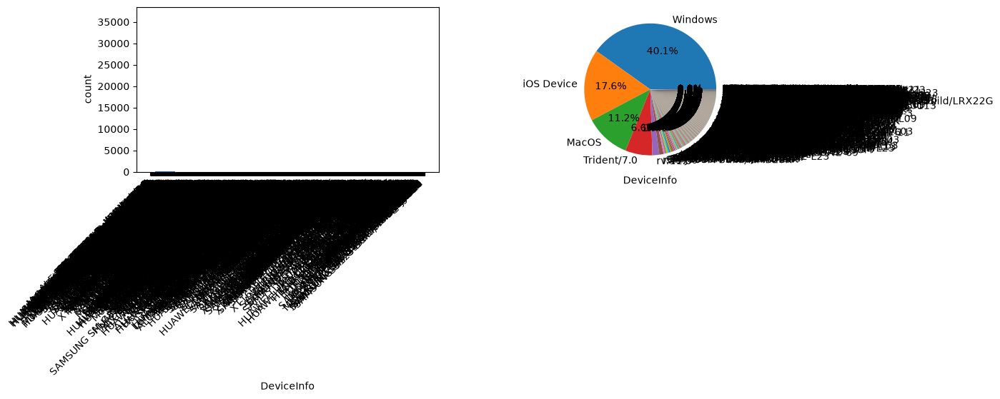

id_12


,id_12,counts,freq
0,NotFound,95365,86.765656
1,Found,14546,13.234344


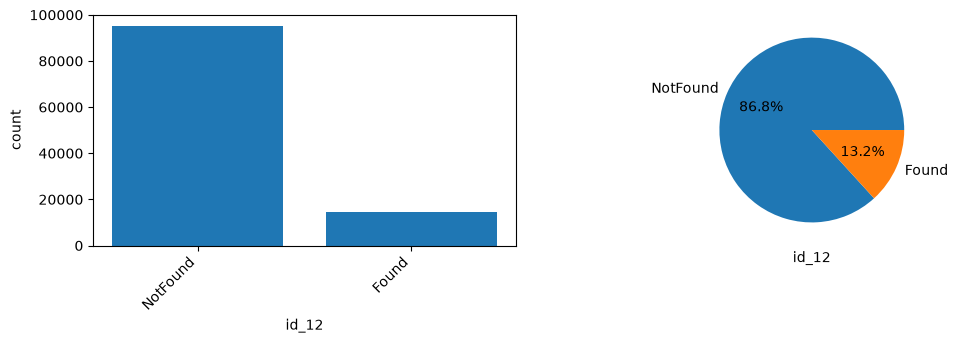

id_13


,id_13,counts,freq
0,52.0,44582,46.721861
1,49.0,26365,27.630476
2,33.0,10048,10.530287
3,20.0,2619,2.744708
4,14.0,1892,1.982813
5,64.0,1707,1.788933
6,63.0,1265,1.325718
7,19.0,1147,1.202054
8,25.0,1003,1.051142
9,43.0,830,0.869839


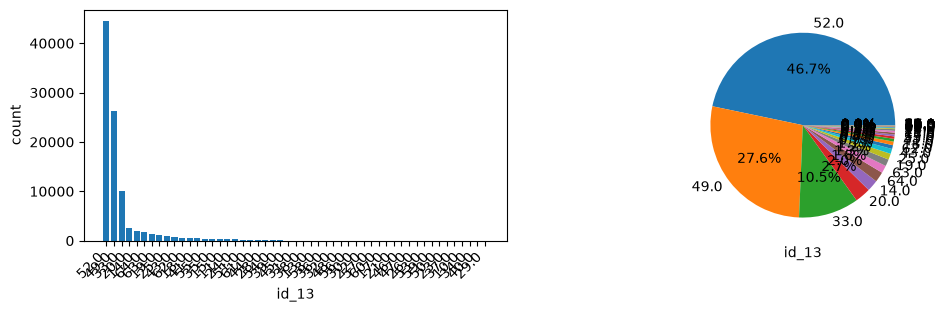

id_14


,id_14,counts,freq
0,-300.0,34376,53.916371
1,-360.0,13725,21.526710
2,-480.0,10543,16.535964
3,-420.0,3672,5.759277
4,-600.0,418,0.655604
5,60.0,283,0.443866
6,0.0,140,0.219580
7,-240.0,103,0.161548
8,-180.0,103,0.161548
9,-540.0,98,0.153706


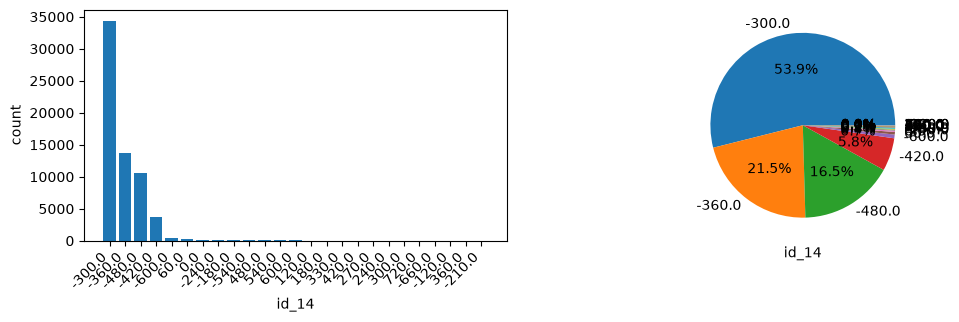

id_15


,id_15,counts,freq
0,Found,50452,46.912891
1,New,48482,45.081083
2,Unknown,8610,8.006025


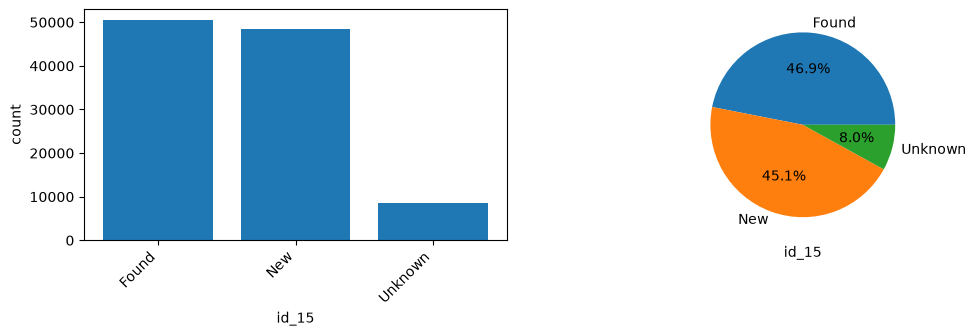

id_16


,id_16,counts,freq
0,NotFound,49767,50.303232
1,Found,49167,49.696768


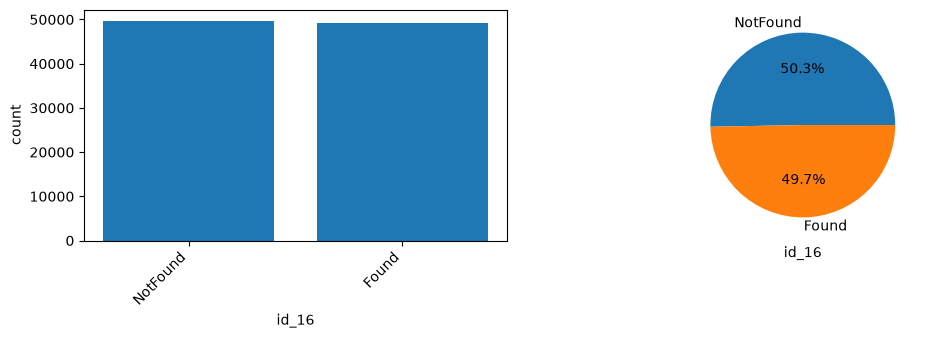

id_17


,id_17,counts,freq
0,166.0,62813,58.959413
1,225.0,40775,38.273447
2,102.0,554,0.520012
3,100.0,302,0.283472
4,159.0,260,0.244049
...,...,...,...
96,140.0,1,0.000939
97,211.0,1,0.000939
98,101.0,1,0.000939
99,139.0,1,0.000939


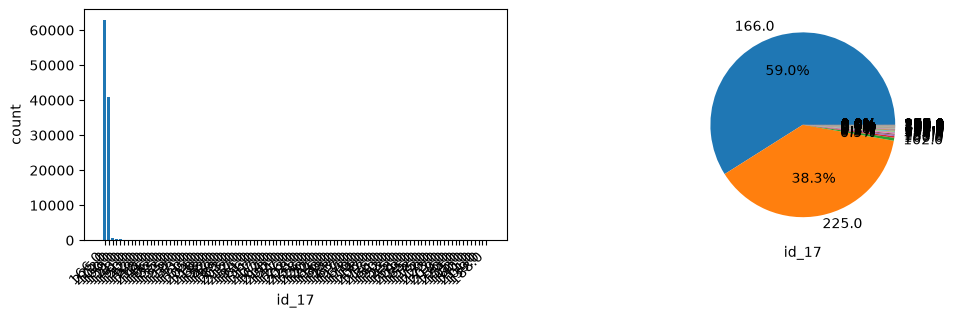

id_18


,id_18,counts,freq
0,15.0,18774,55.180319
1,13.0,10580,31.096611
2,12.0,3691,10.848544
3,18.0,518,1.522499
4,20.0,277,0.814155
5,21.0,67,0.196926
6,24.0,32,0.094054
7,11.0,31,0.091115
8,26.0,28,0.082297
9,17.0,7,0.020574


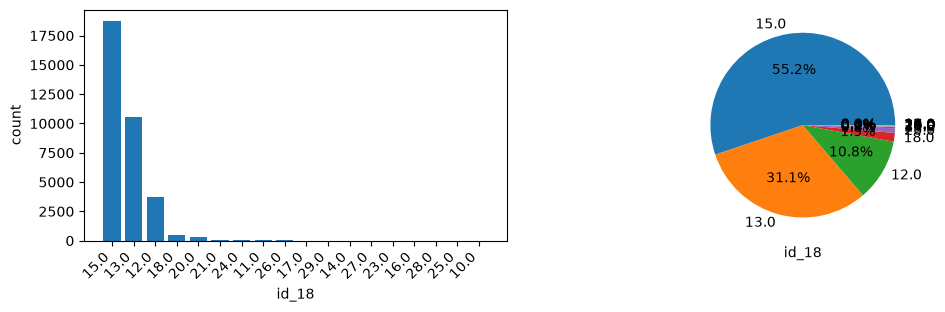

id_19


,id_19,counts,freq
0,266.0,14118,13.255965
1,410.0,9058,8.504925
2,427.0,6508,6.110626
3,529.0,6491,6.094664
4,312.0,5197,4.879675
...,...,...,...
498,171.0,1,0.000939
499,589.0,1,0.000939
500,324.0,1,0.000939
501,319.0,1,0.000939


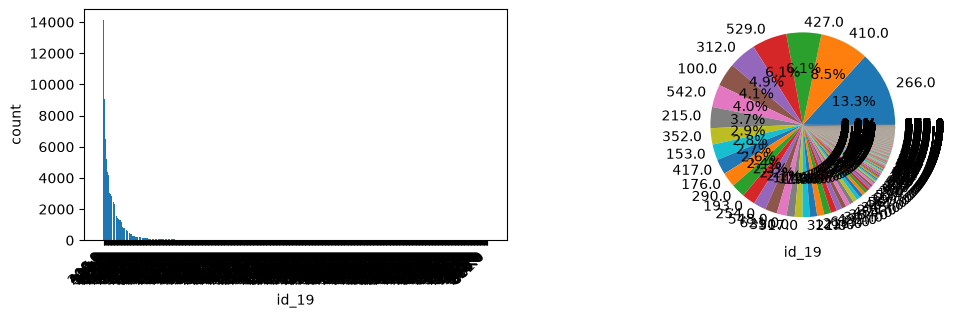

id_20


,id_20,counts,freq
0,507.0,19132,17.966681
1,222.0,8991,8.443363
2,325.0,5338,5.012866
3,214.0,4615,4.333903
4,600.0,4552,4.274740
...,...,...,...
360,240.0,1,0.000939
361,348.0,1,0.000939
362,606.0,1,0.000939
363,525.0,1,0.000939


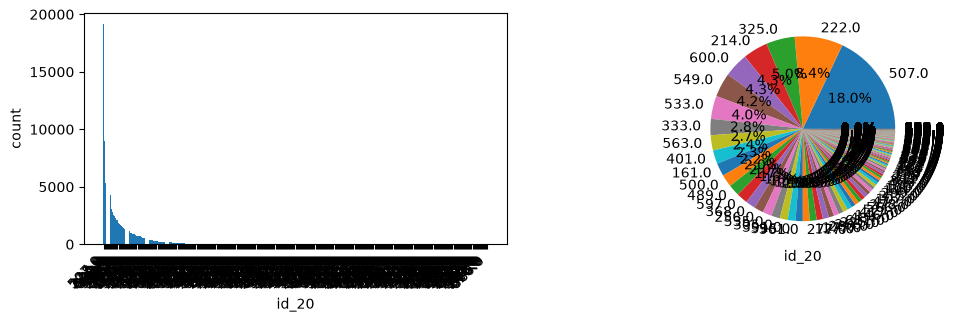

id_21


,id_21,counts,freq
0,252.0,1907,48.462516
1,228.0,188,4.777637
2,596.0,82,2.083863
3,849.0,78,1.982211
4,255.0,76,1.931385
...,...,...,...
416,211.0,1,0.025413
417,373.0,1,0.025413
418,846.0,1,0.025413
419,335.0,1,0.025413


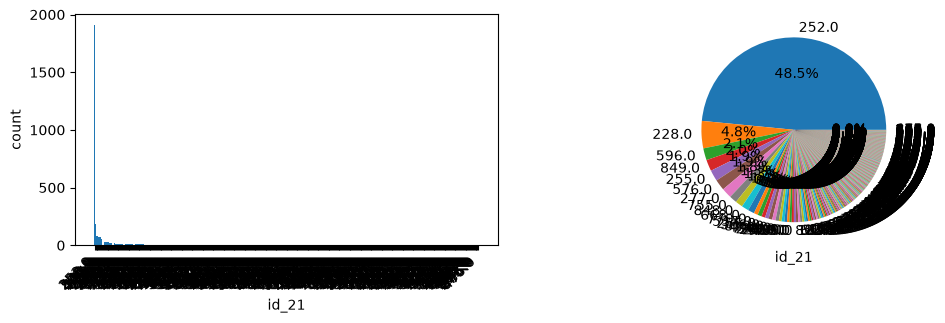

id_22


,id_22,counts,freq
0,14.0,3611,91.673013
1,41.0,246,6.245240
2,33.0,26,0.660066
3,21.0,7,0.177710
4,39.0,6,0.152323
5,35.0,5,0.126936
6,36.0,5,0.126936
7,22.0,5,0.126936
8,17.0,5,0.126936
9,12.0,4,0.101549


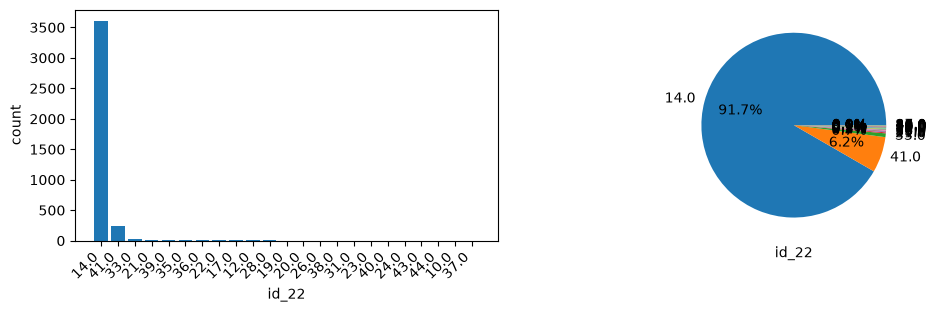

id_23


,id_23,counts,freq
0,IP_PROXY:TRANSPARENT,2626,66.666667
1,IP_PROXY:ANONYMOUS,815,20.690531
2,IP_PROXY:HIDDEN,498,12.642803


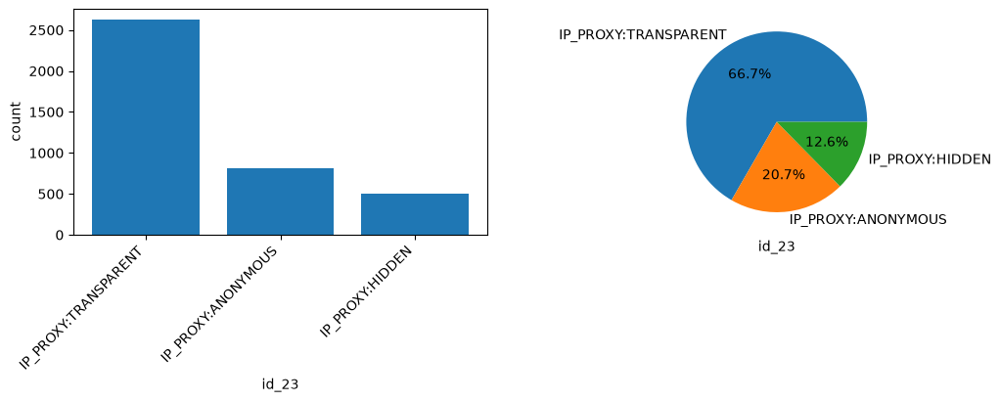

id_24


,id_24,counts,freq
0,11.0,2086,57.799945
1,15.0,1296,35.910224
2,16.0,180,4.987531
3,18.0,27,0.748130
4,25.0,6,0.166251
5,12.0,4,0.110834
6,19.0,4,0.110834
7,21.0,3,0.083126
8,26.0,2,0.055417
9,23.0,1,0.027709


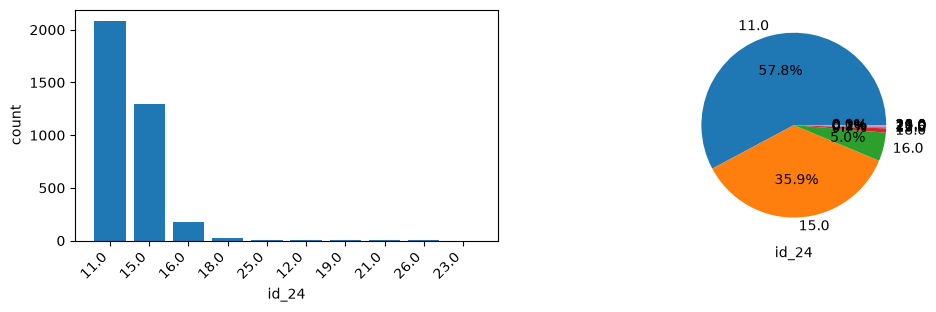

id_25


,id_25,counts,freq
0,321.0,1874,47.867178
1,205.0,241,6.155811
2,426.0,184,4.699872
3,501.0,82,2.094508
4,371.0,67,1.711367
...,...,...,...
302,407.0,1,0.025543
303,263.0,1,0.025543
304,329.0,1,0.025543
305,453.0,1,0.025543


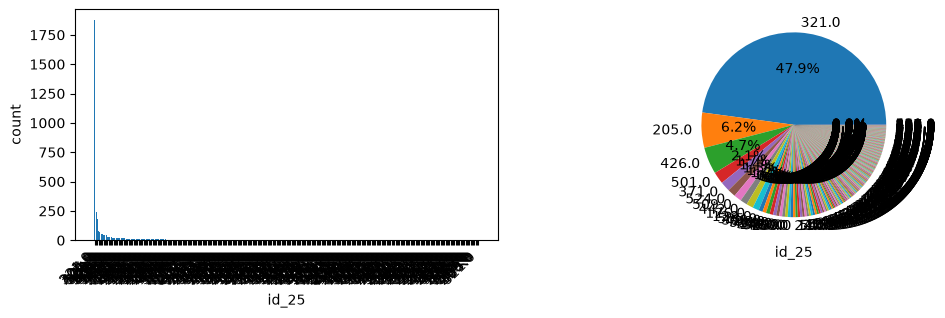

id_26


,id_26,counts,freq
0,161.0,614,15.611492
1,142.0,422,10.729723
2,184.0,388,9.865243
3,100.0,351,8.924485
4,102.0,341,8.670226
...,...,...,...
80,214.0,1,0.025426
81,167.0,1,0.025426
82,201.0,1,0.025426
83,108.0,1,0.025426


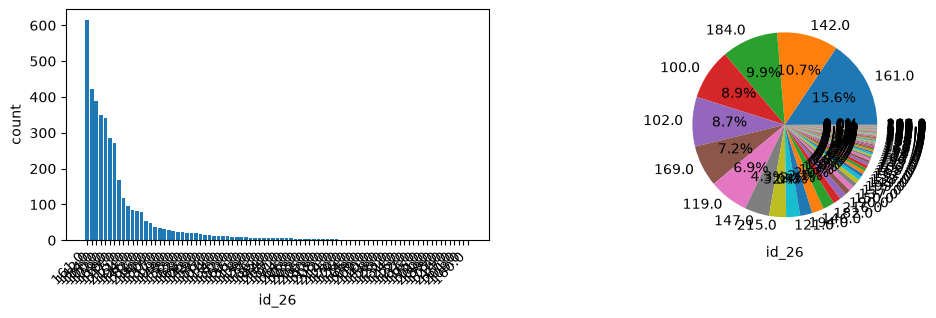

id_27


,id_27,counts,freq
0,Found,3930,99.771516
1,NotFound,9,0.228484


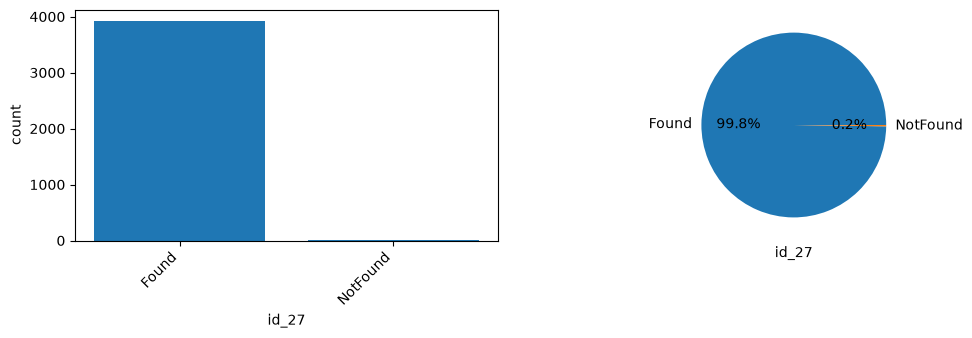

id_28


,id_28,counts,freq
0,Found,57383,53.357695
1,New,50161,46.642305


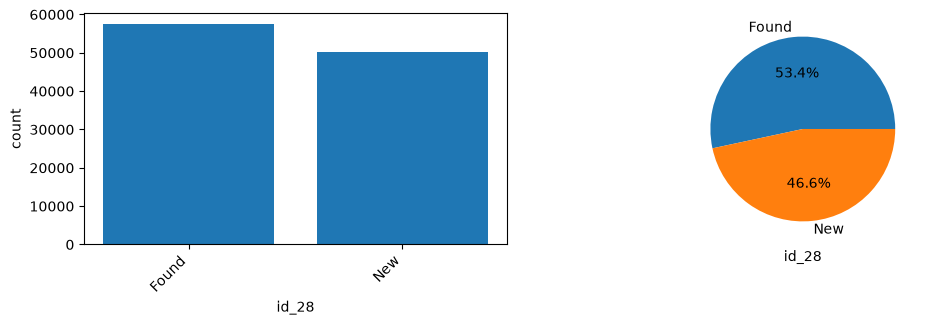

id_29


,id_29,counts,freq
0,Found,56187,52.245593
1,NotFound,51357,47.754407


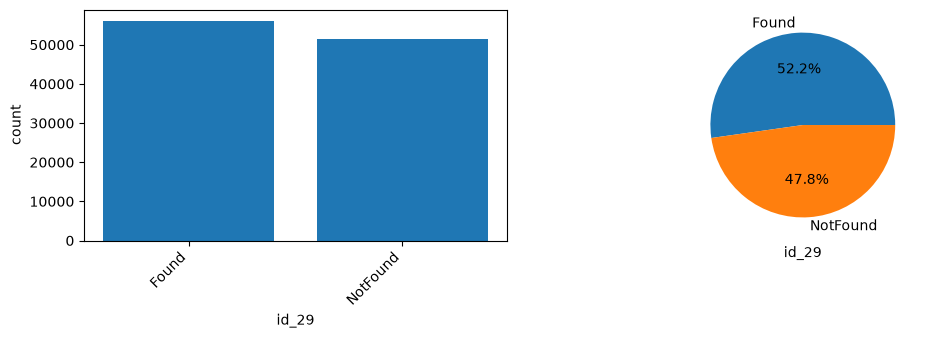

id_30


,id_30,counts,freq
0,Windows 10,15993,25.882829
1,Windows 7,10807,17.489885
2,iOS 11.1.2,3649,5.905486
3,iOS 11.2.1,3644,5.897394
4,Android 7.0,2504,4.052436
...,...,...,...
66,iOS 11.3.0,16,0.025894
67,func,10,0.016184
68,other,9,0.014565
69,Mac OS X 10_13_4,4,0.006474


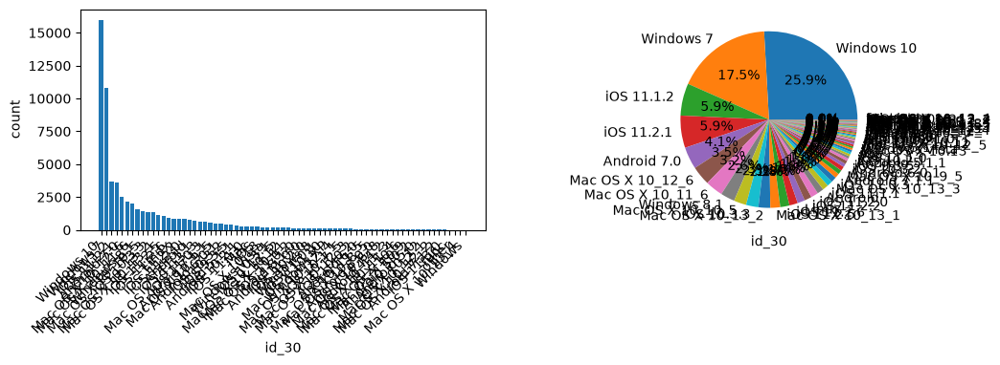

id_31


,id_31,counts,freq
0,chrome 63.0,21816,20.343914
1,mobile safari 11.0,11029,10.284792
2,mobile safari generic,8009,7.468574
3,ie 11.0 for desktop,7370,6.872692
4,safari generic,7208,6.721623
...,...,...,...
103,BLU/Dash,1,0.000933
104,seamonkey,1,0.000933
105,M4Tel/M4,1,0.000933
106,chromium,1,0.000933


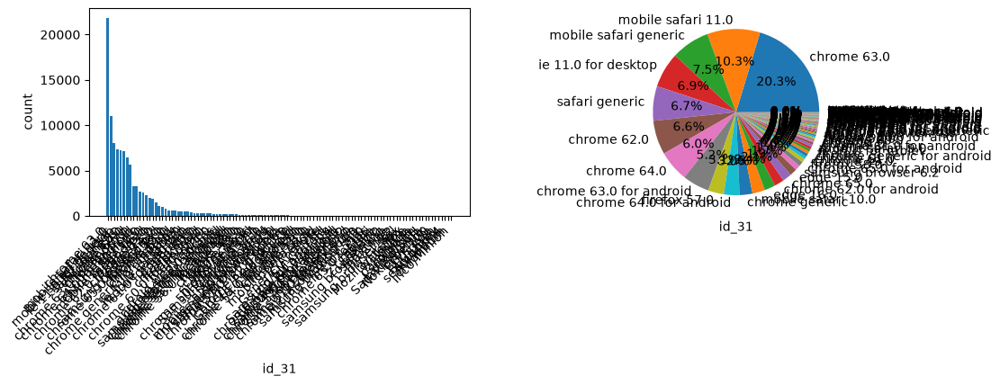

id_32


,id_32,counts,freq
0,24.0,41295,66.809578
1,32.0,20440,33.069083
2,16.0,70,0.113250
3,0.0,5,0.008089


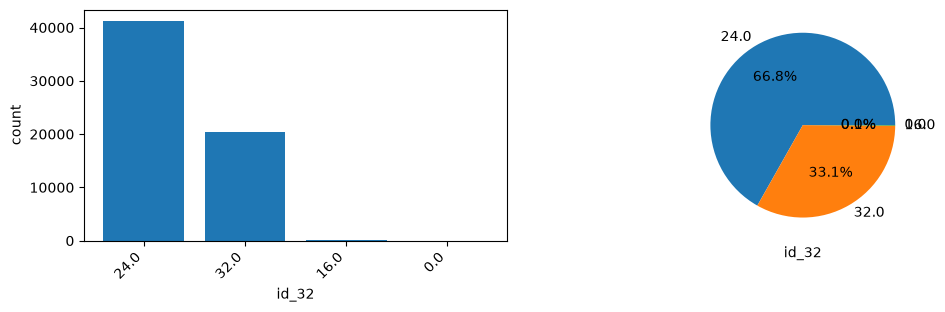

id_33


,id_33,counts,freq
0,1920x1080,13392,23.285170
1,1366x768,6224,10.821901
2,1334x750,5288,9.194443
3,2208x1242,3928,6.829760
4,1440x900,3586,6.235112
...,...,...,...
178,1680x1051,1,0.001739
179,1920x1079,1,0.001739
180,1919x1200,1,0.001739
181,1366x767,1,0.001739


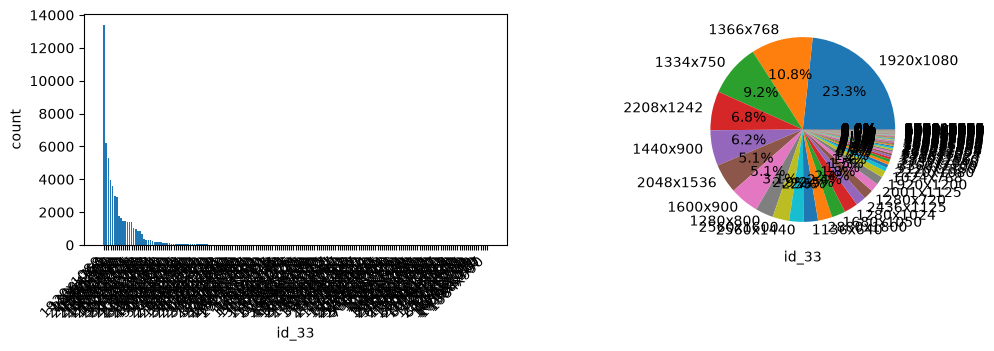

id_34


,id_34,counts,freq
0,match_status:2,46691,75.479720
1,match_status:1,14807,23.936695
2,match_status:0,358,0.578736
3,match_status:-1,3,0.004850


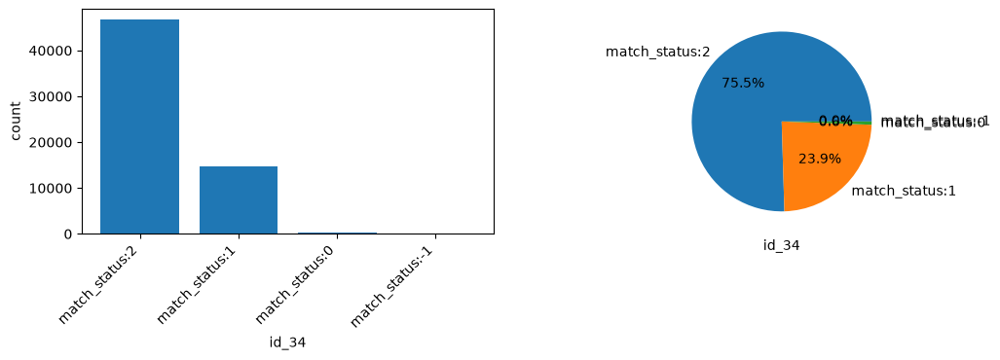

id_35


,id_35,counts,freq
0,T,61843,57.504835
1,F,45701,42.495165


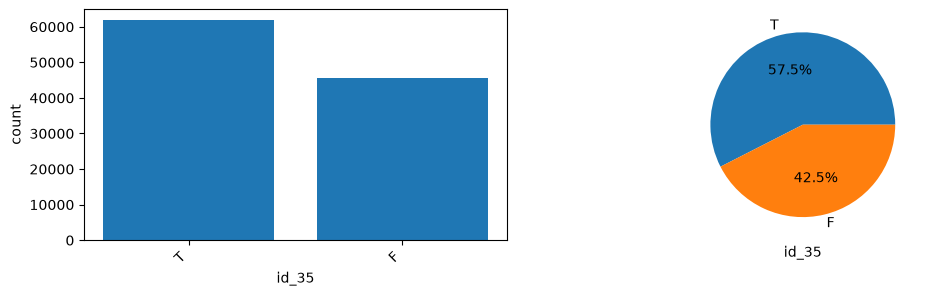

id_36


,id_36,counts,freq
0,F,101830,94.686826
1,T,5714,5.313174


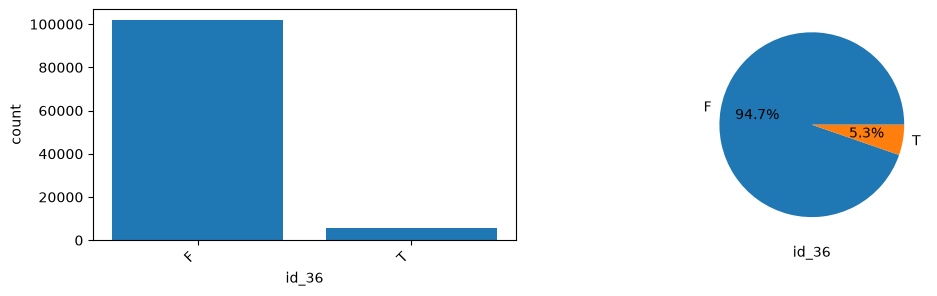

id_37


,id_37,counts,freq
0,T,83818,77.938332
1,F,23726,22.061668


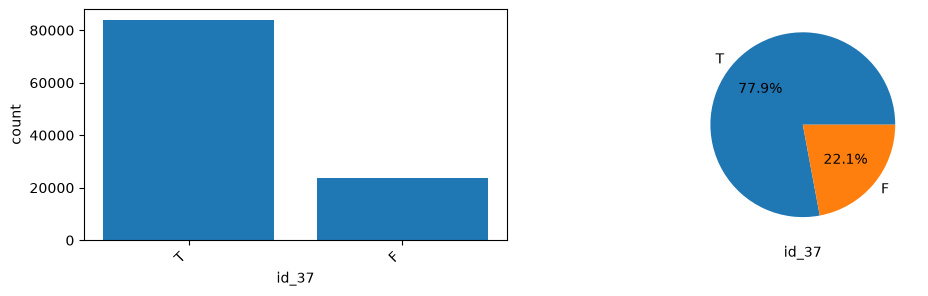

id_38


,id_38,counts,freq
0,T,57596,53.555754
1,F,49948,46.444246


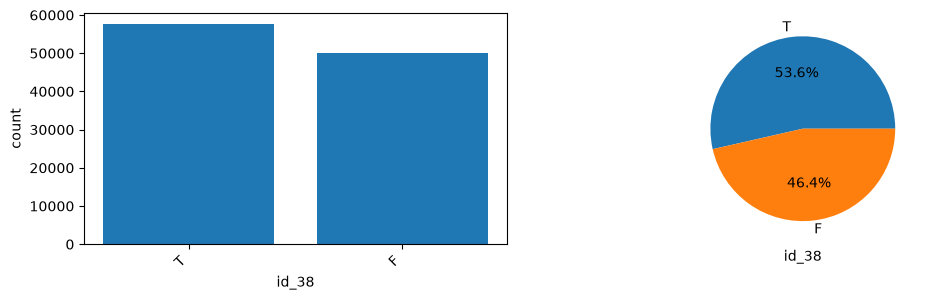

In [15]:
for col in qual_cols:
    sum_tab = summary_table(data = df[col])

    print(col)
    display(sum_tab)
    plot_qual(data = df[col])

# Bivariate Analysis

Due to the high dimensionalities, colunm wise, we are not going to perform biavariate anaalysis as it would generate a quantity of information impossible to porcess given the time constraints.